# Load data

In [1]:
load("NGS_BA_workspace2.RData")

## Libraries

In [2]:
library(readxl)
library(openxlsx)
library(dplyr)
library(stringr)
library(tibble)
library(ggplot2)
library(ggraph)
library(circlize)
library(tidyr)
library(readr)
library(purrr)
library(scales)
library(languageserver)
library(ggbeeswarm)
library(gtools)
library(ggprism)
library(forcats)
library(ggpubr)
library(lmtest)
library(car)
library(rstatix)
library(patchwork)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


circlize version 0.4.18
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: carData


Attaching package: ‘car’

## BR codes

In [3]:
BR_2_code <- c(
             "2405", "2443", "2778", "2929", "2989", "3094", "3851", "5873",
             "6527", "20045", "1079", "1215", "1299", "1400", "1455", "1468",
             "1470", "1507", "1515", "1533", "1551", "1602", "1763", "1767",
             "1783", "1792", "1823", "1839", "1924", "1956", "1963", "1982",
             "2035", "2133", "2140", "2149", "2161", "2162", "2177", "2180",
             "2227", "2265", "HD279", "UTSW0001", "UTSW0002", "UTSW0003",
             "UTSW0009", "UTSW0013", "UTSW0014", "UTSW0015", "UTSW0017",
             "UTSW0018", "UTSW0019", "UTSW0020", "UTSW0022", "UTSW0023",
             "UTSW0033", "6082", "1455", "2177",	"2180",	"992",	"1823",
             "1123", "1299", "1490", "1507",
             "1844",	"2133",	"1574",	"3500", "J10",	"J130",	"J20",	"J201",	"J203",
             "J218",	"J220",	"J24",	"J26",	"J34",	"J42",	"J46",	"J8",	"J9",	"J91",
             "J93", "6634",	"1559",	"1561",	"1607",	"1618",	"1629",	"1647",	"1690",	
             "1702",	"1707",	"1713",	"1724",	"1790", "1831",	"1837",	"1848",	"1850",	
             "6608",	"6611",	"6617",	"6618", "32",	"6624",	"6658",	"6670",	"6691",	"6696",	"6714",	
             "6716",	"6741",	"6779",	"6781", "6794",	"6829",	"6854",	"6623",	"3780",	"3782",	
             "3587",	"3796",	"3834",	"3814", "3836",	"3825",	"3813",	"3839",	"3811",	"3805",
             "3808",	"2899",	"3845",	"3846",	"3847",	"3848",	"3850",	"3853", "3061",	"3255",
             "3267",	"381",	"1136",	"1145",	"1226",	"1288",	"1292",	"1313",	"1397",	"1403",
             "1446",	"1524",	"1700", "2024",	"2218",	"1503",	"1589",	"1606",	"1611",
             "1617",	"1636",	"1646",	"1650",	"1658",	"1692",	"1698",	"1717", "1722",	"1734",
             "1741",	"1747",	"1787",	"1796",	"1801",	"1825",	"1851",	"2726", "3197", "3369",
             "3936", "4284", "4643", "4720", "5139", "6565", "6655",	"606",	"1173",	"1238",
             "1301",	"1468", "1579",	"1864",	"1922",	"1823",	"1574",	"USCHC017", "USCHC018",
             "USCHC019",	"USCHC020", "USCHC021",	"USCHC022",	"USCHC023",	"USCHC024",	"USCHC025",
             "USCHC027", "USCHC028",	"USCHC029",	"USCHC030",	"USCHC031",	"USCHC032",	"USCHC033",
             "USCHC034",	"USCHC035",	"USCHC036", "USCHC037",	"USCHC038",	"USCHC040",	"USCH001",
             "USCH002",	"USCH006",	"USCH004",	"USCH003",	"USCH005",	"USCH007",	"USCH010",	
             "USCH011",	"USCH013",	"USCH015",	"USCH014",	"USCH012",	"USCH016",	"USCH009",
             "USCH008",	"1503",	"USCHC001",	"USCHC002", "USCHC003",	"USCHC004",	"USCHC006",
             "USCHC007",	"USCHC008",	"USCHC009",	"USCHC010",	"USCHC011",	"USCHC012",	
             "USCHC013",	"USCHC014",	"USCHC015",	"USCHC016",	"USCH019",	"USCH018",	"USCH024",
             "USCH029",	"USCH030",	"USCH031", "USCH033",	"USCH037",	"USCH034",	"USCH017",
             "USCH040",	"USCH041",	"USCH044",	"USCH022",	"USCH023",	"USCH025",	"USCH026",
             	"USCH027",	"USCH035",	"USCH036",	"USCH039",	"USCH028",	"USCH042",
              "1483",	"1616",	"1638",	"1697",	"6774", "USCHC026",	"USCHC039",
              "USCHC005",	"USCH043",	"USCH020",	"USCH021",	"USCH032")

In [4]:
exists("HC_comparison_df")
#colnames(HC_comparison_df)
#glimpse(HC_comparison_df)

comparison_check <- HC_comparison_df %>%
    group_by(BR_code) %>%
    filter(group_ID == "BAMS_NAT") %>%
    summarize(n_count = n())

#print(comparison_check, n = 35)

[1] TRUE

In [5]:
HC_comparison_df$group_ID <- factor(HC_comparison_df$group_ID, levels=c('BAHC','BAMS_nonNAT','BAMS_NAT')) 

group_shapes <- c(
  "BAHC" = 15, #square
  "BAMS_nonNAT" = 16, #circle
  "BAMS_NAT" = 17 #triangle
)

group_colors <- c(
  "BAHC" = "#73ACE0", 
  "BAMS_nonNAT" = "#6EDF72", 
  "BAMS_NAT" = "#CEA57A")

## this could be made better by doing exp_group_A, exp_group_B, control_group - be careful I sloppily tried and it did not work, it might be that they dont need quotes
group_comparisons <- list(c("BAHC", "BAMS_nonNAT"), c("BAHC", "BAMS_NAT"), c("BAMS_nonNAT", "BAMS_NAT"))

# Mutational Analysis 

#### overall summary 

In [215]:
mut_analysis_summary <- HC_comparison_df %>%
group_by(group_ID, BR_code) %>%
summarize(
    n_count = n(),
    #overall nucleotide counts
    count_nt_fwr1 = sum(mu_total_count_fwr1, na.rm = TRUE),
    count_nt_cdr1 = sum(mu_total_count_cdr1, na.rm = TRUE),
    count_nt_fwr2 = sum(mu_total_count_fwr2, na.rm = TRUE),
    count_nt_cdr2 = sum(mu_total_count_cdr2, na.rm = TRUE),
    count_nt_fwr3 = sum(mu_total_count_fwr3, na.rm = TRUE),
    #replacement counts by nucleotide
    repl_count_nt_fwr1 = sum(mu_count_fwr1_r, na.rm = TRUE),
    repl_count_nt_cdr1 = sum(mu_count_cdr1_r, na.rm = TRUE),
    repl_count_nt_fwr2 = sum(mu_count_fwr2_r, na.rm = TRUE),
    repl_count_nt_cdr2 = sum(mu_count_cdr2_r, na.rm = TRUE),
    repl_count_nt_fwr3 = sum(mu_count_fwr3_r, na.rm = TRUE),
    #silent mutation count by nucleotide
    sil_count_nt_fwr1 = sum(mu_count_fwr1_s, na.rm = TRUE),
    sil_count_nt_cdr1 = sum(mu_count_cdr1_s, na.rm = TRUE),
    sil_count_nt_fwr2 = sum(mu_count_fwr2_s, na.rm = TRUE),
    sil_count_nt_cdr2 = sum(mu_count_cdr2_s, na.rm = TRUE),
    sil_count_nt_fwr3 = sum(mu_count_fwr3_s, na.rm = TRUE),
    #overall aa counts
    count_aa_fwr1 = sum(mu_total_count_fwr1_aa, na.rm = TRUE),
    count_aa_cdr1 = sum(mu_total_count_cdr1_aa, na.rm = TRUE),
    count_aa_fwr2 = sum(mu_total_count_fwr2_aa, na.rm = TRUE),
    count_aa_cdr2 = sum(mu_total_count_cdr2_aa, na.rm = TRUE),
    count_aa_fwr3 = sum(mu_total_count_fwr3_aa, na.rm = TRUE),
    #replacement counts by aa
    repl_count_aa_fwr1 = sum(mu_count_fwr1_r_aa, na.rm = TRUE),
    repl_count_aa_cdr1 = sum(mu_count_cdr1_r_aa, na.rm = TRUE),
    repl_count_aa_fwr2 = sum(mu_count_fwr2_r_aa, na.rm = TRUE),
    repl_count_aa_cdr2 = sum(mu_count_cdr2_r_aa, na.rm = TRUE),
    repl_count_aa_fwr3 = sum(mu_count_fwr3_r_aa, na.rm = TRUE),
    #silent mutation count by aa
    sil_count_aa_fwr1 = sum(mu_count_fwr1_s_aa, na.rm = TRUE),
    sil_count_aa_cdr1 = sum(mu_count_cdr1_s_aa, na.rm = TRUE),
    sil_count_aa_fwr2 = sum(mu_count_fwr2_s_aa, na.rm = TRUE),
    sil_count_aa_cdr2 = sum(mu_count_cdr2_s_aa, na.rm = TRUE),
    sil_count_aa_fwr3 = sum(mu_count_fwr3_s_aa, na.rm = TRUE),
    .groups = "drop") %>%
mutate(
    #all nucleotides count
    count_nt_all = rowSums(across(c(
        count_nt_fwr1,
        count_nt_cdr1,
        count_nt_fwr2,
        count_nt_cdr2,
        count_nt_fwr3
    ))),
    #all CDR nucleotides count
    count_nt_cdr_all = rowSums(across(c(
        count_nt_cdr1,
        count_nt_cdr2,
    ))),
    #all FWR nucleotides count
    count_nt_fwr_all = rowSums(across(c(
        count_nt_fwr1,
        count_nt_fwr2,
        count_nt_fwr3
    ))),
    #all nucleotides count replacements
    r_count_nt_all = rowSums(across(c(
        repl_count_nt_fwr1,
        repl_count_nt_cdr1,
        repl_count_nt_fwr2,
        repl_count_nt_cdr2,
        repl_count_nt_fwr3
    ))),
    #all nucleotides count silent
    s_count_nt_all = rowSums(across(c(
        sil_count_nt_fwr1,
        sil_count_nt_cdr1,
        sil_count_nt_fwr2,
        sil_count_nt_cdr2,
        sil_count_nt_fwr3
    ))),
    #all aa count 
    count_aa_all = rowSums(across(c(
        count_aa_fwr1,
        count_aa_cdr1,
        count_aa_fwr2,
        count_aa_cdr2,
        count_aa_fwr3
    ))),
    #all aa count replacement
    r_count_aa_all = rowSums(across(c(
        repl_count_aa_fwr1,
        repl_count_aa_cdr1,
        repl_count_aa_fwr2,
        repl_count_aa_cdr2,
        repl_count_aa_fwr3
    ))),
    #all aa count silent
    s_count_aa_all = rowSums(across(c(
        sil_count_aa_fwr1,
        sil_count_aa_cdr1,
        sil_count_aa_fwr2,
        sil_count_aa_cdr2,
        sil_count_aa_fwr3
    ))),
    #1 mutation frequency by nucleotide overall 
    mut_freq_nt_all = ((r_count_nt_all + s_count_nt_all) / count_nt_all) * 100,
    #2 replacement mutation frequncy by nucleotide 
    r_mut_freq_nt_all = (r_count_nt_all / count_nt_all) * 100,
    #3 mutation frequency by aa overall 
    mut_freq_aa_all = ((r_count_aa_all + s_count_aa_all) / count_aa_all) * 100,
    #3.2 replacement mutation frequency by aa overall 
    r_mut_freq_aa_all = ((r_count_aa_all) / count_aa_all) * 100,
    #4 mutation frequency in CDR by nucleotide 
    mut_freq_cdr_nt = (
        (repl_count_nt_cdr1 + sil_count_nt_cdr1 + repl_count_nt_cdr2 + sil_count_nt_cdr2) /
        (r_count_nt_all + s_count_nt_all)
        ) * 100,
    #4.2 mutation freq in FWR by nt
     mut_freq_fwr_nt = (
        (repl_count_nt_fwr1 + sil_count_nt_fwr1 + repl_count_nt_fwr2 + sil_count_nt_fwr2 + repl_count_nt_fwr3 + sil_count_nt_fwr3) /
        (r_count_nt_all + s_count_nt_all)
        ) * 100,
    #5 replacement frequency in CDR
    r_mut_freq_cdr = ((repl_count_nt_cdr1 + repl_count_nt_cdr2) / count_nt_cdr_all) * 100,
    #5.2 replacement frequency in fwr
    r_mut_freq_fwr = ((repl_count_nt_fwr1 + repl_count_nt_fwr2 + repl_count_nt_fwr3) / count_nt_fwr_all) * 100,
    #5.3 replacement frequency CDR:FWR ratio
    r_mut_freq_cdr_fwr = r_mut_freq_cdr / r_mut_freq_fwr,
    #6 replacement to silent ratio in CDR 
    r_s_ratio_cdr = ((repl_count_nt_cdr1 + repl_count_nt_cdr2) / (sil_count_nt_cdr1 + sil_count_nt_cdr2)),
    #7 replacement to silent ratio in FWR
    r_s_ratio_fwr = ((repl_count_nt_fwr1 + repl_count_nt_fwr2 + repl_count_nt_fwr3) / (sil_count_nt_fwr1 + sil_count_nt_fwr2 + sil_count_nt_fwr3)),
    #8 R:S ratio as ratio of CDR to FWR
    r_s_cdr_fwr = r_s_ratio_cdr / r_s_ratio_fwr
    ) 
.groups = "drop"

tail(mut_analysis_summary)
#colnames(mut_analysis_summary)

group_ID,BR_code,n_count,count_nt_fwr1,count_nt_cdr1,count_nt_fwr2,count_nt_cdr2,count_nt_fwr3,repl_count_nt_fwr1,repl_count_nt_cdr1,⋯,mut_freq_aa_all,r_mut_freq_aa_all,mut_freq_cdr_nt,mut_freq_fwr_nt,r_mut_freq_cdr,r_mut_freq_fwr,r_mut_freq_cdr_fwr,r_s_ratio_cdr,r_s_ratio_fwr,r_s_cdr_fwr
<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BAMS_NAT,J42,7863,59930,199464,401012,181530,896370,1734,24717,⋯,23.87445,14.30738,34.58018,65.41982,10.477855,4.073934,2.571925,3.256914,1.273691,2.557069
BAMS_NAT,J46,25336,222988,614215,1289282,605316,2887831,4662,51798,⋯,19.90019,13.19774,39.31278,60.68722,9.905037,3.591577,2.757852,3.132001,1.796319,1.743566
BAMS_NAT,J8,11027,112548,275139,562164,251172,1257030,876,34337,⋯,23.74489,15.56991,38.52540,61.47460,12.344412,3.910926,3.156391,4.309784,1.447909,2.976557
BAMS_NAT,J9,2320,20197,55680,118320,62826,264479,51,2647,⋯,16.48626,12.10497,41.26719,58.73281,9.133715,3.150403,2.899221,4.326139,2.024880,2.136491
BAMS_NAT,J91,37527,346567,944015,1913239,890412,4277561,7626,89170,⋯,20.17043,13.11893,37.65264,62.34736,9.693654,3.542007,2.736769,3.490490,1.572491,2.219720
BAMS_NAT,J93,19157,184597,473960,976834,450647,2183621,6340,49266,⋯,23.35659,15.51744,38.83765,61.16235,12.021540,4.264807,2.818777,3.536719,1.742348,2.029857


#### summary by V family 

In [216]:
mut_analysis_V_family <- HC_comparison_df %>%
group_by(group_ID, BR_code, V_gene_mut) %>%
summarize(
    n_count = n(),
    #overall nucleotide counts
    count_nt_fwr1 = sum(mu_total_count_fwr1, na.rm = TRUE),
    count_nt_cdr1 = sum(mu_total_count_cdr1, na.rm = TRUE),
    count_nt_fwr2 = sum(mu_total_count_fwr2, na.rm = TRUE),
    count_nt_cdr2 = sum(mu_total_count_cdr2, na.rm = TRUE),
    count_nt_fwr3 = sum(mu_total_count_fwr3, na.rm = TRUE),
    #replacement counts by nucleotide
    repl_count_nt_fwr1 = sum(mu_count_fwr1_r, na.rm = TRUE),
    repl_count_nt_cdr1 = sum(mu_count_cdr1_r, na.rm = TRUE),
    repl_count_nt_fwr2 = sum(mu_count_fwr2_r, na.rm = TRUE),
    repl_count_nt_cdr2 = sum(mu_count_cdr2_r, na.rm = TRUE),
    repl_count_nt_fwr3 = sum(mu_count_fwr3_r, na.rm = TRUE),
    #silent mutation count by nucleotide
    sil_count_nt_fwr1 = sum(mu_count_fwr1_s, na.rm = TRUE),
    sil_count_nt_cdr1 = sum(mu_count_cdr1_s, na.rm = TRUE),
    sil_count_nt_fwr2 = sum(mu_count_fwr2_s, na.rm = TRUE),
    sil_count_nt_cdr2 = sum(mu_count_cdr2_s, na.rm = TRUE),
    sil_count_nt_fwr3 = sum(mu_count_fwr3_s, na.rm = TRUE),
    #overall aa counts
    count_aa_fwr1 = sum(mu_total_count_fwr1_aa, na.rm = TRUE),
    count_aa_cdr1 = sum(mu_total_count_cdr1_aa, na.rm = TRUE),
    count_aa_fwr2 = sum(mu_total_count_fwr2_aa, na.rm = TRUE),
    count_aa_cdr2 = sum(mu_total_count_cdr2_aa, na.rm = TRUE),
    count_aa_fwr3 = sum(mu_total_count_fwr3_aa, na.rm = TRUE),
    #replacement counts by aa
    repl_count_aa_fwr1 = sum(mu_count_fwr1_r_aa, na.rm = TRUE),
    repl_count_aa_cdr1 = sum(mu_count_cdr1_r_aa, na.rm = TRUE),
    repl_count_aa_fwr2 = sum(mu_count_fwr2_r_aa, na.rm = TRUE),
    repl_count_aa_cdr2 = sum(mu_count_cdr2_r_aa, na.rm = TRUE),
    repl_count_aa_fwr3 = sum(mu_count_fwr3_r_aa, na.rm = TRUE),
    #silent mutation count by aa
    sil_count_aa_fwr1 = sum(mu_count_fwr1_s_aa, na.rm = TRUE),
    sil_count_aa_cdr1 = sum(mu_count_cdr1_s_aa, na.rm = TRUE),
    sil_count_aa_fwr2 = sum(mu_count_fwr2_s_aa, na.rm = TRUE),
    sil_count_aa_cdr2 = sum(mu_count_cdr2_s_aa, na.rm = TRUE),
    sil_count_aa_fwr3 = sum(mu_count_fwr3_s_aa, na.rm = TRUE),
    .groups = "drop") %>%
mutate(
    #all nucleotides count
    count_nt_all = rowSums(across(c(
        count_nt_fwr1,
        count_nt_cdr1,
        count_nt_fwr2,
        count_nt_cdr2,
        count_nt_fwr3
    ))),
    #all CDR nucleotides count
    count_nt_cdr_all = rowSums(across(c(
        count_nt_cdr1,
        count_nt_cdr2,
    ))),
    #all FWR nucleotides count
    count_nt_fwr_all = rowSums(across(c(
        count_nt_fwr1,
        count_nt_fwr2,
        count_nt_fwr3
    ))),
    #all nucleotides count replacements
    r_count_nt_all = rowSums(across(c(
        repl_count_nt_fwr1,
        repl_count_nt_cdr1,
        repl_count_nt_fwr2,
        repl_count_nt_cdr2,
        repl_count_nt_fwr3
    ))),
    #all nucleotides count silent
    s_count_nt_all = rowSums(across(c(
        sil_count_nt_fwr1,
        sil_count_nt_cdr1,
        sil_count_nt_fwr2,
        sil_count_nt_cdr2,
        sil_count_nt_fwr3
    ))),
    #all aa count 
    count_aa_all = rowSums(across(c(
        count_aa_fwr1,
        count_aa_cdr1,
        count_aa_fwr2,
        count_aa_cdr2,
        count_aa_fwr3
    ))),
    #all aa count replacement
    r_count_aa_all = rowSums(across(c(
        repl_count_aa_fwr1,
        repl_count_aa_cdr1,
        repl_count_aa_fwr2,
        repl_count_aa_cdr2,
        repl_count_aa_fwr3
    ))),
    #all aa count silent
    s_count_aa_all = rowSums(across(c(
        sil_count_aa_fwr1,
        sil_count_aa_cdr1,
        sil_count_aa_fwr2,
        sil_count_aa_cdr2,
        sil_count_aa_fwr3
    ))),
    #1 mutation frequency by nucleotide overall 
    mut_freq_nt_all = ((r_count_nt_all + s_count_nt_all) / count_nt_all) * 100,
    #2 replacement mutation frequncy by nucleotide 
    r_mut_freq_nt_all = (r_count_nt_all / count_nt_all) * 100,
    #3 mutation frequency by aa overall 
    mut_freq_aa_all = ((r_count_aa_all + s_count_aa_all) / count_aa_all) * 100,
    #3.2 replacement mutation frequency by aa overall 
    r_mut_freq_aa_all = ((r_count_aa_all) / count_aa_all) * 100,
    #4 mutation frequency in CDR by nucleotide 
    mut_freq_cdr_nt = (
        (repl_count_nt_cdr1 + sil_count_nt_cdr1 + repl_count_nt_cdr2 + sil_count_nt_cdr2) /
        (r_count_nt_all + s_count_nt_all)
        ) * 100,
    #4.2 mutation freq in FWR by nt
     mut_freq_fwr_nt = (
        (repl_count_nt_fwr1 + sil_count_nt_fwr1 + repl_count_nt_fwr2 + sil_count_nt_fwr2 + repl_count_nt_fwr3 + sil_count_nt_fwr3) /
        (r_count_nt_all + s_count_nt_all)
        ) * 100,
    #5 replacement frequency in CDR
    r_mut_freq_cdr = ((repl_count_nt_cdr1 + repl_count_nt_cdr2) / count_nt_cdr_all) * 100,
    #5.2 replacement frequency in FWR
    r_mut_freq_fwr = ((repl_count_nt_fwr1 + repl_count_nt_fwr2 + repl_count_nt_fwr3) / count_nt_fwr_all) * 100,
    #5.3 replacement frequency CDR:FWR ratio
    r_mut_freq_cdr_fwr = r_mut_freq_cdr / r_mut_freq_fwr,
    #6 replacement to silent ratio in CDR 
    r_s_ratio_cdr = ((repl_count_nt_cdr1 + repl_count_nt_cdr2) / (sil_count_nt_cdr1 + sil_count_nt_cdr2)),
    #7 replacement to silent ratio in FWR
    r_s_ratio_fwr = ((repl_count_nt_fwr1 + repl_count_nt_fwr2 + repl_count_nt_fwr3) / (sil_count_nt_fwr1 + sil_count_nt_fwr2 + sil_count_nt_fwr3)),
    #8 R:S ratio as ratio of CDR to FWR
    r_s_cdr_fwr = r_s_ratio_cdr / r_s_ratio_fwr
    ) 
.groups = "drop"

#head(mut_analysis_V_family)
#colnames(mut_analysis_V_family)

mut_analysis_VH4_family <- mut_analysis_V_family %>%
    filter(V_gene_mut == "VH4")
#glimpse(mut_analysis_VH4_family)
mut_analysis_VH3_family <- mut_analysis_V_family %>%
    filter(V_gene_mut == "VH3")


#### summary by V family : J gene

In [217]:
mut_analysis_V_family_J_gene <- HC_comparison_df %>%
group_by(group_ID, BR_code, VJ_only_gene) %>%
summarize(
    V_gene_mut = unique(V_gene_mut), 
    J_gene_mut = unique(J_gene_mut),
    n_count = n(),
    #overall nucleotide counts
    count_nt_fwr1 = sum(mu_total_count_fwr1, na.rm = TRUE),
    count_nt_cdr1 = sum(mu_total_count_cdr1, na.rm = TRUE),
    count_nt_fwr2 = sum(mu_total_count_fwr2, na.rm = TRUE),
    count_nt_cdr2 = sum(mu_total_count_cdr2, na.rm = TRUE),
    count_nt_fwr3 = sum(mu_total_count_fwr3, na.rm = TRUE),
    #replacement counts by nucleotide
    repl_count_nt_fwr1 = sum(mu_count_fwr1_r, na.rm = TRUE),
    repl_count_nt_cdr1 = sum(mu_count_cdr1_r, na.rm = TRUE),
    repl_count_nt_fwr2 = sum(mu_count_fwr2_r, na.rm = TRUE),
    repl_count_nt_cdr2 = sum(mu_count_cdr2_r, na.rm = TRUE),
    repl_count_nt_fwr3 = sum(mu_count_fwr3_r, na.rm = TRUE),
    #silent mutation count by nucleotide
    sil_count_nt_fwr1 = sum(mu_count_fwr1_s, na.rm = TRUE),
    sil_count_nt_cdr1 = sum(mu_count_cdr1_s, na.rm = TRUE),
    sil_count_nt_fwr2 = sum(mu_count_fwr2_s, na.rm = TRUE),
    sil_count_nt_cdr2 = sum(mu_count_cdr2_s, na.rm = TRUE),
    sil_count_nt_fwr3 = sum(mu_count_fwr3_s, na.rm = TRUE),
    #overall aa counts
    count_aa_fwr1 = sum(mu_total_count_fwr1_aa, na.rm = TRUE),
    count_aa_cdr1 = sum(mu_total_count_cdr1_aa, na.rm = TRUE),
    count_aa_fwr2 = sum(mu_total_count_fwr2_aa, na.rm = TRUE),
    count_aa_cdr2 = sum(mu_total_count_cdr2_aa, na.rm = TRUE),
    count_aa_fwr3 = sum(mu_total_count_fwr3_aa, na.rm = TRUE),
    #replacement counts by aa
    repl_count_aa_fwr1 = sum(mu_count_fwr1_r_aa, na.rm = TRUE),
    repl_count_aa_cdr1 = sum(mu_count_cdr1_r_aa, na.rm = TRUE),
    repl_count_aa_fwr2 = sum(mu_count_fwr2_r_aa, na.rm = TRUE),
    repl_count_aa_cdr2 = sum(mu_count_cdr2_r_aa, na.rm = TRUE),
    repl_count_aa_fwr3 = sum(mu_count_fwr3_r_aa, na.rm = TRUE),
    #silent mutation count by aa
    sil_count_aa_fwr1 = sum(mu_count_fwr1_s_aa, na.rm = TRUE),
    sil_count_aa_cdr1 = sum(mu_count_cdr1_s_aa, na.rm = TRUE),
    sil_count_aa_fwr2 = sum(mu_count_fwr2_s_aa, na.rm = TRUE),
    sil_count_aa_cdr2 = sum(mu_count_cdr2_s_aa, na.rm = TRUE),
    sil_count_aa_fwr3 = sum(mu_count_fwr3_s_aa, na.rm = TRUE),
    .groups = "drop") %>%
mutate(
    #all nucleotides count
    count_nt_all = rowSums(across(c(
        count_nt_fwr1,
        count_nt_cdr1,
        count_nt_fwr2,
        count_nt_cdr2,
        count_nt_fwr3
    ))),
    #all CDR nucleotides count
    count_nt_cdr_all = rowSums(across(c(
        count_nt_cdr1,
        count_nt_cdr2,
    ))),
    #all FWR nucleotides count
    count_nt_fwr_all = rowSums(across(c(
        count_nt_fwr1,
        count_nt_fwr2,
        count_nt_fwr3
    ))),
    #all nucleotides count replacements
    r_count_nt_all = rowSums(across(c(
        repl_count_nt_fwr1,
        repl_count_nt_cdr1,
        repl_count_nt_fwr2,
        repl_count_nt_cdr2,
        repl_count_nt_fwr3
    ))),
    #all nucleotides count silent
    s_count_nt_all = rowSums(across(c(
        sil_count_nt_fwr1,
        sil_count_nt_cdr1,
        sil_count_nt_fwr2,
        sil_count_nt_cdr2,
        sil_count_nt_fwr3
    ))),
    #all aa count 
    count_aa_all = rowSums(across(c(
        count_aa_fwr1,
        count_aa_cdr1,
        count_aa_fwr2,
        count_aa_cdr2,
        count_aa_fwr3
    ))),
    #all aa count replacement
    r_count_aa_all = rowSums(across(c(
        repl_count_aa_fwr1,
        repl_count_aa_cdr1,
        repl_count_aa_fwr2,
        repl_count_aa_cdr2,
        repl_count_aa_fwr3
    ))),
    #all aa count silent
    s_count_aa_all = rowSums(across(c(
        sil_count_aa_fwr1,
        sil_count_aa_cdr1,
        sil_count_aa_fwr2,
        sil_count_aa_cdr2,
        sil_count_aa_fwr3
    ))),
    #1 mutation frequency by nucleotide overall 
    mut_freq_nt_all = ((r_count_nt_all + s_count_nt_all) / count_nt_all) * 100,
    #2 replacement mutation frequncy by nucleotide 
    r_mut_freq_nt_all = (r_count_nt_all / count_nt_all) * 100,
    #3 mutation frequency by aa overall 
    mut_freq_aa_all = ((r_count_aa_all + s_count_aa_all) / count_aa_all) * 100,
    #3.2 replacement mutation frequency by aa overall 
    r_mut_freq_aa_all = ((r_count_aa_all) / count_aa_all) * 100,
    #4 mutation frequency in CDR by nucleotide 
    mut_freq_cdr_nt = (
        (repl_count_nt_cdr1 + sil_count_nt_cdr1 + repl_count_nt_cdr2 + sil_count_nt_cdr2) /
        (r_count_nt_all + s_count_nt_all)
        ) * 100,
    #4.2 mutation freq in FWR by nt
     mut_freq_fwr_nt = (
        (repl_count_nt_fwr1 + sil_count_nt_fwr1 + repl_count_nt_fwr2 + sil_count_nt_fwr2 + repl_count_nt_fwr3 + sil_count_nt_fwr3) /
        (r_count_nt_all + s_count_nt_all)
        ) * 100,
    #5 replacement frequency in CDR
    r_mut_freq_cdr = ((repl_count_nt_cdr1 + repl_count_nt_cdr2) / count_nt_cdr_all) * 100,
    #5.2 replacement frequency in FWR
    r_mut_freq_fwr = ((repl_count_nt_fwr1 + repl_count_nt_fwr2 + repl_count_nt_fwr3) / count_nt_fwr_all) * 100,
    #5.3 replacement frequency CDR:FWR ratio
    r_mut_freq_cdr_fwr = r_mut_freq_cdr / r_mut_freq_fwr,
    #6 replacement to silent ratio in CDR 
    r_s_ratio_cdr = ifelse((sil_count_nt_cdr1 + sil_count_nt_cdr2) == 0, NA, ((repl_count_nt_cdr1 + repl_count_nt_cdr2) / (sil_count_nt_cdr1 + sil_count_nt_cdr2))),
    #7 replacement to silent ratio in FWR
    r_s_ratio_fwr = ifelse((sil_count_nt_fwr1 + sil_count_nt_fwr2 + sil_count_nt_fwr3) == 0, NA, 
                    ((repl_count_nt_fwr1 + repl_count_nt_fwr2 + repl_count_nt_fwr3) / (sil_count_nt_fwr1 + sil_count_nt_fwr2 + sil_count_nt_fwr3))),
    #8 R:S ratio as ratio of CDR to FWR
    r_s_cdr_fwr = r_s_ratio_cdr / r_s_ratio_fwr
    ) 
.groups = "drop"

#head(mut_analysis_V_family_J_gene)
#colnames(mut_analysis_V_family_J_gene)

mut_analysis_VH4_family_J6_gene <- mut_analysis_V_family_J_gene %>%
    filter(VJ_only_gene == "VH4:JH6")
colnames(mut_analysis_VH4_family_J6_gene)

point_check <- mut_analysis_VH4_family_J6_gene %>%
    filter(group_ID == "BAMS_NAT",
            V_gene_mut == "VH4",
            J_gene_mut == "JH6") %>%
    select(
        r_mut_freq_cdr
    )
head(point_check, n = 34)

mut_analysis_VH4_family_J1to5_gene <- mut_analysis_V_family_J_gene %>%
    filter(V_gene_mut == "VH4",
            J_gene_mut != "JH6")
head(mut_analysis_VH4_family_J1to5_gene)

[1] "group_ID"           "BR_code"            "VJ_only_gene"      
 [4] "V_gene_mut"         "J_gene_mut"         "n_count"           
 [7] "count_nt_fwr1"      "count_nt_cdr1"      "count_nt_fwr2"     
[10] "count_nt_cdr2"      "count_nt_fwr3"      "repl_count_nt_fwr1"
[13] "repl_count_nt_cdr1" "repl_count_nt_fwr2" "repl_count_nt_cdr2"
[16] "repl_count_nt_fwr3" "sil_count_nt_fwr1"  "sil_count_nt_cdr1" 
[19] "sil_count_nt_fwr2"  "sil_count_nt_cdr2"  "sil_count_nt_fwr3" 
[22] "count_aa_fwr1"      "count_aa_cdr1"      "count_aa_fwr2"     
[25] "count_aa_cdr2"      "count_aa_fwr3"      "repl_count_aa_fwr1"
[28] "repl_count_aa_cdr1" "repl_count_aa_fwr2" "repl_count_aa_cdr2"
[31] "repl_count_aa_fwr3" "sil_count_aa_fwr1"  "sil_count_aa_cdr1" 
[34] "sil_count_aa_fwr2"  "sil_count_aa_cdr2"  "sil_count_aa_fwr3" 
[37] "count_nt_all"       "count_nt_cdr_all"   "count_nt_fwr_all"  
[40] "r_count_nt_all"     "s_count_nt_all"     "count_aa_all"      
[43] "r_count_aa_all"     "s_count_aa_all"     "mut_freq_nt_all"   
[46] "r_mut_freq_nt_all"  "mut_freq_aa_all"    "r_mut_freq_aa_all" 
[49] "mut_freq_cdr_nt"    "mut_freq_fwr_nt"    "r_mut_freq_cdr"    
[52] "r_mut_freq_fwr"     "r_mut_freq_cdr_fwr" "r_s_ratio_cdr"     
[55] "r_s_ratio_fwr"      "r_s_cdr_fwr"

r_mut_freq_cdr
<dbl>
0.5195119
13.7877402
4.6597079
13.9269123
9.0131378
13.8434822
9.8497551
13.8332181
13.6569117


group_ID,BR_code,VJ_only_gene,V_gene_mut,J_gene_mut,n_count,count_nt_fwr1,count_nt_cdr1,count_nt_fwr2,count_nt_cdr2,⋯,mut_freq_aa_all,r_mut_freq_aa_all,mut_freq_cdr_nt,mut_freq_fwr_nt,r_mut_freq_cdr,r_mut_freq_fwr,r_mut_freq_cdr_fwr,r_s_ratio_cdr,r_s_ratio_fwr,r_s_cdr_fwr
<fct>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BAHC,1559,VH4:JH2,VH4,JH2,1,8,24,51,21,⋯,43.83562,30.13699,33.33333,66.66667,24.444444,10.404624,2.349383,5.500000,2.250000,2.444444
BAHC,1559,VH4:JH3,VH4,JH3,139,1282,3561,7089,2919,⋯,33.45642,21.20299,28.90780,71.09220,11.743827,6.206384,1.892217,2.949612,1.498504,1.968371
BAHC,1559,VH4:JH4,VH4,JH4,324,3075,9291,16520,6804,⋯,22.54468,15.92474,38.21332,61.78668,12.867350,4.606322,2.793411,6.219219,2.029618,3.064231
BAHC,1559,VH4:JH5,VH4,JH5,200,1932,5283,10200,4200,⋯,19.51743,12.05094,39.18033,60.81967,9.996836,2.828352,3.534509,3.838057,1.139562,3.368011
BAHC,1561,VH4:JH1,VH4,JH1,19,185,516,969,399,⋯,27.04225,17.74648,40.00000,60.00000,15.081967,4.534462,3.326077,4.600000,1.470588,3.128000
BAHC,1561,VH4:JH2,VH4,JH2,50,468,1341,2550,1050,⋯,31.03356,20.42953,39.02640,60.97360,13.550816,5.654967,2.396268,2.174497,2.004065,1.085043


#### summary by V gene

In [218]:
mut_analysis_V_gene <- HC_comparison_df %>%
group_by(group_ID, BR_code, V_call_mut) %>%
summarize(
    n_count = n(),
    V_gene_mut = unique(V_gene_mut),
    #overall nucleotide counts
    count_nt_fwr1 = sum(mu_total_count_fwr1, na.rm = TRUE),
    count_nt_cdr1 = sum(mu_total_count_cdr1, na.rm = TRUE),
    count_nt_fwr2 = sum(mu_total_count_fwr2, na.rm = TRUE),
    count_nt_cdr2 = sum(mu_total_count_cdr2, na.rm = TRUE),
    count_nt_fwr3 = sum(mu_total_count_fwr3, na.rm = TRUE),
    #replacement counts by nucleotide
    repl_count_nt_fwr1 = sum(mu_count_fwr1_r, na.rm = TRUE),
    repl_count_nt_cdr1 = sum(mu_count_cdr1_r, na.rm = TRUE),
    repl_count_nt_fwr2 = sum(mu_count_fwr2_r, na.rm = TRUE),
    repl_count_nt_cdr2 = sum(mu_count_cdr2_r, na.rm = TRUE),
    repl_count_nt_fwr3 = sum(mu_count_fwr3_r, na.rm = TRUE),
    #silent mutation count by nucleotide
    sil_count_nt_fwr1 = sum(mu_count_fwr1_s, na.rm = TRUE),
    sil_count_nt_cdr1 = sum(mu_count_cdr1_s, na.rm = TRUE),
    sil_count_nt_fwr2 = sum(mu_count_fwr2_s, na.rm = TRUE),
    sil_count_nt_cdr2 = sum(mu_count_cdr2_s, na.rm = TRUE),
    sil_count_nt_fwr3 = sum(mu_count_fwr3_s, na.rm = TRUE),
    #overall aa counts
    count_aa_fwr1 = sum(mu_total_count_fwr1_aa, na.rm = TRUE),
    count_aa_cdr1 = sum(mu_total_count_cdr1_aa, na.rm = TRUE),
    count_aa_fwr2 = sum(mu_total_count_fwr2_aa, na.rm = TRUE),
    count_aa_cdr2 = sum(mu_total_count_cdr2_aa, na.rm = TRUE),
    count_aa_fwr3 = sum(mu_total_count_fwr3_aa, na.rm = TRUE),
    #replacement counts by aa
    repl_count_aa_fwr1 = sum(mu_count_fwr1_r_aa, na.rm = TRUE),
    repl_count_aa_cdr1 = sum(mu_count_cdr1_r_aa, na.rm = TRUE),
    repl_count_aa_fwr2 = sum(mu_count_fwr2_r_aa, na.rm = TRUE),
    repl_count_aa_cdr2 = sum(mu_count_cdr2_r_aa, na.rm = TRUE),
    repl_count_aa_fwr3 = sum(mu_count_fwr3_r_aa, na.rm = TRUE),
    #silent mutation count by aa
    sil_count_aa_fwr1 = sum(mu_count_fwr1_s_aa, na.rm = TRUE),
    sil_count_aa_cdr1 = sum(mu_count_cdr1_s_aa, na.rm = TRUE),
    sil_count_aa_fwr2 = sum(mu_count_fwr2_s_aa, na.rm = TRUE),
    sil_count_aa_cdr2 = sum(mu_count_cdr2_s_aa, na.rm = TRUE),
    sil_count_aa_fwr3 = sum(mu_count_fwr3_s_aa, na.rm = TRUE),
    .groups = "drop") %>%
mutate(
    V_gene_mut = V_gene_mut,
    #all nucleotides count
    count_nt_all = rowSums(across(c(
        count_nt_fwr1,
        count_nt_cdr1,
        count_nt_fwr2,
        count_nt_cdr2,
        count_nt_fwr3
    ))),
    #all CDR nucleotides count
    count_nt_cdr_all = rowSums(across(c(
        count_nt_cdr1,
        count_nt_cdr2,
    ))),
    #all FWR nucleotides count
    count_nt_fwr_all = rowSums(across(c(
        count_nt_fwr1,
        count_nt_fwr2,
        count_nt_fwr3
    ))),
    #all nucleotides count replacements
    r_count_nt_all = rowSums(across(c(
        repl_count_nt_fwr1,
        repl_count_nt_cdr1,
        repl_count_nt_fwr2,
        repl_count_nt_cdr2,
        repl_count_nt_fwr3
    ))),
    #all nucleotides count silent
    s_count_nt_all = rowSums(across(c(
        sil_count_nt_fwr1,
        sil_count_nt_cdr1,
        sil_count_nt_fwr2,
        sil_count_nt_cdr2,
        sil_count_nt_fwr3
    ))),
    #all aa count 
    count_aa_all = rowSums(across(c(
        count_aa_fwr1,
        count_aa_cdr1,
        count_aa_fwr2,
        count_aa_cdr2,
        count_aa_fwr3
    ))),
    #all aa count replacement
    r_count_aa_all = rowSums(across(c(
        repl_count_aa_fwr1,
        repl_count_aa_cdr1,
        repl_count_aa_fwr2,
        repl_count_aa_cdr2,
        repl_count_aa_fwr3
    ))),
    #all aa count silent
    s_count_aa_all = rowSums(across(c(
        sil_count_aa_fwr1,
        sil_count_aa_cdr1,
        sil_count_aa_fwr2,
        sil_count_aa_cdr2,
        sil_count_aa_fwr3
    ))),
    #1 mutation frequency by nucleotide overall 
    mut_freq_nt_all = ((r_count_nt_all + s_count_nt_all) / count_nt_all) * 100,
    #2 replacement mutation frequncy by nucleotide 
    r_mut_freq_nt_all = (r_count_nt_all / count_nt_all) * 100,
    #3 mutation frequency by aa overall 
    mut_freq_aa_all = ((r_count_aa_all + s_count_aa_all) / count_aa_all) * 100,
    #3.2 replacement mutation frequency by aa overall 
    r_mut_freq_aa_all = ((r_count_aa_all) / count_aa_all) * 100,
    #4 mutation frequency in CDR by nucleotide 
    mut_freq_cdr_nt = (
        (repl_count_nt_cdr1 + sil_count_nt_cdr1 + repl_count_nt_cdr2 + sil_count_nt_cdr2) /
        (r_count_nt_all + s_count_nt_all)
        ) * 100,
    #4.2 mutation freq in FWR by nt
     mut_freq_fwr_nt = (
        (repl_count_nt_fwr1 + sil_count_nt_fwr1 + repl_count_nt_fwr2 + sil_count_nt_fwr2 + repl_count_nt_fwr3 + sil_count_nt_fwr3) /
        (r_count_nt_all + s_count_nt_all)
        ) * 100,
    #5 replacement frequency in CDR
    r_mut_freq_cdr = ((repl_count_nt_cdr1 + repl_count_nt_cdr2) / count_nt_cdr_all) * 100,
    #5.2 replacement frequency in FWR
    r_mut_freq_fwr = ((repl_count_nt_fwr1 + repl_count_nt_fwr2 + repl_count_nt_fwr3) / count_nt_fwr_all) * 100,
    #5.3 replacement frequency CDR:FWR ratio
    r_mut_freq_cdr_fwr = r_mut_freq_cdr / r_mut_freq_fwr,
    #6 replacement to silent ratio in CDR 
    r_s_ratio_cdr = ((repl_count_nt_cdr1 + repl_count_nt_cdr2) / (sil_count_nt_cdr1 + sil_count_nt_cdr2)),
    #7 replacement to silent ratio in FWR
    r_s_ratio_fwr = ((repl_count_nt_fwr1 + repl_count_nt_fwr2 + repl_count_nt_fwr3) / (sil_count_nt_fwr1 + sil_count_nt_fwr2 + sil_count_nt_fwr3)),
    #8 R:S ratio as ratio of CDR to FWR
    r_s_cdr_fwr = r_s_ratio_cdr / r_s_ratio_fwr
    ) 
.groups = "drop"

#head(mut_analysis_V_gene)
#colnames(mut_analysis_V_gene)

mut_analysis_VH4_04_gene <- mut_analysis_V_gene %>%
    filter(V_call_mut == "VH4-04")
#glimpse(mut_analysis_VH4_04_gene)

mut_analysis_VH4_other_gene <- mut_analysis_V_gene %>%
    filter(V_gene_mut == "VH4",
           V_call_mut != "VH4-04",
           V_call_mut != "OR15-8")
head(mut_analysis_VH4_other_gene)

count_multi_VH4_genes <- mut_analysis_V_gene %>%
    filter(
        grepl(pattern = "VH4-04", V_call_mut),
        grepl(pattern = ",", V_call_mut)) %>%
    group_by(group_ID, V_call_mut) %>%
    summarise(across(where(is.numeric), .fns = list(mean = mean)))

#head(count_multi_VH4_genes, n = 50)


group_ID,BR_code,V_call_mut,n_count,V_gene_mut,count_nt_fwr1,count_nt_cdr1,count_nt_fwr2,count_nt_cdr2,count_nt_fwr3,⋯,mut_freq_aa_all,r_mut_freq_aa_all,mut_freq_cdr_nt,mut_freq_fwr_nt,r_mut_freq_cdr,r_mut_freq_fwr,r_mut_freq_cdr_fwr,r_s_ratio_cdr,r_s_ratio_fwr,r_s_cdr_fwr
<fct>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BAHC,1559,"VH4-04,VH4-59",2,VH4,18,48,102,42,228,⋯,31.292517,18.367347,30.612245,69.38776,13.3333333,5.1724138,2.577778,4.000000,1.125000,3.555556
BAHC,1559,VH4-30-2,5,VH4,42,150,255,105,570,⋯,12.765957,9.840426,20.408163,79.59184,3.9215686,3.2295271,1.214286,Inf,2.545455,Inf
BAHC,1559,VH4-30-4,7,VH4,68,210,357,147,798,⋯,9.039548,5.649718,32.000000,68.00000,3.9215686,1.4717907,2.664488,7.000000,1.125000,6.222222
BAHC,1559,VH4-31,2,VH4,19,60,102,42,228,⋯,7.284768,1.986755,9.090909,90.90909,0.9803922,0.5730659,1.710784,Inf,0.250000,Inf
BAHC,1559,VH4-34,182,VH4,1671,4356,9282,3822,20748,⋯,23.137900,14.365839,26.067559,73.93244,7.1411103,4.3563295,1.639249,2.495726,1.470714,1.696949
BAHC,1559,VH4-38-2,141,VH4,1377,3771,7187,2961,16074,⋯,13.281472,9.059861,25.720309,74.27969,4.0552585,2.8614336,1.417212,2.935484,2.002841,1.465660


`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by group_ID and V_call_mut.
ℹ Output is grouped by group_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(group_ID, V_call_mut))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


#### summary by V gene : J gene

In [219]:
mut_analysis_V_gene_J_gene <- HC_comparison_df %>%
group_by(group_ID, BR_code, VJ_pair_gene) %>%
summarize(
    V_gene_mut = unique(V_gene_mut),
    V_call_mut = unique(V_call_mut),
    J_gene_mut = unique(J_gene_mut),
    n_count = n(),
    #overall nucleotide counts
    count_nt_fwr1 = sum(mu_total_count_fwr1, na.rm = TRUE),
    count_nt_cdr1 = sum(mu_total_count_cdr1, na.rm = TRUE),
    count_nt_fwr2 = sum(mu_total_count_fwr2, na.rm = TRUE),
    count_nt_cdr2 = sum(mu_total_count_cdr2, na.rm = TRUE),
    count_nt_fwr3 = sum(mu_total_count_fwr3, na.rm = TRUE),
    #replacement counts by nucleotide
    repl_count_nt_fwr1 = sum(mu_count_fwr1_r, na.rm = TRUE),
    repl_count_nt_cdr1 = sum(mu_count_cdr1_r, na.rm = TRUE),
    repl_count_nt_fwr2 = sum(mu_count_fwr2_r, na.rm = TRUE),
    repl_count_nt_cdr2 = sum(mu_count_cdr2_r, na.rm = TRUE),
    repl_count_nt_fwr3 = sum(mu_count_fwr3_r, na.rm = TRUE),
    #silent mutation count by nucleotide
    sil_count_nt_fwr1 = sum(mu_count_fwr1_s, na.rm = TRUE),
    sil_count_nt_cdr1 = sum(mu_count_cdr1_s, na.rm = TRUE),
    sil_count_nt_fwr2 = sum(mu_count_fwr2_s, na.rm = TRUE),
    sil_count_nt_cdr2 = sum(mu_count_cdr2_s, na.rm = TRUE),
    sil_count_nt_fwr3 = sum(mu_count_fwr3_s, na.rm = TRUE),
    #overall aa counts
    count_aa_fwr1 = sum(mu_total_count_fwr1_aa, na.rm = TRUE),
    count_aa_cdr1 = sum(mu_total_count_cdr1_aa, na.rm = TRUE),
    count_aa_fwr2 = sum(mu_total_count_fwr2_aa, na.rm = TRUE),
    count_aa_cdr2 = sum(mu_total_count_cdr2_aa, na.rm = TRUE),
    count_aa_fwr3 = sum(mu_total_count_fwr3_aa, na.rm = TRUE),
    #replacement counts by aa
    repl_count_aa_fwr1 = sum(mu_count_fwr1_r_aa, na.rm = TRUE),
    repl_count_aa_cdr1 = sum(mu_count_cdr1_r_aa, na.rm = TRUE),
    repl_count_aa_fwr2 = sum(mu_count_fwr2_r_aa, na.rm = TRUE),
    repl_count_aa_cdr2 = sum(mu_count_cdr2_r_aa, na.rm = TRUE),
    repl_count_aa_fwr3 = sum(mu_count_fwr3_r_aa, na.rm = TRUE),
    #silent mutation count by aa
    sil_count_aa_fwr1 = sum(mu_count_fwr1_s_aa, na.rm = TRUE),
    sil_count_aa_cdr1 = sum(mu_count_cdr1_s_aa, na.rm = TRUE),
    sil_count_aa_fwr2 = sum(mu_count_fwr2_s_aa, na.rm = TRUE),
    sil_count_aa_cdr2 = sum(mu_count_cdr2_s_aa, na.rm = TRUE),
    sil_count_aa_fwr3 = sum(mu_count_fwr3_s_aa, na.rm = TRUE),
    .groups = "drop") %>%
mutate(
    #all nucleotides count
    count_nt_all = rowSums(across(c(
        count_nt_fwr1,
        count_nt_cdr1,
        count_nt_fwr2,
        count_nt_cdr2,
        count_nt_fwr3
    ))),
    #all CDR nucleotides count
    count_nt_cdr_all = rowSums(across(c(
        count_nt_cdr1,
        count_nt_cdr2,
    ))),
    #all FWR nucleotides count
    count_nt_fwr_all = rowSums(across(c(
        count_nt_fwr1,
        count_nt_fwr2,
        count_nt_fwr3
    ))),
    #all nucleotides count replacements
    r_count_nt_all = rowSums(across(c(
        repl_count_nt_fwr1,
        repl_count_nt_cdr1,
        repl_count_nt_fwr2,
        repl_count_nt_cdr2,
        repl_count_nt_fwr3
    ))),
    #all nucleotides count silent
    s_count_nt_all = rowSums(across(c(
        sil_count_nt_fwr1,
        sil_count_nt_cdr1,
        sil_count_nt_fwr2,
        sil_count_nt_cdr2,
        sil_count_nt_fwr3
    ))),
    #all aa count 
    count_aa_all = rowSums(across(c(
        count_aa_fwr1,
        count_aa_cdr1,
        count_aa_fwr2,
        count_aa_cdr2,
        count_aa_fwr3
    ))),
    #all aa count replacement
    r_count_aa_all = rowSums(across(c(
        repl_count_aa_fwr1,
        repl_count_aa_cdr1,
        repl_count_aa_fwr2,
        repl_count_aa_cdr2,
        repl_count_aa_fwr3
    ))),
    #all aa count silent
    s_count_aa_all = rowSums(across(c(
        sil_count_aa_fwr1,
        sil_count_aa_cdr1,
        sil_count_aa_fwr2,
        sil_count_aa_cdr2,
        sil_count_aa_fwr3
    ))),
    #1 mutation frequency by nucleotide overall 
    mut_freq_nt_all = ((r_count_nt_all + s_count_nt_all) / count_nt_all) * 100,
    #2 replacement mutation frequncy by nucleotide 
    r_mut_freq_nt_all = (r_count_nt_all / count_nt_all) * 100,
    #3 mutation frequency by aa overall 
    mut_freq_aa_all = ((r_count_aa_all + s_count_aa_all) / count_aa_all) * 100,
    #3.2 replacement mutation frequency by aa overall 
    r_mut_freq_aa_all = ((r_count_aa_all) / count_aa_all) * 100,
    #4 mutation frequency in CDR by nucleotide 
    mut_freq_cdr_nt = (
        (repl_count_nt_cdr1 + sil_count_nt_cdr1 + repl_count_nt_cdr2 + sil_count_nt_cdr2) /
        (r_count_nt_all + s_count_nt_all)
        ) * 100,
    #4.2 mutation freq in FWR by nt
     mut_freq_fwr_nt = (
        (repl_count_nt_fwr1 + sil_count_nt_fwr1 + repl_count_nt_fwr2 + sil_count_nt_fwr2 + repl_count_nt_fwr3 + sil_count_nt_fwr3) /
        (r_count_nt_all + s_count_nt_all)
        ) * 100,
    #5 replacement frequency in CDR
    r_mut_freq_cdr = ((repl_count_nt_cdr1 + repl_count_nt_cdr2) / count_nt_cdr_all) * 100,
    #5.2 replacement frequency in FWR
    r_mut_freq_fwr = ((repl_count_nt_fwr1 + repl_count_nt_fwr2 + repl_count_nt_fwr3) / count_nt_fwr_all) * 100,
    #5.3 replacement frequency CDR:FWR ratio
    r_mut_freq_cdr_fwr = r_mut_freq_cdr / r_mut_freq_fwr,
    #6 replacement to silent ratio in CDR 
    r_s_ratio_cdr = ((repl_count_nt_cdr1 + repl_count_nt_cdr2) / (sil_count_nt_cdr1 + sil_count_nt_cdr2)),
    #7 replacement to silent ratio in FWR
    r_s_ratio_fwr = ((repl_count_nt_fwr1 + repl_count_nt_fwr2 + repl_count_nt_fwr3) / (sil_count_nt_fwr1 + sil_count_nt_fwr2 + sil_count_nt_fwr3)),
    #8 R:S ratio as ratio of CDR to FWR
    r_s_cdr_fwr = r_s_ratio_cdr / r_s_ratio_fwr
    ) 
.groups = "drop"

#head(mut_analysis_V_gene_J_gene)
#colnames(mut_analysis_V_gene_J_gene)

mut_analysis_VH4_04_gene_J6_gene <- mut_analysis_V_gene_J_gene %>%
    filter(VJ_pair_gene == "VH4-04:JH6")
#head(mut_analysis_VH4_04_gene_J6_gene)

mut_analysis_VH4_04_gene_J1to5_gene <- mut_analysis_V_gene_J_gene %>%
    filter(V_call_mut == "VH4-04",
           J_gene_mut != "JH6")
head(mut_analysis_VH4_04_gene_J1to5_gene)

group_ID,BR_code,VJ_pair_gene,V_gene_mut,V_call_mut,J_gene_mut,n_count,count_nt_fwr1,count_nt_cdr1,count_nt_fwr2,⋯,mut_freq_aa_all,r_mut_freq_aa_all,mut_freq_cdr_nt,mut_freq_fwr_nt,r_mut_freq_cdr,r_mut_freq_fwr,r_mut_freq_cdr_fwr,r_s_ratio_cdr,r_s_ratio_fwr,r_s_cdr_fwr
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BAHC,1559,VH4-04:JH3,VH4,VH4-04,JH3,1,10,24,51,⋯,17.56757,13.51351,43.75000,56.25000,13.33333,4.000000,3.333333,6.000000,3.500000,1.714286
BAHC,1559,VH4-04:JH4,VH4,VH4-04,JH4,10,91,240,510,⋯,20.75984,14.11126,46.87500,53.12500,16.22222,4.020678,4.034698,4.294118,2.187500,1.963025
BAHC,1559,VH4-04:JH5,VH4,VH4-04,JH5,7,70,168,357,⋯,14.86486,10.81081,56.04396,43.95604,13.65079,2.204082,6.193416,5.375000,2.076923,2.587963
BAHC,1561,VH4-04:JH3,VH4,VH4-04,JH3,15,145,363,765,⋯,17.68953,11.37184,45.09804,54.90196,11.50442,2.137405,5.382427,5.571429,1.000000,5.571429
BAHC,1561,VH4-04:JH4,VH4,VH4-04,JH4,93,854,2317,4743,⋯,21.58859,13.57288,39.11139,60.88861,11.14754,3.524909,3.162505,3.194631,1.420398,2.249110
BAHC,1561,VH4-04:JH5,VH4,VH4-04,JH5,34,335,835,1733,⋯,24.44444,17.06349,39.96960,60.03040,12.97611,4.559219,2.846126,3.241935,2.185484,1.483395


#### Check for missing values
###### cannot divide by zero, will be inf, converted inf to NA so that analysis can still occur 

In [220]:
missing_values_df_list <- list(
    overall = mut_analysis_summary,
    #V_family = mut_analysis_V_family,
    #VH4_family = mut_analysis_VH4_family,
    VH3_family = mut_analysis_VH3_family,
    #V_J_pair = mut_analysis_V_family_J_gene,
    #VH4_JH6 = mut_analysis_VH4_family_J6_gene,
    VH4_JH1to5 = mut_analysis_VH4_family_J1to5_gene,
    #V_gene = mut_analysis_V_gene,
    #VH4_04_gene = mut_analysis_VH4_04_gene,
    VH4_other_gene = mut_analysis_VH4_other_gene,
    #V_gene_J_gene = mut_analysis_V_gene_J_gene,
    #VH4_04_JH6 = mut_analysis_VH4_04_gene_J6_gene,
    VH4_04_JH1to5 = mut_analysis_VH4_04_gene_J1to5_gene
)

for (df_name in names(missing_values_df_list)) {
    bad_df <- missing_values_df_list[[df_name]]
    bad_rows <- !complete.cases(bad_df)

    inf_rows <- apply(bad_df, 1, function(row) {
        any(is.infinite(suppressWarnings(as.numeric(row))), na.rm = TRUE)
    })

    bad_rows <- bad_rows | inf_rows

    if (any(bad_rows)) {
        cat("\n\n===", df_name, "===\n", sep = "")
        glimpse(bad_df[bad_rows, , drop = FALSE])
    }
}

lapply(missing_values_df_list, function(df) {
list(
    n_NA = sum(is.na(df)),
    n_Inf = sum(sapply(df, function(x) 
        if(is.numeric(x)) sum(is.infinite(x)) else 0))
)})



===VH3_family===
Rows: 2
Columns: 54
$ group_ID           <fct> BAMS_nonNAT, BAMS_NAT
$ BR_code            <chr> "1123", "6611"
$ V_gene_mut         <chr> "VH3", "VH3"
$ n_count            <int> 1, 3
$ count_nt_fwr1      <dbl> 0, 29
$ count_nt_cdr1      <dbl> 0, 72
$ count_nt_fwr2      <dbl> 0, 153
$ count_nt_cdr2      <dbl> 0, 72
$ count_nt_fwr3      <dbl> 53, 342
$ repl_count_nt_fwr1 <dbl> 0, 0
$ repl_count_nt_cdr1 <dbl> 0, 0
$ repl_count_nt_fwr2 <dbl> 0, 0
$ repl_count_nt_cdr2 <dbl> 0, 0
$ repl_count_nt_fwr3 <dbl> 2, 3
$ sil_count_nt_fwr1  <dbl> 0, 3
$ sil_count_nt_cdr1  <dbl> 0, 0
$ sil_count_nt_fwr2  <dbl> 0, 0
$ sil_count_nt_cdr2  <dbl> 0, 0
$ sil_count_nt_fwr3  <dbl> 0, 0
$ count_aa_fwr1      <dbl> 0, 11
$ count_aa_cdr1      <dbl> 0, 24
$ count_aa_fwr2      <dbl> 0, 51
$ count_aa_cdr2      <dbl> 0, 24
$ count_aa_fwr3      <dbl> 18, 114
$ repl_count_aa_fwr1 <dbl> 0, 0
$ repl_count_aa_cdr1 <dbl> 0, 0
$ repl_count_aa_fwr2 <dbl> 0, 0
$ repl_count_aa_cdr2 <dbl> 0, 0
$ repl_count_aa

$overall
$overall$n_NA
[1] 0

$overall$n_Inf
[1] 0


$VH3_family
$VH3_family$n_NA
[1] 6

$VH3_family$n_Inf
[1] 1


$VH4_JH1to5
$VH4_JH1to5$n_NA
[1] 43

$VH4_JH1to5$n_Inf
[1] 1


$VH4_other_gene
$VH4_other_gene$n_NA
[1] 71

$VH4_other_gene$n_Inf
[1] 199


$VH4_04_JH1to5
$VH4_04_JH1to5$n_NA
[1] 14

$VH4_04_JH1to5$n_Inf
[1] 53

# Calculate averages 

In [245]:
mut_analysis_means <- mut_analysis_summary %>%
    group_by(group_ID) %>%
    summarise(
        across(where(is.double),
        list(
        mean = ~ mean(.x, na.rm = TRUE),
        sd = ~ sd(.x, na.rm = TRUE)),
        .names = "{.fn}_{.col}"
    ),
    n_cohort = n())

#mut_analysis_means_1

#### summary averages

In [114]:
mut_analysis_means <- mut_analysis_summary %>%
    group_by(group_ID) %>%
    summarize(
        #1 mutation frequency by nucleotide overall 
        mean_mut_freq_nt_all = mean(mut_freq_nt_all),
        sd_mut_freq_nt_all = sd(mut_freq_nt_all),
        #2 replacement mutation frequncy by nucleotide 
        mean_r_mut_freq_nt_all = mean(r_mut_freq_nt_all),
        sd_r_mut_freq_nt_all = sd(r_mut_freq_nt_all),
        #3 mutation frequency by aa overall 
        mean_mut_freq_aa_all = mean(mut_freq_aa_all),
        sd_mut_freq_aa_all = sd(mut_freq_aa_all),
        #3.2 replacement mutation frequency by aa overall 
        mean_r_mut_freq_aa_all = mean(r_mut_freq_aa_all),
        sd_r_mut_freq_aa_all = sd(r_mut_freq_aa_all),
        #4 mutation frequency in CDR by nucleotide 
        mean_mut_freq_cdr_nt = mean(mut_freq_cdr_nt),
        sd_mut_freq_cdr_nt = sd(mut_freq_cdr_nt),
        #4.2 mutation frequency in FWR by nucleotide 
        mean_mut_freq_fwr_nt = mean(mut_freq_fwr_nt),
        sd_mut_freq_fwr_nt = sd(mut_freq_fwr_nt),
        #5 replacement frequency in CDR
        mean_r_mut_freq_cdr = mean(r_mut_freq_cdr),
        sd_r_mut_freq_cdr = sd(r_mut_freq_cdr),
        #5.2 replacement frequency in FWR
        mean_r_mut_freq_fwr = mean(r_mut_freq_fwr),
        sd_r_mut_freq_fwr = sd(r_mut_freq_fwr),
        #6 replacement to silent ratio in CDR 
        mean_r_s_ratio_cdr = mean(r_s_ratio_cdr),
        sd_r_s_ratio_cdr = sd(r_s_ratio_cdr),
        #7 replacement to silent ratio in FWR
        mean_r_s_ratio_fwr = mean(r_s_ratio_fwr),
        sd_r_s_ratio_fwr = sd(r_s_ratio_fwr),
        n_cohort = n(),
        #8 R:S ratio as ratio of CDR to FWR
        mean_r_s_cdr_fwr = mean(r_s_cdr_fwr),
        sd_r_s_cdr_fwr = sd(r_s_cdr_fwr),
        n_cohort = n()
    )
.groups = "drop"
head(mut_analysis_means)


group_ID,mean_mut_freq_nt_all,sd_mut_freq_nt_all,mean_r_mut_freq_nt_all,sd_r_mut_freq_nt_all,mean_mut_freq_aa_all,sd_mut_freq_aa_all,mean_r_mut_freq_aa_all,sd_r_mut_freq_aa_all,mean_mut_freq_cdr_nt,⋯,sd_r_mut_freq_cdr,mean_r_mut_freq_fwr,sd_r_mut_freq_fwr,mean_r_s_ratio_cdr,sd_r_s_ratio_cdr,mean_r_s_ratio_fwr,sd_r_s_ratio_fwr,n_cohort,mean_r_s_cdr_fwr,sd_r_s_cdr_fwr
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
BAHC,7.773920,1.262294,5.189943,0.8557877,21.32356,3.377155,13.63245,2.168472,37.55075,⋯,1.504892,3.808884,0.6942554,3.157400,0.3222829,1.593185,0.1478242,36,2.001030,0.2596591
BAMS_nonNAT,6.681183,1.786294,4.436140,1.1749068,18.45029,4.907510,11.76598,3.083228,37.18995,⋯,2.387854,3.228157,0.9260130,3.134206,0.2614158,1.569920,0.2244311,30,2.039260,0.3726962
BAMS_NAT,8.816174,2.747907,5.661928,1.6849017,24.66179,7.923518,15.29316,4.738929,36.08133,⋯,2.694133,4.316690,1.4635678,2.850145,0.8046793,1.565598,0.5029137,35,1.937235,0.6577759


#### averages by V family

In [251]:
mut_analysis_means_V_family <- mut_analysis_V_family %>%
    group_by(group_ID, V_gene_mut) %>%
    summarise(
        across(where(is.double),
        list(
        mean = ~ mean(.x, na.rm = TRUE),
        sd = ~ sd(.x, na.rm = TRUE)),
        .names = "{.fn}_{.col}"
    ),
    n_cohort = n())

mut_analysis_means_VH4_family <- mut_analysis_means_V_family %>%
    filter(V_gene_mut == "VH4")
    #mut_analysis_means_V_family

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by group_ID and V_gene_mut.
ℹ Output is grouped by group_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(group_ID, V_gene_mut))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


In [120]:
mut_analysis_means_V_family <- mut_analysis_V_family %>%
    group_by(group_ID, V_gene_mut) %>%
    summarize(
        #1 mutation frequency by nucleotide overall 
        mean_mut_freq_nt_all = mean(mut_freq_nt_all, na.rm = TRUE),
        sd_mut_freq_nt_all = sd(mut_freq_nt_all, na.rm = TRUE),
        #2 replacement mutation frequncy by nucleotide 
        mean_r_mut_freq_nt_all = mean(r_mut_freq_nt_all, na.rm = TRUE),
        sd_r_mut_freq_nt_all = sd(r_mut_freq_nt_all, na.rm = TRUE),
        #3 mutation frequency by aa overall 
        mean_mut_freq_aa_all = mean(mut_freq_aa_all, na.rm = TRUE),
        sd_mut_freq_aa_all = sd(mut_freq_aa_all, na.rm = TRUE),
        #3.2 replacement mutation frequency by aa overall 
        mean_r_mut_freq_aa_all = mean(r_mut_freq_aa_all),
        sd_r_mut_freq_aa_all = sd(r_mut_freq_aa_all),
        #4 mutation frequency in CDR by nucleotide 
        mean_mut_freq_cdr_nt = mean(mut_freq_cdr_nt, na.rm = TRUE),
        sd_mut_freq_cdr_nt = sd(mut_freq_cdr_nt, na.rm = TRUE),
        #4.2 mutation frequency in FWR by nucleotide 
        mean_mut_freq_fwr_nt = mean(mut_freq_fwr_nt, na.rm = TRUE),
        sd_mut_freq_fwr_nt = sd(mut_freq_fwr_nt, na.rm = TRUE),
        #5 replacement frequency in CDR
        mean_r_mut_freq_cdr = mean(r_mut_freq_cdr, na.rm = TRUE),
        sd_r_mut_freq_cdr = sd(r_mut_freq_cdr, na.rm = TRUE),
        #5.2 replacement frequency in FWR
        mean_r_mut_freq_fwr = mean(r_mut_freq_fwr, na.rm = TRUE),
        sd_r_mut_freq_fwr = sd(r_mut_freq_fwr, na.rm = TRUE),
        #6 replacement to silent ratio in CDR 
        mean_r_s_ratio_cdr = mean(r_s_ratio_cdr, na.rm = TRUE),
        sd_r_s_ratio_cdr = sd(r_s_ratio_cdr, na.rm = TRUE),
        #7 replacement to silent ratio in FWR
        mean_r_s_ratio_fwr = mean(r_s_ratio_fwr, na.rm = TRUE),
        sd_r_s_ratio_fwr = sd(r_s_ratio_fwr, na.rm = TRUE),
        n_cohort = n(),
        #8 R:S ratio as ratio of CDR to FWR
        mean_r_s_cdr_fwr = mean(r_s_cdr_fwr),
        sd_r_s_cdr_fwr = sd(r_s_cdr_fwr),
        n_cohort = n()
    )
.groups = "drop"
head(mut_analysis_means_V_family)

mut_analysis_means_VH4_family <- mut_analysis_means_V_family %>%
    filter(V_gene_mut == "VH4")

head(mut_analysis_means_VH4_family)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by group_ID and V_gene_mut.
ℹ Output is grouped by group_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(group_ID, V_gene_mut))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


group_ID,V_gene_mut,mean_mut_freq_nt_all,sd_mut_freq_nt_all,mean_r_mut_freq_nt_all,sd_r_mut_freq_nt_all,mean_mut_freq_aa_all,sd_mut_freq_aa_all,mean_r_mut_freq_aa_all,sd_r_mut_freq_aa_all,⋯,sd_r_mut_freq_cdr,mean_r_mut_freq_fwr,sd_r_mut_freq_fwr,mean_r_s_ratio_cdr,sd_r_s_ratio_cdr,mean_r_s_ratio_fwr,sd_r_s_ratio_fwr,n_cohort,mean_r_s_cdr_fwr,sd_r_s_cdr_fwr
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
BAHC,VH1,7.932239,1.749540,5.390497,1.1608146,22.03632,4.786891,14.44123,3.024584,⋯,2.036404,4.337641,0.9504926,3.186135,0.5399544,1.819481,0.1679122,36,1.763599,0.3425553
BAHC,VH2,5.897660,1.297803,3.908119,0.8845606,16.57104,3.508997,10.60827,2.205770,⋯,1.512036,3.189385,0.8078961,3.888844,5.3592212,1.692443,0.2861251,34,2.150041,2.0702317
BAHC,VH3,7.939140,1.324778,5.276696,0.8858453,21.57418,3.561468,13.65830,2.262370,⋯,1.482188,3.680696,0.7487017,3.025652,0.3271227,1.553457,0.1706288,36,1.971084,0.2745719
BAHC,VH4,7.427089,1.730023,4.906668,1.1349408,20.57561,4.771608,13.08033,2.974978,⋯,2.110958,3.656960,0.9439949,5.974873,12.5971529,1.427773,0.1150611,36,4.582684,11.2239095
BAHC,VH5,6.138966,1.220650,4.390112,0.8414387,16.94434,3.198269,11.76074,2.092726,⋯,1.547181,3.544698,0.7313905,Inf,NaN,2.309435,0.3569703,35,Inf,NaN
BAHC,VH6,5.549091,2.088734,3.833912,1.6093527,15.56517,5.791646,10.45466,4.317051,⋯,2.826748,3.162825,1.3049505,Inf,NaN,Inf,NaN,32,NaN,NA


group_ID,V_gene_mut,mean_mut_freq_nt_all,sd_mut_freq_nt_all,mean_r_mut_freq_nt_all,sd_r_mut_freq_nt_all,mean_mut_freq_aa_all,sd_mut_freq_aa_all,mean_r_mut_freq_aa_all,sd_r_mut_freq_aa_all,⋯,sd_r_mut_freq_cdr,mean_r_mut_freq_fwr,sd_r_mut_freq_fwr,mean_r_s_ratio_cdr,sd_r_s_ratio_cdr,mean_r_s_ratio_fwr,sd_r_s_ratio_fwr,n_cohort,mean_r_s_cdr_fwr,sd_r_s_cdr_fwr
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
BAHC,VH4,7.427089,1.730023,4.906668,1.134941,20.57561,4.771608,13.08033,2.974978,⋯,2.110958,3.656960,0.9439949,5.974873,12.5971529,1.427773,0.1150611,36,4.582684,11.2239095
BAMS_nonNAT,VH4,6.321689,2.059546,4.130060,1.311693,17.69811,5.701316,11.18171,3.478879,⋯,2.599750,3.080301,1.0433178,3.949043,0.6487348,1.431522,0.2609188,30,2.811797,0.5476521
BAMS_NAT,VH4,10.389500,3.325646,6.470142,1.893810,29.28589,9.320338,17.66680,5.167211,⋯,3.078784,5.045516,1.6562906,2.991375,1.6316508,1.402018,0.2563491,34,2.303101,1.8898257


#### averages by V family : J gene

In [247]:
mut_analysis_means_V_family_J_gene <- mut_analysis_V_family_J_gene %>%
    group_by(group_ID, VJ_only_gene) %>%
    summarise(
        n_cohort = n(),
        V_gene_mut = unique(V_gene_mut),
        J_gene_mut = unique(J_gene_mut),
        across(where(is.double),
        list(
        mean = ~ mean(.x, na.rm = TRUE),
        sd = ~ sd(.x, na.rm = TRUE)),
        .names = "{.fn}_{.col}"
    ))

mut_analysis_means_VH4_family_JH6_gene <- mut_analysis_means_V_family_J_gene %>%
    filter(VJ_only_gene == "VH4:JH6")
#mut_analysis_means_V_family_J_gene_1

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by group_ID and VJ_only_gene.
ℹ Output is grouped by group_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(group_ID, VJ_only_gene))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


In [127]:
mut_analysis_means_V_family_J_gene <- mut_analysis_V_family_J_gene %>%
    group_by(group_ID, VJ_only_gene) %>%
    summarize(
        V_gene_mut = unique(V_gene_mut),
        J_gene_mut = unique(J_gene_mut),
        #1 mutation frequency by nucleotide overall 
        mean_mut_freq_nt_all = mean(mut_freq_nt_all, na.rm = TRUE),
        sd_mut_freq_nt_all = sd(mut_freq_nt_all, na.rm = TRUE),
        #2 replacement mutation frequncy by nucleotide 
        mean_r_mut_freq_nt_all = mean(r_mut_freq_nt_all, na.rm = TRUE),
        sd_r_mut_freq_nt_all = sd(r_mut_freq_nt_all, na.rm = TRUE),
        #3 mutation frequency by aa overall 
        mean_mut_freq_aa_all = mean(mut_freq_aa_all, na.rm = TRUE),
        sd_mut_freq_aa_all = sd(mut_freq_aa_all, na.rm = TRUE),
        #3.2 replacement mutation frequency by aa overall 
        mean_r_mut_freq_aa_all = mean(r_mut_freq_aa_all),
        sd_r_mut_freq_aa_all = sd(r_mut_freq_aa_all),
        #4 mutation frequency in CDR by nucleotide 
        mean_mut_freq_cdr_nt = mean(mut_freq_cdr_nt, na.rm = TRUE),
        sd_mut_freq_cdr_nt = sd(mut_freq_cdr_nt, na.rm = TRUE),
        #4.2 mutation frequency in FWR by nucleotide 
        mean_mut_freq_fwr_nt = mean(mut_freq_fwr_nt, na.rm = TRUE),
        sd_mut_freq_fwr_nt = sd(mut_freq_fwr_nt, na.rm = TRUE),
        #5 replacement frequency in CDR
        mean_r_mut_freq_cdr = mean(r_mut_freq_cdr, na.rm = TRUE),
        sd_r_mut_freq_cdr = sd(r_mut_freq_cdr, na.rm = TRUE),
        #5.2 replacement frequency in FWR
        mean_r_mut_freq_fwr = mean(r_mut_freq_fwr, na.rm = TRUE),
        sd_r_mut_freq_fwr = sd(r_mut_freq_fwr, na.rm = TRUE),
        #6 replacement to silent ratio in CDR 
        mean_r_s_ratio_cdr = mean(r_s_ratio_cdr, na.rm = TRUE),
        sd_r_s_ratio_cdr = sd(r_s_ratio_cdr, na.rm = TRUE),
        #7 replacement to silent ratio in FWR
        mean_r_s_ratio_fwr = mean(r_s_ratio_fwr, na.rm = TRUE),
        sd_r_s_ratio_fwr = sd(r_s_ratio_fwr, na.rm = TRUE),
        n_cohort = n(),
        #8 R:S ratio as ratio of CDR to FWR
        mean_r_s_cdr_fwr = mean(r_s_cdr_fwr),
        sd_r_s_cdr_fwr = sd(r_s_cdr_fwr),
        n_cohort = n()
    )
.groups = "drop"
head(mut_analysis_means_V_family_J_gene)

mut_analysis_means_VH4_family_JH6_gene <- mut_analysis_means_V_family_J_gene %>%
    filter(VJ_only_gene == "VH4:JH6")

point_check <- mut_analysis_means_VH4_family_JH6_gene %>%
    filter(group_ID == "BAMS_NAT") %>%
    select(
        group_ID,
        VJ_only_gene,
        V_gene_mut,
        J_gene_mut,
        mean_r_mut_freq_cdr,
        sd_r_mut_freq_cdr
    )
point_check 

head(mut_analysis_means_VH4_family_JH6_gene)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by group_ID and VJ_only_gene.
ℹ Output is grouped by group_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(group_ID, VJ_only_gene))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


group_ID,VJ_only_gene,V_gene_mut,J_gene_mut,mean_mut_freq_nt_all,sd_mut_freq_nt_all,mean_r_mut_freq_nt_all,sd_r_mut_freq_nt_all,mean_mut_freq_aa_all,sd_mut_freq_aa_all,⋯,sd_r_mut_freq_cdr,mean_r_mut_freq_fwr,sd_r_mut_freq_fwr,mean_r_s_ratio_cdr,sd_r_s_ratio_cdr,mean_r_s_ratio_fwr,sd_r_s_ratio_fwr,n_cohort,mean_r_s_cdr_fwr,sd_r_s_cdr_fwr
<fct>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
BAHC,VH1:JH1,VH1,JH1,8.383511,3.049443,5.422049,2.0757081,23.51960,8.201374,⋯,3.835442,4.297643,1.8743771,2.454778,0.9627927,1.649957,0.6373362,29,NA,NA
BAHC,VH1:JH2,VH1,JH2,7.895026,1.609815,5.205076,1.1583923,21.89979,4.291253,⋯,2.764658,4.193326,1.1076213,3.664761,2.1261926,1.813876,0.9364711,28,2.418251,1.5468435
BAHC,VH1:JH3,VH1,JH3,8.535316,1.672256,5.757881,1.0889754,23.59243,4.591282,⋯,2.624964,4.634895,0.8430275,3.323743,2.2481398,1.900655,0.6279940,35,1.765194,0.8891123
BAHC,VH1:JH4,VH1,JH4,8.069606,1.342259,5.471336,0.8765896,22.37245,3.612843,⋯,1.578384,4.452365,0.7354874,3.228480,0.7941640,1.795930,0.1719504,35,1.814355,0.5062349
BAHC,VH1:JH5,VH1,JH5,8.265932,1.817052,5.823106,1.2542995,23.11627,4.835749,⋯,2.521706,4.773243,1.0607654,4.040948,1.3587677,2.029415,0.3987275,35,NA,NA
BAHC,VH1:JH6,VH1,JH6,7.503463,2.031222,4.999434,1.3547593,20.86897,5.578612,⋯,2.634279,3.837332,1.0938061,3.413178,3.8065764,1.754439,0.3242754,36,2.231450,3.5761557


group_ID,VJ_only_gene,V_gene_mut,J_gene_mut,mean_r_mut_freq_cdr,sd_r_mut_freq_cdr
<fct>,<chr>,<chr>,<chr>,<dbl>,<dbl>
BAMS_NAT,VH4:JH6,VH4,JH6,10.95338,3.916288


group_ID,VJ_only_gene,V_gene_mut,J_gene_mut,mean_mut_freq_nt_all,sd_mut_freq_nt_all,mean_r_mut_freq_nt_all,sd_r_mut_freq_nt_all,mean_mut_freq_aa_all,sd_mut_freq_aa_all,⋯,sd_r_mut_freq_cdr,mean_r_mut_freq_fwr,sd_r_mut_freq_fwr,mean_r_s_ratio_cdr,sd_r_s_ratio_cdr,mean_r_s_ratio_fwr,sd_r_s_ratio_fwr,n_cohort,mean_r_s_cdr_fwr,sd_r_s_cdr_fwr
<fct>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
BAHC,VH4:JH6,VH4,JH6,6.842386,1.875144,4.522884,1.204107,19.09026,5.216275,⋯,2.105452,3.373075,1.0080697,4.112709,1.2590003,1.455338,0.1840214,35,2.86242,0.9552026
BAMS_nonNAT,VH4:JH6,VH4,JH6,5.967572,2.126009,3.924973,1.256301,16.66154,5.943129,⋯,2.433081,2.901516,0.9600452,4.127767,1.1628979,1.492317,0.3706434,29,NA,NA
BAMS_NAT,VH4:JH6,VH4,JH6,9.858524,3.747178,6.088273,2.138727,27.93337,10.821190,⋯,3.916288,4.812759,1.8054807,2.428459,0.9760002,1.440344,0.3485471,31,NA,NA


#### averages by V gene

In [248]:
mut_analysis_means_V_gene <- mut_analysis_V_gene %>%
    group_by(group_ID, V_call_mut) %>%
    summarise(
        n_cohort = n(),
        V_gene_mut = unique(V_gene_mut),
        across(where(is.double),
        list(
        mean = ~ mean(.x, na.rm = TRUE),
        sd = ~ sd(.x, na.rm = TRUE)),
        .names = "{.fn}_{.col}"
    ))

mut_analysis_means_VH4_04_gene <- mut_analysis_means_V_gene %>%
  filter(V_call_mut == "VH4-04")
#mut_analysis_means_V_gene_1

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by group_ID and V_call_mut.
ℹ Output is grouped by group_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(group_ID, V_call_mut))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


In [133]:
mut_analysis_means_V_gene <- mut_analysis_V_gene %>%
    group_by(group_ID, V_call_mut) %>%
    summarize(
        V_gene_mut = unique(V_gene_mut),
        #1 mutation frequency by nucleotide overall 
        mean_mut_freq_nt_all = mean(mut_freq_nt_all, na.rm = TRUE),
        sd_mut_freq_nt_all = sd(mut_freq_nt_all, na.rm = TRUE),
        #2 replacement mutation frequncy by nucleotide 
        mean_r_mut_freq_nt_all = mean(r_mut_freq_nt_all, na.rm = TRUE),
        sd_r_mut_freq_nt_all = sd(r_mut_freq_nt_all, na.rm = TRUE),
        #3 mutation frequency by aa overall 
        mean_mut_freq_aa_all = mean(mut_freq_aa_all, na.rm = TRUE),
        sd_mut_freq_aa_all = sd(mut_freq_aa_all, na.rm = TRUE),
        #3.2 replacement mutation frequency by aa overall 
        mean_r_mut_freq_aa_all = mean(r_mut_freq_aa_all),
        sd_r_mut_freq_aa_all = sd(r_mut_freq_aa_all),
        #4 mutation frequency in CDR by nucleotide 
        mean_mut_freq_cdr_nt = mean(mut_freq_cdr_nt, na.rm = TRUE),
        sd_mut_freq_cdr_nt = sd(mut_freq_cdr_nt, na.rm = TRUE),
        #4.2 mutation frequency in FWR by nucleotide 
        mean_mut_freq_fwr_nt = mean(mut_freq_fwr_nt, na.rm = TRUE),
        sd_mut_freq_fwr_nt = sd(mut_freq_fwr_nt, na.rm = TRUE),
        #5 replacement frequency in CDR
        mean_r_mut_freq_cdr = mean(r_mut_freq_cdr, na.rm = TRUE),
        sd_r_mut_freq_cdr = sd(r_mut_freq_cdr, na.rm = TRUE),
        #5.2 replacement frequency in FWR
        mean_r_mut_freq_fwr = mean(r_mut_freq_fwr, na.rm = TRUE),
        sd_r_mut_freq_fwr = sd(r_mut_freq_fwr, na.rm = TRUE),
        #6 replacement to silent ratio in CDR 
        mean_r_s_ratio_cdr = mean(r_s_ratio_cdr, na.rm = TRUE),
        sd_r_s_ratio_cdr = sd(r_s_ratio_cdr, na.rm = TRUE),
        #7 replacement to silent ratio in FWR
        mean_r_s_ratio_fwr = mean(r_s_ratio_fwr, na.rm = TRUE),
        sd_r_s_ratio_fwr = sd(r_s_ratio_fwr, na.rm = TRUE),
        n_cohort = n(),
        #8 R:S ratio as ratio of CDR to FWR
        mean_r_s_cdr_fwr = mean(r_s_cdr_fwr),
        sd_r_s_cdr_fwr = sd(r_s_cdr_fwr),
        n_cohort = n(),
        .groups = "drop"
)

head(mut_analysis_means_V_gene)

mut_analysis_means_VH4_04_gene <- mut_analysis_means_V_gene %>%
  filter(V_call_mut == "VH4-04")

head(mut_analysis_means_VH4_04_gene)

group_ID,V_call_mut,V_gene_mut,mean_mut_freq_nt_all,sd_mut_freq_nt_all,mean_r_mut_freq_nt_all,sd_r_mut_freq_nt_all,mean_mut_freq_aa_all,sd_mut_freq_aa_all,mean_r_mut_freq_aa_all,⋯,sd_r_mut_freq_cdr,mean_r_mut_freq_fwr,sd_r_mut_freq_fwr,mean_r_s_ratio_cdr,sd_r_s_ratio_cdr,mean_r_s_ratio_fwr,sd_r_s_ratio_fwr,n_cohort,mean_r_s_cdr_fwr,sd_r_s_cdr_fwr
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
BAHC,VH1-18,VH1,7.609589,2.362690,5.095241,1.500221,21.10871,6.552494,13.57810,⋯,2.939736,4.075327,1.241250,2.503277,1.0297712,2.006979,0.4316745,36,1.3904197,1.1484992
BAHC,"VH1-18,VH1-2",VH1,12.258447,2.538768,8.235848,1.629536,32.68908,7.191528,20.62910,⋯,3.454388,5.812436,2.026614,Inf,NaN,2.256645,1.9009709,12,Inf,NaN
BAHC,"VH1-18,VH1-2,VH1-46",VH1,11.415525,NA,9.589041,NA,26.02740,NA,20.54795,⋯,NA,4.093567,NA,4.666667,NA,7.000000,NA,1,0.6666667,NA
BAHC,"VH1-18,VH1-3",VH1,13.495687,2.708543,9.563673,1.425934,36.14916,7.175878,24.35312,⋯,2.846375,7.959714,1.204272,Inf,NaN,2.391975,0.7588677,6,Inf,NaN
BAHC,"VH1-18,VH1-46",VH1,12.904039,4.156883,9.027362,3.672913,33.87750,9.089629,22.49583,⋯,9.592387,6.610357,2.979784,Inf,NaN,1.647619,0.6979075,6,NaN,NA
BAHC,"VH1-18,VH1-69",VH1,17.265196,7.225547,11.663734,4.169297,43.83562,17.435510,27.05479,⋯,4.419417,9.370485,6.596744,3.571429,0.6060915,1.800000,0.2828427,2,2.0357143,0.6565992


group_ID,V_call_mut,V_gene_mut,mean_mut_freq_nt_all,sd_mut_freq_nt_all,mean_r_mut_freq_nt_all,sd_r_mut_freq_nt_all,mean_mut_freq_aa_all,sd_mut_freq_aa_all,mean_r_mut_freq_aa_all,⋯,sd_r_mut_freq_cdr,mean_r_mut_freq_fwr,sd_r_mut_freq_fwr,mean_r_s_ratio_cdr,sd_r_s_ratio_cdr,mean_r_s_ratio_fwr,sd_r_s_ratio_fwr,n_cohort,mean_r_s_cdr_fwr,sd_r_s_cdr_fwr
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
BAHC,VH4-04,VH4,7.487719,2.299882,5.003397,1.529607,20.82209,6.172613,13.43521,⋯,2.662352,3.567808,1.336675,4.937441,1.987605,1.438146,0.2407828,35,3.485782,1.405619
BAMS_nonNAT,VH4-04,VH4,6.587134,2.330103,4.271880,1.416492,18.46862,6.394790,11.58382,⋯,2.790958,3.060664,1.133640,5.100558,2.103463,1.297887,0.2474859,28,3.961811,1.528739
BAMS_NAT,VH4-04,VH4,11.075032,3.787561,6.852636,2.167633,31.25510,10.535499,18.73962,⋯,3.898129,5.445213,1.844855,2.578627,1.130263,1.466172,0.3939022,30,1.973075,1.573181


#### averages by V gene : J gene

In [249]:
mut_analysis_means_V_gene_J_gene <- mut_analysis_V_gene_J_gene %>%
    group_by(group_ID, VJ_pair_gene) %>%
    summarise(
        n_cohort = n(),
        V_gene_mut = unique(V_gene_mut),
        V_call_mut = unique(V_call_mut),
        J_gene_mut = unique(J_gene_mut),
        across(where(is.double),
        list(
        mean = ~ mean(.x, na.rm = TRUE),
        sd = ~ sd(.x, na.rm = TRUE)),
        .names = "{.fn}_{.col}"
    ))

mut_analysis_means_VH4_gene_JH6_gene <- mut_analysis_means_V_gene_J_gene %>%
  filter(VJ_pair_gene == "VH4-04:JH6")


`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by group_ID and VJ_pair_gene.
ℹ Output is grouped by group_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(group_ID, VJ_pair_gene))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


In [16]:
mut_analysis_means_V_gene_J_gene <- mut_analysis_V_gene_J_gene %>%
    group_by(group_ID, VJ_pair_gene) %>%
    summarize(
        V_gene_mut = unique(V_gene_mut),
        V_call_mut = unique(V_call_mut),
        J_gene_mut = unique(J_gene_mut),
        #1 mutation frequency by nucleotide overall 
        mean_mut_freq_nt_all = mean(mut_freq_nt_all, na.rm = TRUE),
        sd_mut_freq_nt_all = sd(mut_freq_nt_all, na.rm = TRUE),
        #2 replacement mutation frequncy by nucleotide 
        mean_r_mut_freq_nt_all = mean(r_mut_freq_nt_all, na.rm = TRUE),
        sd_r_mut_freq_nt_all = sd(r_mut_freq_nt_all, na.rm = TRUE),
        #3 mutation frequency by aa overall 
        mean_mut_freq_aa_all = mean(mut_freq_aa_all, na.rm = TRUE),
        sd_mut_freq_aa_all = sd(mut_freq_aa_all, na.rm = TRUE),
        #3.2 replacement mutation frequency by aa overall 
        mean_r_mut_freq_aa_all = mean(r_mut_freq_aa_all),
        sd_r_mut_freq_aa_all = sd(r_mut_freq_aa_all),
        #4 mutation frequency in CDR by nucleotide 
        mean_mut_freq_cdr_nt = mean(mut_freq_cdr_nt, na.rm = TRUE),
        sd_mut_freq_cdr_nt = sd(mut_freq_cdr_nt, na.rm = TRUE),
        #4.2 mutation frequency in FWR by nucleotide 
        mean_mut_freq_fwr_nt = mean(mut_freq_fwr_nt, na.rm = TRUE),
        sd_mut_freq_fwr_nt = sd(mut_freq_fwr_nt, na.rm = TRUE),
        #5 replacement frequency in CDR
        mean_r_mut_freq_cdr = mean(r_mut_freq_cdr, na.rm = TRUE),
        sd_r_mut_freq_cdr = sd(r_mut_freq_cdr, na.rm = TRUE),
        #5.2 replacement frequency in FWR
        mean_r_mut_freq_fwr = mean(r_mut_freq_fwr, na.rm = TRUE),
        sd_r_mut_freq_fwr = sd(r_mut_freq_fwr, na.rm = TRUE),
        #6 replacement to silent ratio in CDR 
        mean_r_s_ratio_cdr = mean(r_s_ratio_cdr, na.rm = TRUE),
        sd_r_s_ratio_cdr = sd(r_s_ratio_cdr, na.rm = TRUE),
        #7 replacement to silent ratio in FWR
        mean_r_s_ratio_fwr = mean(r_s_ratio_fwr, na.rm = TRUE),
        sd_r_s_ratio_fwr = sd(r_s_ratio_fwr, na.rm = TRUE),
        n_cohort = n(),
        #8 R:S ratio as ratio of CDR to FWR
        mean_r_s_cdr_fwr = mean(r_s_cdr_fwr),
        sd_r_s_cdr_fwr = sd(r_s_cdr_fwr),
        n_cohort = n(),
        .groups = "drop"
)

head(mut_analysis_means_V_gene_J_gene)

mut_analysis_means_VH4_gene_JH6_gene <- mut_analysis_means_V_gene_J_gene %>%
  filter(VJ_pair_gene == "VH4-04:JH6")

head(mut_analysis_means_VH4_gene_JH6_gene)

group_ID,VJ_pair_gene,V_gene_mut,V_call_mut,J_gene_mut,mean_mut_freq_nt_all,sd_mut_freq_nt_all,mean_r_mut_freq_nt_all,sd_r_mut_freq_nt_all,mean_mut_freq_aa_all,⋯,sd_r_mut_freq_cdr,mean_r_mut_freq_fwr,sd_r_mut_freq_fwr,mean_r_s_ratio_cdr,sd_r_s_ratio_cdr,mean_r_s_ratio_fwr,sd_r_s_ratio_fwr,n_cohort,mean_r_s_cdr_fwr,sd_r_s_cdr_fwr
<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
BAHC,"VH1-18,VH1-2,VH1-46:JH4",VH1,"VH1-18,VH1-2,VH1-46",JH4,11.41553,NA,9.589041,NA,26.02740,⋯,NA,4.093567,NA,4.666667,NA,7.000000,NA,1,0.6666667,NA
BAHC,"VH1-18,VH1-2:JH3",VH1,"VH1-18,VH1-2",JH3,14.96819,1.817892,9.851020,1.1924109,40.18265,⋯,4.166667,8.514135,0.3456043,3.200000,1.6370706,1.854798,0.57223721,3,2.0157307,1.65954279
BAHC,"VH1-18,VH1-2:JH4",VH1,"VH1-18,VH1-2",JH4,12.64908,2.371128,8.471051,1.7220580,33.74272,⋯,3.201231,5.809053,2.1030761,Inf,NaN,1.912963,1.35607913,9,Inf,NaN
BAHC,"VH1-18,VH1-2:JH5",VH1,"VH1-18,VH1-2",JH5,10.50228,2.583038,6.621005,0.9686394,28.76712,⋯,2.946278,3.801170,0.4135127,Inf,NaN,1.000000,0.00000000,2,Inf,NaN
BAHC,"VH1-18,VH1-2:JH6",VH1,"VH1-18,VH1-2",JH6,11.41553,4.185001,7.914764,1.9010648,30.13699,⋯,3.182344,5.068226,2.2139994,3.277778,0.2545875,3.266667,3.23470761,3,1.6766382,1.01989428
BAHC,"VH1-18,VH1-3:JH3",VH1,"VH1-18,VH1-3",JH3,15.75342,1.614399,10.273973,0.9686394,41.09589,⋯,0.000000,9.064327,1.2405382,2.333333,0.0000000,1.725000,0.03535534,2,1.3529412,0.02772968


group_ID,VJ_pair_gene,V_gene_mut,V_call_mut,J_gene_mut,mean_mut_freq_nt_all,sd_mut_freq_nt_all,mean_r_mut_freq_nt_all,sd_r_mut_freq_nt_all,mean_mut_freq_aa_all,⋯,sd_r_mut_freq_cdr,mean_r_mut_freq_fwr,sd_r_mut_freq_fwr,mean_r_s_ratio_cdr,sd_r_s_ratio_cdr,mean_r_s_ratio_fwr,sd_r_s_ratio_fwr,n_cohort,mean_r_s_cdr_fwr,sd_r_s_cdr_fwr
<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
BAHC,VH4-04:JH6,VH4,VH4-04,JH6,7.650005,2.828280,4.920981,1.793969,21.21633,⋯,3.307319,3.509197,1.614453,4.332927,1.922829,1.301228,0.3051573,34,3.635287,2.199122
BAMS_nonNAT,VH4-04:JH6,VH4,VH4-04,JH6,6.546818,2.601124,4.141796,1.615168,18.20659,⋯,3.655654,2.812485,1.185450,4.426990,1.876273,1.190032,0.3087967,28,3.893932,1.776711
BAMS_NAT,VH4-04:JH6,VH4,VH4-04,JH6,10.974611,3.241554,6.716737,1.828790,31.19693,⋯,3.390506,5.300758,1.647619,3.382740,4.770189,1.762599,2.0988205,28,1.998707,1.550457


### box plots to briefly visualize distribution

##### loop for box plots

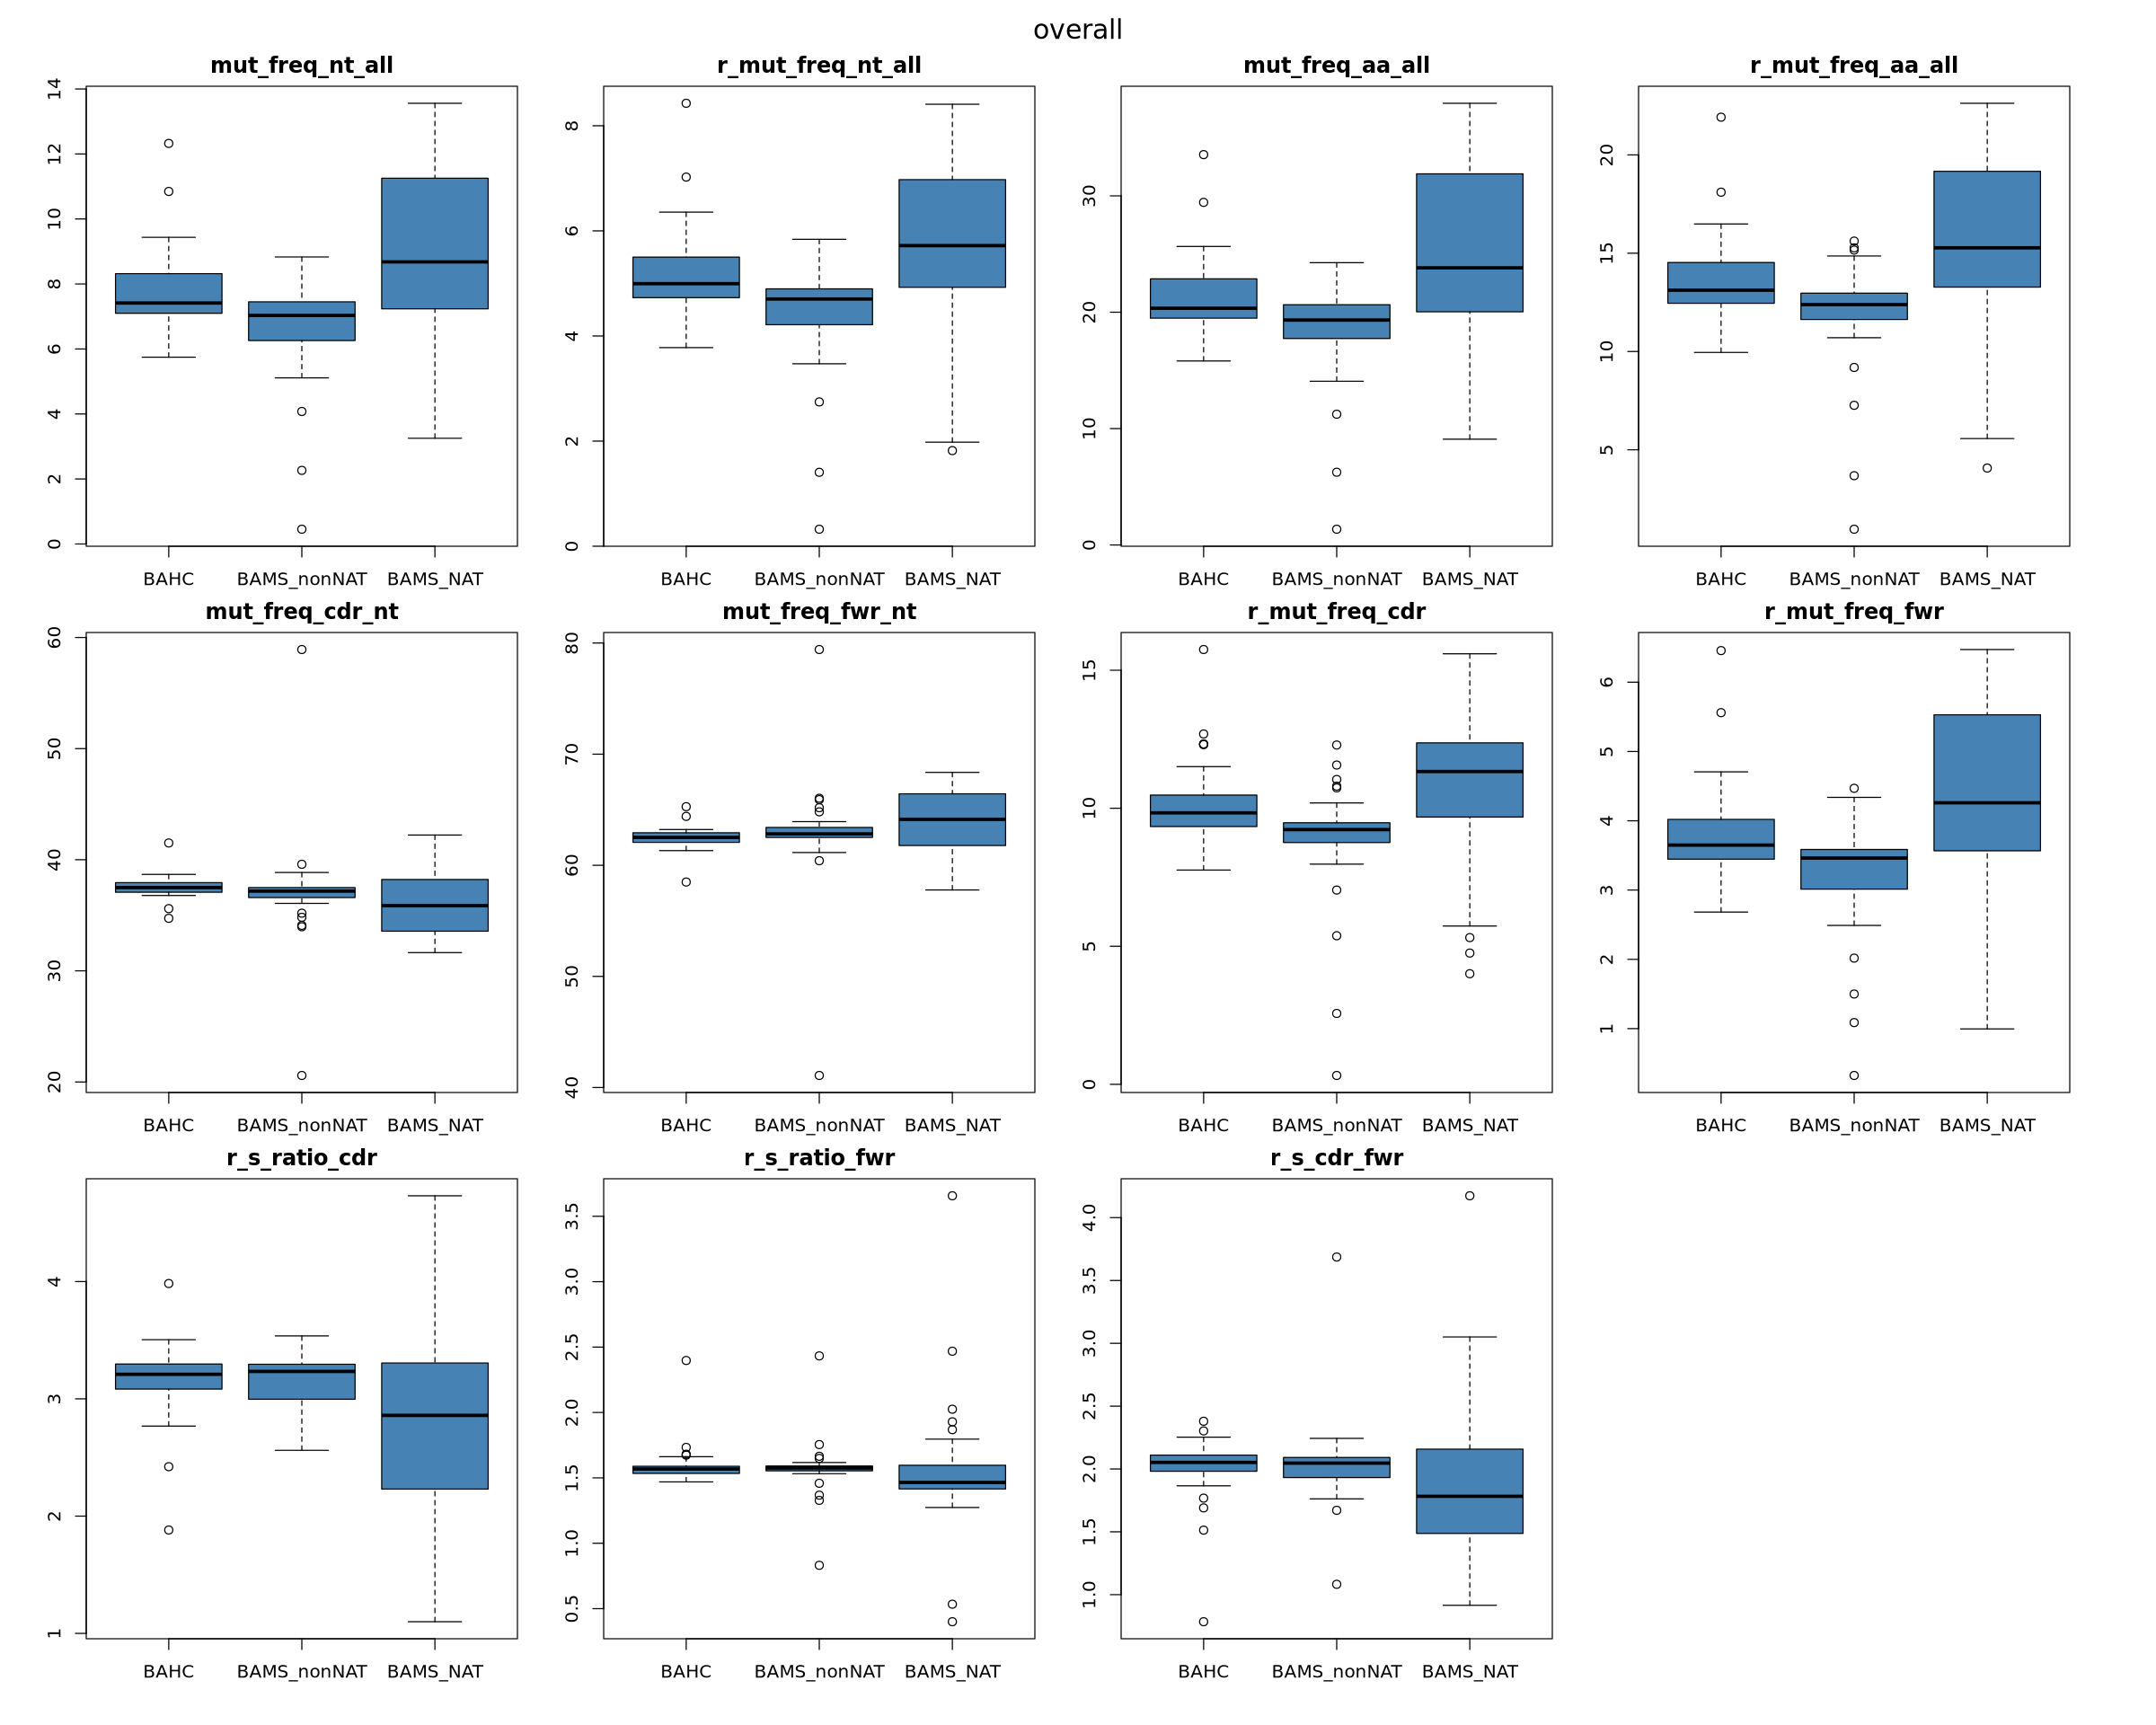

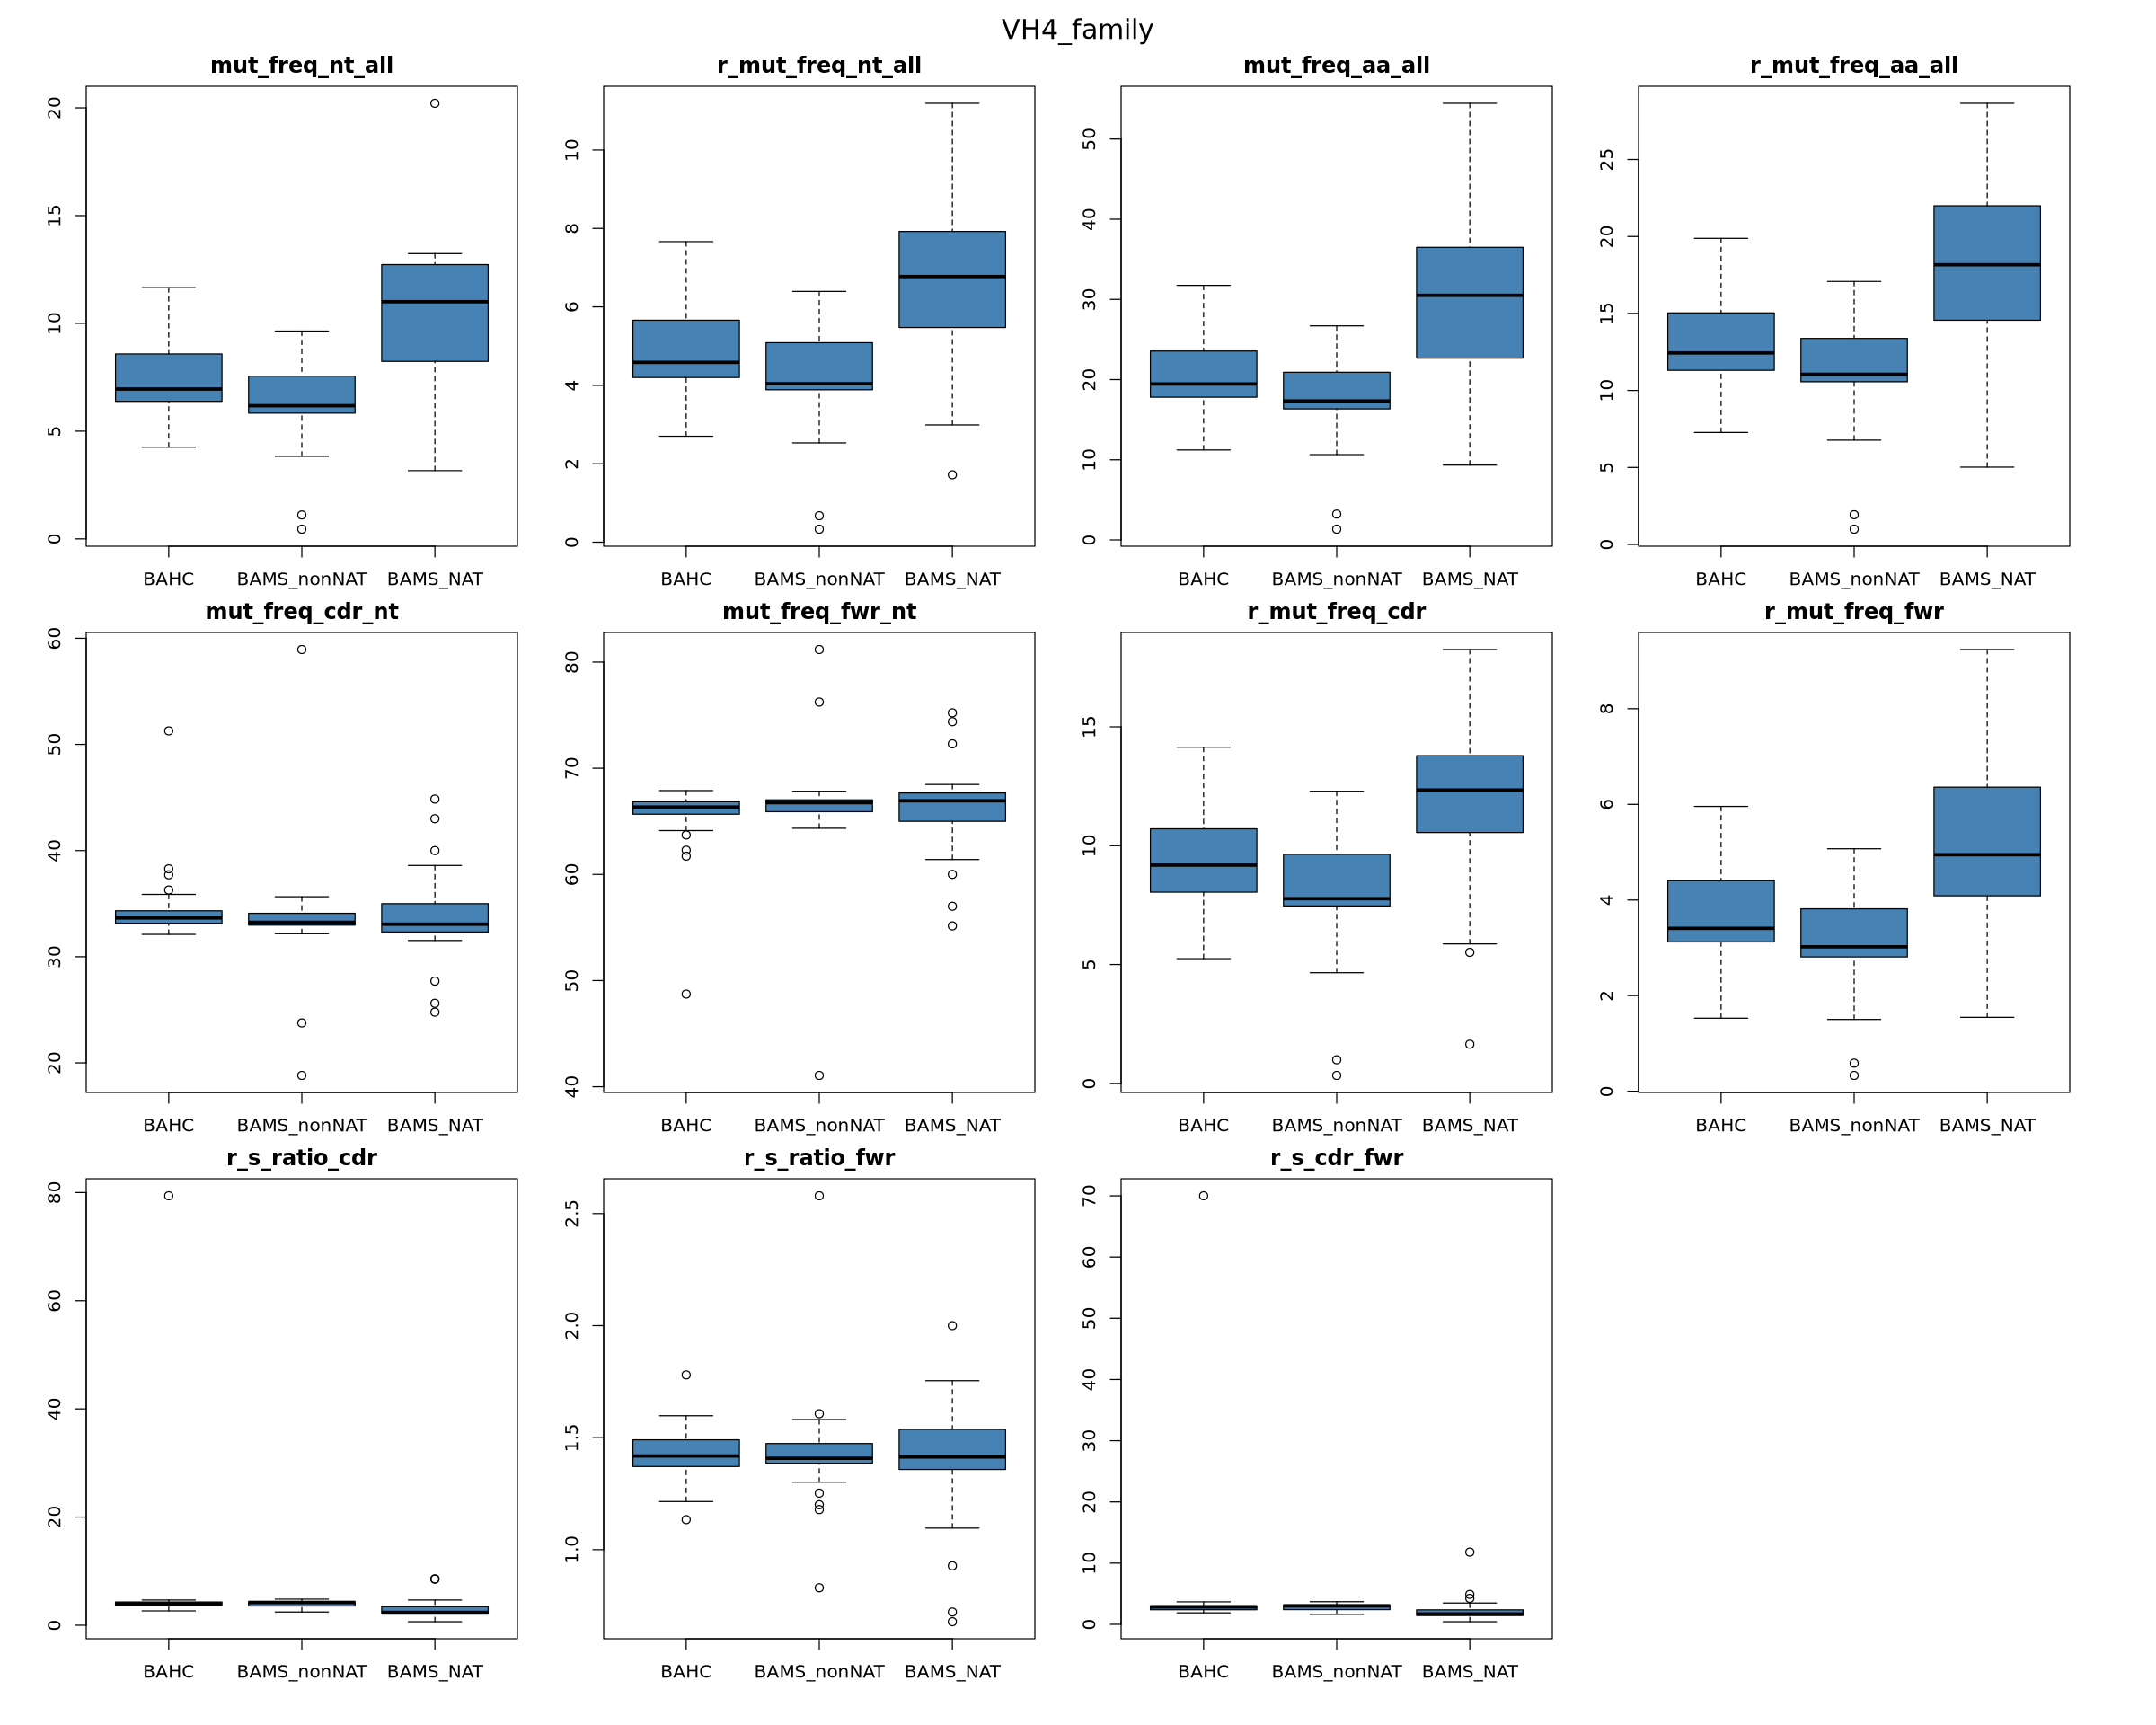

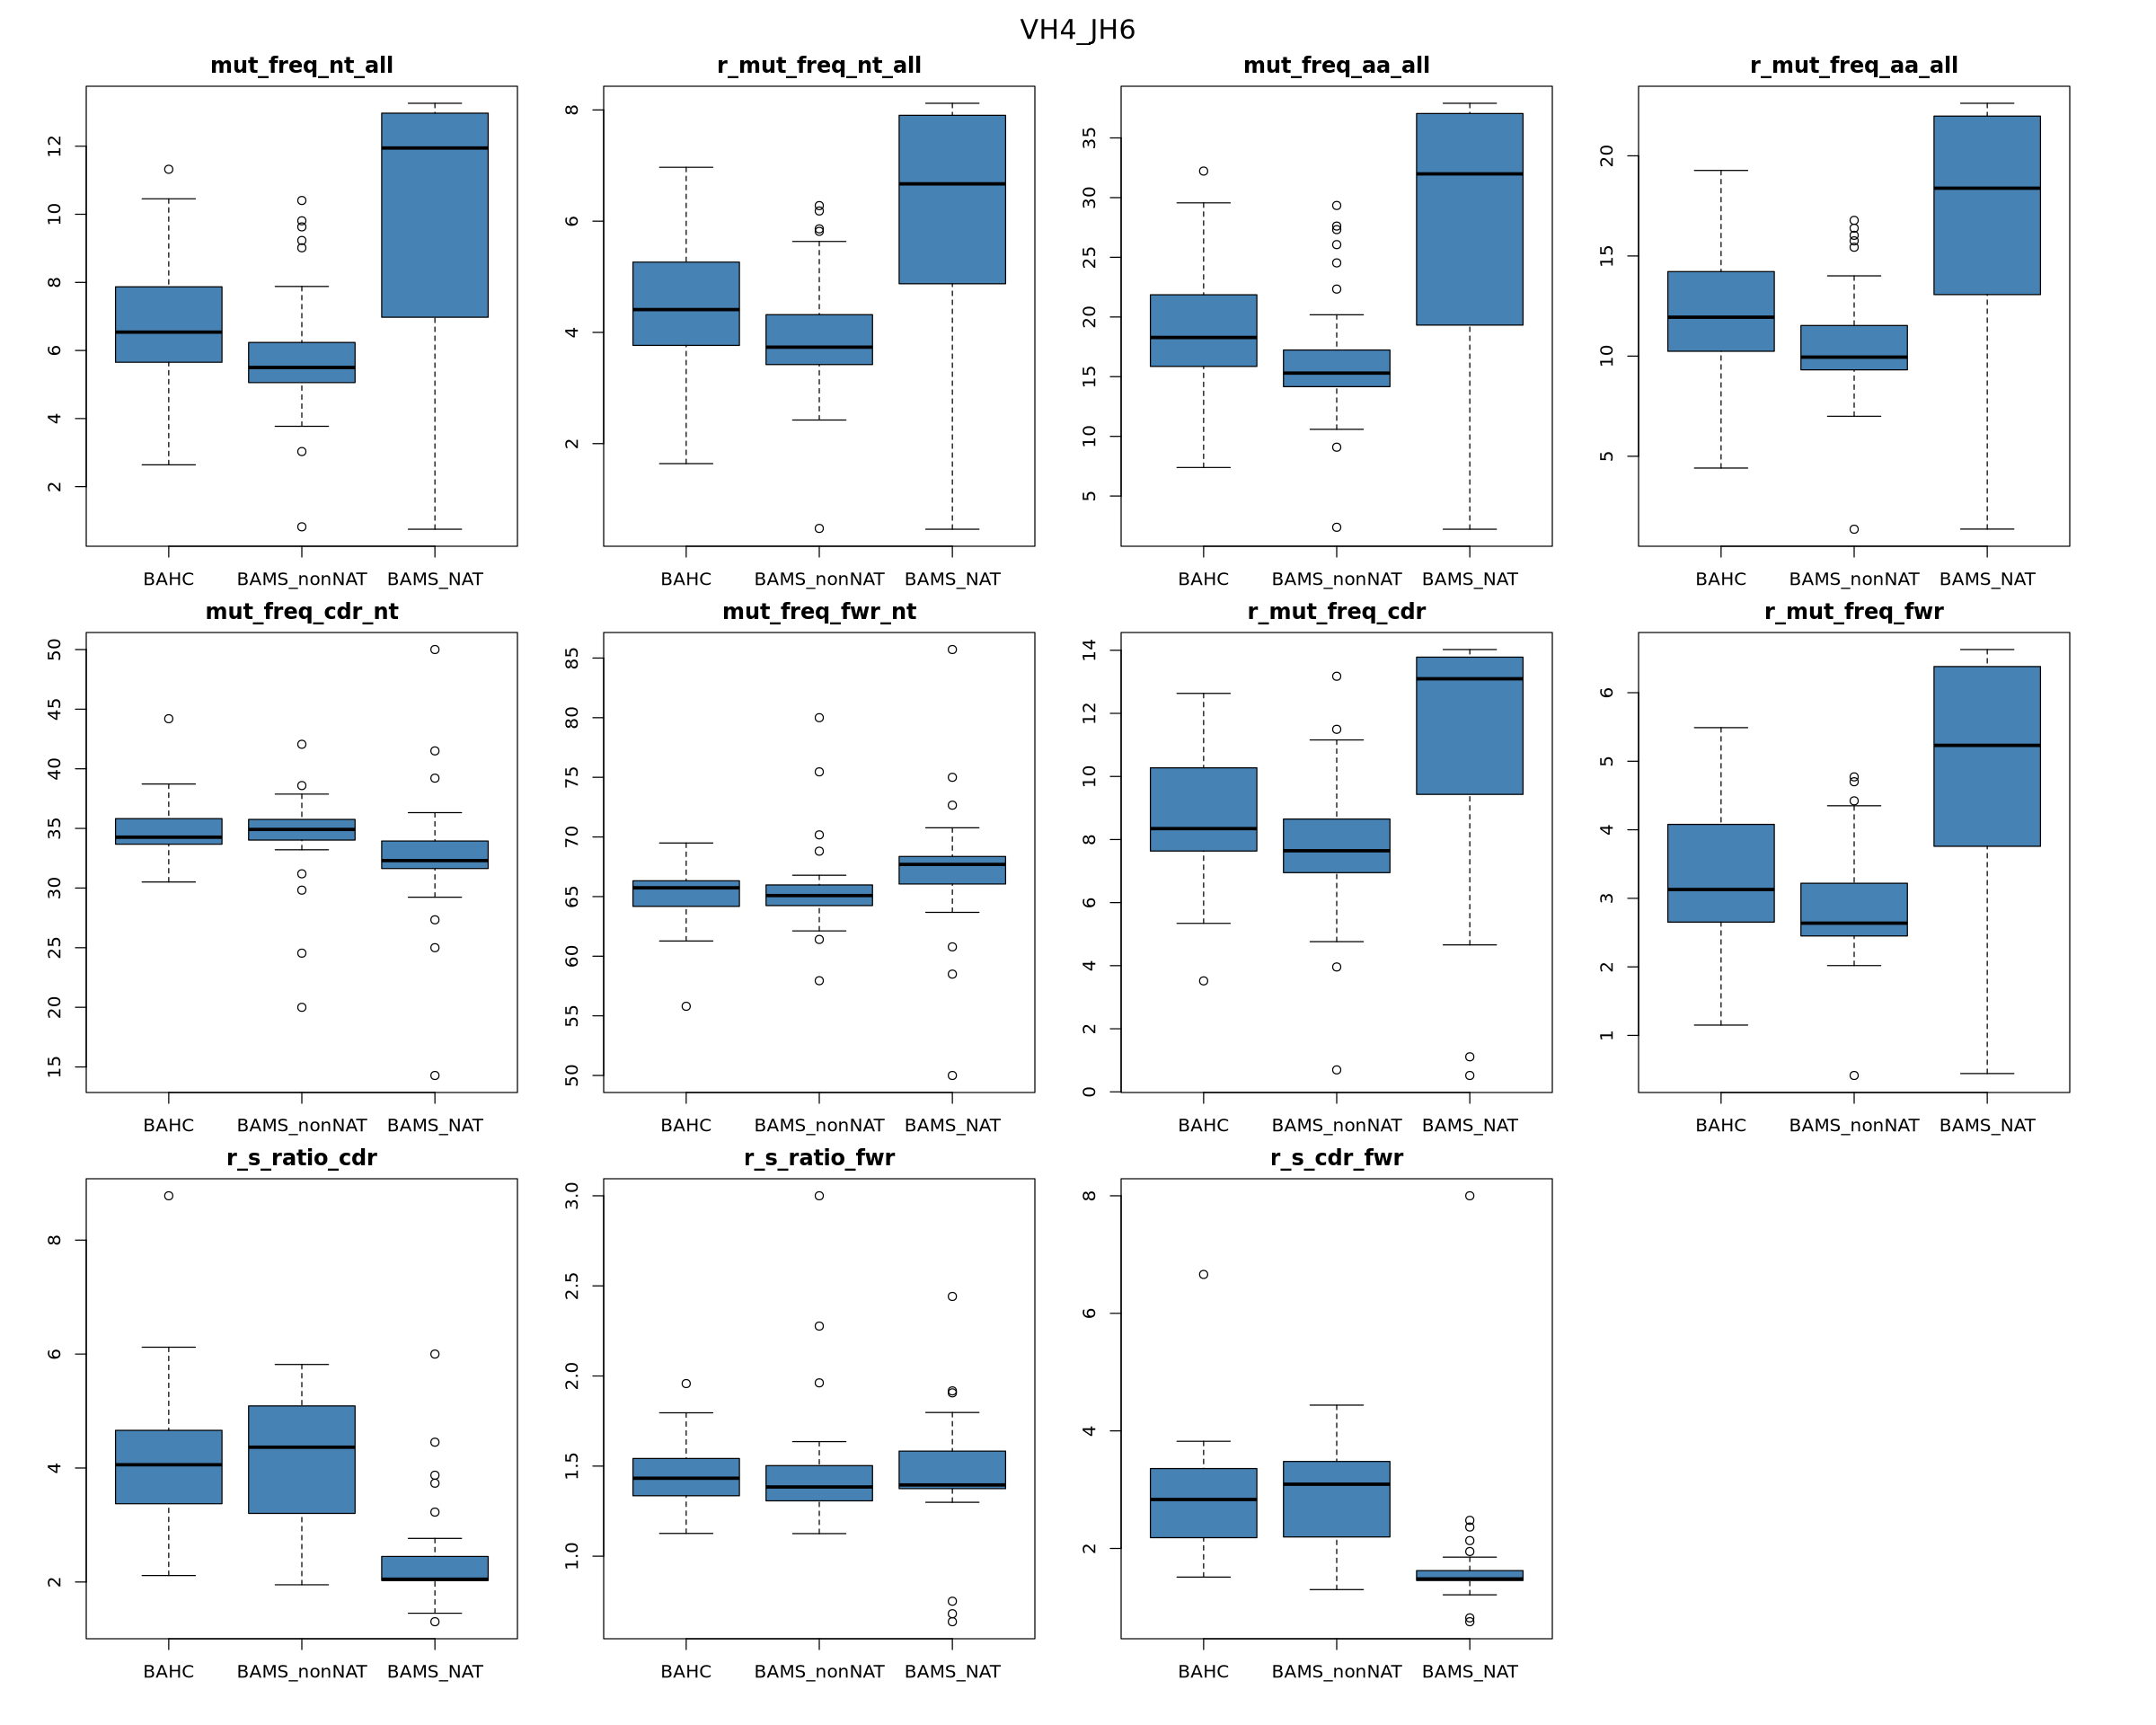

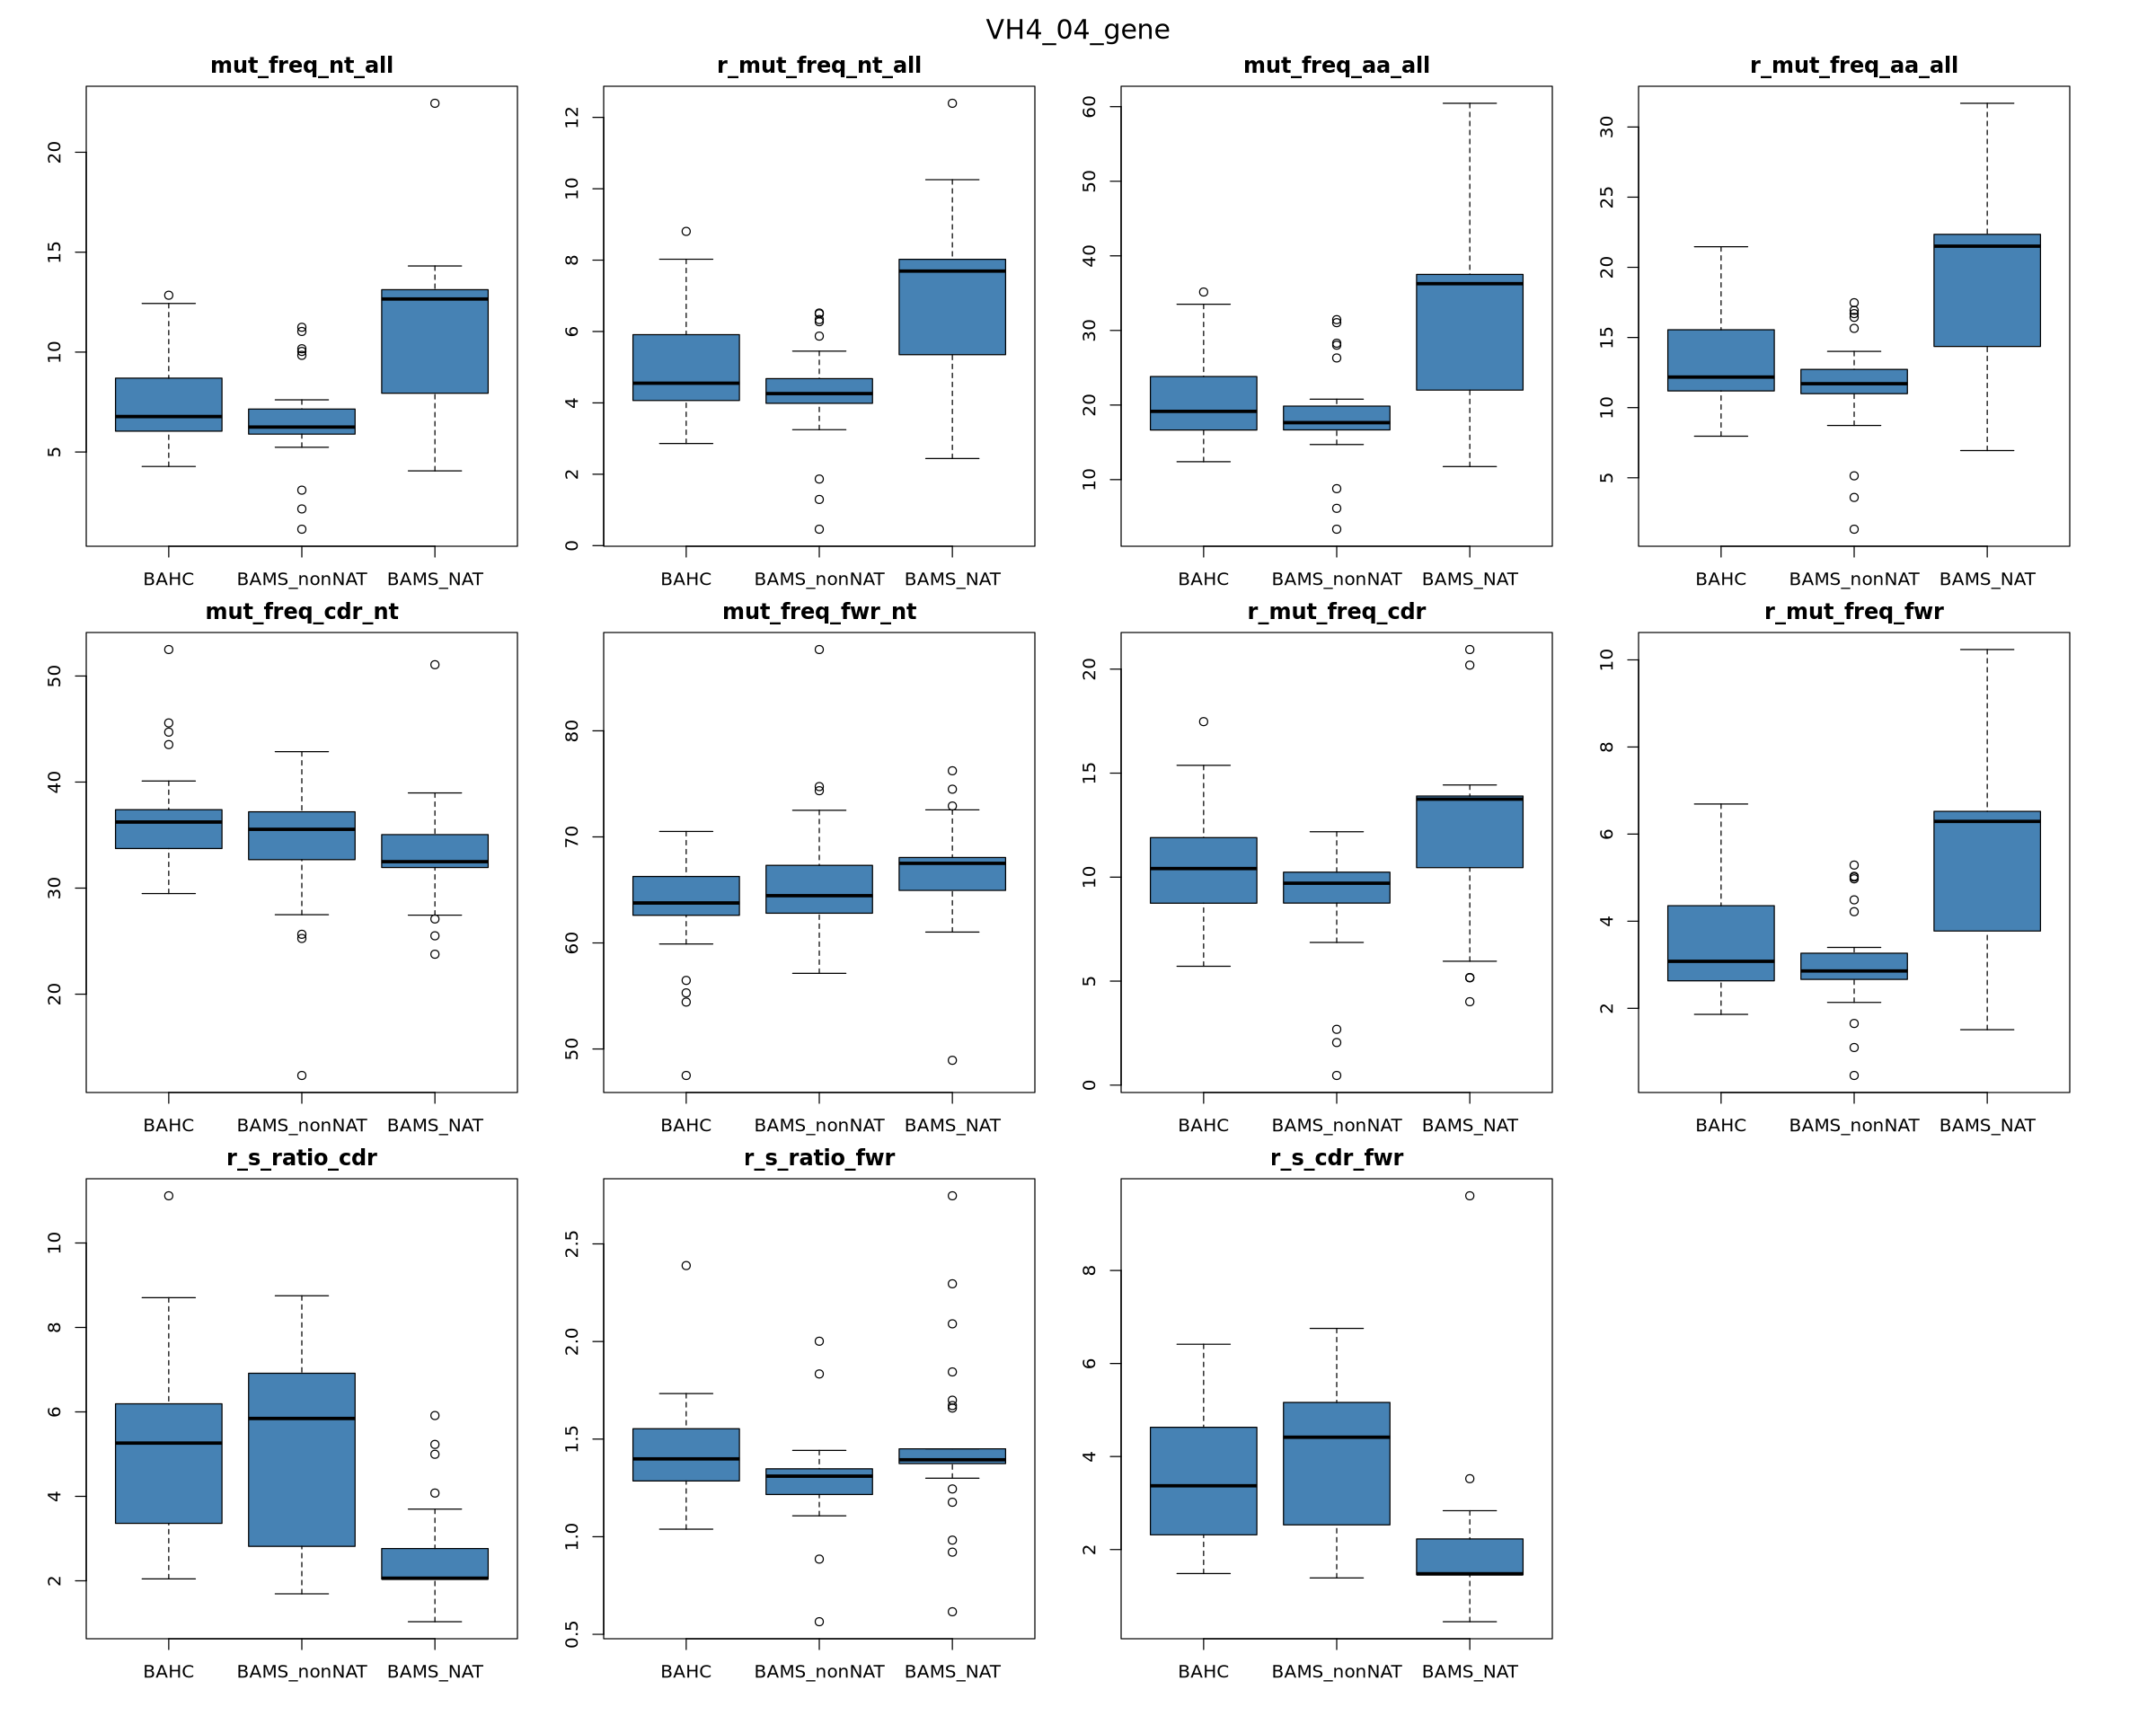

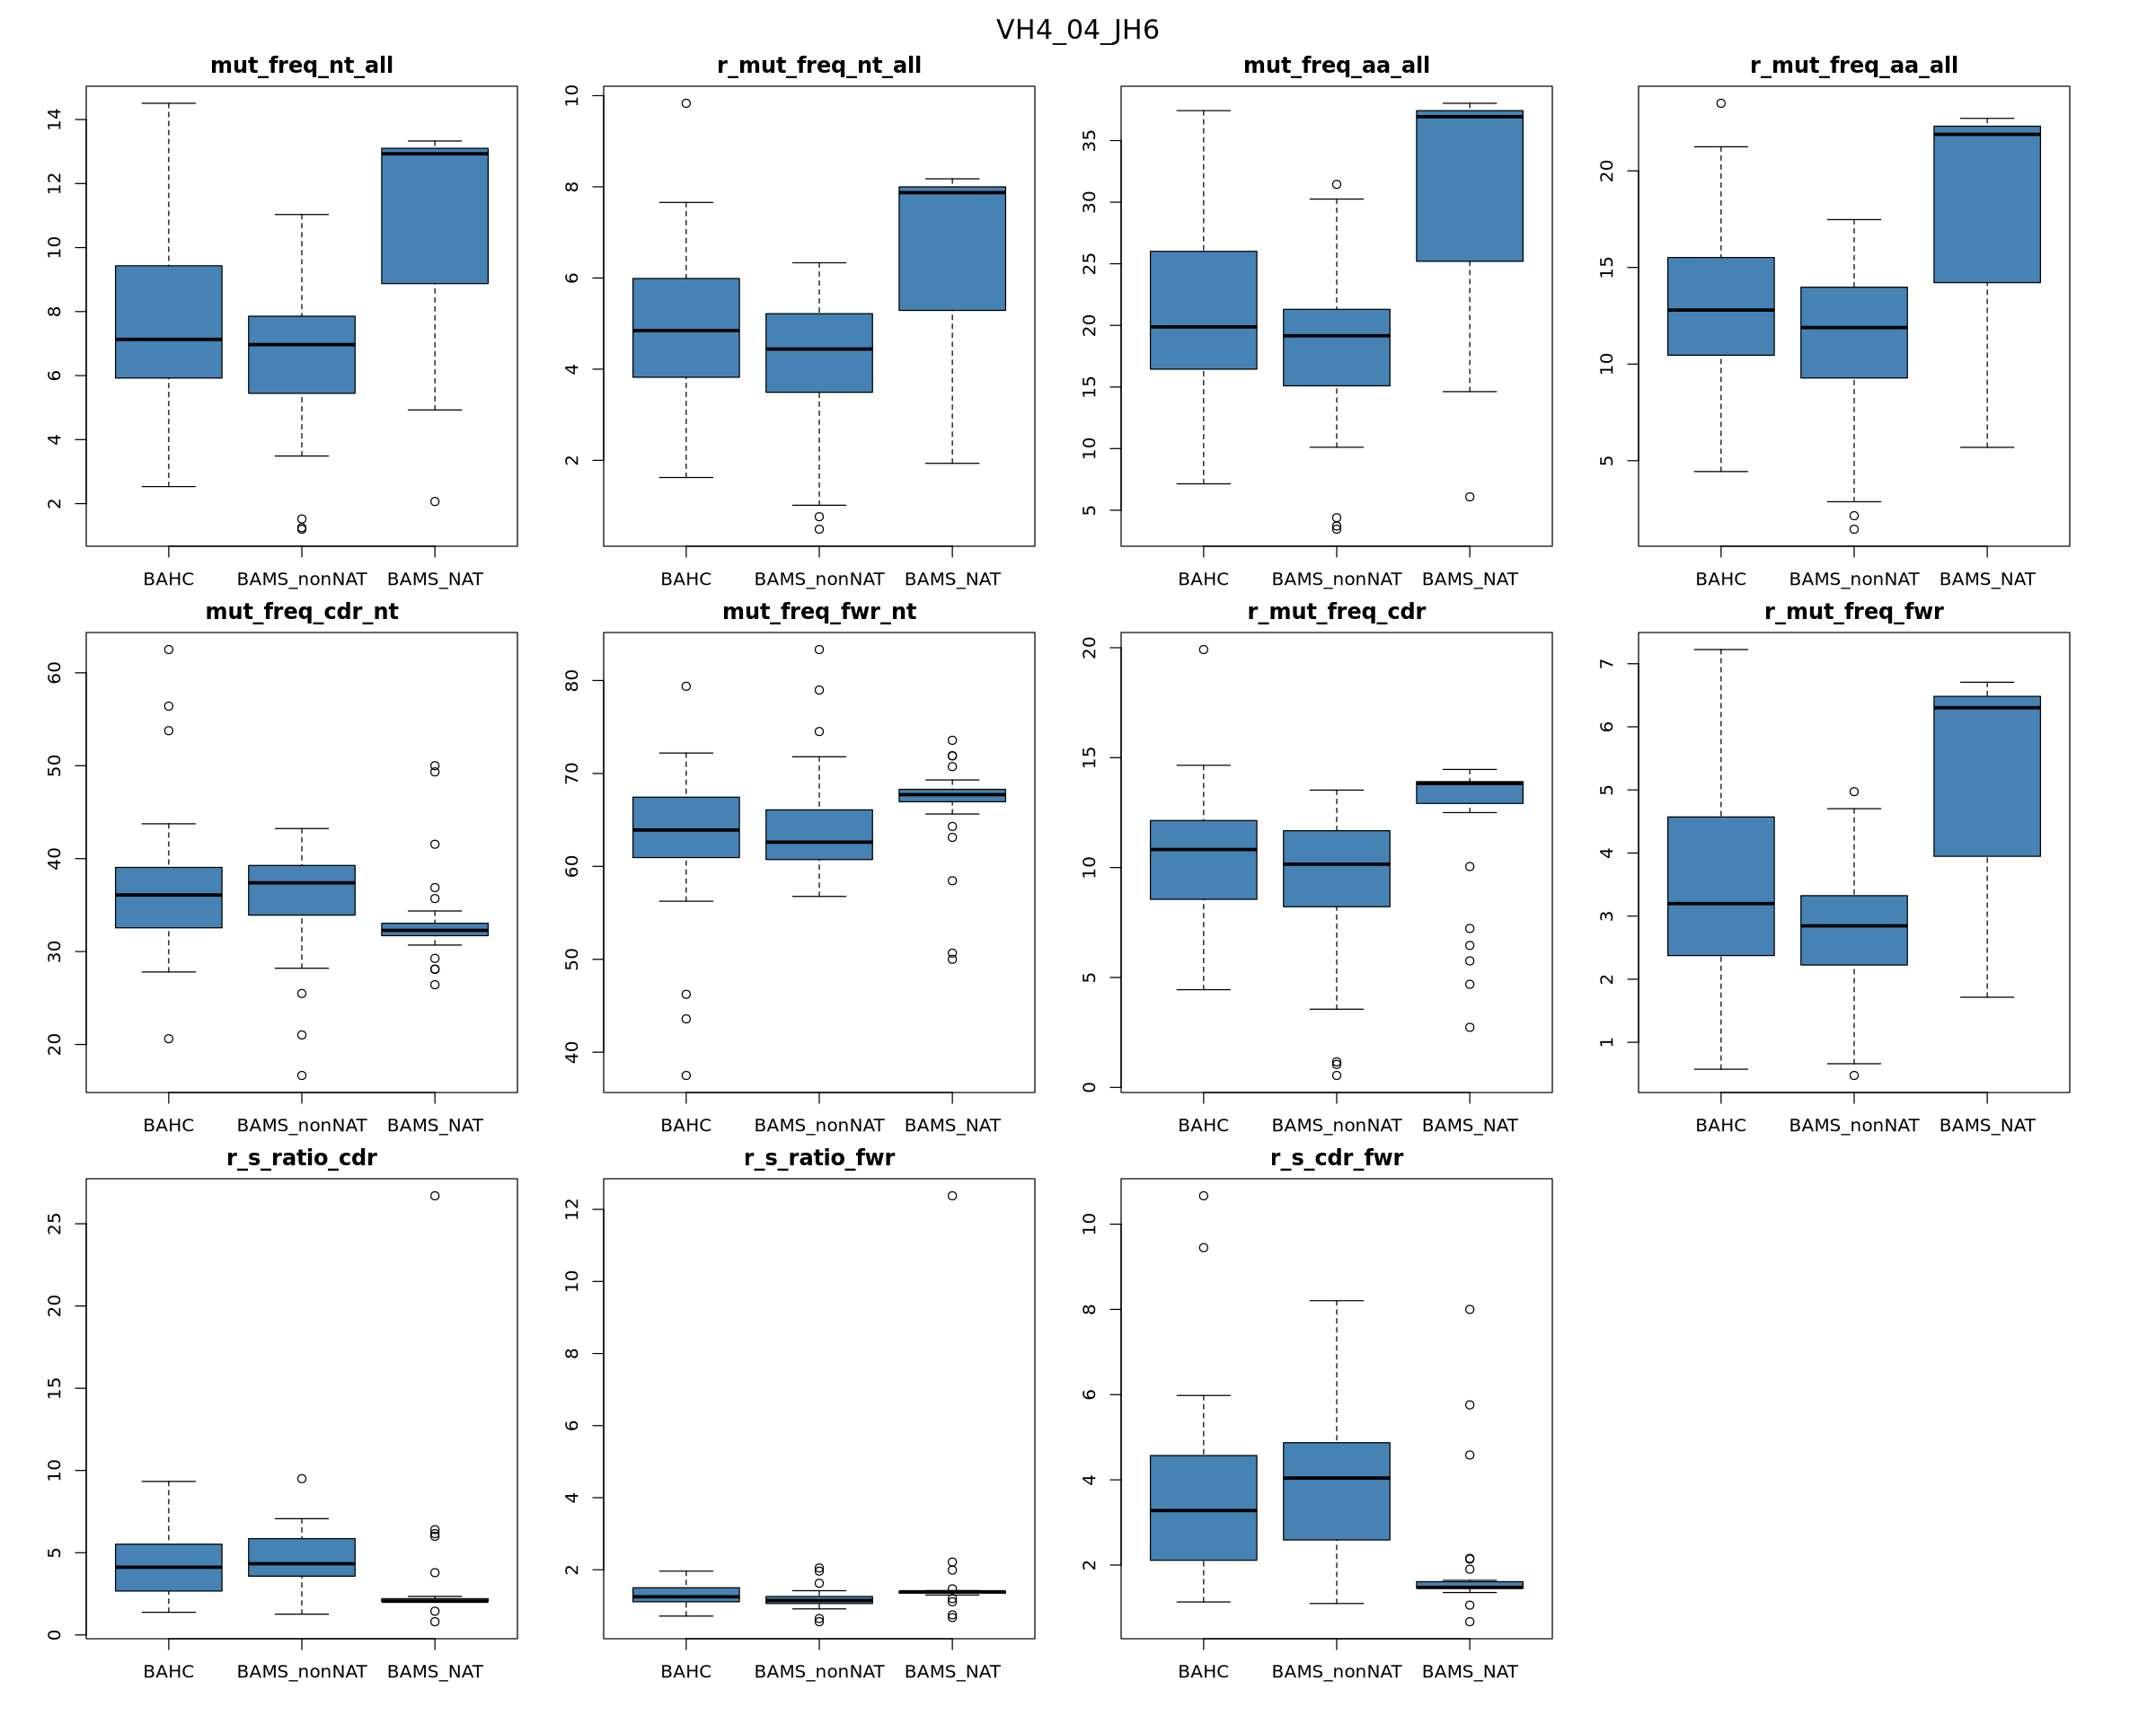

In [17]:
### variables to plot 
box_plot_vars <- c(
    "mut_freq_nt_all",
    "r_mut_freq_nt_all",
    "mut_freq_aa_all",
    "r_mut_freq_aa_all",
    "mut_freq_cdr_nt",
    "mut_freq_fwr_nt",
    "r_mut_freq_cdr",
    "r_mut_freq_fwr",
    "r_s_ratio_cdr",
    "r_s_ratio_fwr",
    "r_s_cdr_fwr"
)

### df to process
box_plot_df_list <- list(
    overall = mut_analysis_summary,
    VH4_family = mut_analysis_VH4_family,
    VH4_JH6 = mut_analysis_VH4_family_J6_gene,
    VH4_04_gene = mut_analysis_VH4_04_gene,
    VH4_04_JH6 = mut_analysis_VH4_04_gene_J6_gene
)

for (df_name in names(box_plot_df_list)) {
    options(repr.plot.width = 20, repr.plot.height = 16)

    par(
        mfrow = c(3, 4),
        mar = c(2, 2, 2, 2),
        oma = c(2, 2, 2, 2), 
        bg = "white",
        cex = 1
    )

    box_plot_df <- box_plot_df_list[[df_name]]

    for (var in box_plot_vars) {

        formula <- as.formula(
            paste(var, "~group_ID")
        )

        boxplot(
            formula,
            data = box_plot_df,
            col = "steelblue",
            main = var
        )
    }
    mtext(df_name, outer = TRUE, cex = 1.5)
}

##### control comparisons box plots

Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 2 is not drawn”


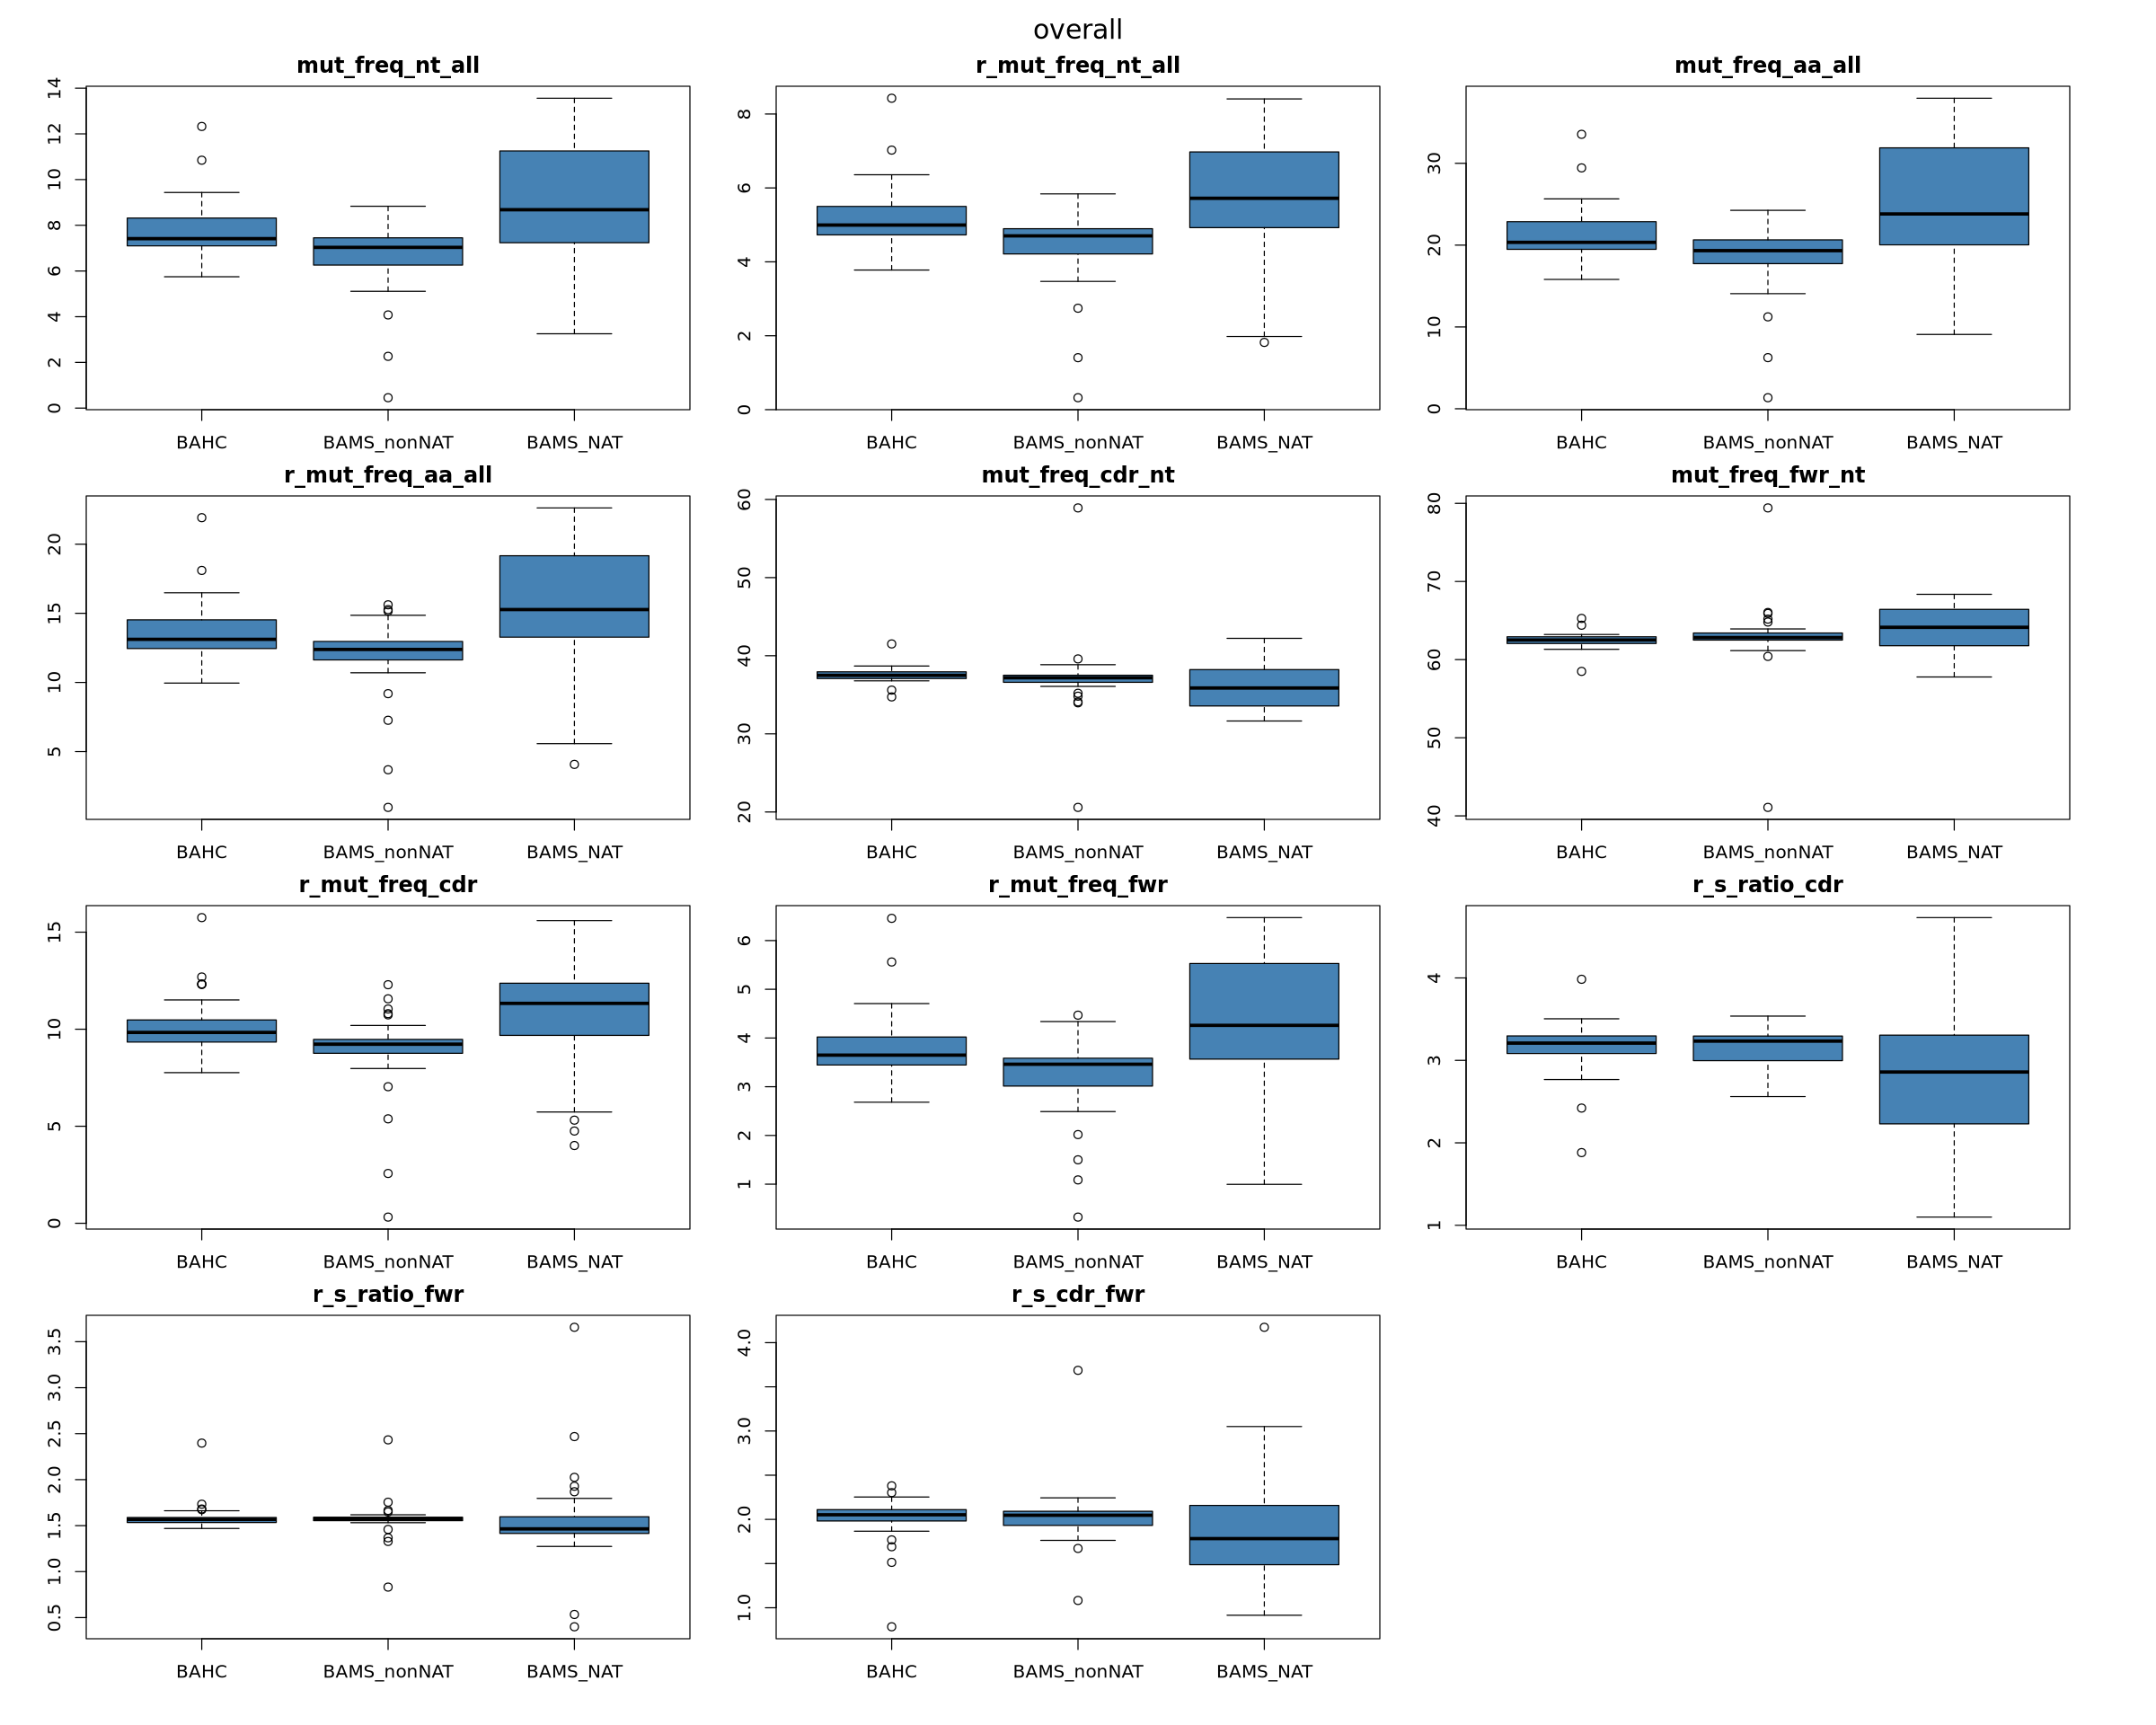

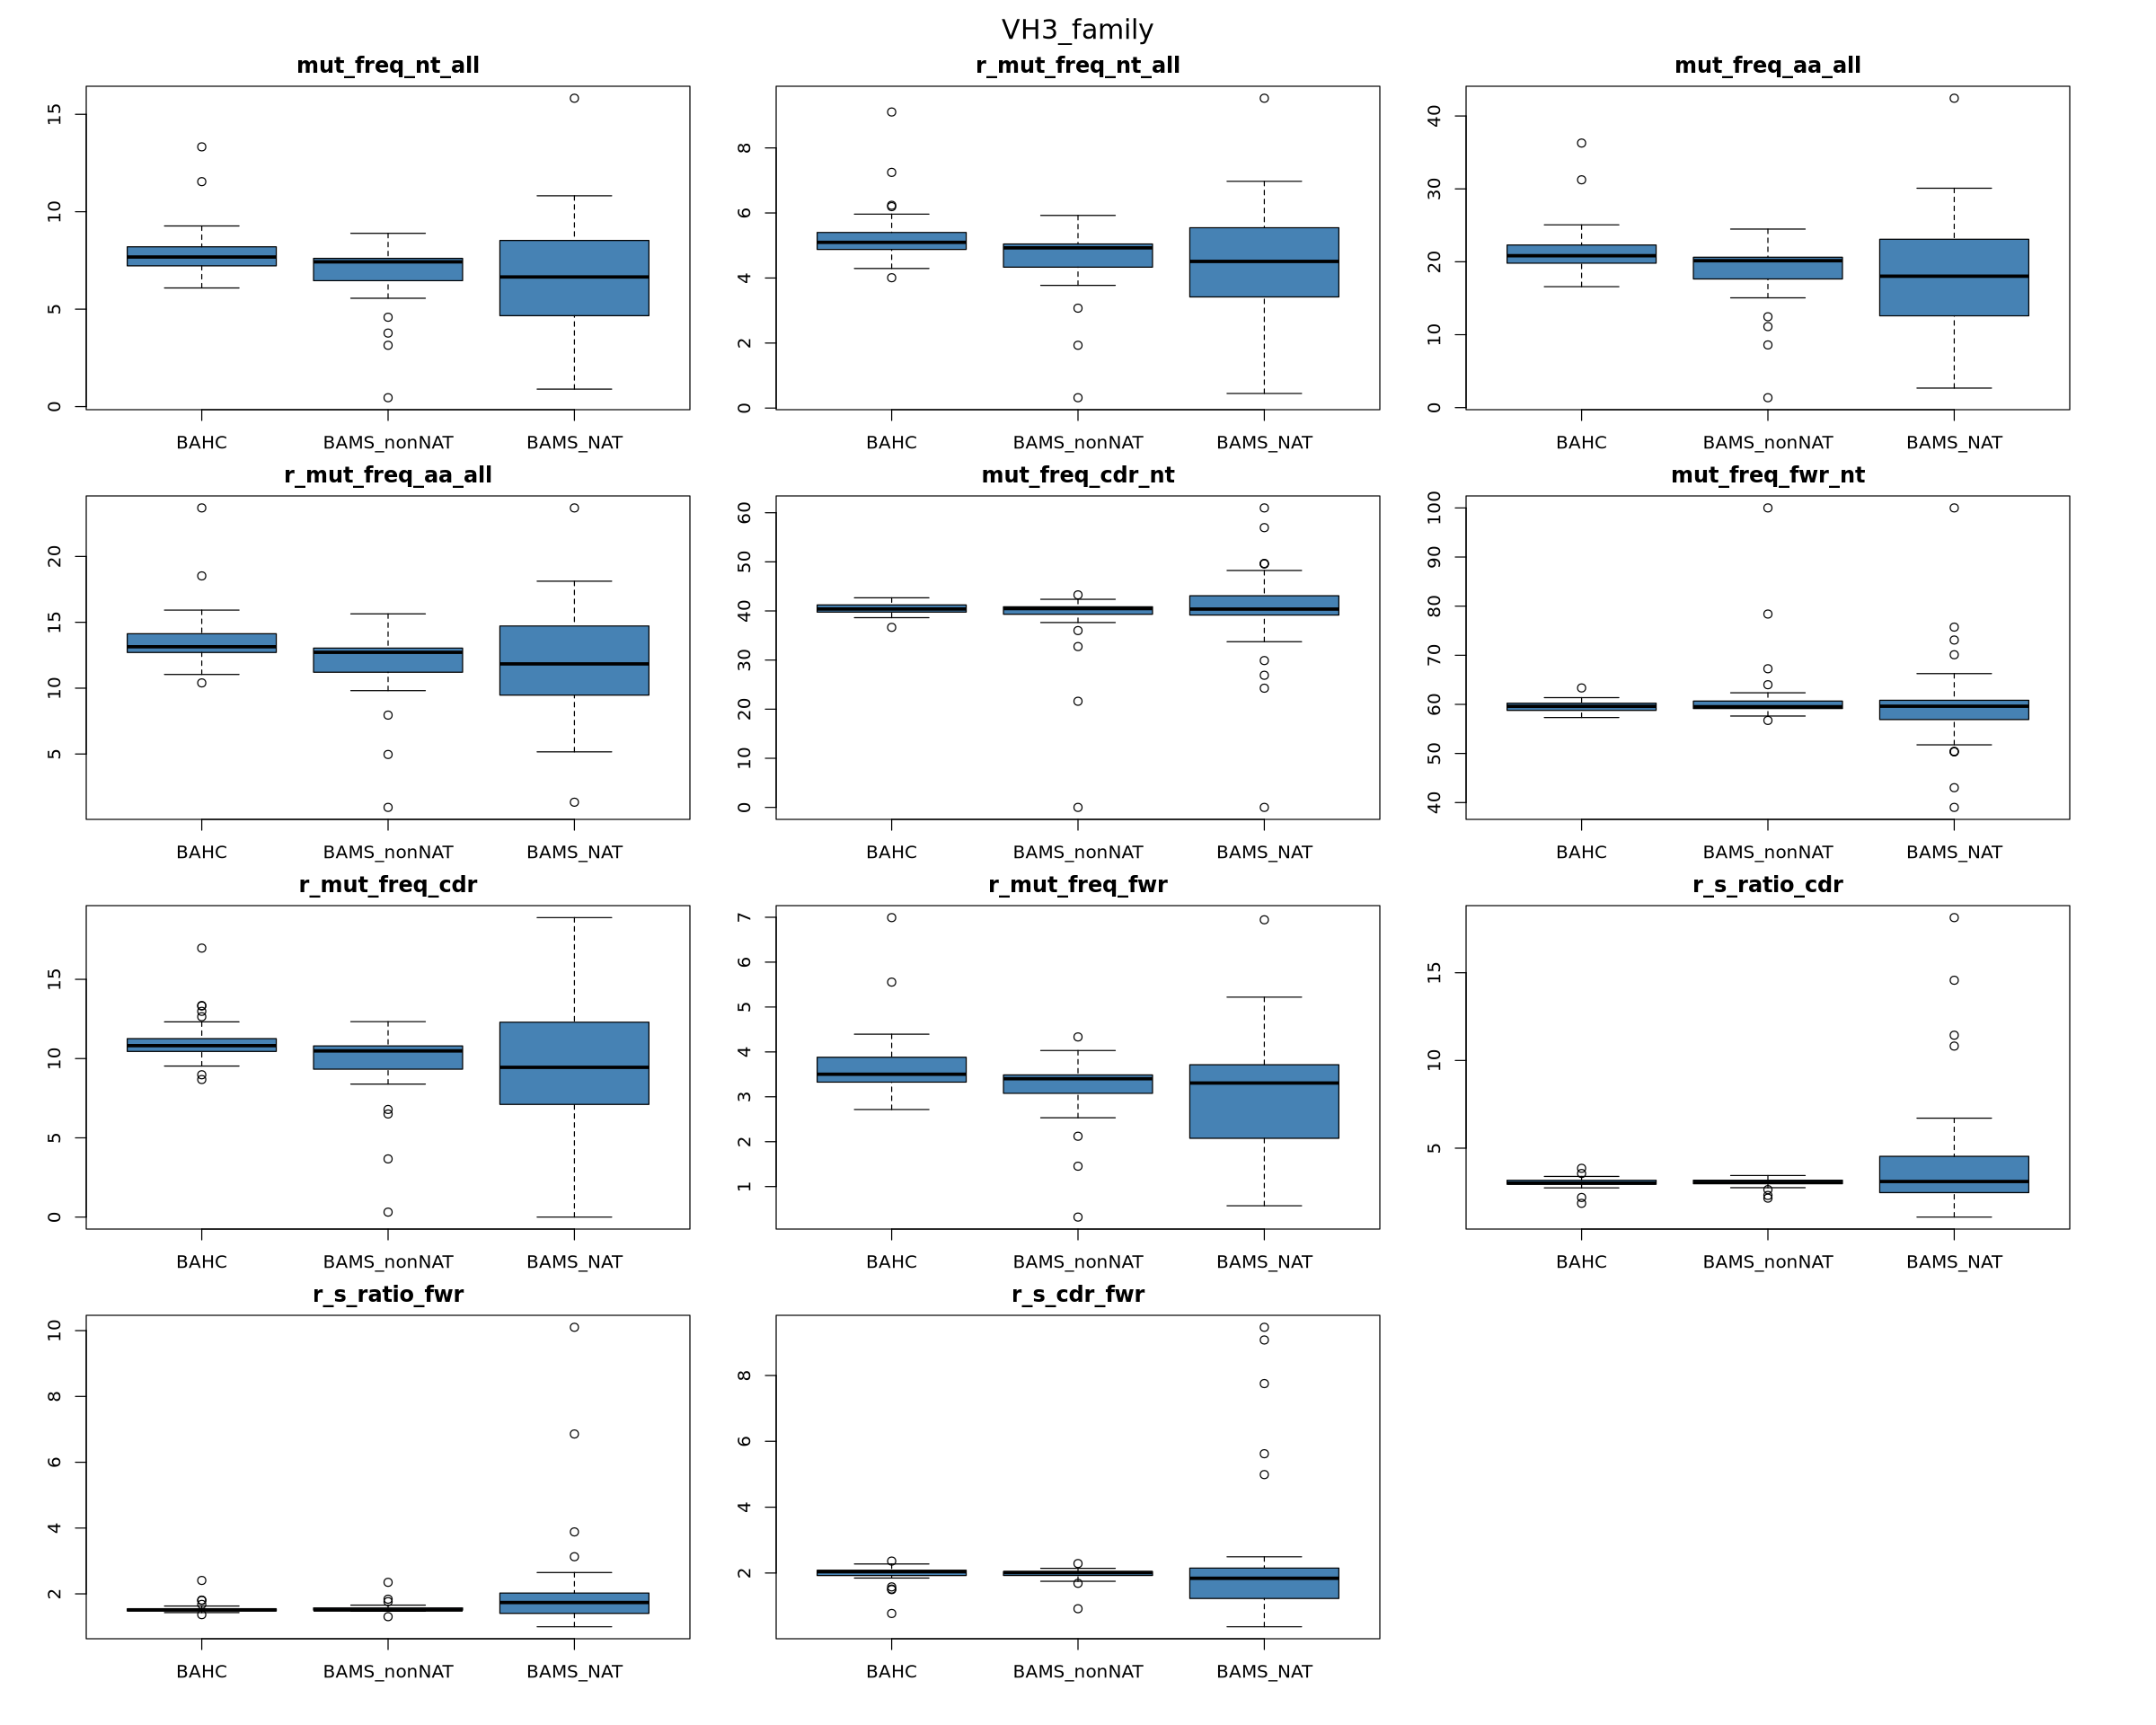

Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 1 is not drawn”
Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 2 is not drawn”
Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 3 is not drawn”
Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 1 is not drawn”
Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 2 is not drawn”
Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 3 is not drawn”
Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 1 is not drawn”
Warning message in bplt(at[i], wid = width[i], s

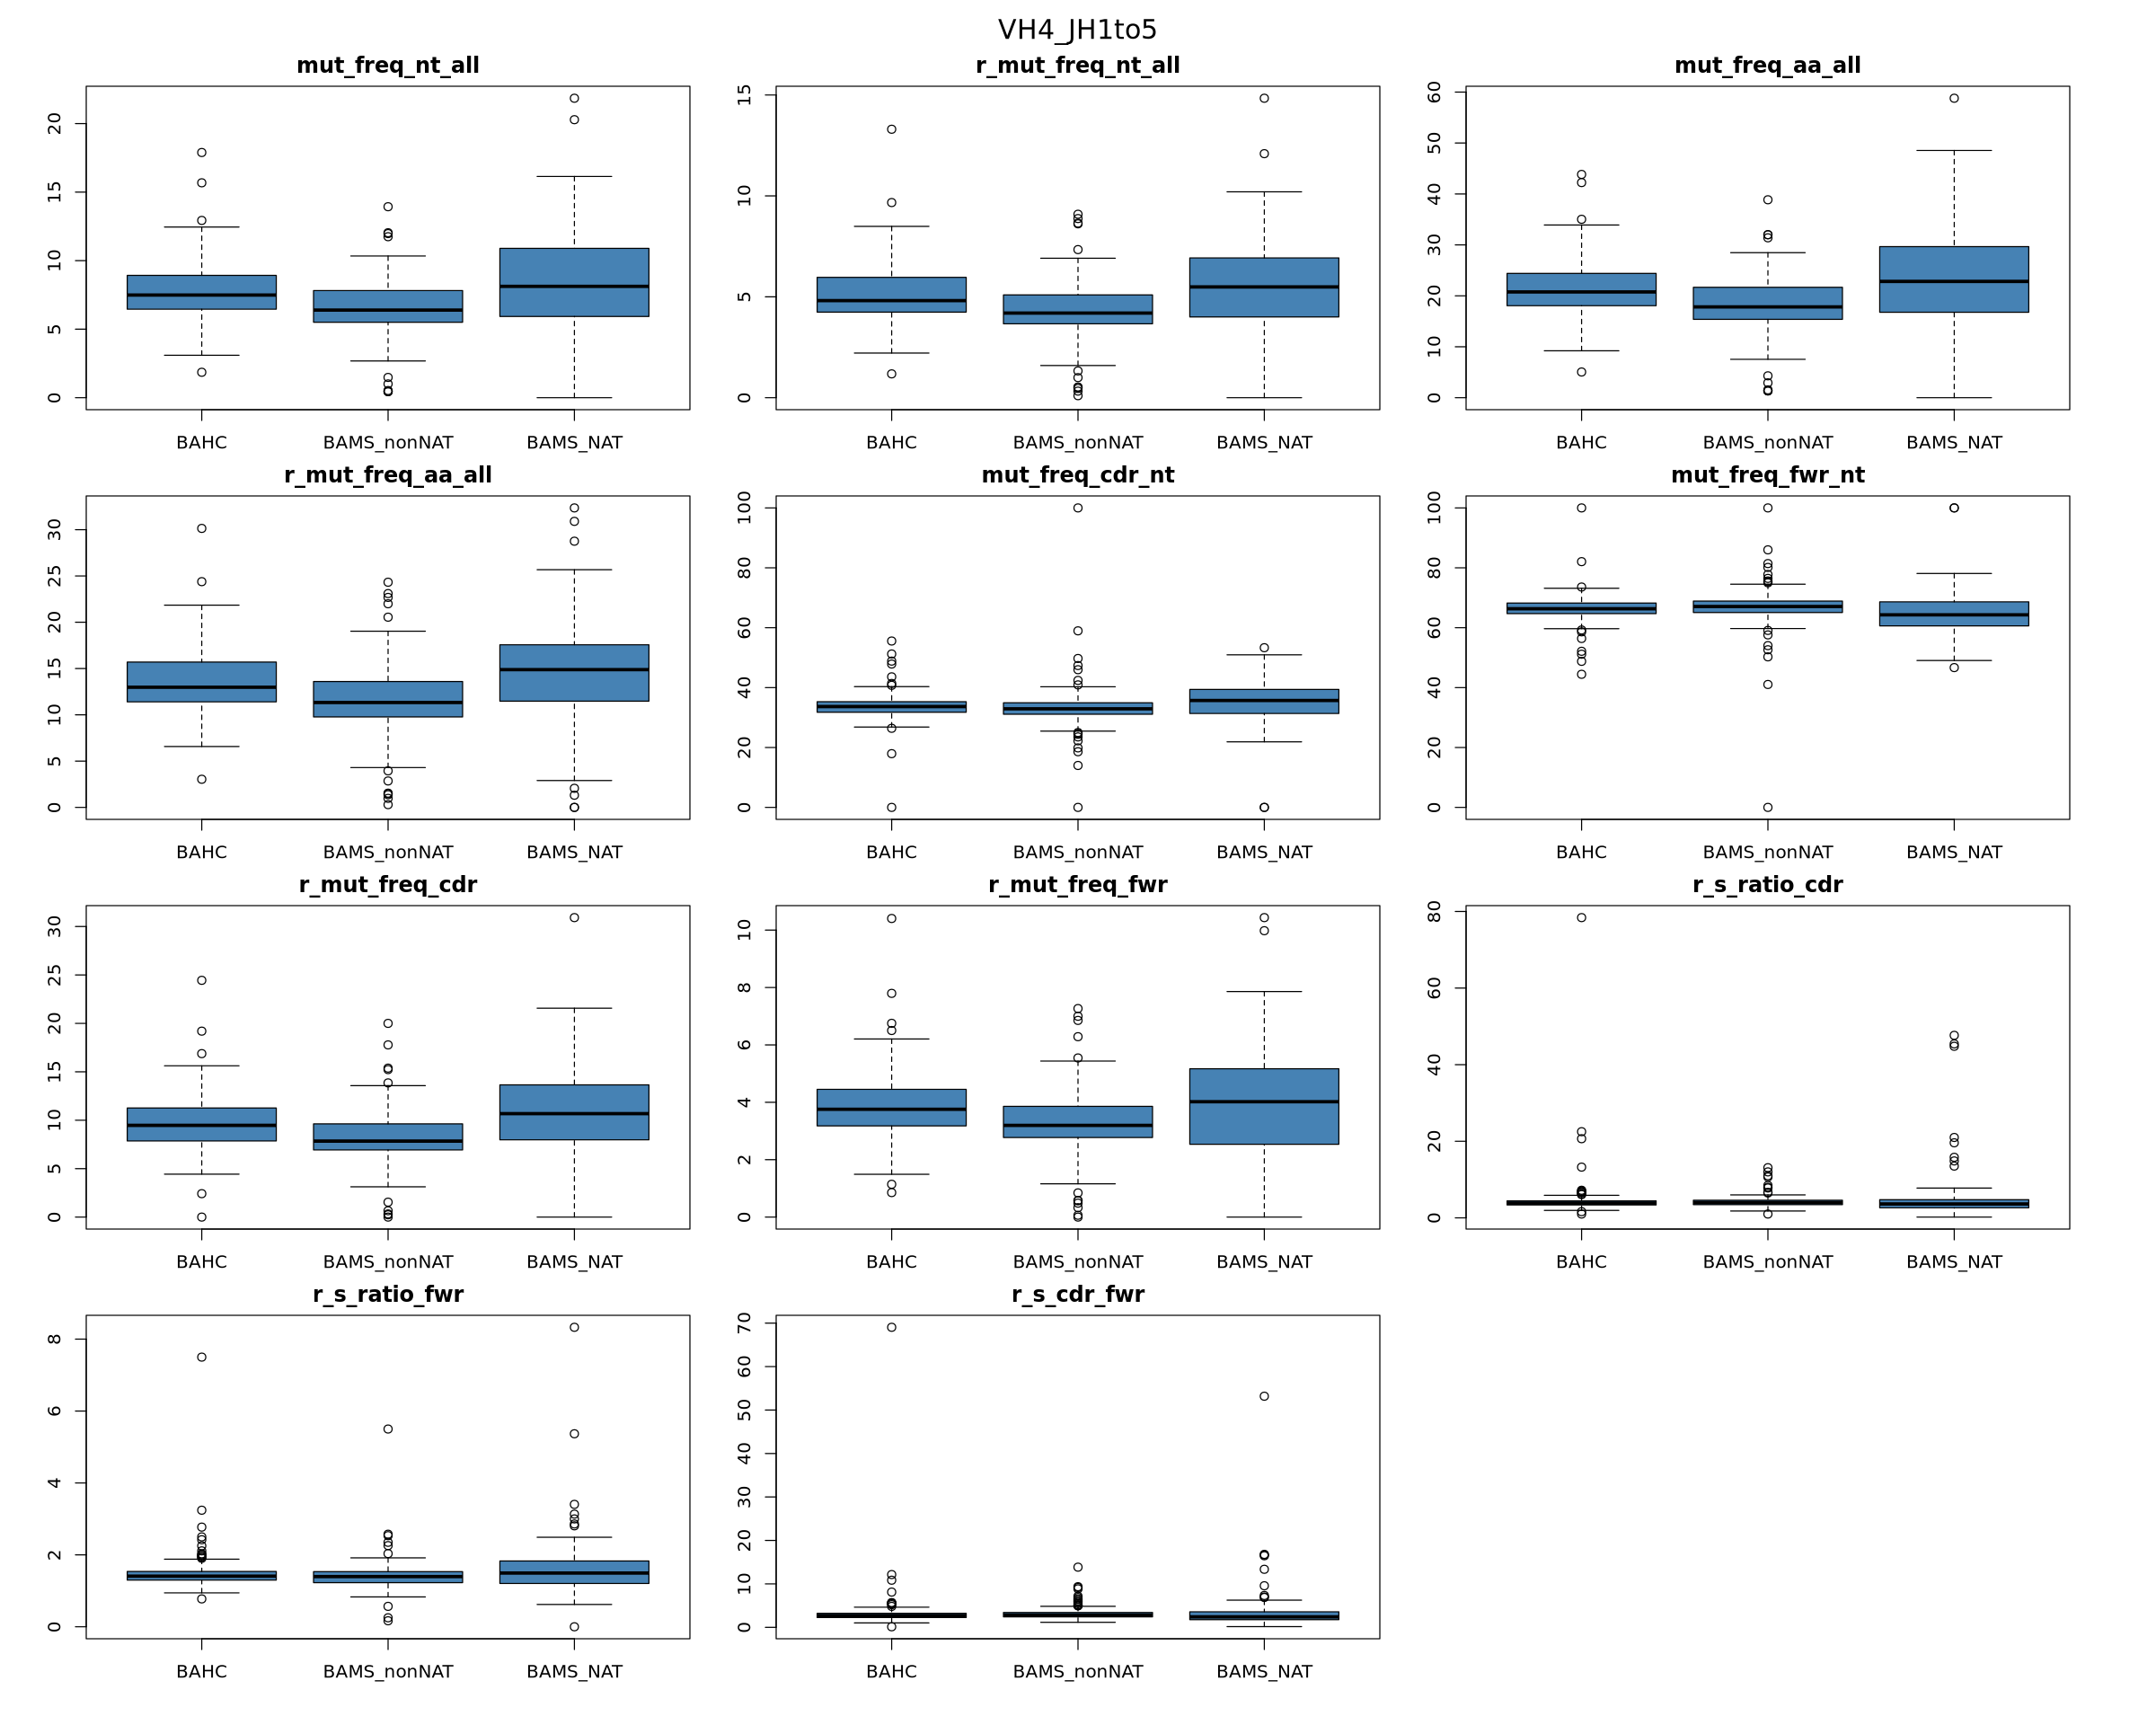

Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 1 is not drawn”
Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 2 is not drawn”
Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 3 is not drawn”
Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 1 is not drawn”
Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 2 is not drawn”
Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 3 is not drawn”
Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 1 is not drawn”
Warning message in bplt(at[i], wid = width[i], s

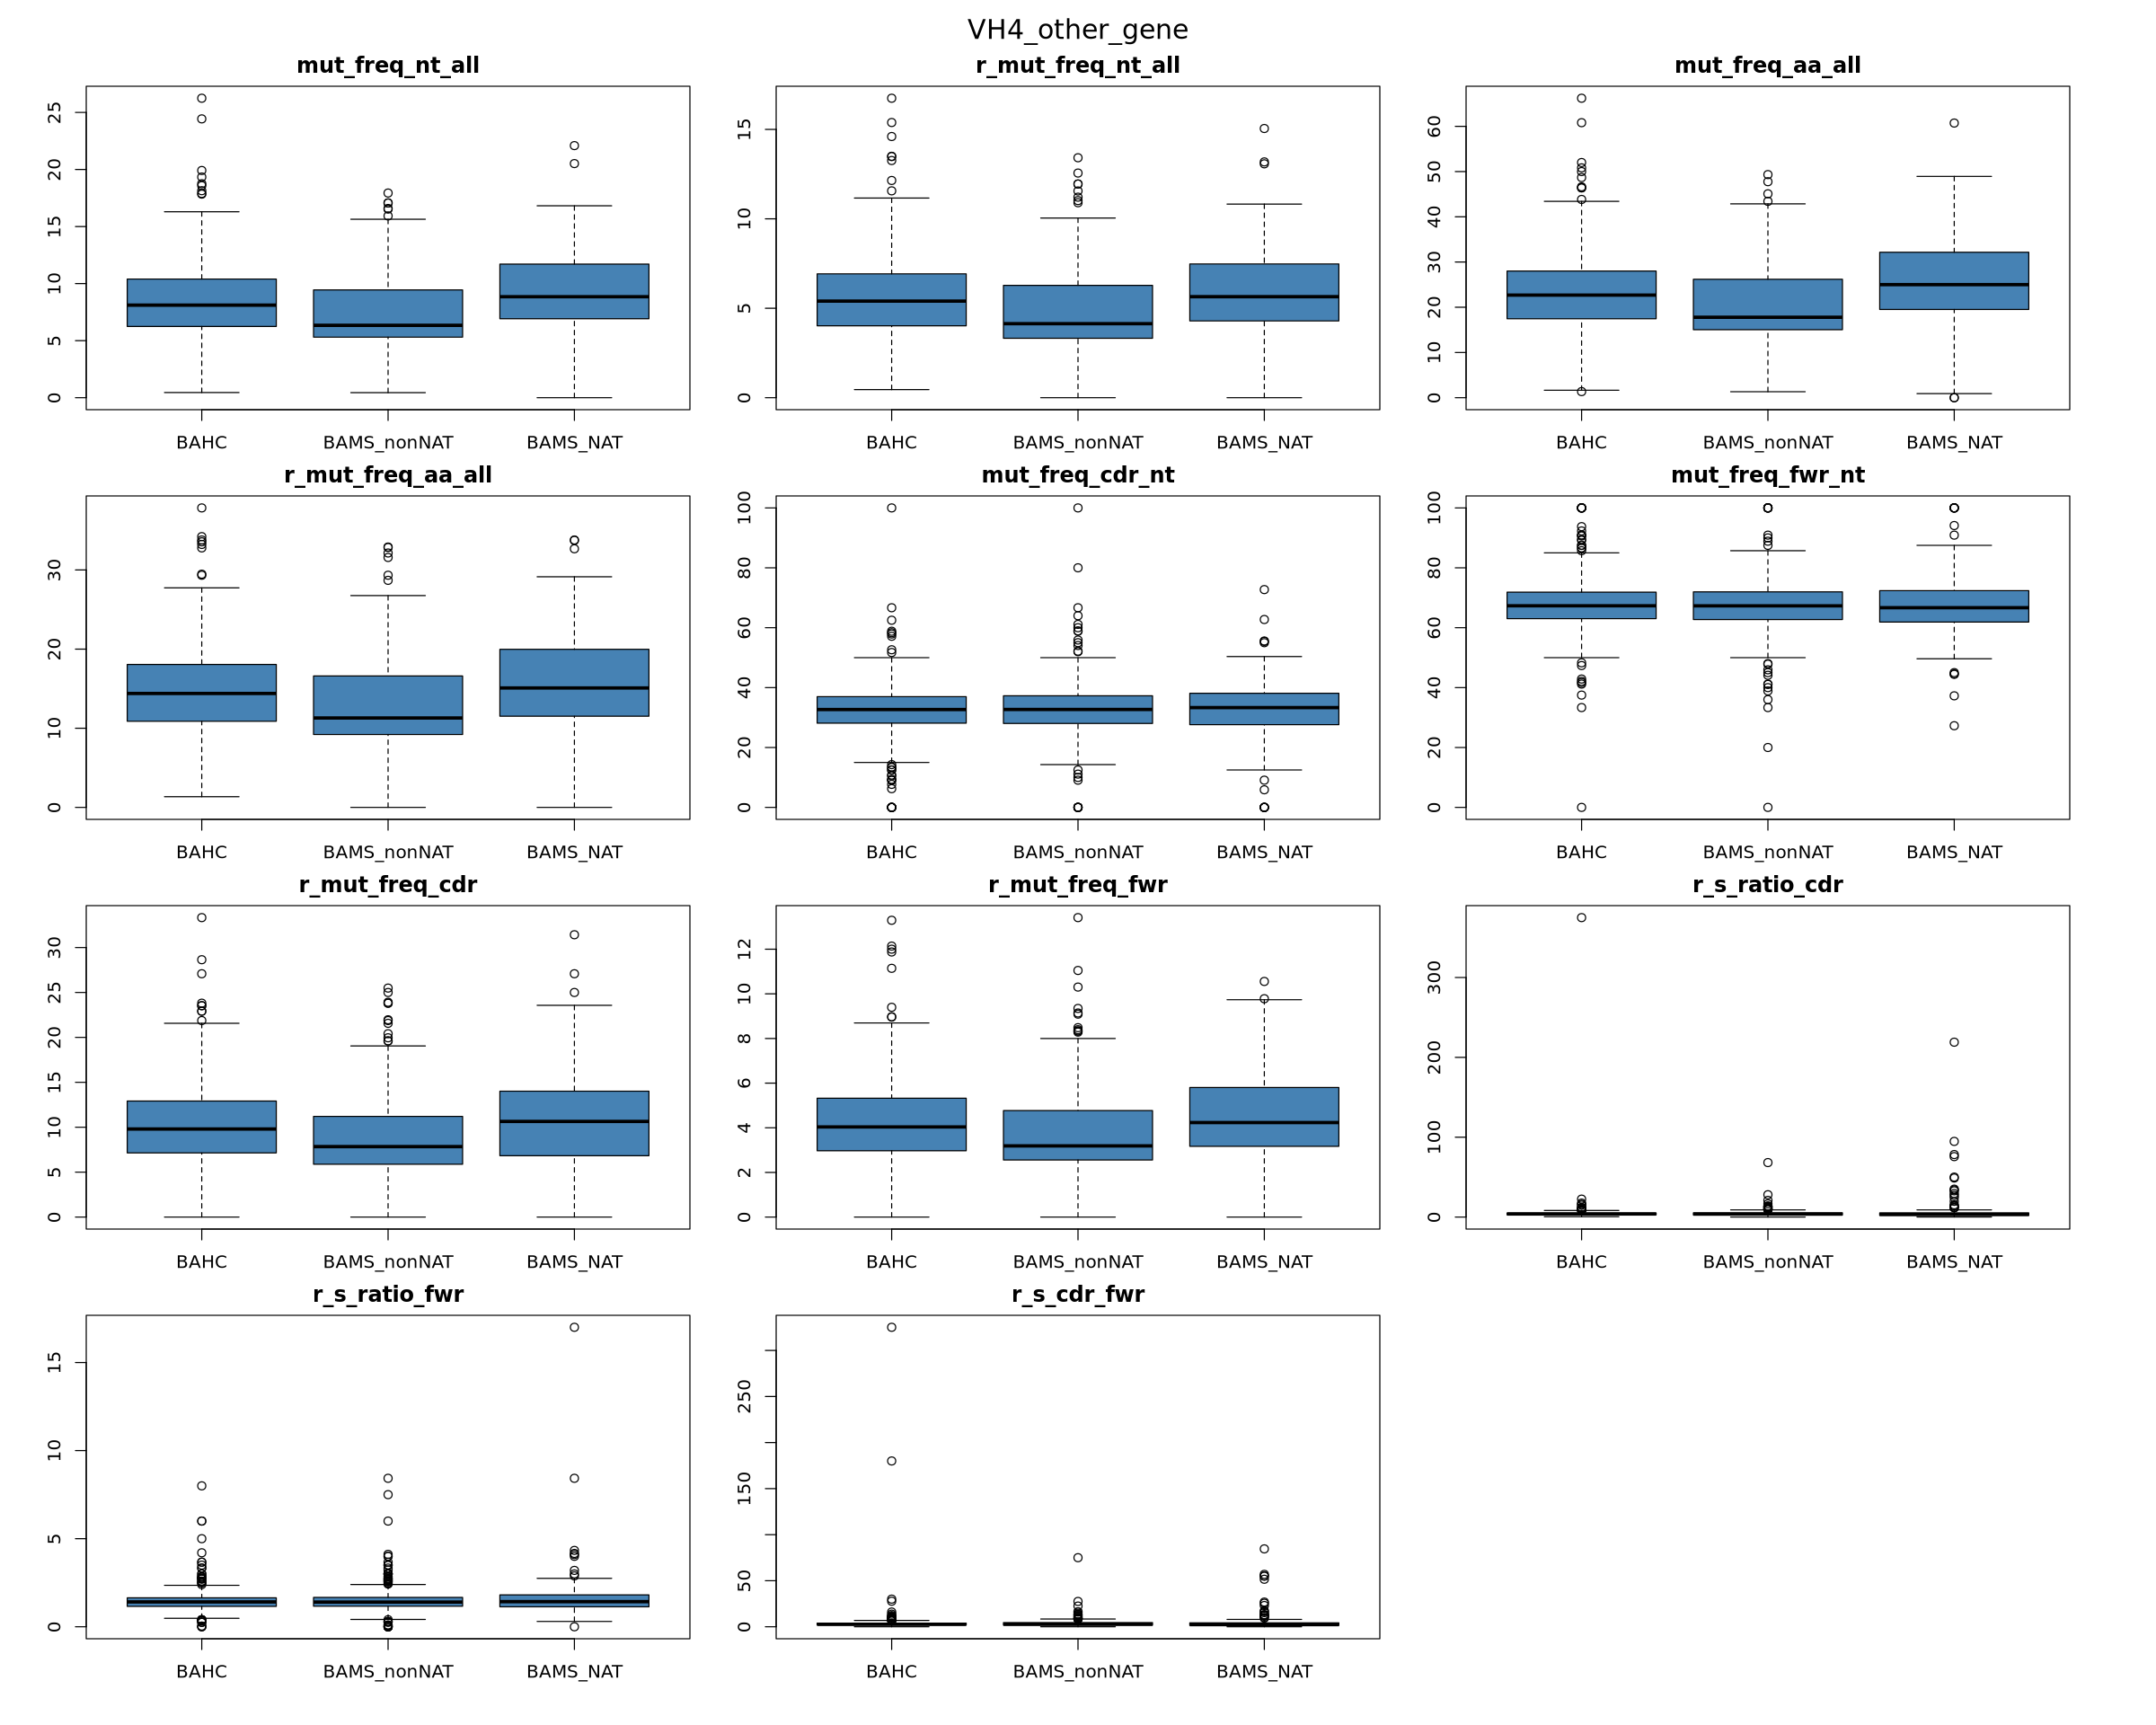

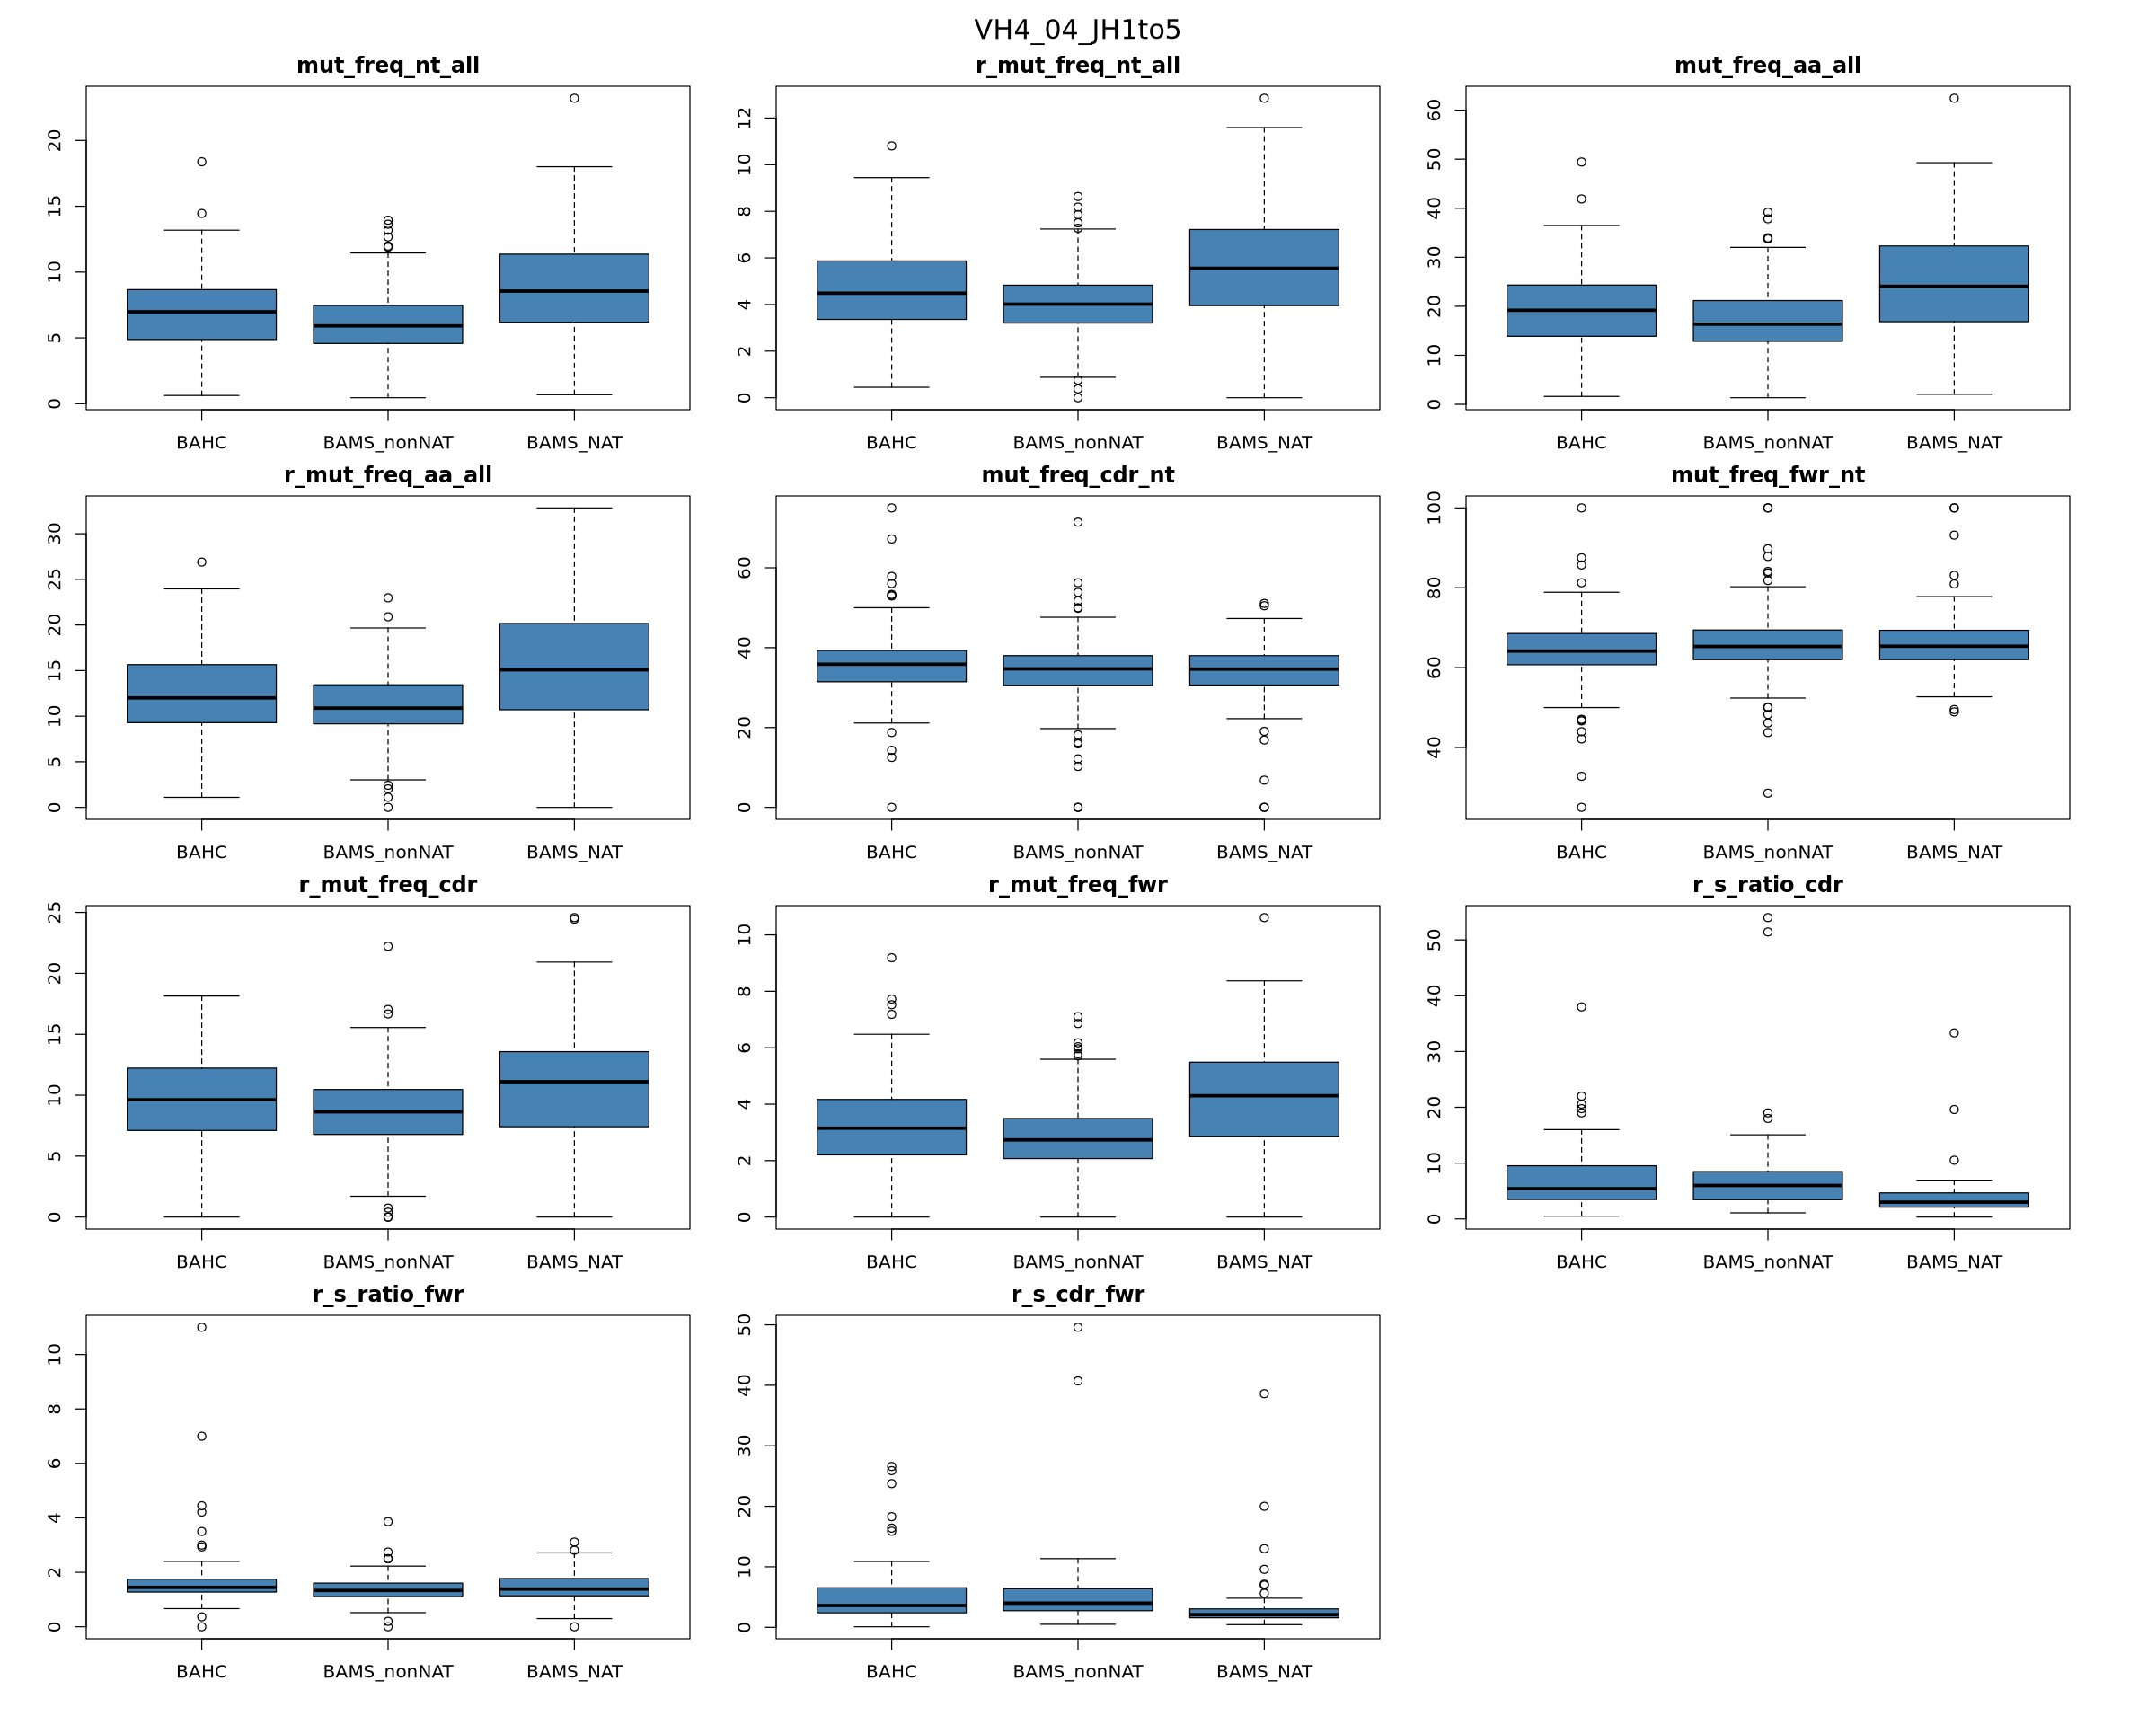

In [18]:
### variables to plot 
box_plot_vars <- c(
    "mut_freq_nt_all",
    "r_mut_freq_nt_all",
    "mut_freq_aa_all",
    "r_mut_freq_aa_all",
    "mut_freq_cdr_nt",
    "mut_freq_fwr_nt",
    "r_mut_freq_cdr",
    "r_mut_freq_fwr",
    "r_s_ratio_cdr",
    "r_s_ratio_fwr",
    "r_s_cdr_fwr"
)

### df to process
box_plot_df_list <- list(
    overall = mut_analysis_summary,
    VH3_family = mut_analysis_VH3_family,
    VH4_JH1to5 = mut_analysis_VH4_family_J1to5_gene,
    VH4_other_gene = mut_analysis_VH4_other_gene,
    VH4_04_JH1to5 = mut_analysis_VH4_04_gene_J1to5_gene
)

for (df_name in names(box_plot_df_list)) {
    options(repr.plot.width = 20, repr.plot.height = 16)

    par(
        mfrow = c(4, 3),
        mar = c(2, 2, 2, 2),
        oma = c(2, 2, 2, 2), 
        bg = "white",
        cex = 1
    )

    box_plot_df <- box_plot_df_list[[df_name]]

    for (var in box_plot_vars) {

        formula <- as.formula(
            paste(var, "~group_ID")
        )

        boxplot(
            formula,
            data = box_plot_df,
            col = "steelblue",
            main = var
        )
    }
    mtext(df_name, outer = TRUE, cex = 1.5)
}

##### summary box plots

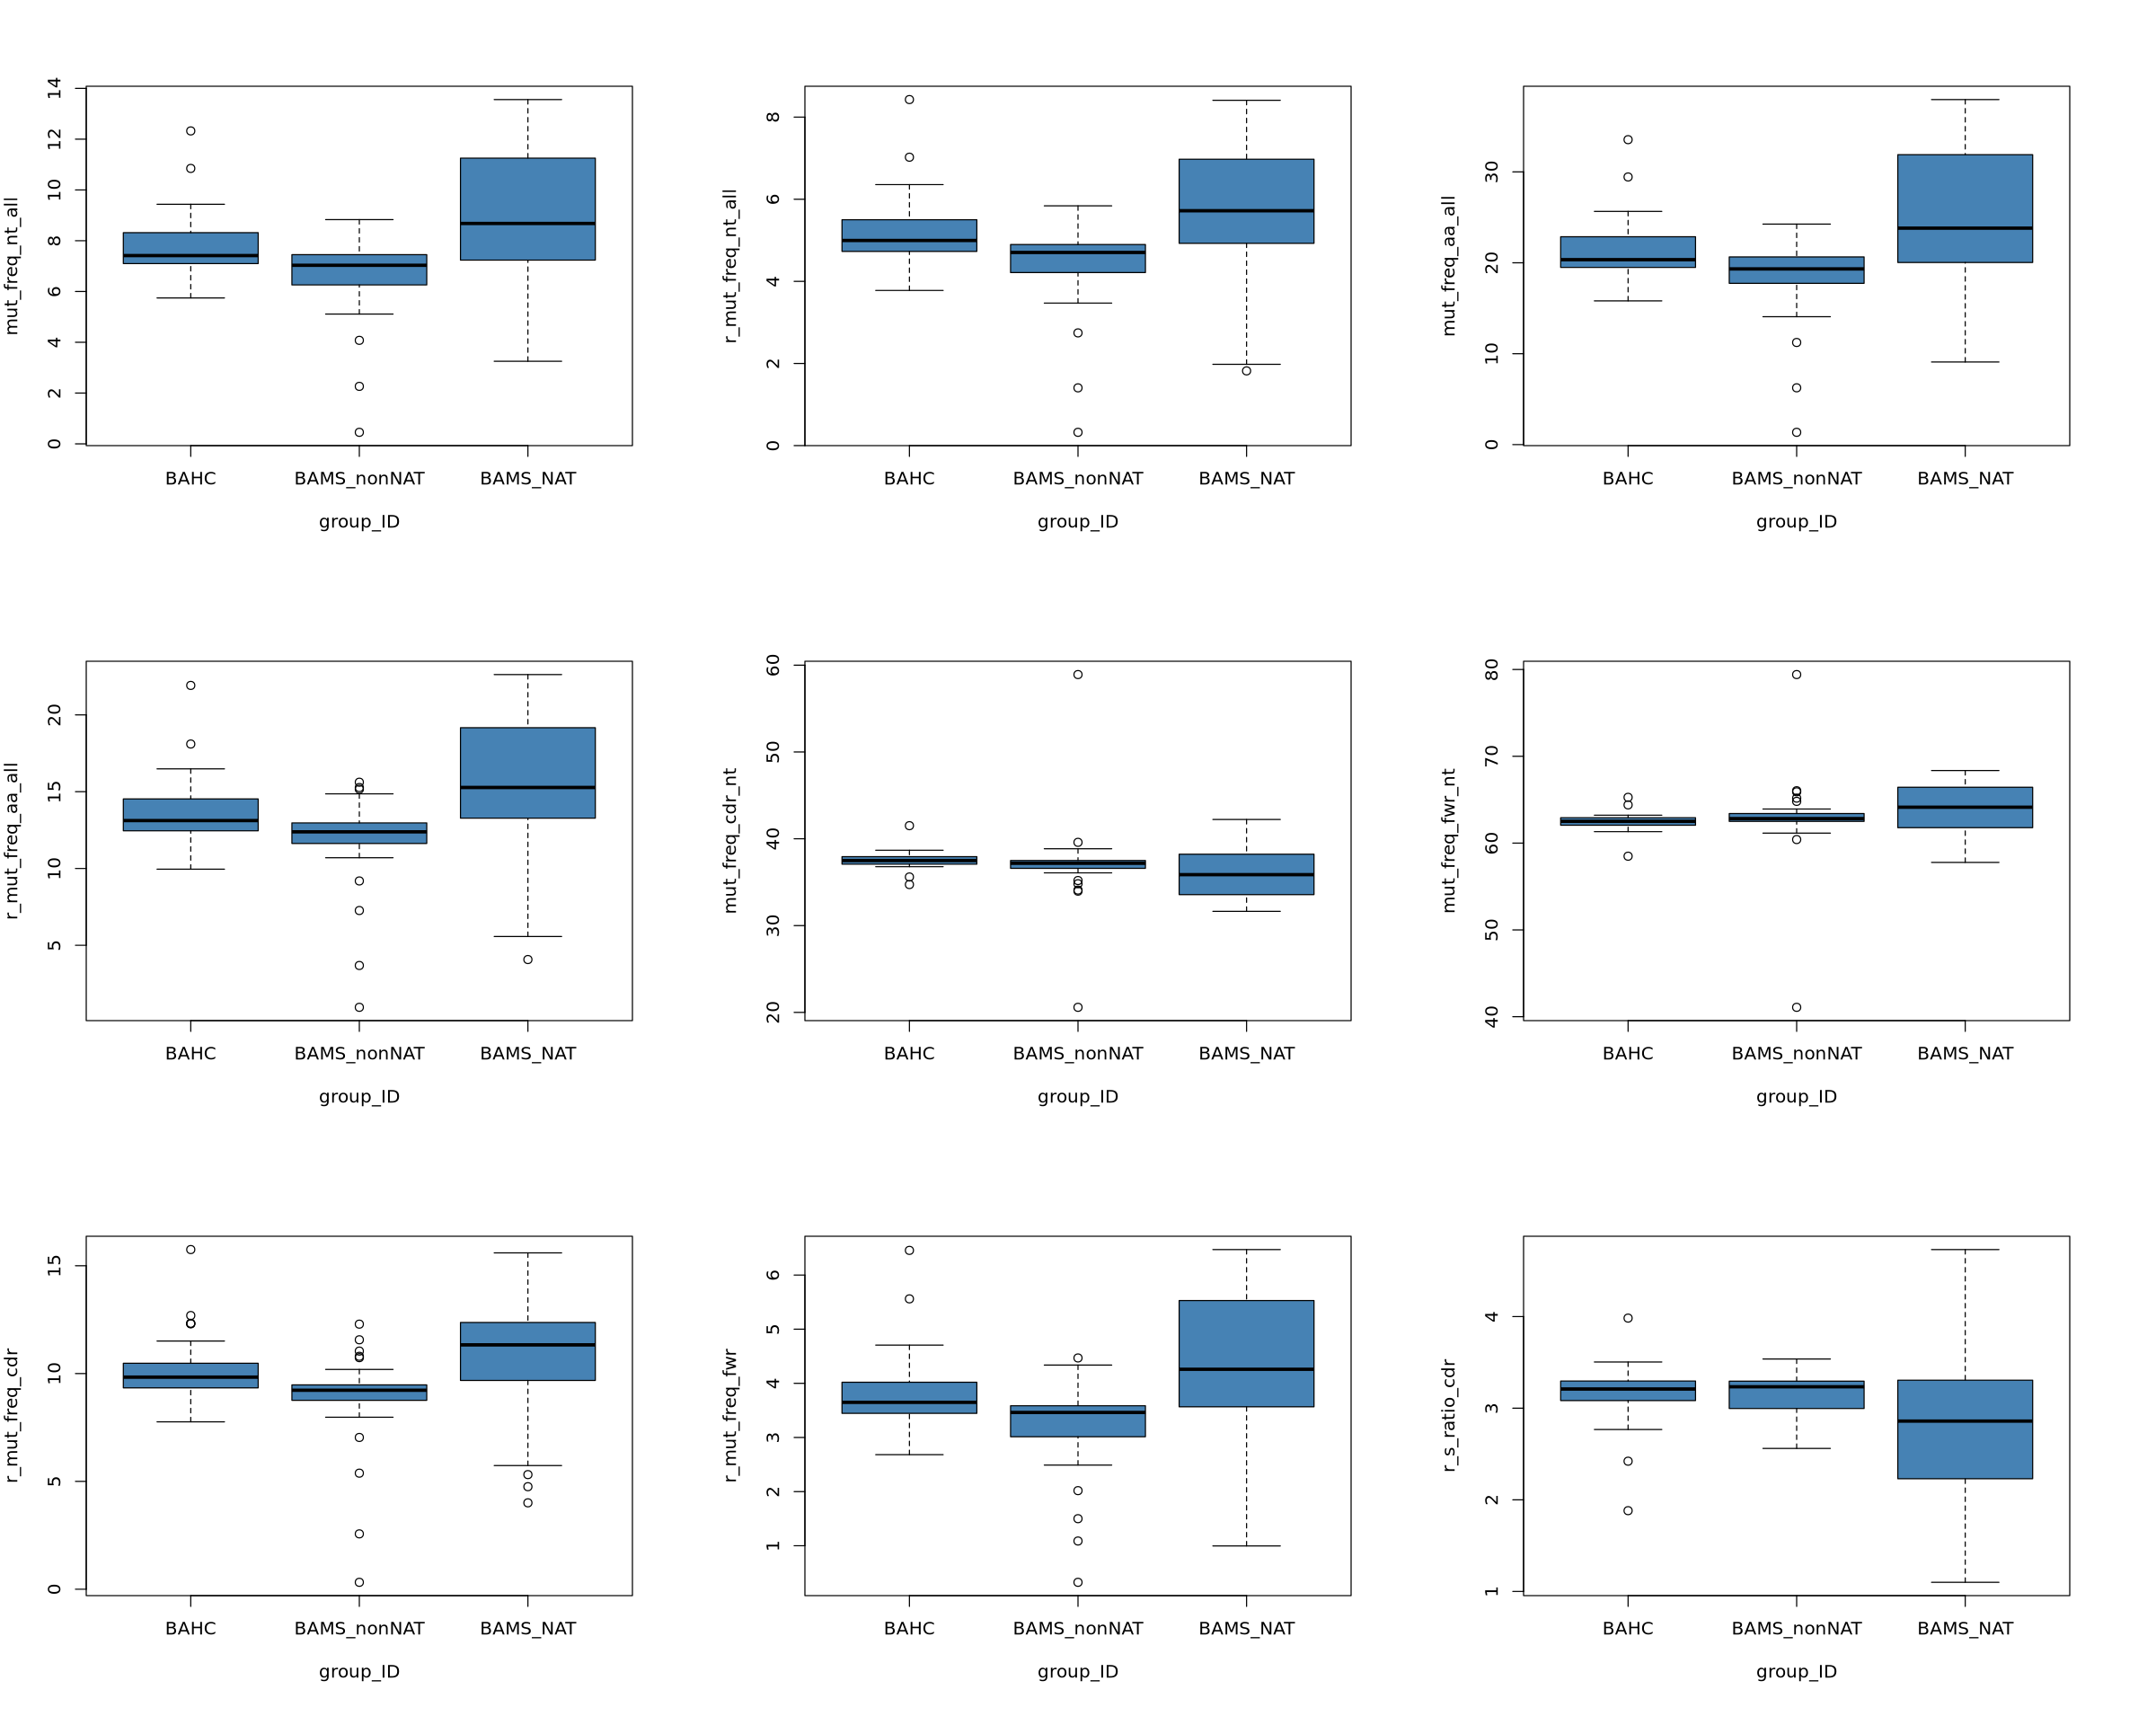

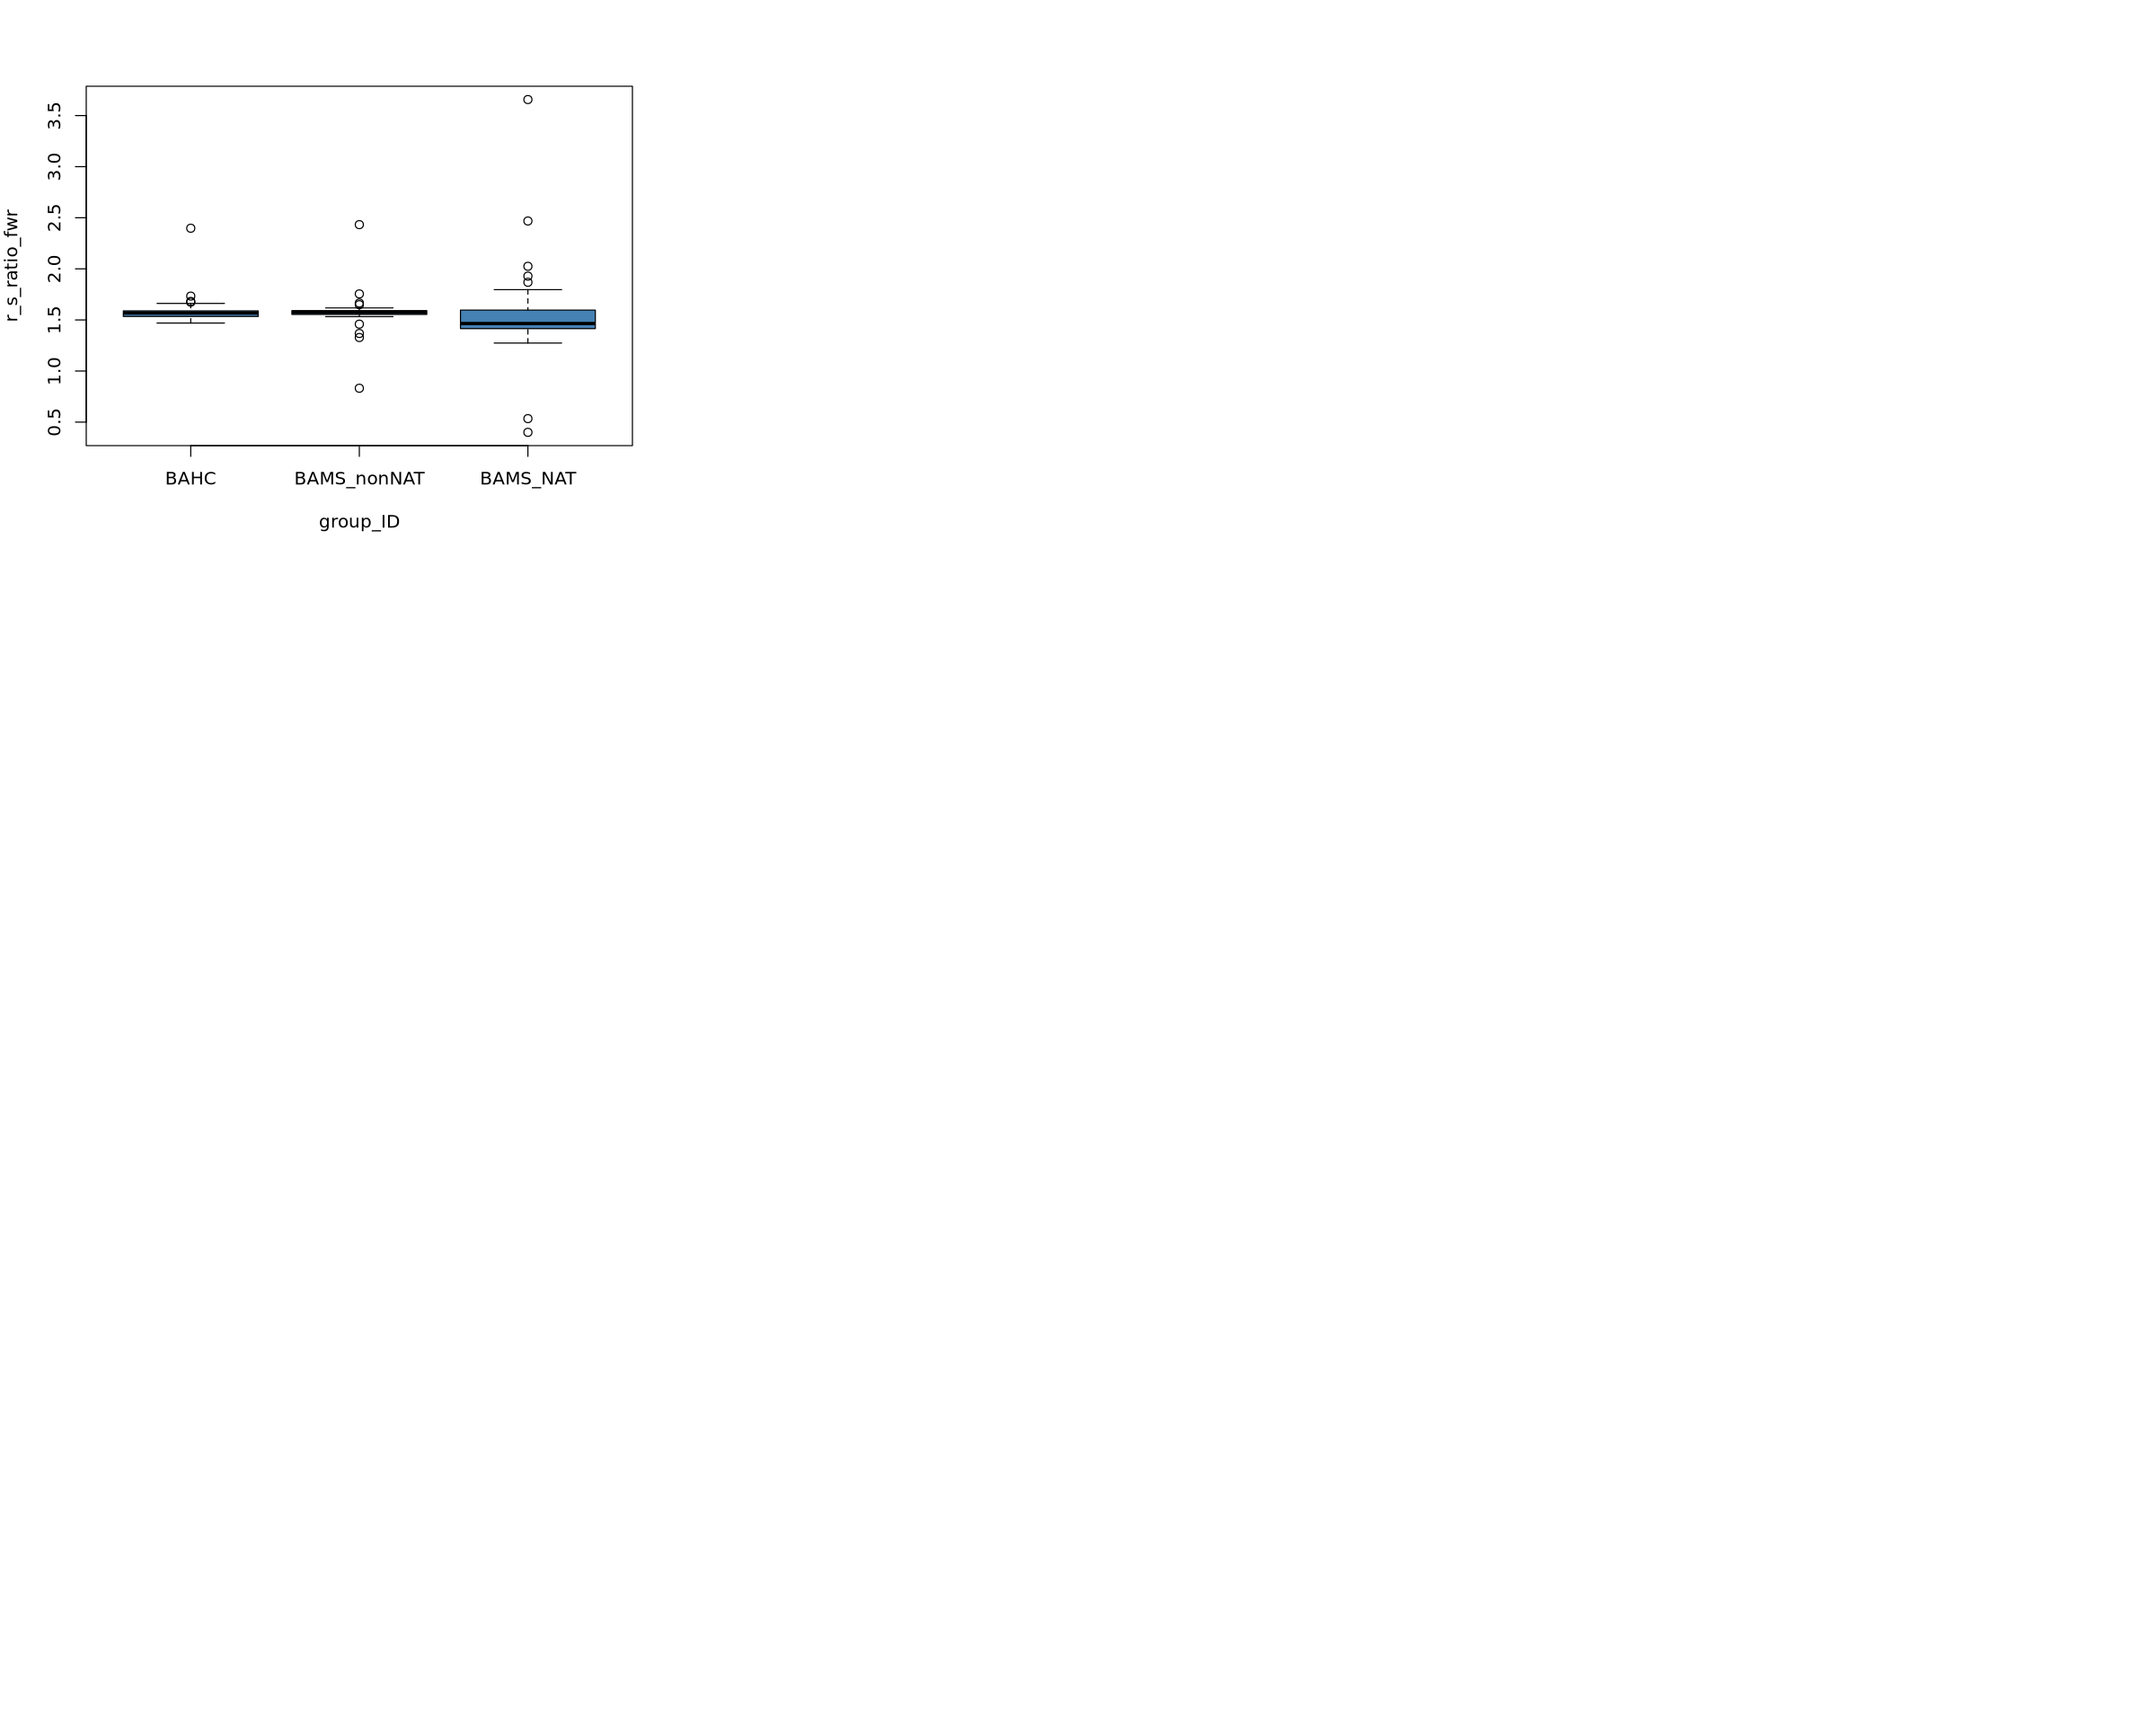

In [19]:
##this next line is jupyter specific only 
options(repr.plot.width = 20, repr.plot.height = 16)

par(
        mfrow = c(3, 3),
        mar = c(6, 4, 4, 4),
        bg = "white",
        cex = "1")
#1
boxplot(mut_freq_nt_all ~ group_ID,
        data = mut_analysis_summary,
        col = "steelblue")
#2
boxplot(r_mut_freq_nt_all ~ group_ID,
        data = mut_analysis_summary,
        col = "steelblue")
#3
boxplot(mut_freq_aa_all ~ group_ID,
        data = mut_analysis_summary,
        col = "steelblue")
#3.2
boxplot(r_mut_freq_aa_all ~ group_ID,
        data = mut_analysis_summary,
        col = "steelblue")
#4
boxplot(mut_freq_cdr_nt ~ group_ID,
        data = mut_analysis_summary,
        col = "steelblue")
#4.2
boxplot(mut_freq_fwr_nt ~ group_ID,
        data = mut_analysis_summary,
        col = "steelblue")
#5
boxplot(r_mut_freq_cdr ~ group_ID,
        data = mut_analysis_summary,
        col = "steelblue")
#5.2
boxplot(r_mut_freq_fwr ~ group_ID,
        data = mut_analysis_summary,
        col = "steelblue")
#6
boxplot(r_s_ratio_cdr ~ group_ID,
        data = mut_analysis_summary,
        col = "steelblue")
#7
boxplot(r_s_ratio_fwr ~ group_ID,
        data = mut_analysis_summary,
        col = "steelblue")

#dev.off()


#### VH4 family box plots

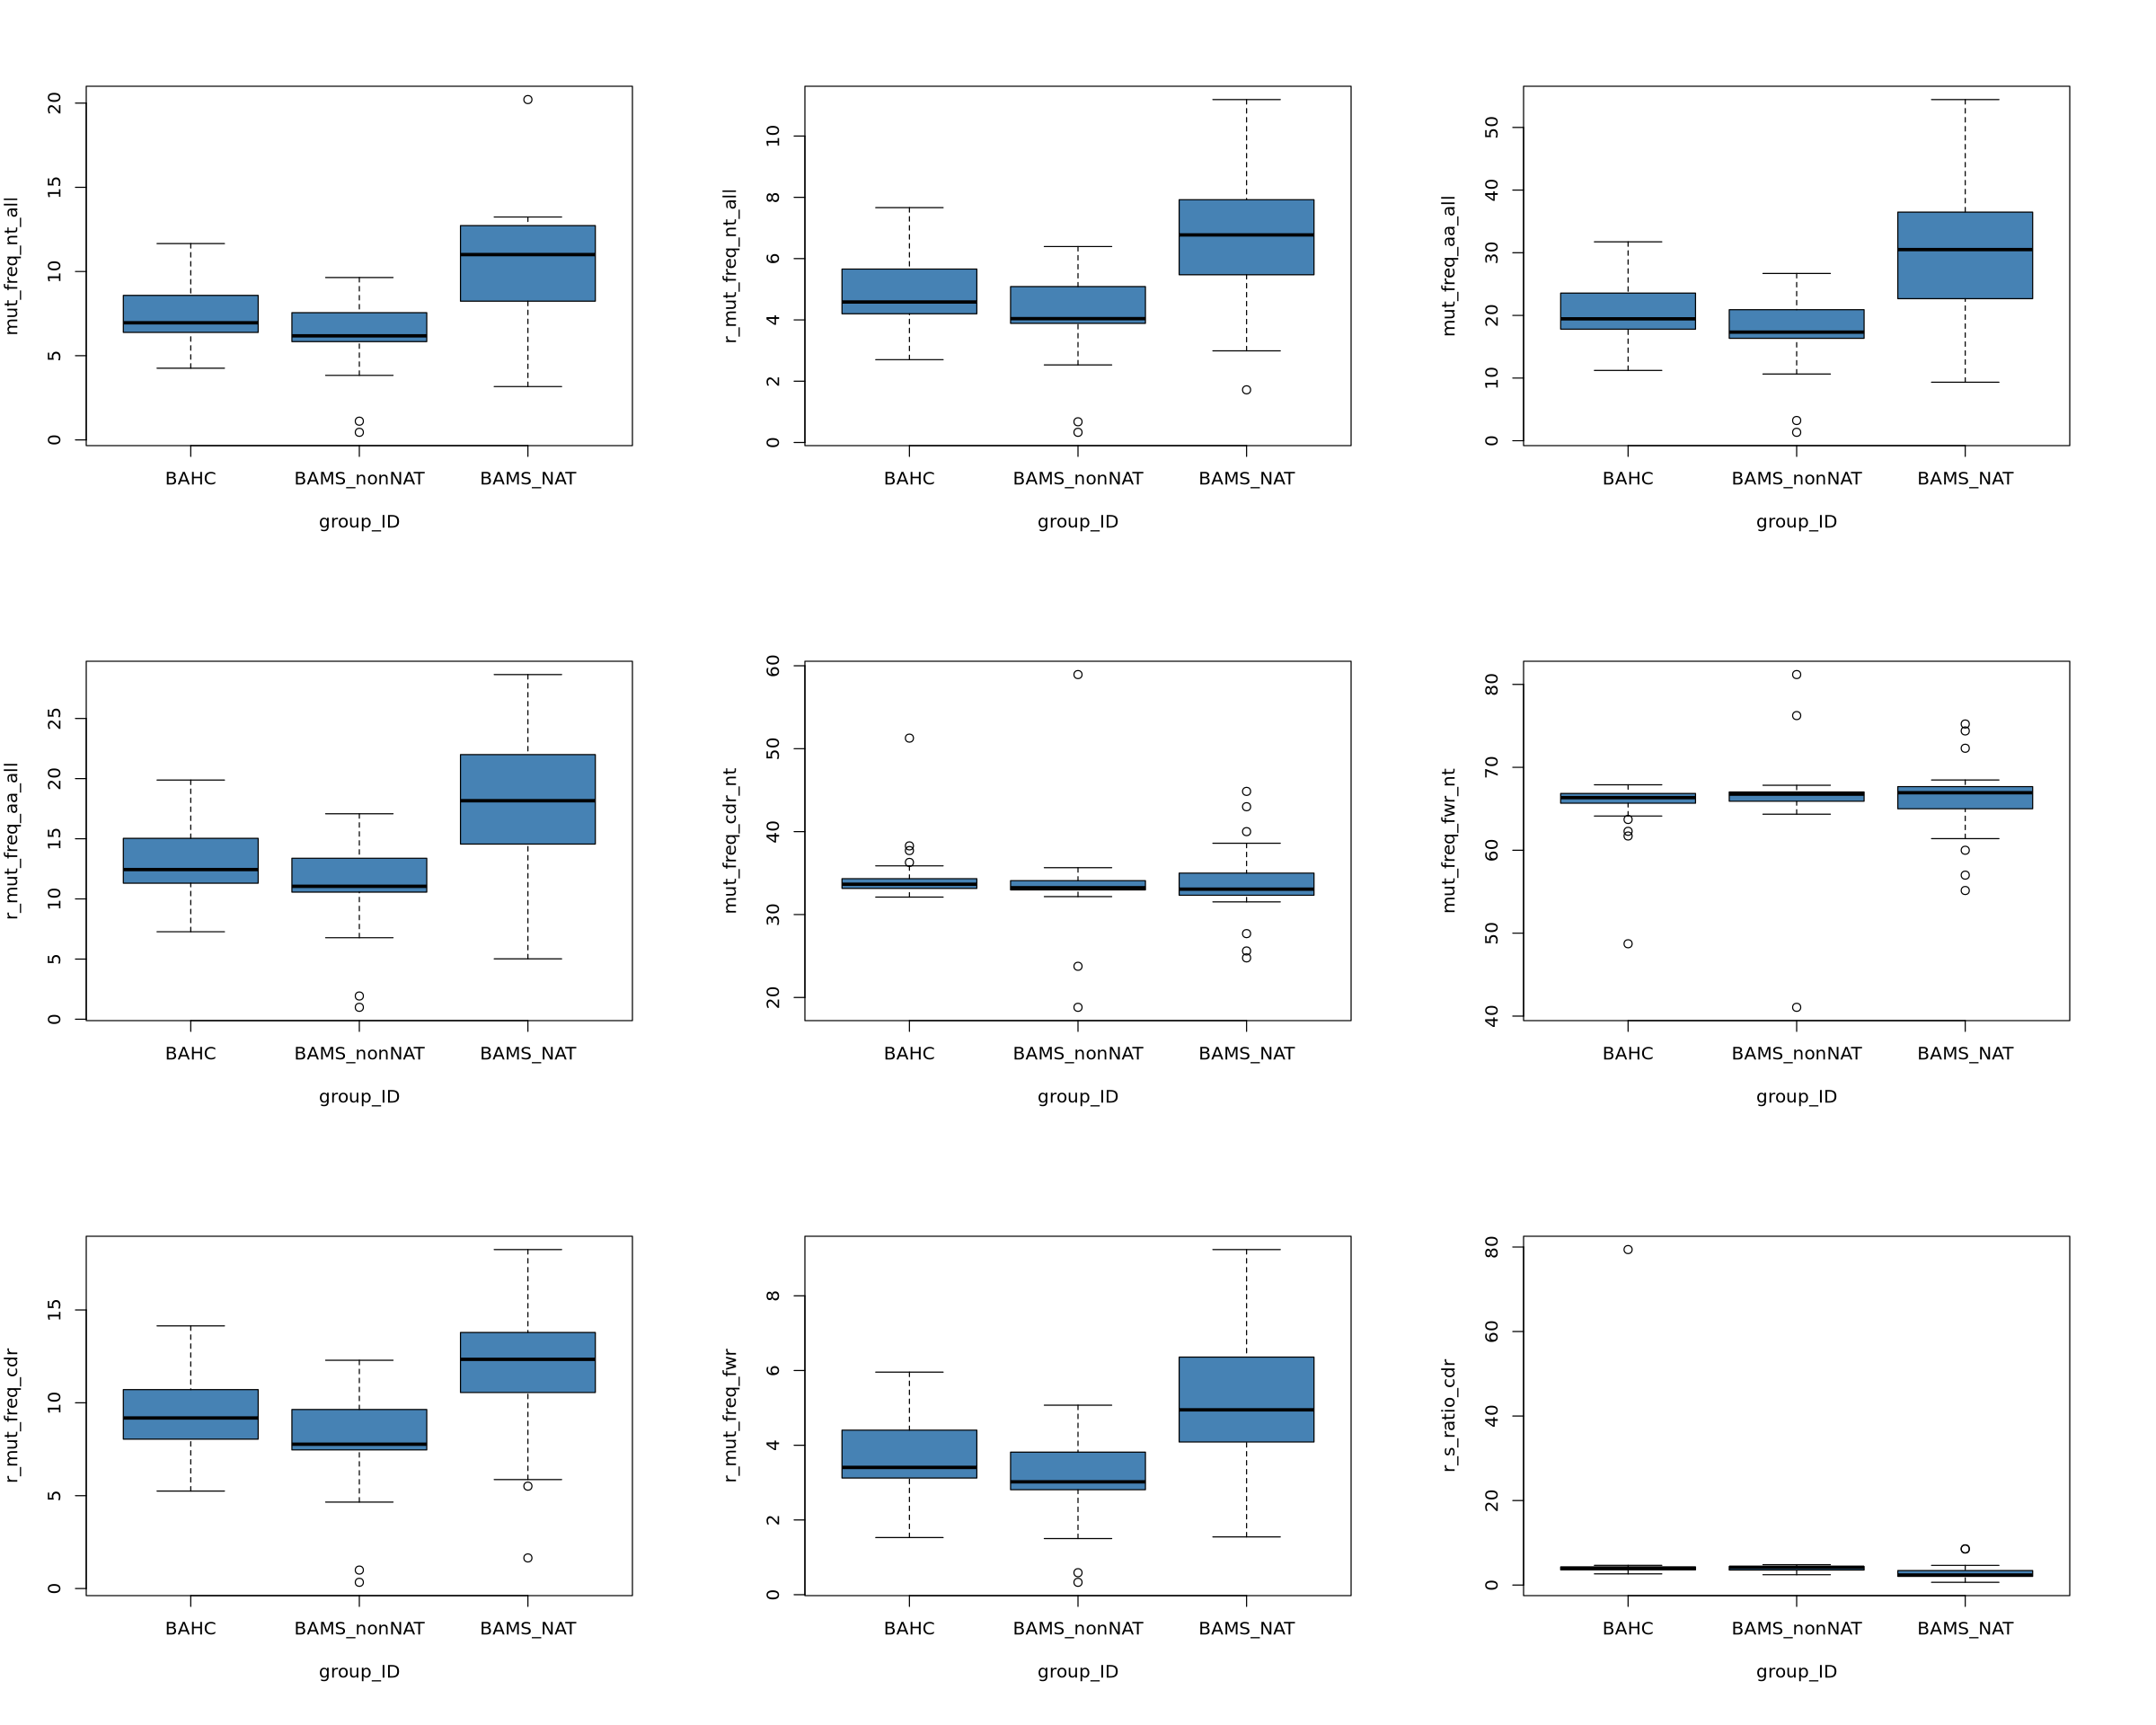

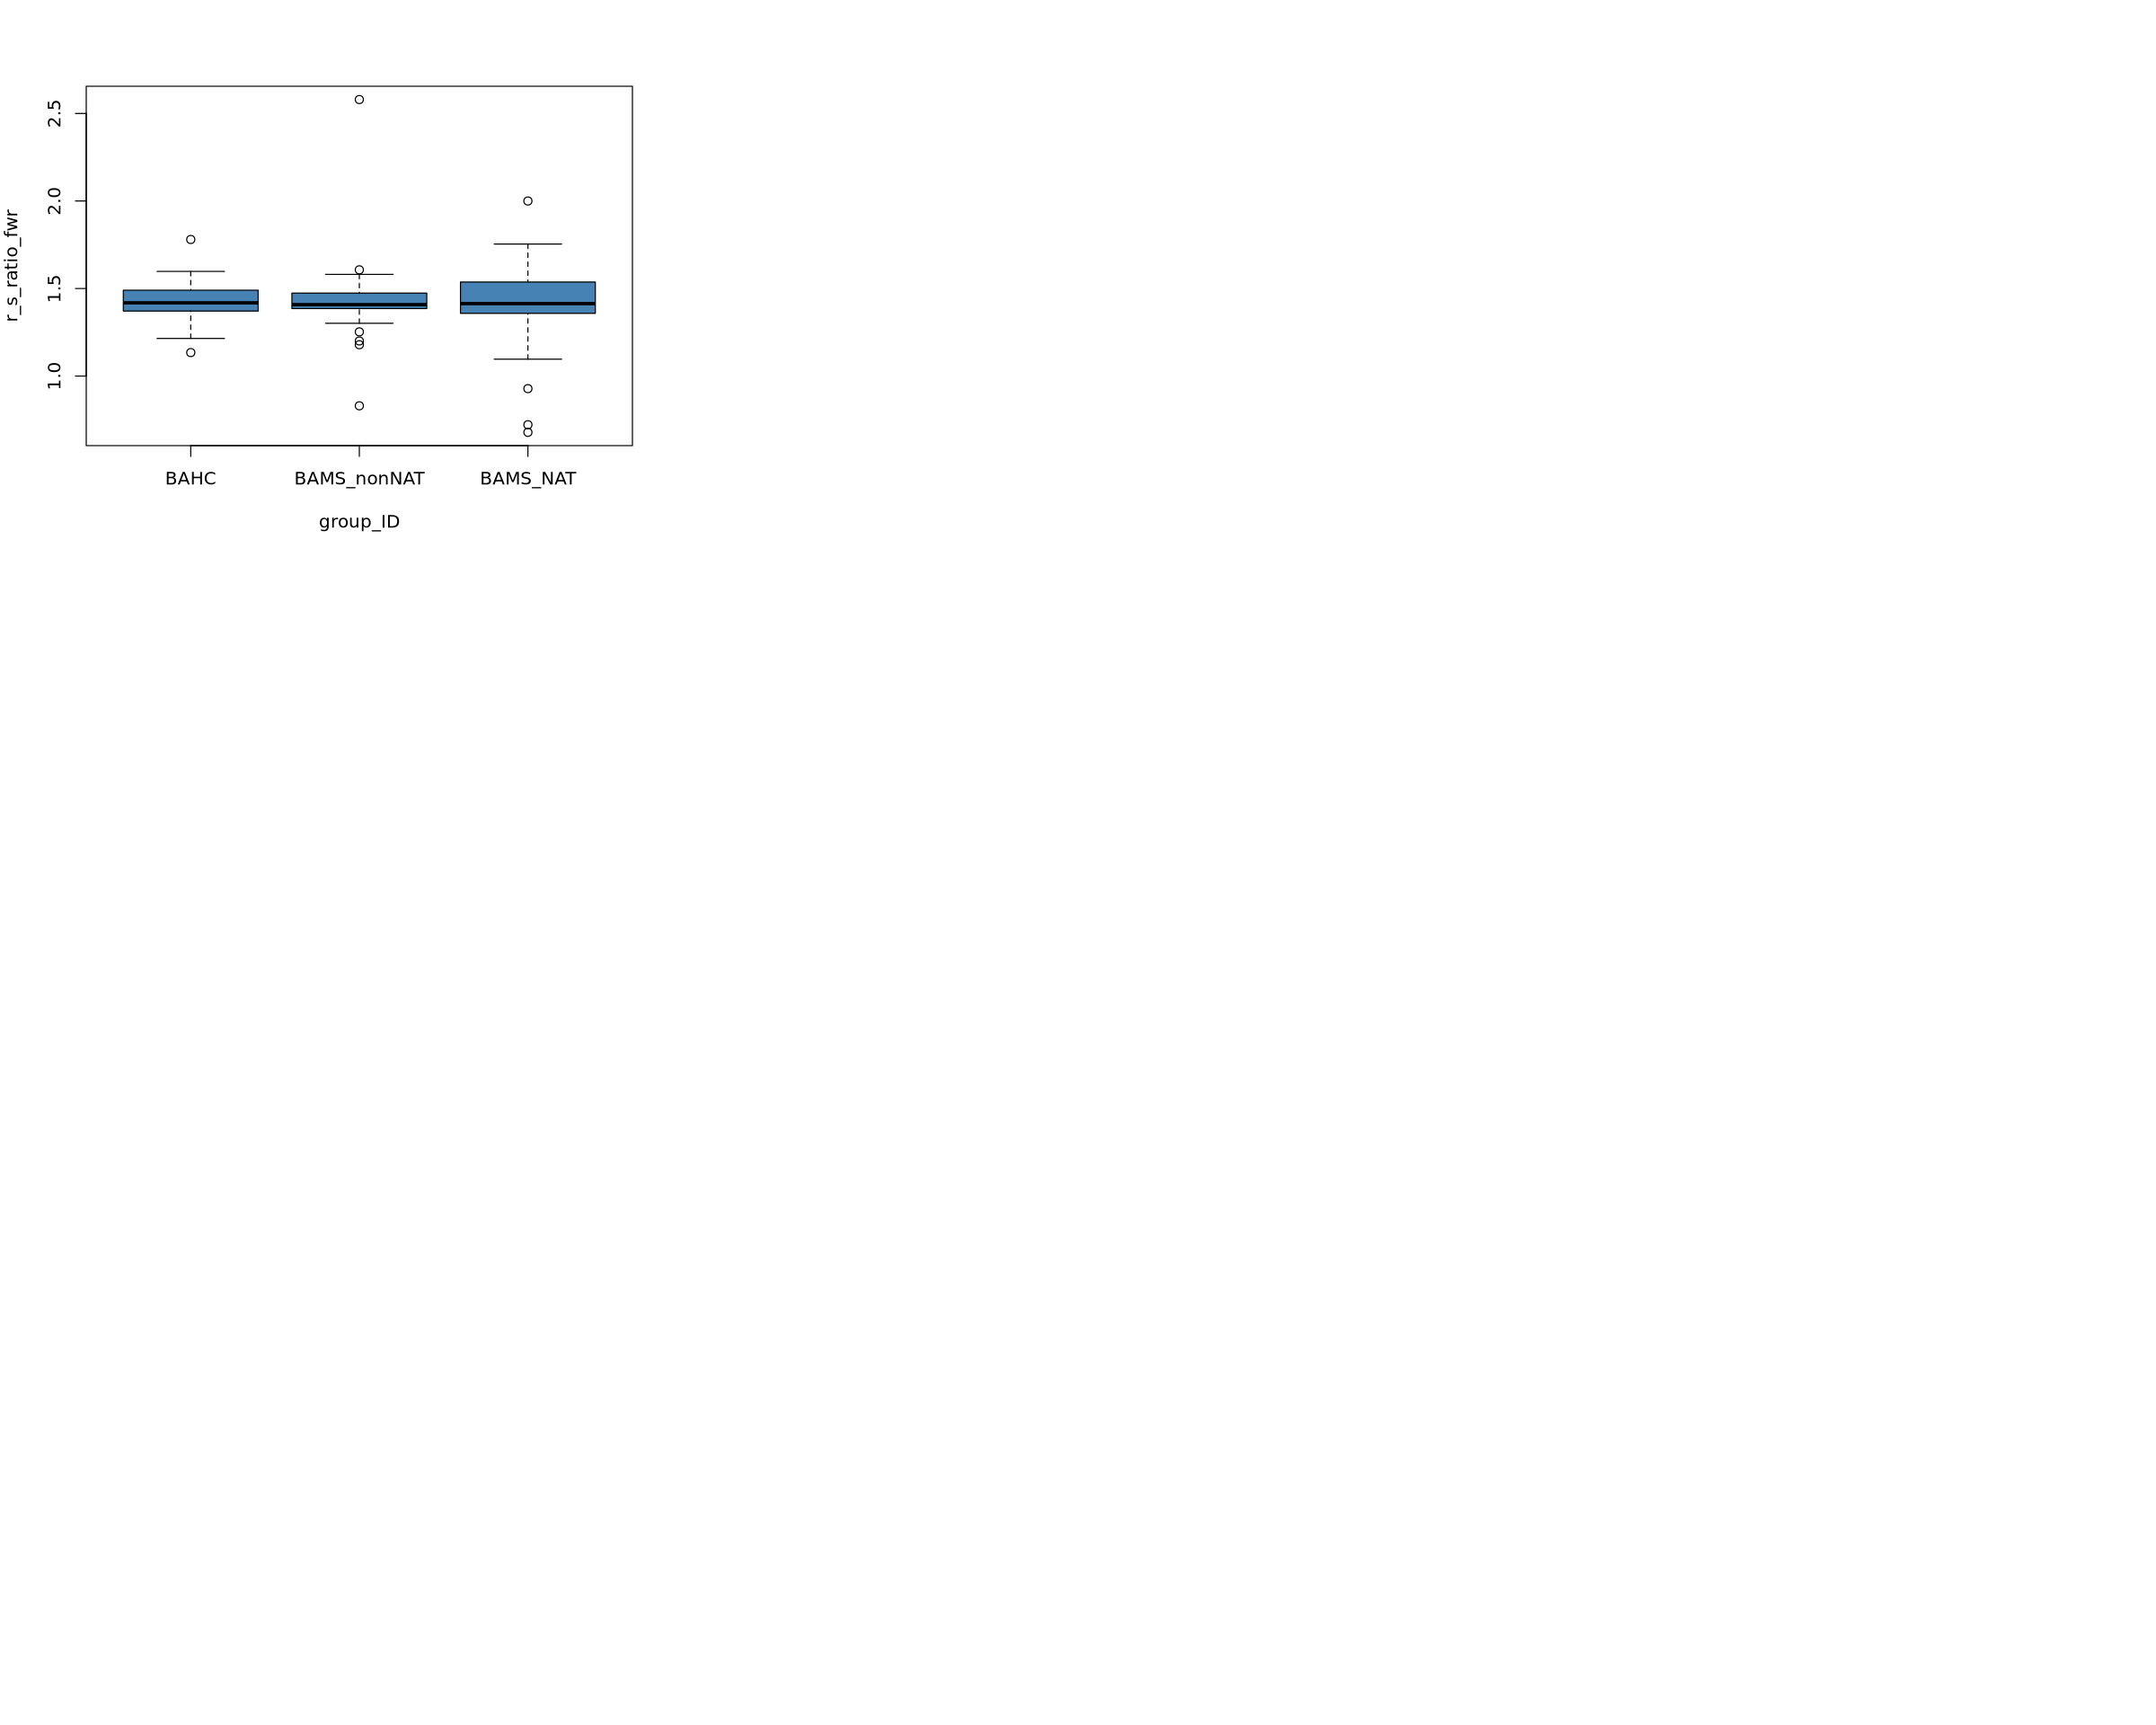

In [20]:
##this next line is jupyter specific only 
options(repr.plot.width = 20, repr.plot.height = 16)

par(
        mfrow = c(3, 3),
        mar = c(6, 4, 4, 4),
        bg = "white",
        cex = "1")
#1
boxplot(mut_freq_nt_all ~ group_ID,
        data = mut_analysis_VH4_family,
        col = "steelblue")
#2
boxplot(r_mut_freq_nt_all ~ group_ID,
        data = mut_analysis_VH4_family,
        col = "steelblue")
#3
boxplot(mut_freq_aa_all ~ group_ID,
        data = mut_analysis_VH4_family,
        col = "steelblue")
#3.2
boxplot(r_mut_freq_aa_all ~ group_ID,
        data = mut_analysis_VH4_family,
        col = "steelblue")
#4
boxplot(mut_freq_cdr_nt ~ group_ID,
        data = mut_analysis_VH4_family,
        col = "steelblue")
#4.2
boxplot(mut_freq_fwr_nt ~ group_ID,
        data = mut_analysis_VH4_family,
        col = "steelblue")
#5
boxplot(r_mut_freq_cdr ~ group_ID,
        data = mut_analysis_VH4_family,
        col = "steelblue")
#5.2
boxplot(r_mut_freq_fwr ~ group_ID,
        data = mut_analysis_VH4_family,
        col = "steelblue")
#6
boxplot(r_s_ratio_cdr ~ group_ID,
        data = mut_analysis_VH4_family,
        col = "steelblue")
#7
boxplot(r_s_ratio_fwr ~ group_ID,
        data = mut_analysis_VH4_family,
        col = "steelblue")

#dev.off()


#### VH4:JH6 family box plots

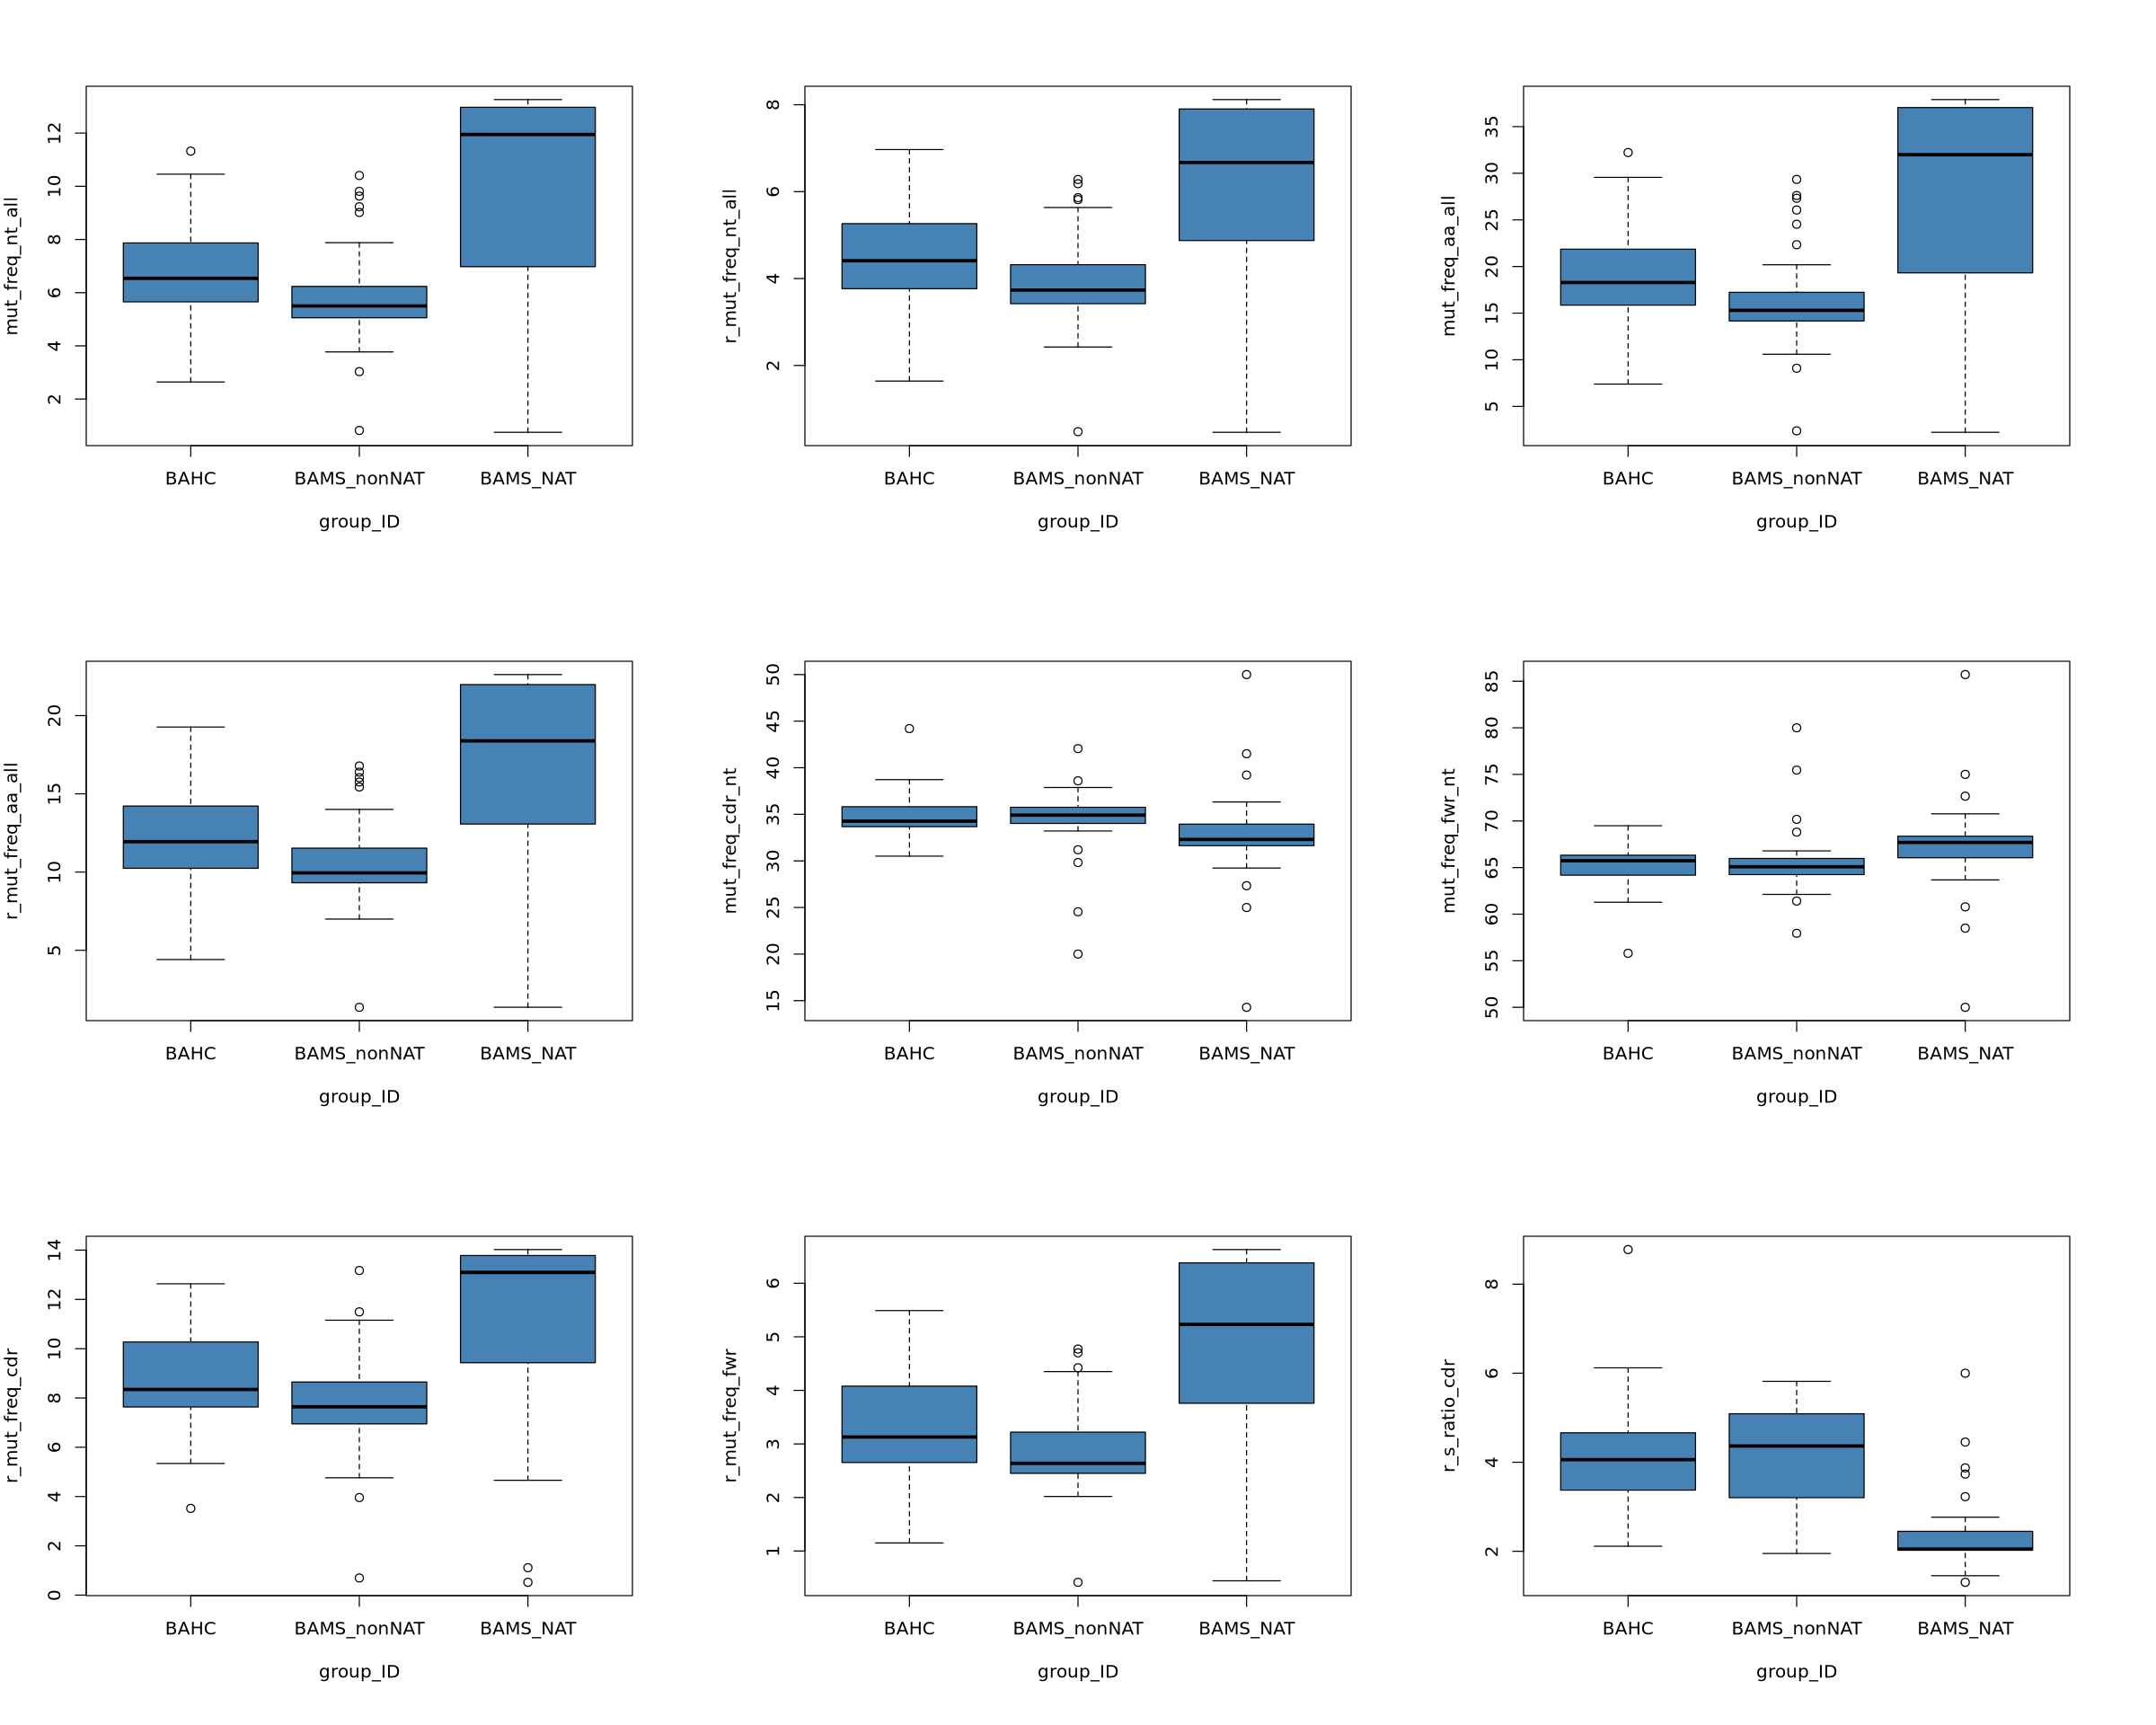

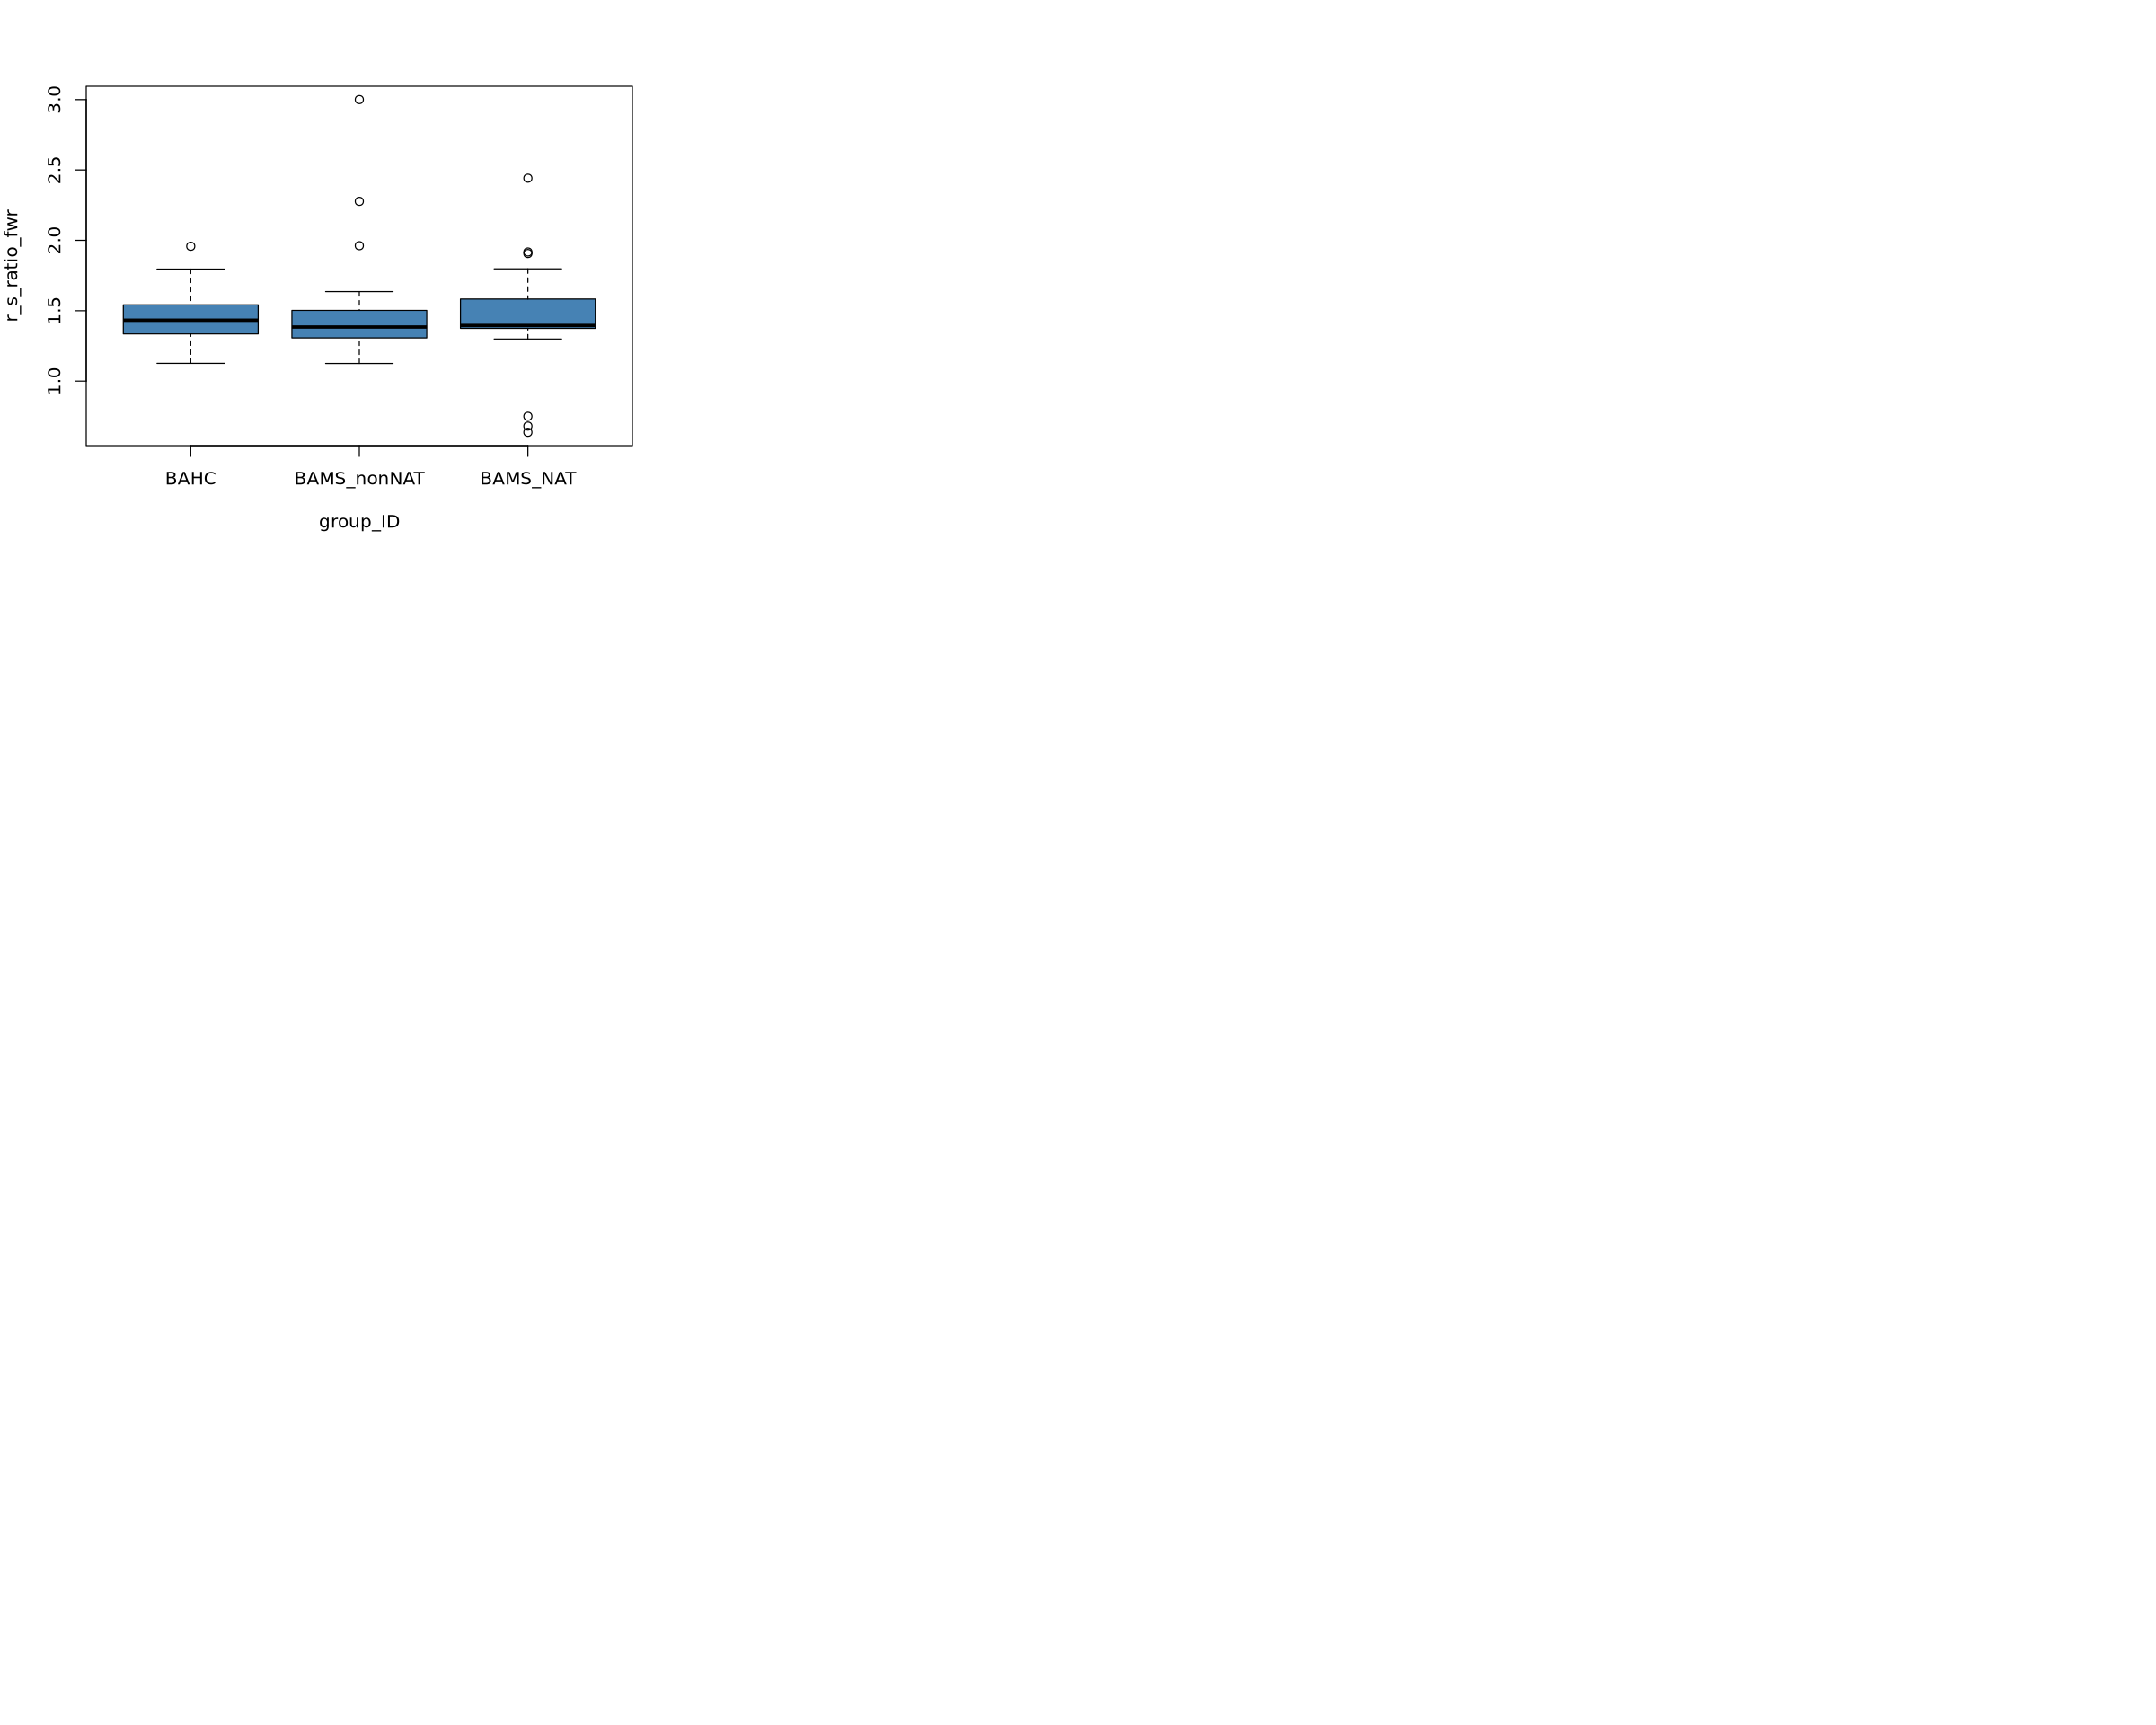

In [21]:
##this next line is jupyter specific only 
options(repr.plot.width = 20, repr.plot.height = 16)

par(
        mfrow = c(3, 3),
        mar = c(6, 4, 4, 4),
        bg = "white",
        cex = "1")
#1
boxplot(mut_freq_nt_all ~ group_ID,
        data = mut_analysis_VH4_family_J6_gene,
        col = "steelblue")
#2
boxplot(r_mut_freq_nt_all ~ group_ID,
        data = mut_analysis_VH4_family_J6_gene,
        col = "steelblue")
#3
boxplot(mut_freq_aa_all ~ group_ID,
        data = mut_analysis_VH4_family_J6_gene,
        col = "steelblue")
#3.2
boxplot(r_mut_freq_aa_all ~ group_ID,
        data = mut_analysis_VH4_family_J6_gene,
        col = "steelblue")
#4
boxplot(mut_freq_cdr_nt ~ group_ID,
        data = mut_analysis_VH4_family_J6_gene,
        col = "steelblue")
#4.2
boxplot(mut_freq_fwr_nt ~ group_ID,
        data = mut_analysis_VH4_family_J6_gene,
        col = "steelblue")
#5
boxplot(r_mut_freq_cdr ~ group_ID,
        data = mut_analysis_VH4_family_J6_gene,
        col = "steelblue")
#5.2
boxplot(r_mut_freq_fwr ~ group_ID,
        data = mut_analysis_VH4_family_J6_gene,
        col = "steelblue")
#6
boxplot(r_s_ratio_cdr ~ group_ID,
        data = mut_analysis_VH4_family_J6_gene,
        col = "steelblue")
#7
boxplot(r_s_ratio_fwr ~ group_ID,
        data = mut_analysis_VH4_family_J6_gene,
        col = "steelblue")

#dev.off()


#### VH4-04 gene box plots

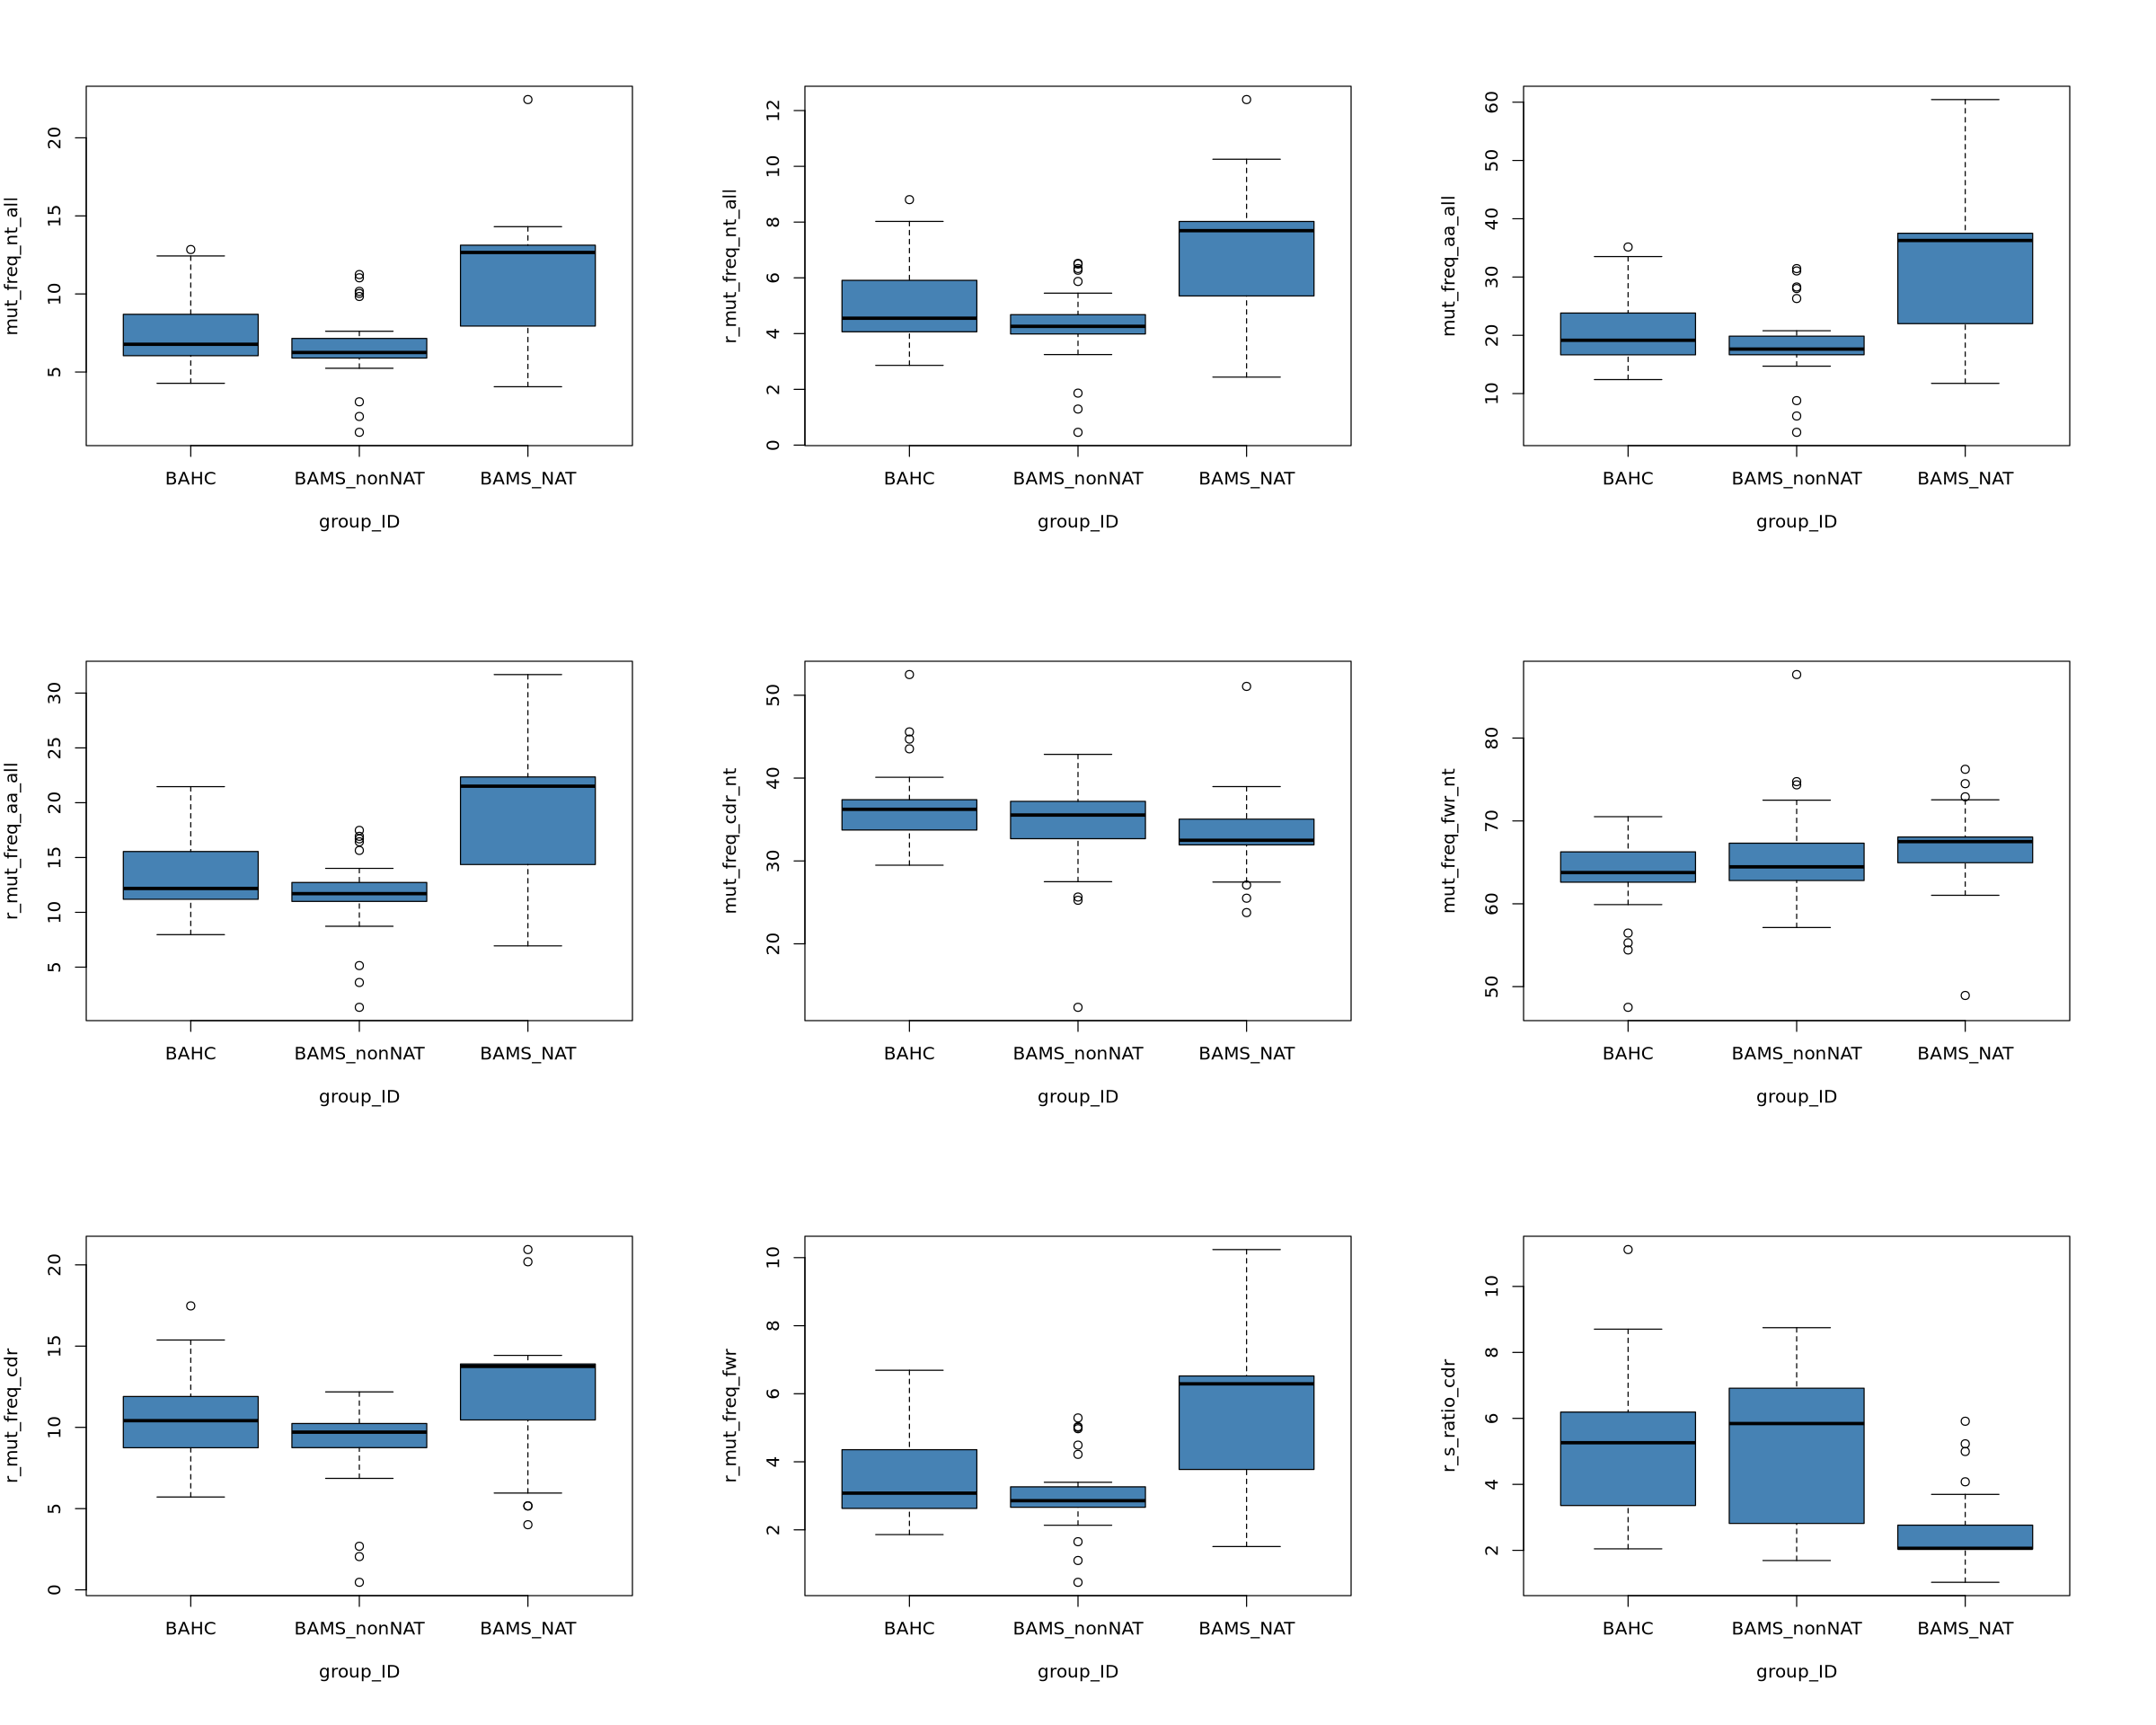

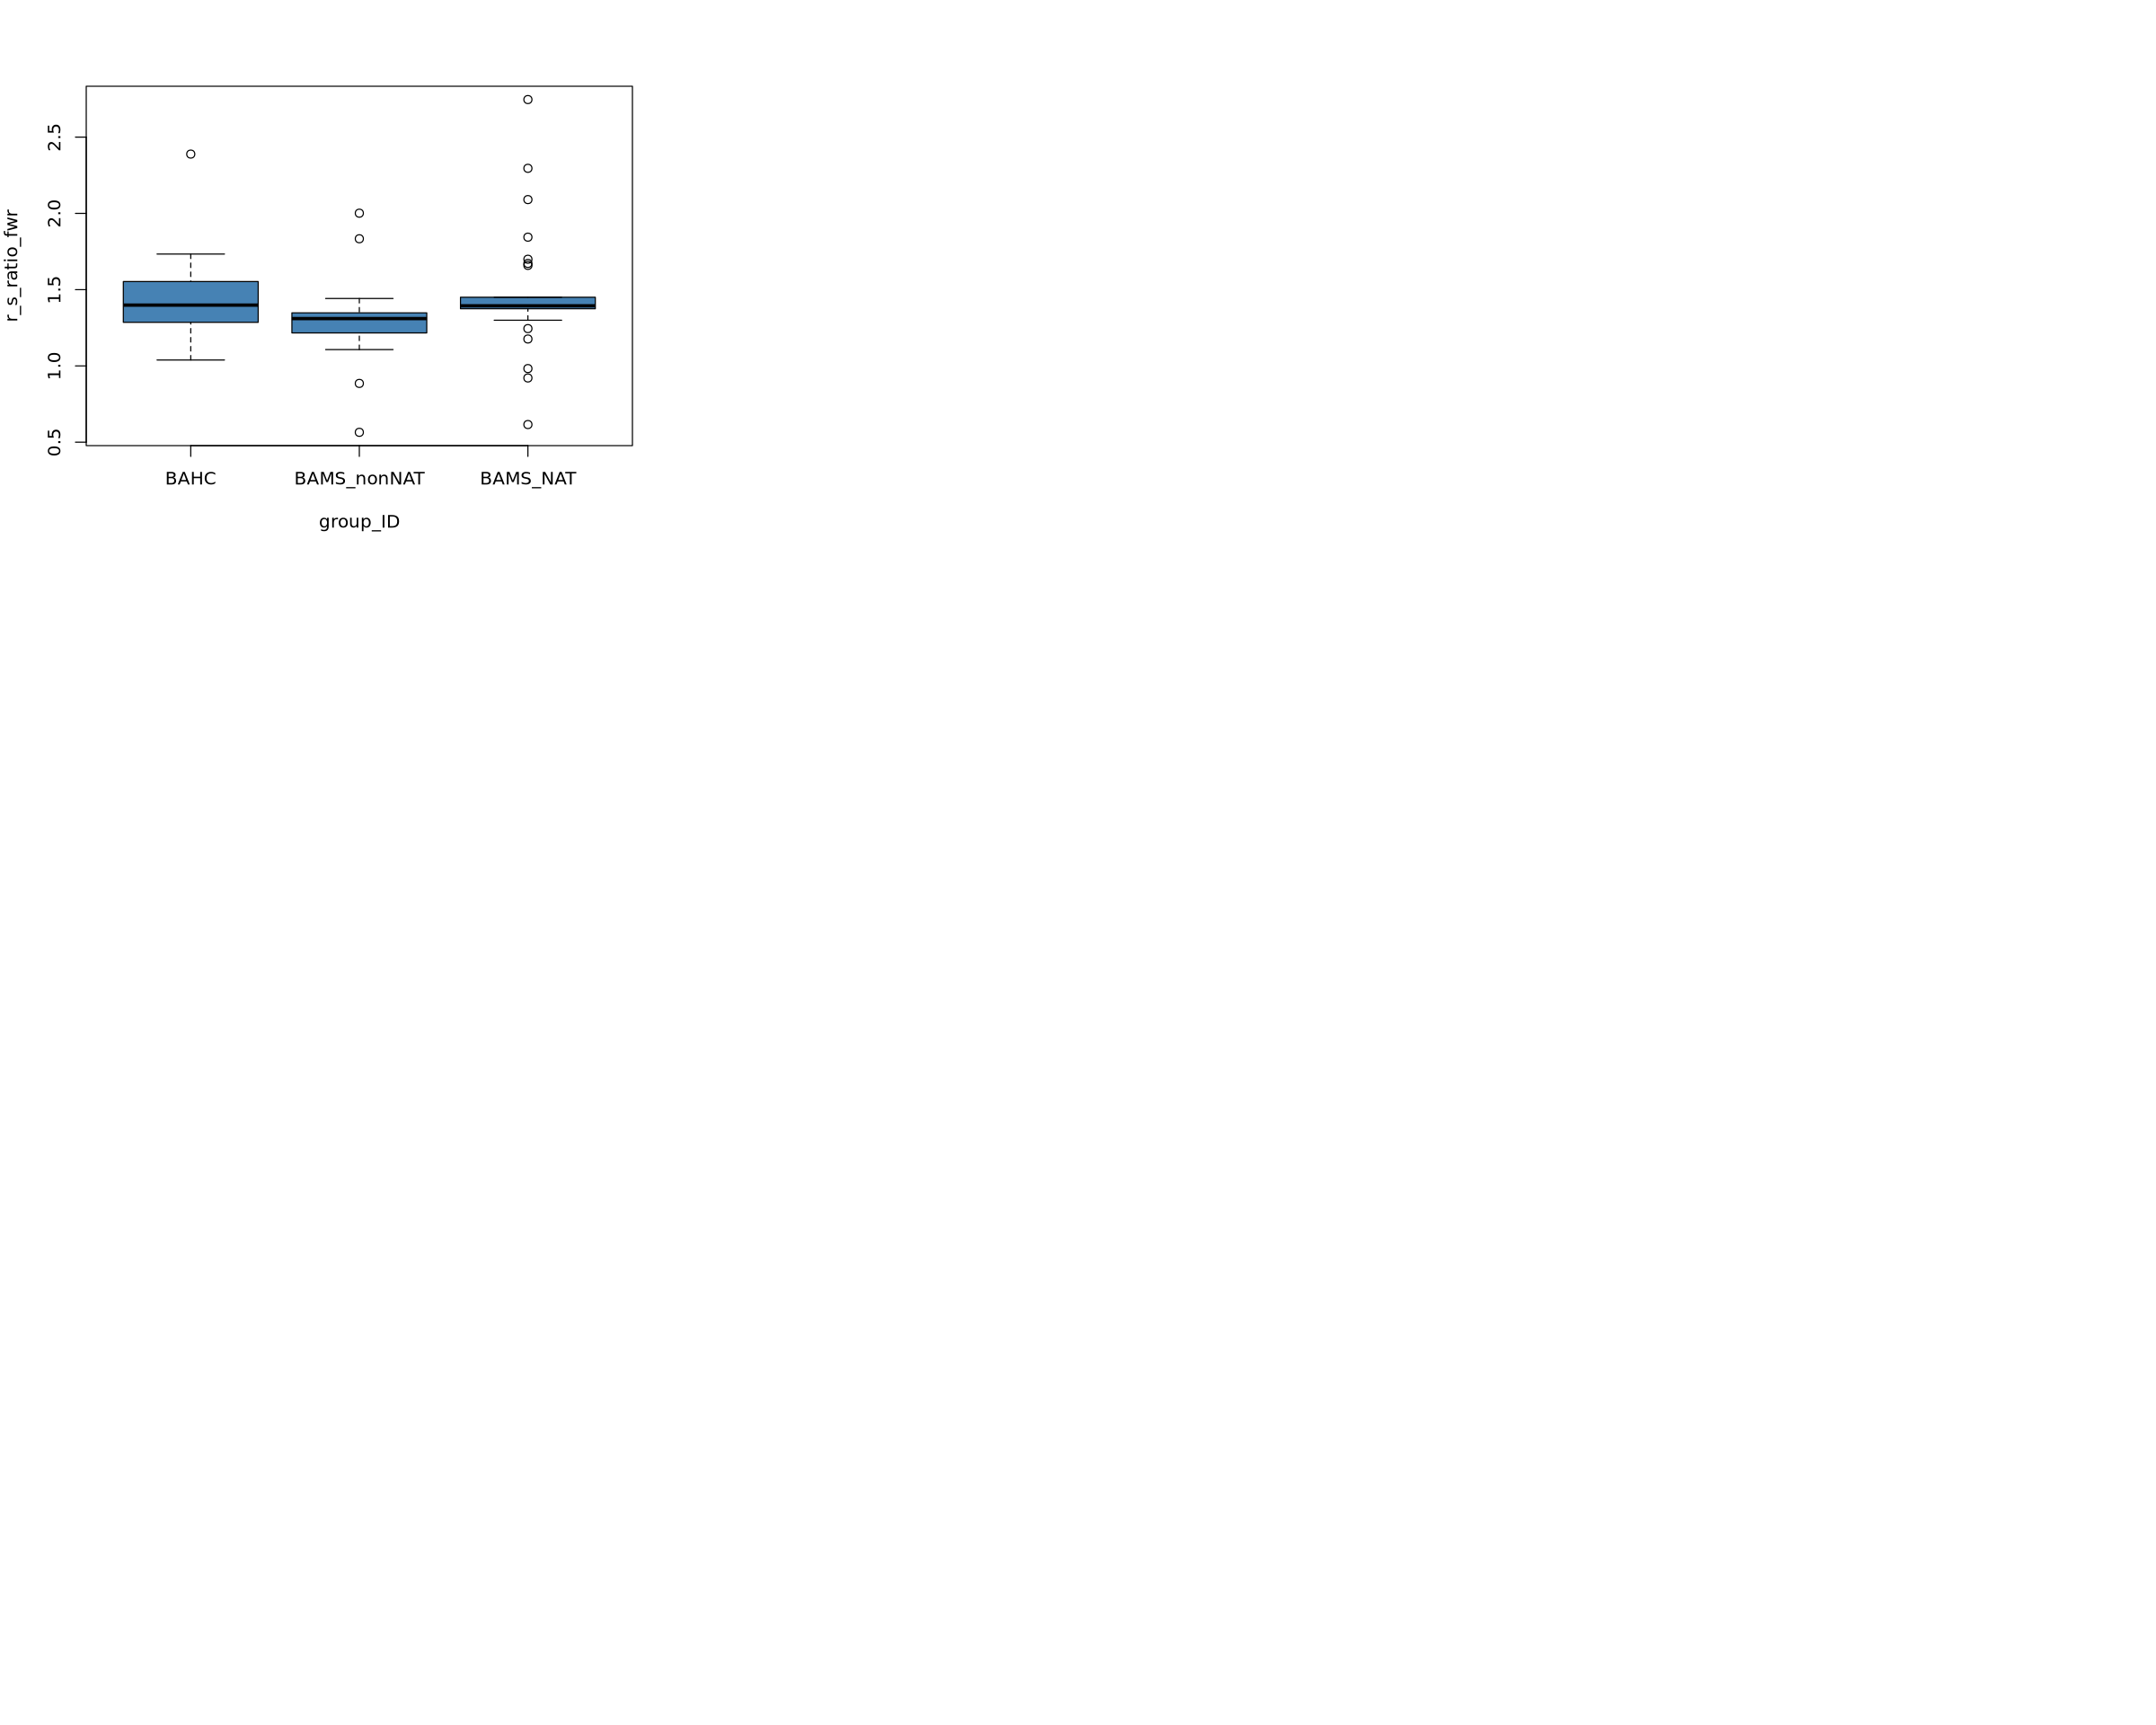

In [22]:
##this next line is jupyter specific only 
options(repr.plot.width = 20, repr.plot.height = 16)

par(
        mfrow = c(3, 3),
        mar = c(6, 4, 4, 4),
        bg = "white",
        cex = "1")
#1
boxplot(mut_freq_nt_all ~ group_ID,
        data = mut_analysis_VH4_04_gene,
        col = "steelblue")
#2
boxplot(r_mut_freq_nt_all ~ group_ID,
        data = mut_analysis_VH4_04_gene,
        col = "steelblue")
#3
boxplot(mut_freq_aa_all ~ group_ID,
        data = mut_analysis_VH4_04_gene,
        col = "steelblue")
#3.2
boxplot(r_mut_freq_aa_all ~ group_ID,
        data = mut_analysis_VH4_04_gene,
        col = "steelblue")
#4
boxplot(mut_freq_cdr_nt ~ group_ID,
        data = mut_analysis_VH4_04_gene,
        col = "steelblue")
#4.2
boxplot(mut_freq_fwr_nt ~ group_ID,
        data = mut_analysis_VH4_04_gene,
        col = "steelblue")
#5
boxplot(r_mut_freq_cdr ~ group_ID,
        data = mut_analysis_VH4_04_gene,
        col = "steelblue")
#5.2
boxplot(r_mut_freq_fwr ~ group_ID,
        data = mut_analysis_VH4_04_gene,
        col = "steelblue")
#6
boxplot(r_s_ratio_cdr ~ group_ID,
        data = mut_analysis_VH4_04_gene,
        col = "steelblue")
#7
boxplot(r_s_ratio_fwr ~ group_ID,
        data = mut_analysis_VH4_04_gene,
        col = "steelblue")

#dev.off()


#### VH4-04:JH6 gene box plots

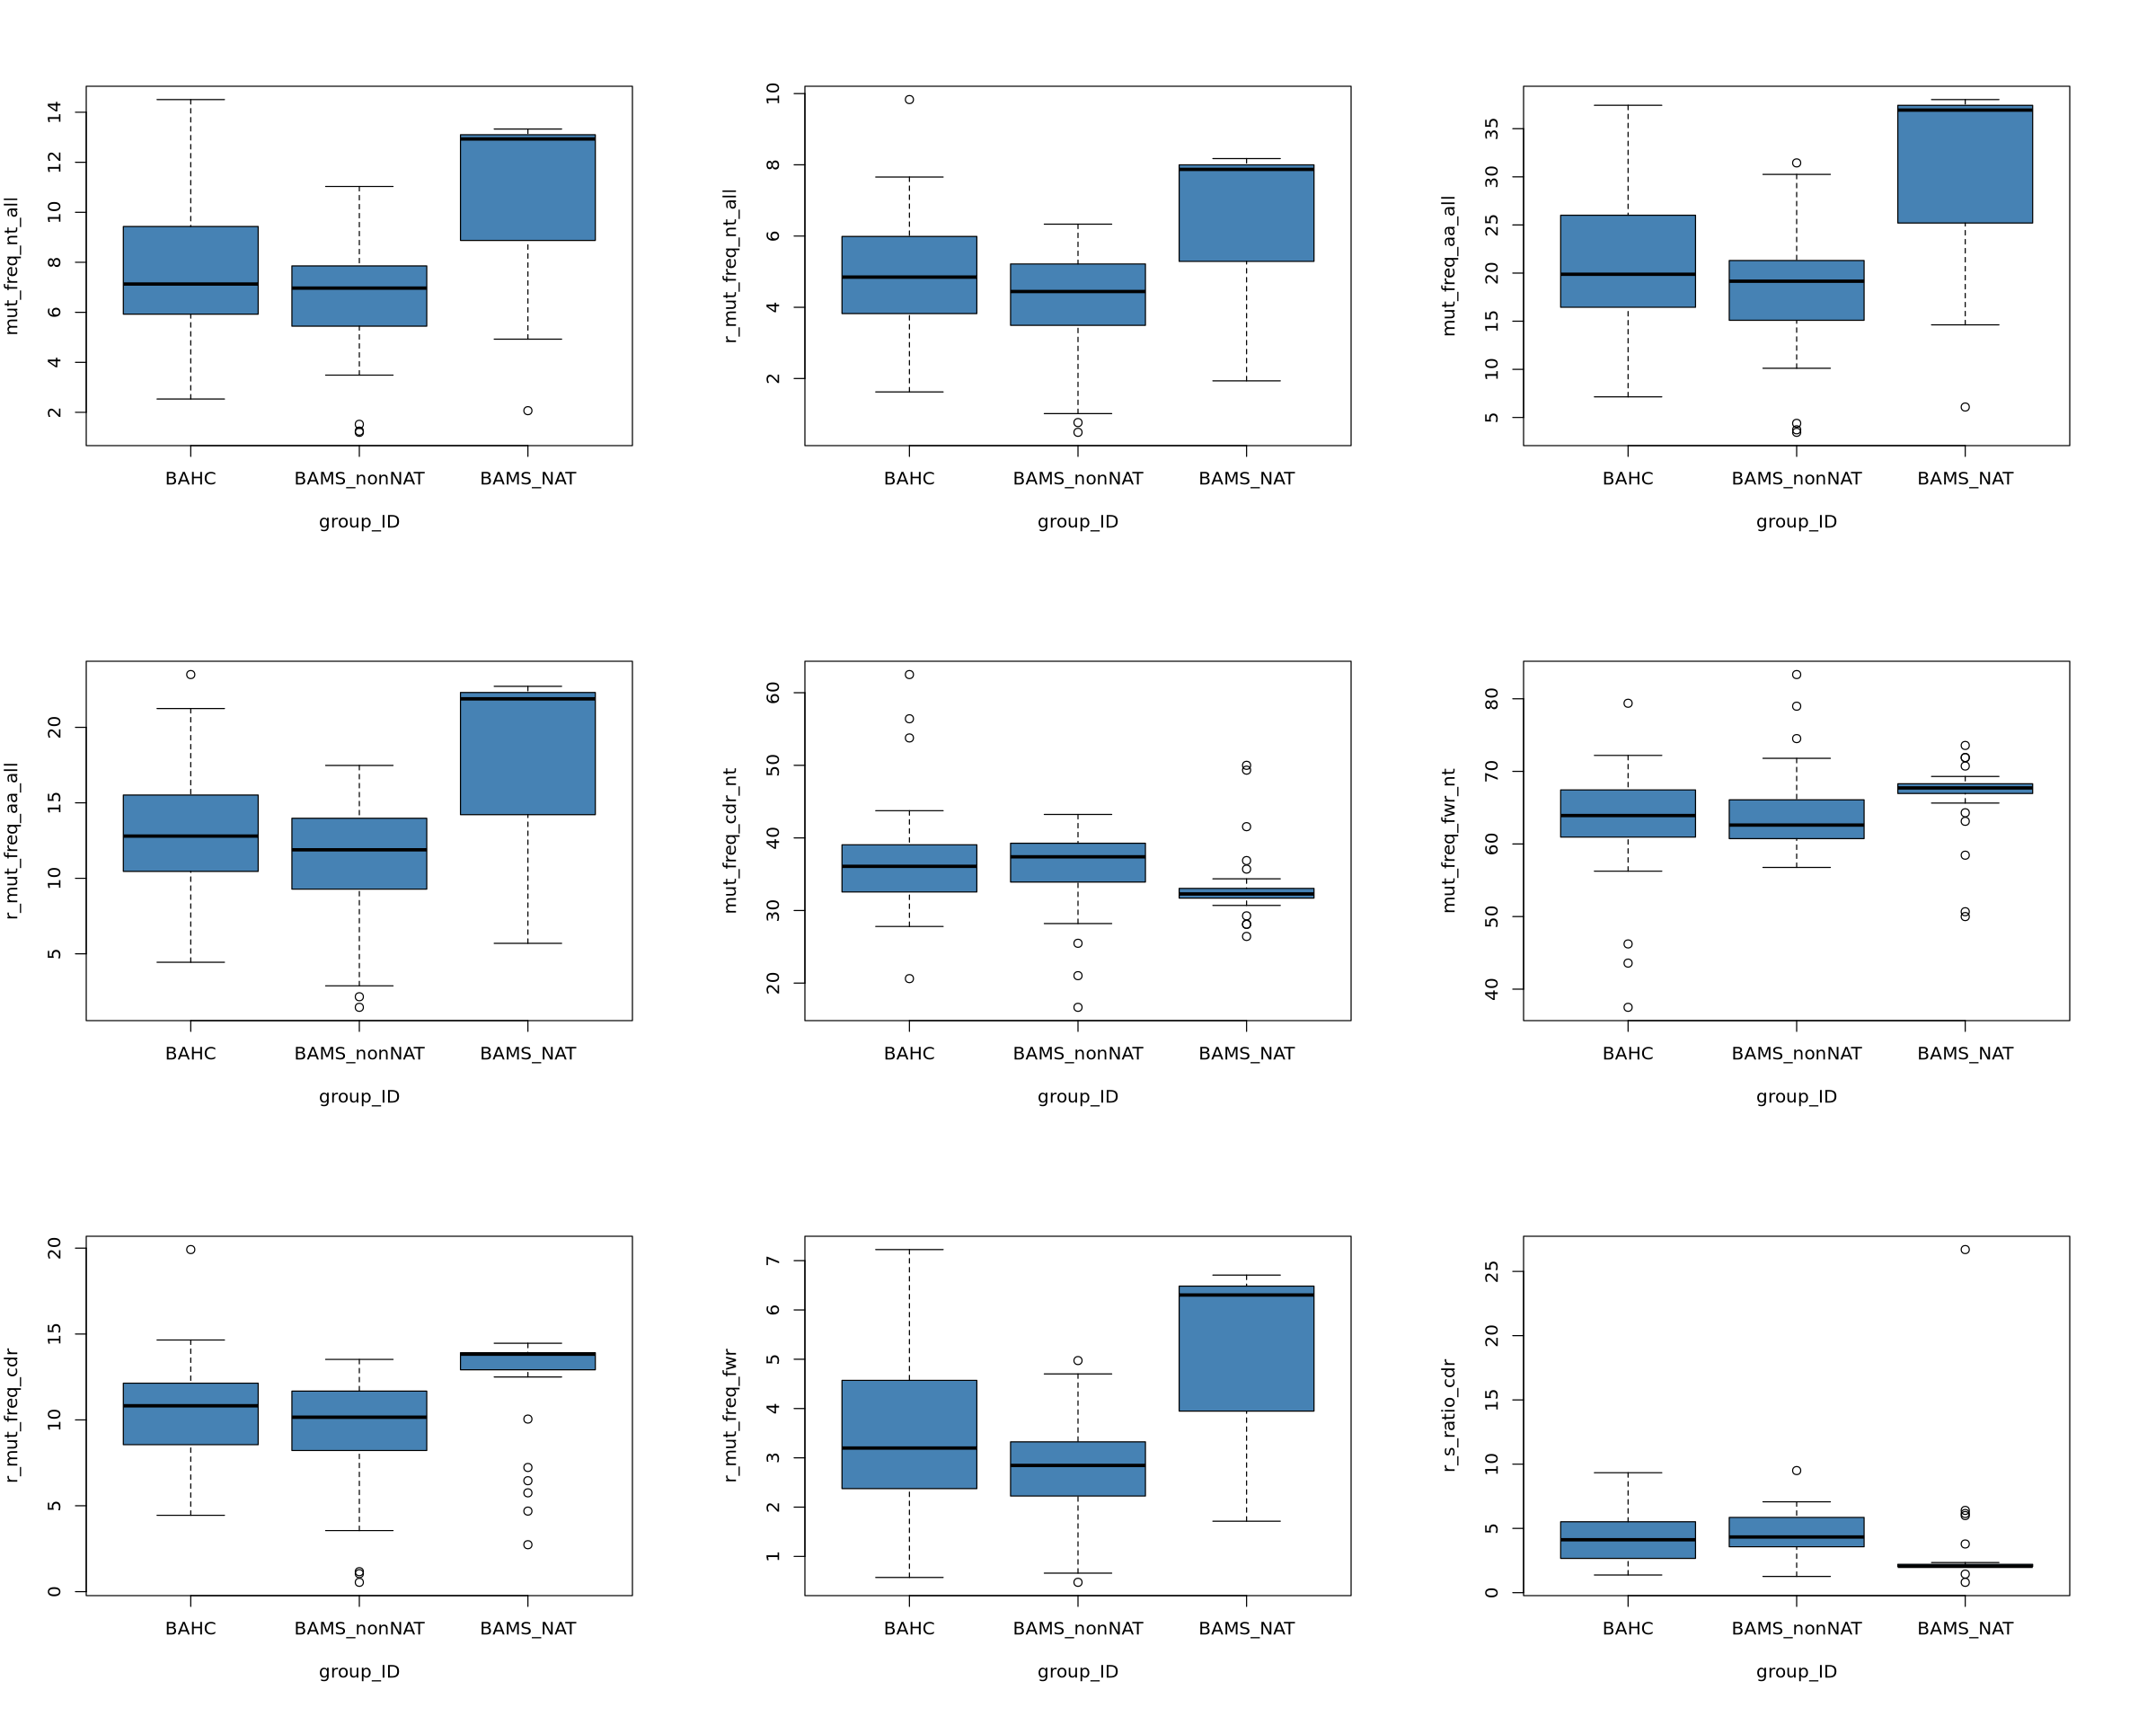

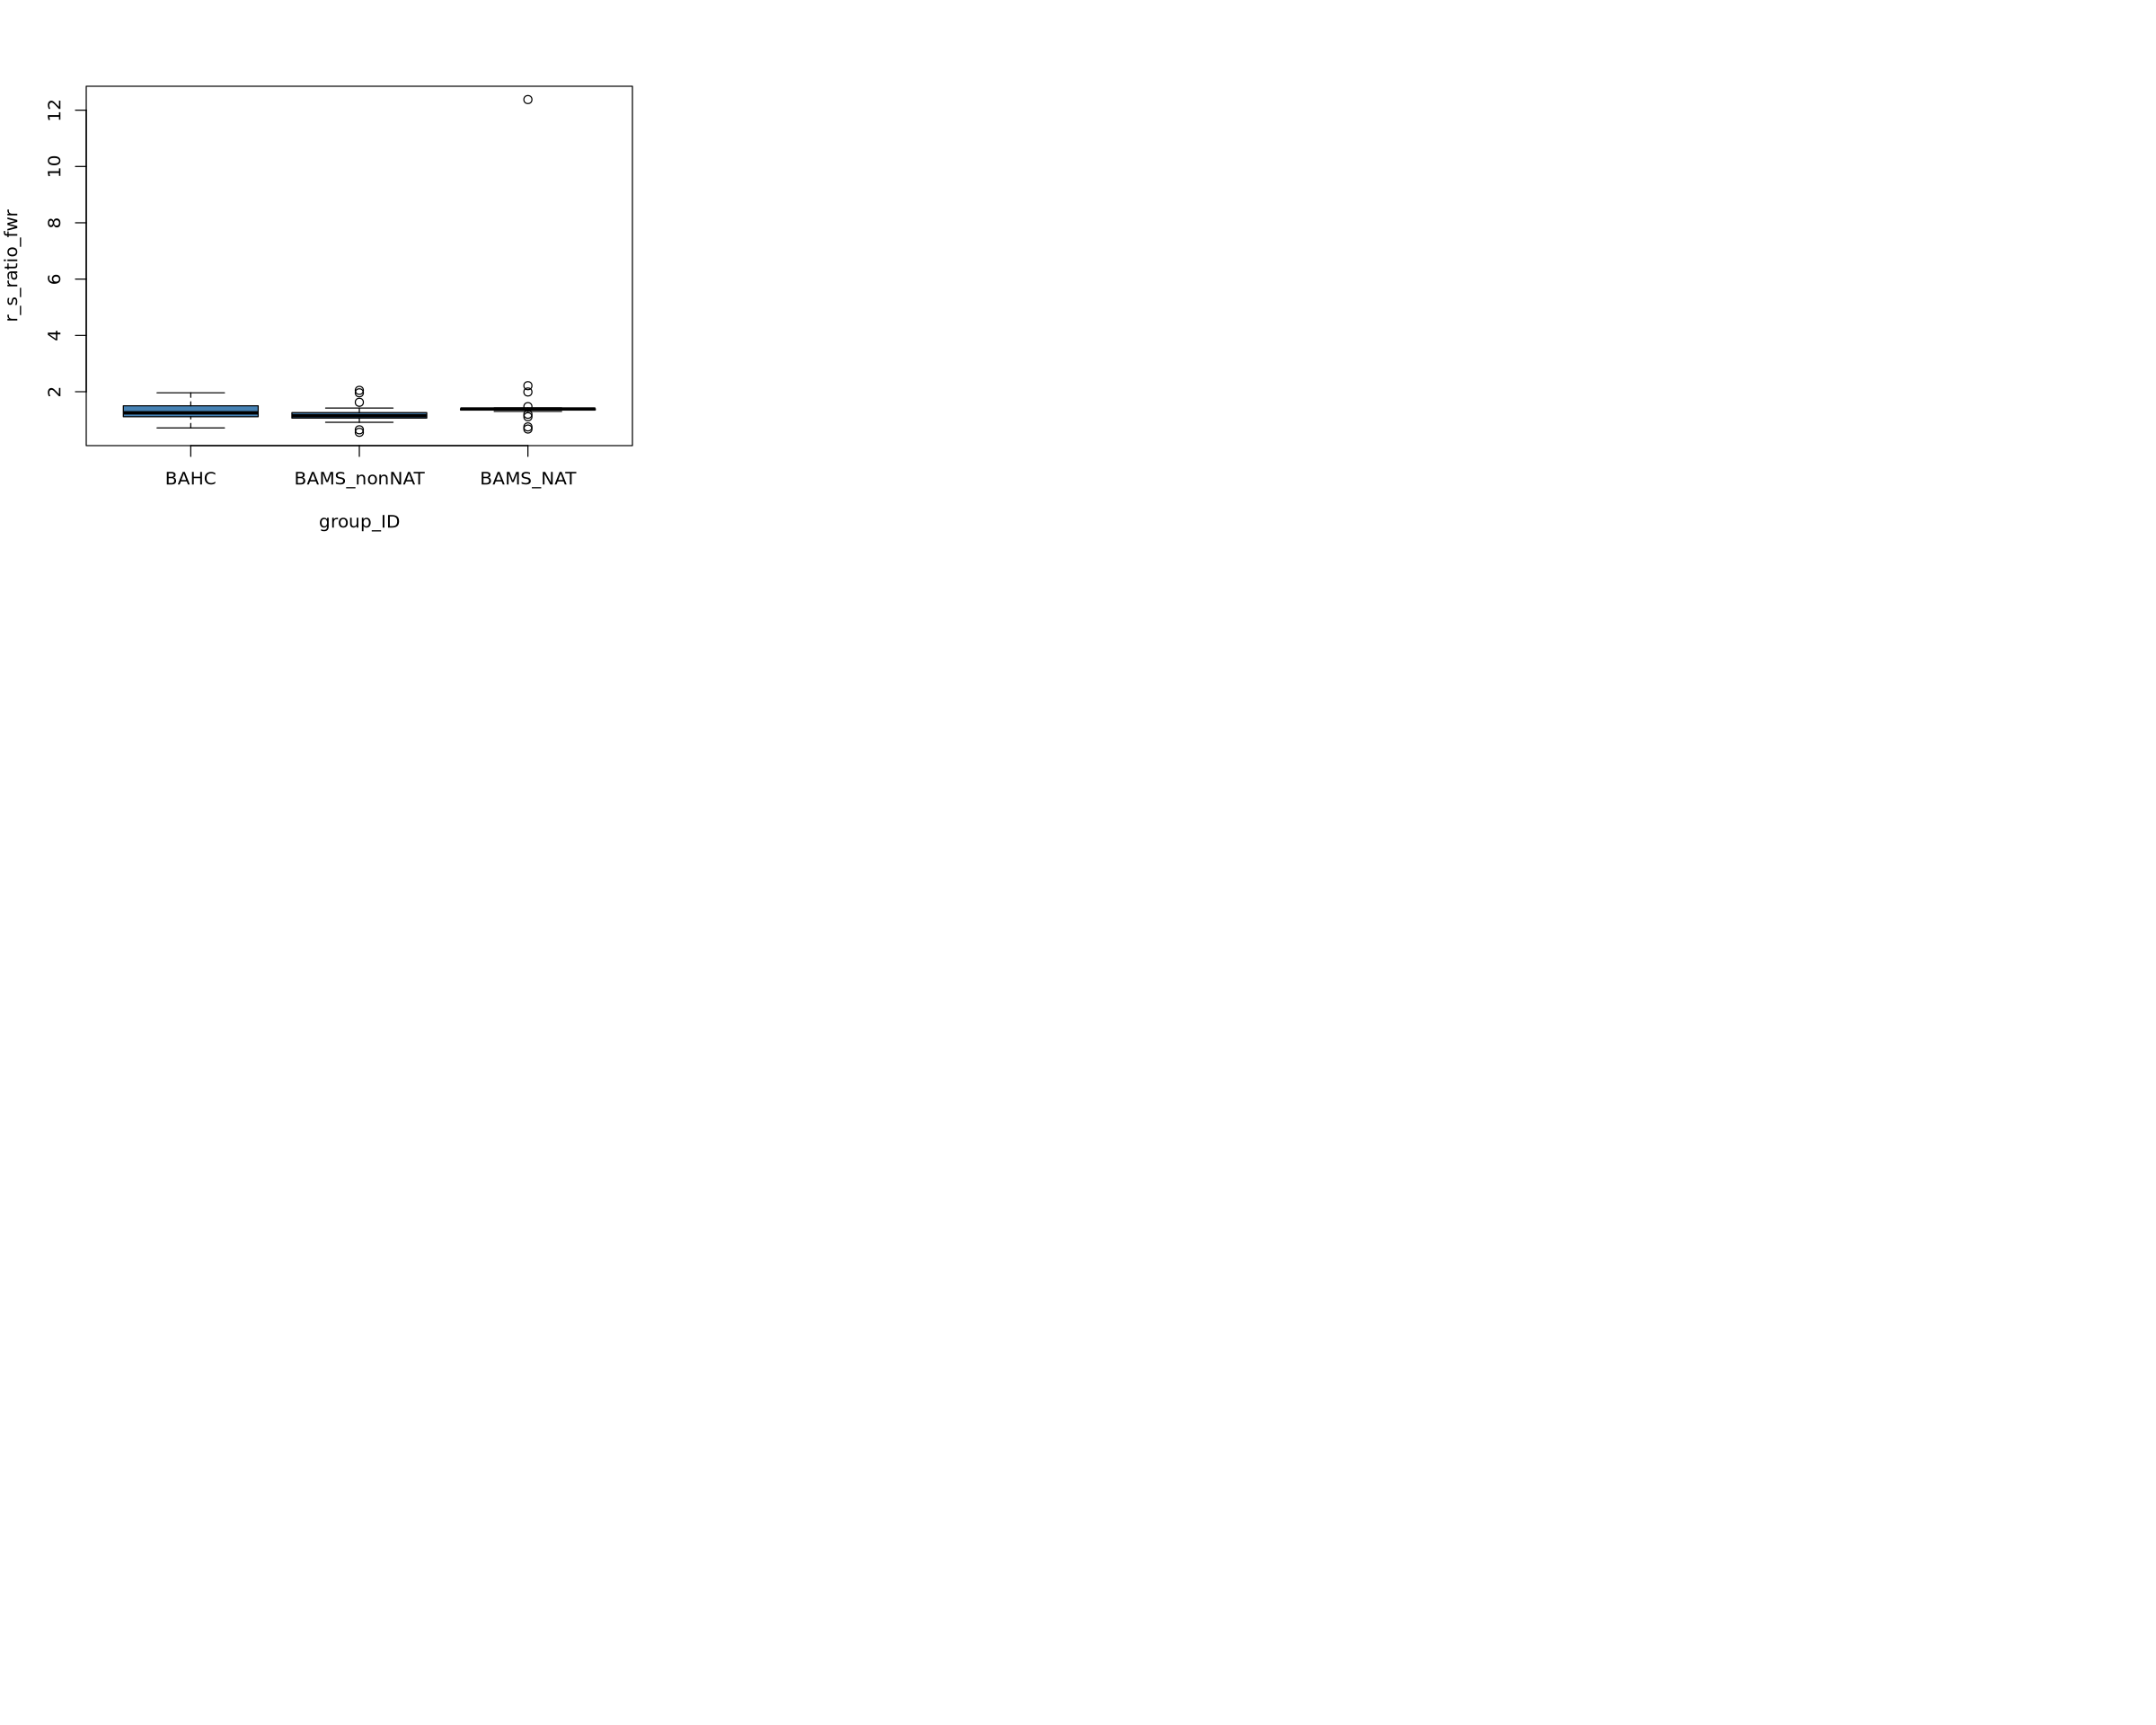

In [23]:
##this next line is jupyter specific only 
options(repr.plot.width = 20, repr.plot.height = 16)

par(
        mfrow = c(3, 3),
        mar = c(6, 4, 4, 4),
        bg = "white",
        cex = "1")
#1
boxplot(mut_freq_nt_all ~ group_ID,
        data = mut_analysis_VH4_04_gene_J6_gene,
        col = "steelblue")
#2
boxplot(r_mut_freq_nt_all ~ group_ID,
        data = mut_analysis_VH4_04_gene_J6_gene,
        col = "steelblue")
#3
boxplot(mut_freq_aa_all ~ group_ID,
        data = mut_analysis_VH4_04_gene_J6_gene,
        col = "steelblue")
#3.2
boxplot(r_mut_freq_aa_all ~ group_ID,
        data = mut_analysis_VH4_04_gene_J6_gene,
        col = "steelblue")
#4
boxplot(mut_freq_cdr_nt ~ group_ID,
        data = mut_analysis_VH4_04_gene_J6_gene,
        col = "steelblue")
#4.2
boxplot(mut_freq_fwr_nt ~ group_ID,
        data = mut_analysis_VH4_04_gene_J6_gene,
        col = "steelblue")
#5
boxplot(r_mut_freq_cdr ~ group_ID,
        data = mut_analysis_VH4_04_gene_J6_gene,
        col = "steelblue")
#5.2
boxplot(r_mut_freq_fwr ~ group_ID,
        data = mut_analysis_VH4_04_gene_J6_gene,
        col = "steelblue")
#6
boxplot(r_s_ratio_cdr ~ group_ID,
        data = mut_analysis_VH4_04_gene_J6_gene,
        col = "steelblue")
#7
boxplot(r_s_ratio_fwr ~ group_ID,
        data = mut_analysis_VH4_04_gene_J6_gene,
        col = "steelblue")

#dev.off()


# Statistical analysis: 
### levene test, welch's one way anova, and pairwise comparisons

###### start with levene test for group variance, a significant pvalue rejects the null of equal variances, tells you welch's is appropriate. 2-8 rejected null confirmed
###### if levene test pvalue is high you fail to reject the null of equal variance and need to use regular anova aov()

#### 1 mutation frequency by nucleotide overall 

##### overall

In [141]:
leveneTest(mut_freq_nt_all ~ group_ID,
           data = mut_analysis_summary)

mut_freq_nt_all_model <- oneway.test(mut_freq_nt_all ~ group_ID,
                                     data = mut_analysis_summary,
                                     var.equal = FALSE)

mut_freq_nt_all_model <- tidy(mut_freq_nt_all_model) %>%
  mutate(analysis_name = "mut_freq_nt_all_model")

mut_freq_nt_all_ttest <- mut_analysis_summary %>%
  pairwise_t_test(
    mut_freq_nt_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_nt_all_ttest <- tidy(mut_freq_nt_all_ttest)

mut_freq_nt_all_model
mut_freq_nt_all_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,8.970449,0.0002645338
,98,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,58.36681,7.639228,0.001130037,One-way analysis of means (not assuming equal variances),mut_freq_nt_all_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_nt_all,BAHC,BAMS_nonNAT,36,30,2.815599,50.86017,0.0069104747,0.010365712,*,14.741,1,2
mut_freq_nt_all,BAHC,BAMS_NAT,36,35,-2.044016,47.44186,0.0465249435,0.046524944,*,15.923,1,3
mut_freq_nt_all,BAMS_nonNAT,BAMS_NAT,30,35,-3.761819,58.98089,0.0003901085,0.001170325,**,17.105,2,3


##### VH4 FAMILY

In [142]:
leveneTest(mut_freq_nt_all ~ group_ID,
           data = mut_analysis_VH4_family)

mut_freq_nt_all_VH4_fam_model <- oneway.test(mut_freq_nt_all ~ group_ID,
                                     data = mut_analysis_VH4_family,
                                     var.equal = FALSE)

mut_freq_nt_all_VH4_fam_model <- tidy(mut_freq_nt_all_VH4_fam_model) %>%
  mutate(analysis_name = "mut_freq_nt_all_VH4_fam_model")

mut_freq_nt_all_VH4_fam_ttest <- mut_analysis_VH4_family %>%
  pairwise_t_test(
    mut_freq_nt_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_nt_all_VH4_fam_ttest <- tidy(mut_freq_nt_all_VH4_fam_ttest)

mut_freq_nt_all_VH4_fam_model
mut_freq_nt_all_VH4_fam_ttest



,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,6.790277,0.001737838
,97,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,59.97902,17.57744,9.817995e-07,One-way analysis of means (not assuming equal variances),mut_freq_nt_all_VH4_fam_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_nt_all,BAHC,BAMS_nonNAT,36,30,2.332830,56.84584,2.322021e-02,2.322021e-02,*,22.853,1,2
mut_freq_nt_all,BAHC,BAMS_NAT,36,34,-4.635392,49.00573,2.666796e-05,4.000194e-05,****,25.495,1,3
mut_freq_nt_all,BAMS_nonNAT,BAMS_NAT,30,34,-5.954563,55.90356,1.811514e-07,5.434541e-07,****,28.137,2,3


##### VH4 JH6

In [143]:
leveneTest(mut_freq_nt_all ~ group_ID,
           data = mut_analysis_VH4_family_J6_gene)

mut_freq_nt_all_VH4_fam_JH6_model <- oneway.test(mut_freq_nt_all ~ group_ID,
                                     data = mut_analysis_VH4_family_J6_gene,
                                     var.equal = FALSE)

mut_freq_nt_all_VH4_fam_JH6_model <- tidy(mut_freq_nt_all_VH4_fam_JH6_model) %>%
  mutate(analysis_name = "mut_freq_nt_all_VH4_fam_JH6_model")

mut_freq_nt_all_VH4_fam_JH6_ttest <- mut_analysis_VH4_family_J6_gene %>%
  pairwise_t_test(
    mut_freq_nt_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_nt_all_VH4_fam_JH6_ttest <- tidy(mut_freq_nt_all_VH4_fam_JH6_ttest)

mut_freq_nt_all_VH4_fam_JH6_model
mut_freq_nt_all_VH4_fam_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.892295,0.00390956
,92,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.11124,12.32138,3.664445e-05,One-way analysis of means (not assuming equal variances),mut_freq_nt_all_VH4_fam_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_nt_all,BAHC,BAMS_nonNAT,35,29,1.727921,56.42358,8.947249e-02,8.947249e-02,ns,13.97475,1,2
mut_freq_nt_all,BAHC,BAMS_NAT,35,31,-4.054417,42.92057,2.076888e-04,3.115332e-04,***,14.68850,1,3
mut_freq_nt_all,BAMS_nonNAT,BAMS_NAT,29,31,-4.986738,48.09653,8.400317e-06,2.520095e-05,****,15.40225,2,3


##### VH4-04 GENE
###### failed leveneTest

In [144]:
leveneTest(mut_freq_nt_all ~ group_ID,
           data = mut_analysis_VH4_04_gene)

mut_freq_nt_all_VH4_04_gene_model <- oneway.test(mut_freq_nt_all ~ group_ID,
                                     data = mut_analysis_VH4_04_gene,
                                     var.equal = FALSE)

mut_freq_nt_all_VH4_04_gene_model <- tidy(mut_freq_nt_all_VH4_04_gene_model) %>%
  mutate(analysis_name = "mut_freq_nt_all_VH4_04_gene_model")

mut_freq_nt_all_VH4_04_gene_ttest <- mut_analysis_VH4_04_gene %>%
  pairwise_t_test(
    mut_freq_nt_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_nt_all_VH4_04_gene_ttest <- tidy(mut_freq_nt_all_VH4_04_gene_ttest)

mut_freq_nt_all_VH4_04_gene_model
mut_freq_nt_all_VH4_04_gene_ttest



,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,2.588863,0.08069069
,90,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.12531,15.07369,5.758267e-06,One-way analysis of means (not assuming equal variances),mut_freq_nt_all_VH4_04_gene_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_nt_all,BAHC,BAMS_nonNAT,35,28,1.533183,57.66920,1.306989e-01,1.306989e-01,ns,25.25325,1,2
mut_freq_nt_all,BAHC,BAMS_NAT,35,30,-4.522050,46.28393,4.243968e-05,6.365952e-05,****,28.05550,1,3
mut_freq_nt_all,BAMS_nonNAT,BAMS_NAT,28,30,-5.474294,48.68867,1.518636e-06,4.555907e-06,****,30.85775,2,3


##### VH4-04 JH6
###### failed leveneTest


In [145]:
leveneTest(mut_freq_nt_all ~ group_ID,
           data = mut_analysis_VH4_04_gene_J6_gene)

mut_freq_nt_all_VH4_04_JH6_model <- oneway.test(mut_freq_nt_all ~ group_ID,
                                     data = mut_analysis_VH4_04_gene_J6_gene,
                                     var.equal = FALSE)

mut_freq_nt_all_VH4_04_JH6_model <- tidy(mut_freq_nt_all_VH4_04_JH6_model) %>%
  mutate(analysis_name = "mut_freq_nt_all_VH4_04_JH6_fam_model")

mut_freq_nt_all_VH4_04_JH6_ttest <- mut_analysis_VH4_04_gene_J6_gene %>%
  pairwise_t_test(
    mut_freq_nt_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_nt_all_VH4_04_JH6_ttest <- tidy(mut_freq_nt_all_VH4_04_JH6_ttest)

mut_freq_nt_all_VH4_04_JH6_model
mut_freq_nt_all_VH4_04_JH6_ttest


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.1938685,0.8241211
,87,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.36981,16.21912,2.72984e-06,One-way analysis of means (not assuming equal variances),mut_freq_nt_all_VH4_04_JH6_fam_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_nt_all,BAHC,BAMS_nonNAT,34,28,1.597469,59.23127,1.154829e-01,1.154829e-01,ns,15.37675,1,2
mut_freq_nt_all,BAHC,BAMS_NAT,34,28,-4.254826,54.07640,8.359942e-05,1.253991e-04,***,16.24550,1,3
mut_freq_nt_all,BAMS_nonNAT,BAMS_NAT,28,28,-5.637362,51.57962,7.313192e-07,2.193958e-06,****,17.11425,2,3


#### 2 replacement mutation frequency by nucleotide 

##### overall

In [146]:
leveneTest(r_mut_freq_nt_all ~ group_ID,
           data = mut_analysis_summary)

r_mut_freq_nt_all_model <- oneway.test(r_mut_freq_nt_all ~ group_ID,
                                     data = mut_analysis_summary,
                                     var.equal = FALSE)

r_mut_freq_nt_all_model <- tidy(r_mut_freq_nt_all_model) %>%
  mutate(analysis_name = "r_mut_freq_nt_all_model")

r_mut_freq_nt_all_ttest <- mut_analysis_summary %>%
  pairwise_t_test(
    r_mut_freq_nt_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_nt_all_ttest <- tidy(r_mut_freq_nt_all_ttest)

r_mut_freq_nt_all_model
r_mut_freq_nt_all_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.545502,0.005229015
,98,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,59.32134,6.800858,0.002191822,One-way analysis of means (not assuming equal variances),r_mut_freq_nt_all_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_nt_all,BAHC,BAMS_nonNAT,36,30,2.926265,51.90516,0.005079628,0.007619442,**,9.074,1,2
r_mut_freq_nt_all,BAHC,BAMS_NAT,36,35,-1.481808,50.13060,0.144650272,0.144650272,ns,9.721,1,3
r_mut_freq_nt_all,BAMS_nonNAT,BAMS_NAT,30,35,-3.437956,60.63841,0.001064996,0.003194988,**,10.368,2,3


##### VH4 FAMILY 

In [147]:
leveneTest(r_mut_freq_nt_all ~ group_ID,
           data = mut_analysis_VH4_family)

r_mut_freq_nt_all_VH4_fam_model <- oneway.test(r_mut_freq_nt_all ~ group_ID,
                                     data = mut_analysis_VH4_family,
                                     var.equal = FALSE)

r_mut_freq_nt_all_VH4_fam_model <- tidy(r_mut_freq_nt_all_VH4_fam_model) %>%
  mutate(analysis_name = "r_mut_freq_nt_all_VH4_fam_model")

r_mut_freq_nt_all_VH4_fam_ttest <- mut_analysis_VH4_family %>%
  pairwise_t_test(
    r_mut_freq_nt_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_nt_all_VH4_fam_ttest <- tidy(r_mut_freq_nt_all_VH4_fam_ttest)

r_mut_freq_nt_all_VH4_fam_model
r_mut_freq_nt_all_VH4_fam_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,4.169265,0.01832092
,97,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,61.07767,16.6481,1.694721e-06,One-way analysis of means (not assuming equal variances),r_mut_freq_nt_all_VH4_fam_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_nt_all,BAHC,BAMS_nonNAT,36,30,2.544798,57.82419,1.362597e-02,1.362597e-02,*,12.389,1,2
r_mut_freq_nt_all,BAHC,BAMS_NAT,36,34,-4.159793,53.39177,1.162778e-04,1.744167e-04,***,13.588,1,3
r_mut_freq_nt_all,BAMS_nonNAT,BAMS_NAT,30,34,-5.799017,58.84460,2.800930e-07,8.402789e-07,****,14.787,2,3


##### VH4 JH6

In [148]:
leveneTest(r_mut_freq_nt_all ~ group_ID,
           data = mut_analysis_VH4_family_J6_gene)

r_mut_freq_nt_all_VH4_fam_JH6_model <- oneway.test(r_mut_freq_nt_all ~ group_ID,
                                     data = mut_analysis_VH4_family_J6_gene,
                                     var.equal = FALSE)

r_mut_freq_nt_all_VH4_fam_JH6_model <- tidy(r_mut_freq_nt_all_VH4_fam_JH6_model) %>%
  mutate(analysis_name = "r_mut_freq_nt_all_VH4_fam_JH6_model")

r_mut_freq_nt_all_VH4_fam_JH6_ttest <- mut_analysis_VH4_family_J6_gene %>%
  pairwise_t_test(
    r_mut_freq_nt_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_nt_all_VH4_fam_JH6_ttest <- tidy(r_mut_freq_nt_all_VH4_fam_JH6_ttest)

r_mut_freq_nt_all_VH4_fam_JH6_model
r_mut_freq_nt_all_VH4_fam_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,6.859834,0.001671374
,92,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,57.34046,11.45336,6.532004e-05,One-way analysis of means (not assuming equal variances),r_mut_freq_nt_all_VH4_fam_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_nt_all,BAHC,BAMS_nonNAT,35,29,1.931273,58.79468,5.827463e-02,5.827463e-02,ns,8.579,1,2
r_mut_freq_nt_all,BAHC,BAMS_NAT,35,31,-3.600943,46.00952,7.739476e-04,1.160921e-03,**,9.039,1,3
r_mut_freq_nt_all,BAMS_nonNAT,BAMS_NAT,29,31,-4.813551,49.06067,1.458529e-05,4.375586e-05,****,9.499,2,3


##### VH4-04 GENE 
###### failed levene

In [149]:
leveneTest(r_mut_freq_nt_all ~ group_ID,
           data = mut_analysis_VH4_04_gene)

r_mut_freq_nt_all_VH4_04_gene_model <- oneway.test(r_mut_freq_nt_all ~ group_ID,
                                     data = mut_analysis_VH4_04_gene,
                                     var.equal = FALSE)

r_mut_freq_nt_all_VH4_04_gene_model <- tidy(r_mut_freq_nt_all_VH4_04_gene_model) %>%
  mutate(analysis_name = "r_mut_freq_nt_VH4_gene_all_model")

r_mut_freq_nt_all_VH4_04_gene_ttest <- mut_analysis_VH4_04_gene %>%
  pairwise_t_test(
    r_mut_freq_nt_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_nt_all_VH4_04_gene_ttest <- tidy(r_mut_freq_nt_all_VH4_04_gene_ttest)

r_mut_freq_nt_all_VH4_04_gene_model
r_mut_freq_nt_all_VH4_04_gene_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,2.104548,0.1278602
,90,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,57.41761,14.44689,8.277166e-06,One-way analysis of means (not assuming equal variances),r_mut_freq_nt_VH4_gene_all_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_nt_all,BAHC,BAMS_nonNAT,35,28,1.965566,59.64931,5.400957e-02,5.400957e-02,ns,13.86425,1,2
r_mut_freq_nt_all,BAHC,BAMS_NAT,35,30,-3.911864,51.09856,2.713794e-04,4.070691e-04,***,15.33350,1,3
r_mut_freq_nt_all,BAMS_nonNAT,BAMS_NAT,28,30,-5.401481,50.29836,1.806374e-06,5.419121e-06,****,16.80275,2,3


##### VH4-04 JH6
###### failed levene test

In [150]:
leveneTest(r_mut_freq_nt_all ~ group_ID,
           data = mut_analysis_VH4_04_gene_J6_gene)

r_mut_freq_nt_all_VH4_04_JH6_model <- oneway.test(r_mut_freq_nt_all ~ group_ID,
                                     data = mut_analysis_VH4_04_gene_J6_gene,
                                     var.equal = FALSE)

r_mut_freq_nt_all_VH4_04_JH6_model <- tidy(r_mut_freq_nt_all_VH4_04_JH6_model) %>%
  mutate(analysis_name = "r_mut_freq_nt_VH4_04_JH6_all_model")

r_mut_freq_nt_all_VH4_04_JH6_ttest <- mut_analysis_VH4_04_gene_J6_gene %>%
  pairwise_t_test(
    r_mut_freq_nt_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_nt_all_VH4_04_JH6_ttest <- tidy(r_mut_freq_nt_all_VH4_04_JH6_ttest)

r_mut_freq_nt_all_VH4_04_JH6_model
r_mut_freq_nt_all_VH4_04_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.1396152,0.8698873
,87,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,57.05747,15.82212,3.414596e-06,One-way analysis of means (not assuming equal variances),r_mut_freq_nt_VH4_04_JH6_all_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_nt_all,BAHC,BAMS_nonNAT,34,28,1.797883,59.49043,7.727036e-02,7.727036e-02,ns,10.70775,1,2
r_mut_freq_nt_all,BAHC,BAMS_NAT,34,28,-3.880941,57.30486,2.713174e-04,4.069761e-04,***,11.58250,1,3
r_mut_freq_nt_all,BAMS_nonNAT,BAMS_NAT,28,28,-5.584311,53.18771,8.156052e-07,2.446816e-06,****,12.45725,2,3


#### 3 mutation frequency by aa overall 

##### overall

In [151]:
leveneTest(mut_freq_aa_all ~ group_ID,
           data = mut_analysis_summary)

mut_freq_aa_all_model <- oneway.test(mut_freq_aa_all ~ group_ID,
                                     data = mut_analysis_summary,
                                     var.equal = FALSE)

mut_freq_aa_all_model <- tidy(mut_freq_aa_all_model) %>%
  mutate(analysis_name = "mut_freq_aa_all_model")

mut_freq_aa_all_ttest <- mut_analysis_summary %>%
  pairwise_t_test(
    mut_freq_aa_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_aa_all_ttest <- tidy(mut_freq_aa_all_ttest)

mut_freq_aa_all_model
mut_freq_aa_all_ttest


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,10.34098,8.418331e-05
,98,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,57.61474,7.859576,0.0009590015,One-way analysis of means (not assuming equal variances),mut_freq_aa_all_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_aa_all,BAHC,BAMS_nonNAT,36,30,2.715468,49.95870,0.0090641843,0.0135962764,*,41.3805,1,2
mut_freq_aa_all,BAHC,BAMS_NAT,36,35,-2.297816,45.68612,0.0262023519,0.0262023519,*,44.8050,1,3
mut_freq_aa_all,BAMS_nonNAT,BAMS_NAT,30,35,-3.854758,57.69456,0.0002937803,0.0008813409,***,48.2295,2,3


##### VH4 FAMILY

In [152]:
leveneTest(mut_freq_aa_all ~ group_ID,
           data = mut_analysis_VH4_family)

mut_freq_aa_all_VH4_fam_model <- oneway.test(mut_freq_aa_all ~ group_ID,
                                     data = mut_analysis_VH4_family,
                                     var.equal = FALSE)

mut_freq_aa_all_VH4_fam_model <- tidy(mut_freq_aa_all_VH4_fam_model) %>%
  mutate(analysis_name = "mut_freq_aa_all_VH4_fam_model")

mut_freq_aa_all_VH4_fam_ttest <- mut_analysis_VH4_family %>%
  pairwise_t_test(
    mut_freq_aa_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_aa_all_VH4_fam_ttest <- tidy(mut_freq_aa_all_VH4_fam_ttest)

mut_freq_aa_all_VH4_fam_model
mut_freq_aa_all_VH4_fam_ttest


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,8.92618,0.0002764667
,97,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,59.85125,18.36575,6.034869e-07,One-way analysis of means (not assuming equal variances),mut_freq_aa_all_VH4_fam_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_aa_all,BAHC,BAMS_nonNAT,36,30,2.196658,56.72272,3.214685e-02,3.214685e-02,*,61.38875,1,2
mut_freq_aa_all,BAHC,BAMS_NAT,36,34,-4.878801,48.55444,1.190815e-05,1.786222e-05,****,68.32750,1,3
mut_freq_aa_all,BAMS_nonNAT,BAMS_NAT,30,34,-6.074931,55.55473,1.177978e-07,3.533933e-07,****,75.26625,2,3


##### VH4 JH6

In [153]:
leveneTest(mut_freq_aa_all ~ group_ID,
           data = mut_analysis_VH4_family_J6_gene)

mut_freq_aa_all_VH4_fam_JH6_model <- oneway.test(mut_freq_aa_all ~ group_ID,
                                     data = mut_analysis_VH4_family_J6_gene,
                                     var.equal = FALSE)

mut_freq_aa_all_VH4_fam_JH6_model <- tidy(mut_freq_aa_all_VH4_fam_JH6_model) %>%
  mutate(analysis_name = "mut_freq_aa_all_VH4_fam_JH6_model")

mut_freq_aa_all_VH4_fam_JH6_ttest <- mut_analysis_VH4_family_J6_gene %>%
  pairwise_t_test(
    mut_freq_aa_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_aa_all_VH4_fam_JH6_ttest <- tidy(mut_freq_aa_all_VH4_fam_JH6_ttest)

mut_freq_aa_all_VH4_fam_JH6_model
mut_freq_aa_all_VH4_fam_JH6_ttest


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,8.351657,0.0004645922
,92,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,55.85792,12.59706,3.051194e-05,One-way analysis of means (not assuming equal variances),mut_freq_aa_all_VH4_fam_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_aa_all,BAHC,BAMS_nonNAT,35,29,1.719354,56.27179,9.104663e-02,9.104663e-02,ns,40.041,1,2
mut_freq_aa_all,BAHC,BAMS_NAT,35,31,-4.143543,42.04777,1.616197e-04,2.424296e-04,***,42.181,1,3
mut_freq_aa_all,BAMS_nonNAT,BAMS_NAT,29,31,-5.043280,47.20672,7.199785e-06,2.159936e-05,****,44.321,2,3


##### VH4-04 GENE

In [154]:
leveneTest(mut_freq_aa_all ~ group_ID,
           data = mut_analysis_VH4_04_gene)

mut_freq_aa_all_VH4_04_gene_model <- oneway.test(mut_freq_aa_all ~ group_ID,
                                     data = mut_analysis_VH4_04_gene,
                                     var.equal = FALSE)

mut_freq_aa_all_VH4_04_gene_model <- tidy(mut_freq_aa_all_VH4_04_gene_model) %>%
  mutate(analysis_name = "mut_freq_aa_all_VH4_04_gene_model")

mut_freq_aa_all_VH4_04_gene_ttest <- mut_analysis_VH4_04_gene %>%
  pairwise_t_test(
    mut_freq_aa_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_aa_all_VH4_04_gene_ttest <- tidy(mut_freq_aa_all_VH4_04_gene_ttest)

mut_freq_aa_all_VH4_04_gene_model
mut_freq_aa_all_VH4_04_gene_ttest


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,3.021732,0.053686
,90,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,55.78114,16.02463,3.170771e-06,One-way analysis of means (not assuming equal variances),mut_freq_aa_all_VH4_04_gene_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_aa_all,BAHC,BAMS_nonNAT,35,28,1.474066,57.07126,1.459587e-01,1.459587e-01,ns,67.70225,1,2
mut_freq_aa_all,BAHC,BAMS_NAT,35,30,-4.767713,45.23550,1.966593e-05,2.949890e-05,****,74.95350,1,3
mut_freq_aa_all,BAMS_nonNAT,BAMS_NAT,28,30,-5.628734,48.32562,9.032605e-07,2.709781e-06,****,82.20475,2,3


##### VH4-04 JH6
###### failed levene

In [155]:
leveneTest(mut_freq_aa_all ~ group_ID,
           data = mut_analysis_VH4_04_gene_J6_gene)

mut_freq_aa_all_VH4_04_JH6_model <- oneway.test(mut_freq_aa_all ~ group_ID,
                                     data = mut_analysis_VH4_04_gene_J6_gene,
                                     var.equal = FALSE)

mut_freq_aa_all_VH4_04_JH6_model <- tidy(mut_freq_aa_all_VH4_04_JH6_model) %>%
  mutate(analysis_name = "mut_freq_aa_all_VH4_04_JH6_model")

mut_freq_aa_all_VH4_04_JH6_ttest <- mut_analysis_VH4_04_gene_J6_gene %>%
  pairwise_t_test(
    mut_freq_aa_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_aa_all_VH4_04_JH6_ttest <- tidy(mut_freq_aa_all_VH4_04_JH6_ttest)

mut_freq_aa_all_VH4_04_JH6_model
mut_freq_aa_all_VH4_04_JH6_ttest


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.2272426,0.7971989
,87,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.00314,17.20918,1.492833e-06,One-way analysis of means (not assuming equal variances),mut_freq_aa_all_VH4_04_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_aa_all,BAHC,BAMS_nonNAT,34,28,1.578149,59.02183,1.198765e-01,1.198765e-01,ns,39.671,1,2
mut_freq_aa_all,BAHC,BAMS_NAT,34,28,-4.504965,52.36971,3.750211e-05,5.625316e-05,****,41.316,1,3
mut_freq_aa_all,BAMS_nonNAT,BAMS_NAT,28,28,-5.803386,50.73461,4.227321e-07,1.268196e-06,****,42.961,2,3


#### 3.2 replacement mutation frequency by aa overall 

##### overall

In [156]:
leveneTest(r_mut_freq_aa_all ~ group_ID,
           data = mut_analysis_summary)

r_mut_freq_aa_all_model <- oneway.test(r_mut_freq_aa_all ~ group_ID,
                                     data = mut_analysis_summary,
                                     var.equal = FALSE)

r_mut_freq_aa_all_model <- tidy(r_mut_freq_aa_all_model) %>%
  mutate(analysis_name = "r_mut_freq_aa_all_model")

r_mut_freq_aa_all_ttest <- mut_analysis_summary %>%
  pairwise_t_test(
    r_mut_freq_aa_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_aa_all_ttest <- tidy(r_mut_freq_aa_all_ttest)

r_mut_freq_aa_all_model
r_mut_freq_aa_all_ttest


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,7.232366,0.001175645
,98,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,58.28759,7.123907,0.001706472,One-way analysis of means (not assuming equal variances),r_mut_freq_aa_all_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_aa_all,BAHC,BAMS_nonNAT,36,30,2.790142,50.69793,0.0074055066,0.011108260,*,24.37725,1,2
r_mut_freq_aa_all,BAHC,BAMS_NAT,36,35,-1.889785,47.34573,0.0649178763,0.064917876,ns,26.12950,1,3
r_mut_freq_aa_all,BAMS_nonNAT,BAMS_NAT,30,35,-3.602695,59.00294,0.0006474236,0.001942271,**,27.88175,2,3


##### VH4 FAMILY

In [157]:
leveneTest(r_mut_freq_aa_all ~ group_ID,
           data = mut_analysis_VH4_family)

r_mut_freq_aa_all_VH4_fam_model <- oneway.test(r_mut_freq_aa_all ~ group_ID,
                                     data = mut_analysis_VH4_family,
                                     var.equal = FALSE)

r_mut_freq_aa_all_VH4_fam_model <- tidy(r_mut_freq_aa_all_VH4_fam_model) %>%
  mutate(analysis_name = "r_mut_freq_aa_all_VH4_fam_model")

r_mut_freq_aa_all_VH4_fam_ttest <- mut_analysis_VH4_family %>%
  pairwise_t_test(
    r_mut_freq_aa_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_aa_all_VH4_fam_ttest <- tidy(r_mut_freq_aa_all_VH4_fam_ttest)

r_mut_freq_aa_all_VH4_fam_model
r_mut_freq_aa_all_VH4_fam_ttest


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,6.438476,0.00236842
,97,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,60.74156,17.58598,9.432383e-07,One-way analysis of means (not assuming equal variances),r_mut_freq_aa_all_VH4_fam_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_aa_all,BAHC,BAMS_nonNAT,36,30,2.356279,57.44042,2.189287e-02,2.189287e-02,*,31.54275,1,2
r_mut_freq_aa_all,BAHC,BAMS_NAT,36,34,-4.516677,52.08350,3.632201e-05,5.448302e-05,****,34.43550,1,3
r_mut_freq_aa_all,BAMS_nonNAT,BAMS_NAT,30,34,-5.948083,58.15108,1.646746e-07,4.940238e-07,****,37.32825,2,3


##### VH4 JH6

In [158]:
leveneTest(r_mut_freq_aa_all ~ group_ID,
           data = mut_analysis_VH4_family_J6_gene)

r_mut_freq_aa_all_VH4_fam_JH6_model <- oneway.test(r_mut_freq_aa_all ~ group_ID,
                                     data = mut_analysis_VH4_family_J6_gene,
                                     var.equal = FALSE)

r_mut_freq_aa_all_VH4_fam_JH6_model <- tidy(r_mut_freq_aa_all_VH4_fam_JH6_model) %>%
  mutate(analysis_name = "r_mut_freq_aa_all_VH4_fam_JH6_model")

r_mut_freq_aa_all_VH4_fam_JH6_ttest <- mut_analysis_VH4_family_J6_gene %>%
  pairwise_t_test(
    r_mut_freq_aa_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_aa_all_VH4_fam_JH6_ttest <- tidy(r_mut_freq_aa_all_VH4_fam_JH6_ttest)

r_mut_freq_aa_all_VH4_fam_JH6_model
r_mut_freq_aa_all_VH4_fam_JH6_ttest


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,9.647096,0.0001572191
,92,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.9724,11.77165,5.259146e-05,One-way analysis of means (not assuming equal variances),r_mut_freq_aa_all_VH4_fam_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_aa_all,BAHC,BAMS_nonNAT,35,29,1.945178,58.94954,5.652785e-02,5.652785e-02,ns,24.08525,1,2
r_mut_freq_aa_all,BAHC,BAMS_NAT,35,31,-3.709302,44.21389,5.774007e-04,8.661011e-04,***,25.54650,1,3
r_mut_freq_aa_all,BAMS_nonNAT,BAMS_NAT,29,31,-4.878067,47.07293,1.265181e-05,3.795544e-05,****,27.00775,2,3


##### VH4-04 GENE

In [159]:
leveneTest(r_mut_freq_aa_all ~ group_ID,
           data = mut_analysis_VH4_04_gene)

r_mut_freq_aa_all_VH4_04_gene_model <- oneway.test(r_mut_freq_aa_all ~ group_ID,
                                     data = mut_analysis_VH4_04_gene,
                                     var.equal = FALSE)

r_mut_freq_aa_all_VH4_04_gene_model <- tidy(r_mut_freq_aa_all_VH4_04_gene_model) %>%
  mutate(analysis_name = "r_mut_freq_aa_all_VH4_04_gene_model")

r_mut_freq_aa_all_VH4_04_gene_ttest <- mut_analysis_VH4_04_gene %>%
  pairwise_t_test(
    r_mut_freq_aa_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_aa_all_VH4_04_gene_ttest <- tidy(r_mut_freq_aa_all_VH4_04_gene_ttest)

r_mut_freq_aa_all_VH4_04_gene_model
r_mut_freq_aa_all_VH4_04_gene_ttest


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,2.77157,0.06791021
,90,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.83594,15.66202,3.82083e-06,One-way analysis of means (not assuming equal variances),r_mut_freq_aa_all_VH4_04_gene_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_aa_all,BAHC,BAMS_nonNAT,35,28,1.949518,58.93212,5.599717e-02,5.599717e-02,ns,35.24325,1,2
r_mut_freq_aa_all,BAHC,BAMS_NAT,35,30,-4.251349,48.65133,9.587652e-05,1.438148e-04,***,38.79650,1,3
r_mut_freq_aa_all,BAMS_nonNAT,BAMS_NAT,28,30,-5.620249,49.30482,8.799448e-07,2.639834e-06,****,42.34975,2,3


##### VH4-04 JH6
###### failed levene

In [160]:
leveneTest(r_mut_freq_aa_all ~ group_ID,
           data = mut_analysis_VH4_04_gene_J6_gene)

r_mut_freq_aa_all_VH4_04_JH6_model <- oneway.test(r_mut_freq_aa_all ~ group_ID,
                                     data = mut_analysis_VH4_04_gene_J6_gene,
                                     var.equal = FALSE)

r_mut_freq_aa_all_VH4_04_JH6_model <- tidy(r_mut_freq_aa_all_VH4_04_JH6_model) %>%
  mutate(analysis_name = "r_mut_freq_aa_all_VH4_04_JH6_model")

r_mut_freq_aa_all_VH4_04_JH6_ttest <- mut_analysis_VH4_04_gene_J6_gene %>%
  pairwise_t_test(
    r_mut_freq_aa_all ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_aa_all_VH4_04_JH6_ttest <- tidy(r_mut_freq_aa_all_VH4_04_JH6_ttest)

r_mut_freq_aa_all_VH4_04_JH6_model
r_mut_freq_aa_all_VH4_04_JH6_ttest


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.2124607,0.8090104
,87,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.34506,17.19673,1.479424e-06,One-way analysis of means (not assuming equal variances),r_mut_freq_aa_all_VH4_04_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_aa_all,BAHC,BAMS_nonNAT,34,28,1.813690,59.15994,7.479809e-02,7.479809e-02,ns,24.9995,1,2
r_mut_freq_aa_all,BAHC,BAMS_NAT,34,28,-4.269953,53.98214,7.963470e-05,1.194520e-04,***,26.5040,1,3
r_mut_freq_aa_all,BAMS_nonNAT,BAMS_NAT,28,28,-5.831935,51.62325,3.621287e-07,1.086386e-06,****,28.0085,2,3


#### 4 mutation frequency in CDR by nucleotide 

##### overall

In [161]:
leveneTest(mut_freq_cdr_nt ~ group_ID,
           data = mut_analysis_summary)

mut_freq_cdr_nt_model <- oneway.test(mut_freq_cdr_nt ~ group_ID,
                                     data = mut_analysis_summary,
                                     var.equal = FALSE)

mut_freq_cdr_nt_model <- tidy(mut_freq_cdr_nt_model) %>%
  mutate(analysis_name = "mut_freq_cdr_nt_model")

mut_freq_cdr_nt_ttest <- mut_analysis_summary %>%
  pairwise_t_test(
    mut_freq_cdr_nt ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_cdr_nt_ttest <- tidy(mut_freq_cdr_nt_ttest)

mut_freq_cdr_nt_model
mut_freq_cdr_nt_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,4.203612,0.01772121
,98,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,46.98259,3.811615,0.02923964,One-way analysis of means (not assuming equal variances),mut_freq_cdr_nt_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_cdr_nt,BAHC,BAMS_nonNAT,36,30,0.3720065,30.88425,0.712428397,0.71242840,ns,63.269,1,2
mut_freq_cdr_nt,BAHC,BAMS_NAT,36,35,2.7723671,41.89902,0.008268436,0.02480531,*,67.621,1,3
mut_freq_cdr_nt,BAMS_nonNAT,BAMS_NAT,30,35,1.0282215,44.33169,0.309423322,0.46413498,ns,71.973,2,3


##### VH4 FAMILY 
###### failed levene

In [162]:
leveneTest(mut_freq_cdr_nt ~ group_ID,
           data = mut_analysis_VH4_family)

mut_freq_cdr_nt_VH4_fam_model <- oneway.test(mut_freq_cdr_nt ~ group_ID,
                                     data = mut_analysis_VH4_family,
                                     var.equal = FALSE)

mut_freq_cdr_nt_VH4_fam_model <- tidy(mut_freq_cdr_nt_VH4_fam_model) %>%
  mutate(analysis_name = "mut_freq_cdr_nt_VH4_fam_model")

mut_freq_cdr_nt_VH4_fam_ttest <- mut_analysis_VH4_family %>%
  pairwise_t_test(
    mut_freq_cdr_nt ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_cdr_nt_VH4_fam_ttest <- tidy(mut_freq_cdr_nt_VH4_fam_ttest)

mut_freq_cdr_nt_VH4_fam_model
mut_freq_cdr_nt_VH4_fam_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.8403977,0.4346563
,97,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,58.4663,0.506936,0.6049613,One-way analysis of means (not assuming equal variances),mut_freq_cdr_nt_VH4_fam_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_cdr_nt,BAHC,BAMS_nonNAT,36,30,0.7444725,42.98683,0.4606413,0.6909620,ns,62.46175,1,2
mut_freq_cdr_nt,BAHC,BAMS_NAT,36,34,0.8656528,63.71999,0.3899282,0.6909620,ns,65.98350,1,3
mut_freq_cdr_nt,BAMS_nonNAT,BAMS_NAT,30,34,-0.1158444,49.67664,0.9082429,0.9082429,ns,69.50525,2,3


##### VH4 JH6
###### failed levene

In [163]:
leveneTest(mut_freq_cdr_nt ~ group_ID,
           data = mut_analysis_VH4_family_J6_gene)

mut_freq_cdr_nt_VH4_fam_JH6_model <- oneway.test(mut_freq_cdr_nt ~ group_ID,
                                     data = mut_analysis_VH4_family_J6_gene,
                                     var.equal = FALSE)

mut_freq_cdr_nt_VH4_fam_JH6_model <- tidy(mut_freq_cdr_nt_VH4_fam_JH6_model) %>%
  mutate(analysis_name = "mut_freq_cdr_nt_VH4_fam_JH6_model")

mut_freq_cdr_nt_VH4_fam_JH6_ttest <- mut_analysis_VH4_family_J6_gene %>%
  pairwise_t_test(
    mut_freq_cdr_nt ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_cdr_nt_VH4_fam_JH6_ttest <- tidy(mut_freq_cdr_nt_VH4_fam_JH6_ttest)

mut_freq_cdr_nt_VH4_fam_JH6_model
mut_freq_cdr_nt_VH4_fam_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,1.134086,0.3261715
,92,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,51.99636,1.939535,0.1540318,One-way analysis of means (not assuming equal variances),mut_freq_cdr_nt_VH4_fam_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_cdr_nt,BAHC,BAMS_nonNAT,35,29,0.5128461,44.61780,0.61058884,0.6105888,ns,51.986,1,2
mut_freq_cdr_nt,BAHC,BAMS_NAT,35,31,1.9773541,40.70052,0.05480139,0.1644042,ns,53.972,1,3
mut_freq_cdr_nt,BAMS_nonNAT,BAMS_NAT,29,31,1.3525051,55.09152,0.18173934,0.2726090,ns,55.958,2,3


##### VH4-04 GENE 
###### failed levene

In [164]:
leveneTest(mut_freq_cdr_nt ~ group_ID,
           data = mut_analysis_VH4_04_gene)

mut_freq_cdr_nt_VH4_04_gene_model <- oneway.test(mut_freq_cdr_nt ~ group_ID,
                                     data = mut_analysis_VH4_04_gene,
                                     var.equal = FALSE)

mut_freq_cdr_nt_VH4_04_gene_model <- tidy(mut_freq_cdr_nt_VH4_04_gene_model) %>%
  mutate(analysis_name = "mut_freq_cdr_nt_VH4_04_gene_model")

mut_freq_cdr_nt_VH4_04_gene_ttest <- mut_analysis_VH4_04_gene %>%
  pairwise_t_test(
    mut_freq_cdr_nt ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_cdr_nt_VH4_04_gene_ttest <- tidy(mut_freq_cdr_nt_VH4_04_gene_ttest)

mut_freq_cdr_nt_VH4_04_gene_model
mut_freq_cdr_nt_VH4_04_gene_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.333017,0.7176374
,90,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.7711,4.396613,0.01677875,One-way analysis of means (not assuming equal variances),mut_freq_cdr_nt_VH4_04_gene_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_cdr_nt,BAHC,BAMS_nonNAT,35,28,1.8352037,49.82524,0.072448100,0.10867215,ns,54.90225,1,2
mut_freq_cdr_nt,BAHC,BAMS_NAT,35,30,2.8654105,60.09164,0.005731172,0.01719352,*,57.30950,1,3
mut_freq_cdr_nt,BAMS_nonNAT,BAMS_NAT,28,30,0.6135237,52.37855,0.542185416,0.54218542,ns,59.71675,2,3


##### VH4-04 JH6
###### failed levene

In [165]:
leveneTest(mut_freq_cdr_nt ~ group_ID,
           data = mut_analysis_VH4_04_gene_J6_gene)

mut_freq_cdr_nt_VH4_04_JH6_model <- oneway.test(mut_freq_cdr_nt ~ group_ID,
                                     data = mut_analysis_VH4_04_gene_J6_gene,
                                     var.equal = FALSE)

mut_freq_cdr_nt_VH4_04_JH6_model <- tidy(mut_freq_cdr_nt_VH4_04_JH6_model) %>%
  mutate(analysis_name = "mut_freq_cdr_nt_VH4_04_JH6_model")

mut_freq_cdr_nt_VH4_04_JH6_ttest <- mut_analysis_VH4_04_gene_J6_gene %>%
  pairwise_t_test(
    mut_freq_cdr_nt ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_cdr_nt_VH4_04_JH6_ttest <- tidy(mut_freq_cdr_nt_VH4_04_JH6_ttest)

mut_freq_cdr_nt_VH4_04_JH6_model
mut_freq_cdr_nt_VH4_04_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,1.615754,0.2046469
,87,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,57.6297,2.257074,0.1138315,One-way analysis of means (not assuming equal variances),mut_freq_cdr_nt_VH4_04_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_cdr_nt,BAHC,BAMS_nonNAT,34,28,0.8442918,59.89663,0.40186597,0.4018660,ns,67.31675,1,2
mut_freq_cdr_nt,BAHC,BAMS_NAT,34,28,2.0711497,57.66662,0.04282986,0.1284896,ns,72.13350,1,3
mut_freq_cdr_nt,BAMS_nonNAT,BAMS_NAT,28,28,1.2773686,52.55446,0.20708653,0.3106298,ns,76.95025,2,3


#### 4.2 mutation frequency in FWR by nucleotide 

##### overall

In [166]:
leveneTest(mut_freq_fwr_nt ~ group_ID,
           data = mut_analysis_summary)

mut_freq_fwr_nt_model <- oneway.test(mut_freq_fwr_nt ~ group_ID,
                                     data = mut_analysis_summary,
                                     var.equal = FALSE)

mut_freq_fwr_nt_model <- tidy(mut_freq_fwr_nt_model) %>%
  mutate(analysis_name = "mut_freq_fwr_nt_model")

mut_freq_fwr_nt_ttest <- mut_analysis_summary %>%
  pairwise_t_test(
    mut_freq_fwr_nt ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_fwr_nt_ttest <- tidy(mut_freq_fwr_nt_ttest)

mut_freq_fwr_nt_model
mut_freq_fwr_nt_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,4.203612,0.01772121
,98,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,46.98259,3.811615,0.02923964,One-way analysis of means (not assuming equal variances),mut_freq_fwr_nt_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_fwr_nt,BAHC,BAMS_nonNAT,36,30,-0.3720065,30.88425,0.712428397,0.71242840,ns,82.95075,1,2
mut_freq_fwr_nt,BAHC,BAMS_NAT,36,35,-2.7723671,41.89902,0.008268436,0.02480531,*,86.48650,1,3
mut_freq_fwr_nt,BAMS_nonNAT,BAMS_NAT,30,35,-1.0282215,44.33169,0.309423322,0.46413498,ns,90.02225,2,3


##### VH4 FAMILY
###### failed levene

In [167]:
leveneTest(mut_freq_fwr_nt ~ group_ID,
           data = mut_analysis_VH4_family)

mut_freq_fwr_nt_VH4_fam_model <- oneway.test(mut_freq_fwr_nt ~ group_ID,
                                     data = mut_analysis_VH4_family,
                                     var.equal = FALSE)

mut_freq_fwr_nt_VH4_fam_model <- tidy(mut_freq_fwr_nt_VH4_fam_model) %>%
  mutate(analysis_name = "mut_freq_fwr_nt_VH4_fam_model")

mut_freq_fwr_nt_VH4_fam_ttest <- mut_analysis_VH4_family %>%
  pairwise_t_test(
    mut_freq_fwr_nt ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_fwr_nt_VH4_fam_ttest <- tidy(mut_freq_fwr_nt_VH4_fam_ttest)

mut_freq_fwr_nt_VH4_fam_model
mut_freq_fwr_nt_VH4_fam_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.8403977,0.4346563
,97,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,58.4663,0.506936,0.6049613,One-way analysis of means (not assuming equal variances),mut_freq_fwr_nt_VH4_fam_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_fwr_nt,BAHC,BAMS_nonNAT,36,30,-0.7444725,42.98683,0.4606413,0.6909620,ns,84.50825,1,2
mut_freq_fwr_nt,BAHC,BAMS_NAT,36,34,-0.8656528,63.71999,0.3899282,0.6909620,ns,87.83050,1,3
mut_freq_fwr_nt,BAMS_nonNAT,BAMS_NAT,30,34,0.1158444,49.67664,0.9082429,0.9082429,ns,91.15275,2,3


##### VH4 JH6
###### failed levene

In [168]:
leveneTest(mut_freq_fwr_nt ~ group_ID,
           data = mut_analysis_VH4_family_J6_gene)

mut_freq_fwr_nt_VH4_fam_JH6_model <- oneway.test(mut_freq_fwr_nt ~ group_ID,
                                     data = mut_analysis_VH4_family_J6_gene,
                                     var.equal = FALSE)

mut_freq_fwr_nt_VH4_fam_JH6_model <- tidy(mut_freq_fwr_nt_VH4_fam_JH6_model) %>%
  mutate(analysis_name = "mut_freq_fwr_nt_VH4_fam_JH6_model")

mut_freq_fwr_nt_VH4_fam_JH6_ttest <- mut_analysis_VH4_family_J6_gene %>%
  pairwise_t_test(
    mut_freq_fwr_nt ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_fwr_nt_VH4_fam_JH6_ttest <- tidy(mut_freq_fwr_nt_VH4_fam_JH6_ttest)

mut_freq_fwr_nt_VH4_fam_JH6_model
mut_freq_fwr_nt_VH4_fam_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,1.134086,0.3261715
,92,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,51.99636,1.939535,0.1540318,One-way analysis of means (not assuming equal variances),mut_freq_fwr_nt_VH4_fam_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_fwr_nt,BAHC,BAMS_nonNAT,35,29,-0.5128461,44.61780,0.61058884,0.6105888,ns,89.76975,1,2
mut_freq_fwr_nt,BAHC,BAMS_NAT,35,31,-1.9773541,40.70052,0.05480139,0.1644042,ns,93.82550,1,3
mut_freq_fwr_nt,BAMS_nonNAT,BAMS_NAT,29,31,-1.3525051,55.09152,0.18173934,0.2726090,ns,97.88125,2,3


##### VH4-04 GENE
###### failed levene

In [169]:
leveneTest(mut_freq_fwr_nt ~ group_ID,
           data = mut_analysis_VH4_family)

mut_freq_fwr_nt_VH4_04_gene_model <- oneway.test(mut_freq_fwr_nt ~ group_ID,
                                     data = mut_analysis_VH4_family,
                                     var.equal = FALSE)

mut_freq_fwr_nt_VH4_04_gene_model <- tidy(mut_freq_fwr_nt_VH4_04_gene_model) %>%
  mutate(analysis_name = "mut_freq_fwr_nt_VH4_04_gene_model")

mut_freq_fwr_nt_VH4_04_gene_ttest <- mut_analysis_VH4_family %>%
  pairwise_t_test(
    mut_freq_fwr_nt ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_fwr_nt_VH4_04_gene_ttest <- tidy(mut_freq_fwr_nt_VH4_04_gene_ttest)

mut_freq_fwr_nt_VH4_04_gene_model
mut_freq_fwr_nt_VH4_04_gene_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.8403977,0.4346563
,97,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,58.4663,0.506936,0.6049613,One-way analysis of means (not assuming equal variances),mut_freq_fwr_nt_VH4_04_gene_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_fwr_nt,BAHC,BAMS_nonNAT,36,30,-0.7444725,42.98683,0.4606413,0.6909620,ns,84.50825,1,2
mut_freq_fwr_nt,BAHC,BAMS_NAT,36,34,-0.8656528,63.71999,0.3899282,0.6909620,ns,87.83050,1,3
mut_freq_fwr_nt,BAMS_nonNAT,BAMS_NAT,30,34,0.1158444,49.67664,0.9082429,0.9082429,ns,91.15275,2,3


##### VH4-04 JH6
###### failed levene

In [170]:
leveneTest(mut_freq_fwr_nt ~ group_ID,
           data = mut_analysis_VH4_04_gene_J6_gene)

mut_freq_fwr_nt_VH4_04_JH6_model <- oneway.test(mut_freq_fwr_nt ~ group_ID,
                                     data = mut_analysis_VH4_04_gene_J6_gene,
                                     var.equal = FALSE)

mut_freq_fwr_nt_VH4_04_JH6_model <- tidy(mut_freq_fwr_nt_VH4_04_JH6_model) %>%
  mutate(analysis_name = "mut_freq_fwr_nt_model")

mut_freq_fwr_nt_VH4_04_JH6_ttest <- mut_analysis_VH4_04_gene_J6_gene %>%
  pairwise_t_test(
    mut_freq_fwr_nt ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

mut_freq_fwr_nt_VH4_04_JH6_ttest <- tidy(mut_freq_fwr_nt_VH4_04_JH6_ttest)

mut_freq_fwr_nt_VH4_04_JH6_model
mut_freq_fwr_nt_VH4_04_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,1.615754,0.2046469
,87,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,57.6297,2.257074,0.1138315,One-way analysis of means (not assuming equal variances),mut_freq_fwr_nt_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
mut_freq_fwr_nt,BAHC,BAMS_nonNAT,34,28,-0.8442918,59.89663,0.40186597,0.4018660,ns,85.774,1,2
mut_freq_fwr_nt,BAHC,BAMS_NAT,34,28,-2.0711497,57.66662,0.04282986,0.1284896,ns,88.215,1,3
mut_freq_fwr_nt,BAMS_nonNAT,BAMS_NAT,28,28,-1.2773686,52.55446,0.20708653,0.3106298,ns,90.656,2,3


#### 5 replacement frequency in CDR    

##### overall

In [171]:
leveneTest(r_mut_freq_cdr ~ group_ID,
           data = mut_analysis_summary)

r_mut_freq_cdr_model <- oneway.test(r_mut_freq_cdr ~ group_ID,
                                     data = mut_analysis_summary,
                                     var.equal = FALSE)

r_mut_freq_cdr_model <- tidy(r_mut_freq_cdr_model) %>%
  mutate(analysis_name = "r_mut_freq_cdr_model")


r_mut_freq_cdr_ttest <- mut_analysis_summary %>%
  pairwise_t_test(
    r_mut_freq_cdr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_cdr_ttest <- tidy(r_mut_freq_cdr_ttest)

r_mut_freq_cdr_model
r_mut_freq_cdr_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,3.187763,0.04557668
,98,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,58.29919,4.971814,0.01014682,One-way analysis of means (not assuming equal variances),r_mut_freq_cdr_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_cdr,BAHC,BAMS_nonNAT,36,30,2.7771175,47.09911,0.007847622,0.01177143,*,16.6145,1,2
r_mut_freq_cdr,BAHC,BAMS_NAT,36,35,-0.8182301,53.01700,0.416888309,0.41688831,ns,17.4790,1,3
r_mut_freq_cdr,BAMS_nonNAT,BAMS_NAT,30,35,-2.8903647,62.91891,0.005274548,0.01177143,*,18.3435,2,3


##### VH4 FAMILY
###### failed levene

In [172]:
leveneTest(r_mut_freq_cdr ~ group_ID,
           data = mut_analysis_VH4_family)

r_mut_freq_cdr_VH4_fam_model <- oneway.test(r_mut_freq_cdr ~ group_ID,
                                     data = mut_analysis_VH4_family,
                                     var.equal = FALSE)

r_mut_freq_cdr_VH4_fam_model <- tidy(r_mut_freq_cdr_VH4_fam_model) %>%
  mutate(analysis_name = "r_mut_freq_cdr_VH4_fam_model")


r_mut_freq_cdr_VH4_fam_ttest <- mut_analysis_VH4_family %>%
  pairwise_t_test(
    r_mut_freq_cdr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_cdr_VH4_fam_ttest <- tidy(r_mut_freq_cdr_VH4_fam_ttest)

r_mut_freq_cdr_VH4_fam_model
r_mut_freq_cdr_VH4_fam_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.8567768,0.4277155
,97,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,61.30647,14.48468,7.051145e-06,One-way analysis of means (not assuming equal variances),r_mut_freq_cdr_VH4_fam_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_cdr,BAHC,BAMS_nonNAT,36,30,2.626040,55.69160,0.0111336689,0.0111336689,*,19.742,1,2
r_mut_freq_cdr,BAHC,BAMS_NAT,36,34,-3.599117,58.02418,0.0006617595,0.0009926393,***,21.232,1,3
r_mut_freq_cdr,BAMS_nonNAT,BAMS_NAT,30,34,-5.401671,61.89234,0.0000011148,0.0000033444,****,22.722,2,3


##### VH4 JH6
###### failed levene

In [173]:
leveneTest(r_mut_freq_cdr ~ group_ID,
           data = mut_analysis_VH4_family_J6_gene)

r_mut_freq_cdr_VH4_fam_JH6_model <- oneway.test(r_mut_freq_cdr ~ group_ID,
                                     data = mut_analysis_VH4_family_J6_gene,
                                     var.equal = FALSE)

r_mut_freq_cdr_VH4_fam_JH6_model <- tidy(r_mut_freq_cdr_VH4_fam_JH6_model) %>%
  mutate(analysis_name = "r_mut_freq_cdr_VH4_fam_JH6_model")


r_mut_freq_cdr_VH4_fam_JH6_ttest <- mut_analysis_VH4_family_J6_gene %>%
  pairwise_t_test(
    r_mut_freq_cdr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID") %>%
  select(-groups)

r_mut_freq_cdr_VH4_fam_JH6_ttest <- tidy(r_mut_freq_cdr_VH4_fam_JH6_ttest)

r_mut_freq_cdr_VH4_fam_JH6_model
r_mut_freq_cdr_VH4_fam_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,2.223991,0.1139608
,92,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.40618,7.4479,0.001347825,One-way analysis of means (not assuming equal variances),r_mut_freq_cdr_VH4_fam_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_cdr,BAHC,BAMS_nonNAT,35,29,1.826822,55.82589,0.0730745261,0.0730745261,ns,14.18968,1,2
r_mut_freq_cdr,BAHC,BAMS_NAT,35,31,-2.778861,44.73886,0.0079465061,0.0119197592,*,14.35636,1,3
r_mut_freq_cdr,BAMS_nonNAT,BAMS_NAT,29,31,-3.877111,50.62852,0.0003055588,0.0009166763,***,14.52304,2,3


##### VH4-04 GENE
###### failed levene

In [174]:
leveneTest(r_mut_freq_cdr ~ group_ID,
           data = mut_analysis_VH4_04_gene)

r_mut_freq_cdr_VH4_04_gene_model <- oneway.test(r_mut_freq_cdr ~ group_ID,
                                     data = mut_analysis_VH4_04_gene,
                                     var.equal = FALSE)

r_mut_freq_cdr_VH4_04_gene_model <- tidy(r_mut_freq_cdr_VH4_04_gene_model) %>%
  mutate(analysis_name = "r_mut_freq_cdr_model")


r_mut_freq_cdr_VH4_04_gene_ttest <- mut_analysis_VH4_04_gene %>%
  pairwise_t_test(
    r_mut_freq_cdr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_cdr_VH4_04_gene_ttest <- tidy(r_mut_freq_cdr_VH4_04_gene_ttest)

r_mut_freq_cdr_VH4_04_gene_model
r_mut_freq_cdr_VH4_04_gene_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,1.032077,0.3604436
,90,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.69704,7.290677,0.001521344,One-way analysis of means (not assuming equal variances),r_mut_freq_cdr_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_cdr,BAHC,BAMS_nonNAT,35,28,2.305792,56.74045,0.0247988722,0.03719831,*,23.13175,1,2
r_mut_freq_cdr,BAHC,BAMS_NAT,35,30,-2.081241,50.00732,0.0425522007,0.04255220,*,25.32150,1,3
r_mut_freq_cdr,BAMS_nonNAT,BAMS_NAT,28,30,-3.783055,52.57061,0.0003982767,0.00119483,**,27.51125,2,3


##### VH4-04 JH6
###### failed levene

In [175]:
leveneTest(r_mut_freq_cdr ~ group_ID,
           data = mut_analysis_VH4_04_gene_J6_gene)

r_mut_freq_cdr_VH4_04_JH6_model <- oneway.test(r_mut_freq_cdr ~ group_ID,
                                     data = mut_analysis_VH4_04_gene_J6_gene,
                                     var.equal = FALSE)

r_mut_freq_cdr_VH4_04_JH6_model <- tidy(r_mut_freq_cdr_VH4_04_JH6_model) %>%
  mutate(analysis_name = "r_mut_freq_cdr_VH4_04_JH6_model")


r_mut_freq_cdr_VH4_04_JH6_ttest <- mut_analysis_VH4_04_gene_J6_gene %>%
  pairwise_t_test(
    r_mut_freq_cdr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_cdr_VH4_04_JH6_ttest <- tidy(r_mut_freq_cdr_VH4_04_JH6_ttest)

r_mut_freq_cdr_VH4_04_JH6_model
r_mut_freq_cdr_VH4_04_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.568968,0.5682015
,87,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.31679,5.095457,0.009247085,One-way analysis of means (not assuming equal variances),r_mut_freq_cdr_VH4_04_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_cdr,BAHC,BAMS_nonNAT,34,28,1.265288,55.16106,0.211086957,0.211086957,ns,21.51575,1,2
r_mut_freq_cdr,BAHC,BAMS_NAT,34,28,-2.145452,57.17134,0.036176811,0.054265216,ns,23.11450,1,3
r_mut_freq_cdr,BAMS_nonNAT,BAMS_NAT,28,28,-3.148765,53.69672,0.002677261,0.008031783,**,24.71325,2,3


#### 5.2 replacement frequency in FWR   

##### overall

In [202]:
leveneTest(r_mut_freq_fwr ~ group_ID,
           data = mut_analysis_summary)

r_mut_freq_fwr_model <- oneway.test(r_mut_freq_fwr ~ group_ID,
                                     data = mut_analysis_summary,
                                     var.equal = FALSE)

r_mut_freq_fwr_model <- tidy(r_mut_freq_fwr_model) %>%
  mutate(analysis_name = "r_mut_freq_fwr_model")


r_mut_freq_fwr_ttest <- mut_analysis_summary %>%
  pairwise_t_test(
    r_mut_freq_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_fwr_ttest <- tidy(r_mut_freq_fwr_ttest)

#r_mut_freq_fwr_model
#r_mut_freq_fwr_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,7.936077,0.0006391728
,98,NA,NA


Multiple parameters; naming those columns num.df and den.df.


##### VH4 FAMILY
###### failed levene

In [203]:
leveneTest(r_mut_freq_fwr ~ group_ID,
           data = mut_analysis_VH4_family)

r_mut_freq_fwr_VH4_fam_model <- oneway.test(r_mut_freq_fwr ~ group_ID,
                                     data = mut_analysis_VH4_family,
                                     var.equal = FALSE)

r_mut_freq_fwr_VH4_fam_model <- tidy(r_mut_freq_fwr_VH4_fam_model) %>%
  mutate(analysis_name = "r_mut_freq_fwr_VH4_fam_model")


r_mut_freq_fwr_VH4_fam_ttest <- mut_analysis_VH4_family %>%
  pairwise_t_test(
    r_mut_freq_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_fwr_VH4_fam_ttest <- tidy(r_mut_freq_fwr_VH4_fam_ttest)

#r_mut_freq_fwr_VH4_fam_model
#r_mut_freq_fwr_VH4_fam_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,7.135271,0.001285255
,97,NA,NA


Multiple parameters; naming those columns num.df and den.df.


##### VH4 JH6
###### failed levene

In [204]:
leveneTest(r_mut_freq_fwr ~ group_ID,
           data = mut_analysis_VH4_family_J6_gene)

r_mut_freq_fwr_VH4_fam_JH6_model <- oneway.test(r_mut_freq_fwr ~ group_ID,
                                     data = mut_analysis_VH4_family_J6_gene,
                                     var.equal = FALSE)

r_mut_freq_fwr_VH4_fam_JH6_model <- tidy(r_mut_freq_fwr_VH4_fam_JH6_model) %>%
  mutate(analysis_name = "r_mut_freq_fwr_VH4_fam_JH6_model")


r_mut_freq_fwr_VH4_fam_JH6_ttest <- mut_analysis_VH4_family_J6_gene %>%
  pairwise_t_test(
    r_mut_freq_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_fwr_VH4_fam_JH6_ttest <- tidy(r_mut_freq_fwr_VH4_fam_JH6_ttest)

#r_mut_freq_fwr_VH4_fam_JH6_model
#r_mut_freq_fwr_VH4_fam_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,10.55683,7.456709e-05
,92,NA,NA


Multiple parameters; naming those columns num.df and den.df.


##### VH4-04 GENE
###### failed levene

In [205]:
leveneTest(r_mut_freq_fwr ~ group_ID,
           data = mut_analysis_VH4_04_gene)

r_mut_freq_fwr_VH4_04_gene_model <- oneway.test(r_mut_freq_fwr ~ group_ID,
                                     data = mut_analysis_VH4_04_gene,
                                     var.equal = FALSE)

r_mut_freq_fwr_VH4_04_gene_model <- tidy(r_mut_freq_fwr_VH4_04_gene_model) %>%
  mutate(analysis_name = "r_mut_freq_fwr_VH4_04_gene_model")


r_mut_freq_fwr_VH4_04_gene_ttest <- mut_analysis_VH4_04_gene %>%
  pairwise_t_test(
    r_mut_freq_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_fwr_VH4_04_gene_ttest <- tidy(r_mut_freq_fwr_VH4_04_gene_ttest)

#r_mut_freq_fwr_VH4_04_gene_model
#r_mut_freq_fwr_VH4_04_gene_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,2.20434,0.1162456
,90,NA,NA


Multiple parameters; naming those columns num.df and den.df.


##### VH4-04 JH6
###### failed levene

In [212]:
leveneTest(r_mut_freq_fwr ~ group_ID,
           data = mut_analysis_VH4_04_gene_J6_gene)

r_mut_freq_fwr_VH4_04_JH6_model <- oneway.test(r_mut_freq_fwr ~ group_ID,
                                     data = mut_analysis_VH4_04_gene_J6_gene,
                                     var.equal = FALSE)

r_mut_freq_fwr_VH4_04_JH6_model <- tidy(r_mut_freq_fwr_VH4_04_JH6_model) %>%
  mutate(analysis_name = "r_mut_freq_fwr_VH4_04_JH6_model")


r_mut_freq_fwr_VH4_04_JH6_ttest <- mut_analysis_VH4_04_gene_J6_gene %>%
  pairwise_t_test(
    r_mut_freq_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_fwr_VH4_04_JH6_ttest <- tidy(r_mut_freq_fwr_VH4_04_JH6_ttest)

r_mut_freq_fwr_VH4_04_JH6_model
r_mut_freq_fwr_VH4_04_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.8432207,0.4338085
,87,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.65845,20.8988,1.590803e-07,One-way analysis of means (not assuming equal variances),r_mut_freq_fwr_VH4_04_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_fwr,BAHC,BAMS_nonNAT,34,28,1.956179,59.29253,5.515986e-02,5.515986e-02,ns,7.788,1,2
r_mut_freq_fwr,BAHC,BAMS_NAT,34,28,-4.299733,57.27867,6.726188e-05,1.008928e-04,***,8.351,1,3
r_mut_freq_fwr,BAMS_nonNAT,BAMS_NAT,28,28,-6.486817,49.04618,4.123678e-08,1.237103e-07,****,8.914,2,3


#### 5.3 replacement frequency CDR:FWR

##### overall

In [211]:
leveneTest(r_mut_freq_cdr_fwr ~ group_ID,
           data = mut_analysis_summary)

r_mut_freq_cdr_fwr_model <- oneway.test(r_mut_freq_cdr_fwr ~ group_ID,
                                     data = mut_analysis_summary,
                                     var.equal = FALSE)

r_mut_freq_cdr_fwr_model <- tidy(r_mut_freq_cdr_fwr_model) %>%
  mutate(analysis_name = "r_mut_freq_cdr_fwr_model")


r_mut_freq_cdr_fwr_ttest <- mut_analysis_summary %>%
  pairwise_t_test(
    r_mut_freq_cdr_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_cdr_fwr_ttest <- tidy(r_mut_freq_cdr_fwr_ttest)

r_mut_freq_cdr_fwr_model
r_mut_freq_cdr_fwr_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,1.983194,0.1431142
,98,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,43.7571,0.3944698,0.67641,One-way analysis of means (not assuming equal variances),r_mut_freq_cdr_fwr_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_cdr_fwr,BAHC,BAMS_nonNAT,36,30,-0.4353376,29.67783,0.6664672,0.6664672,ns,9.5215,1,2
r_mut_freq_cdr_fwr,BAHC,BAMS_NAT,36,35,0.7724492,36.80808,0.4447803,0.6664672,ns,10.8470,1,3
r_mut_freq_cdr_fwr,BAMS_nonNAT,BAMS_NAT,30,35,0.7565857,44.65700,0.4532713,0.6664672,ns,12.1725,2,3


##### VH4 FAMILY
###### failed levene

In [221]:
leveneTest(r_mut_freq_cdr_fwr ~ group_ID,
           data = mut_analysis_VH4_family)

r_mut_freq_cdr_fwr_VH4_fam_model <- oneway.test(r_mut_freq_cdr_fwr ~ group_ID,
                                     data = mut_analysis_VH4_family,
                                     var.equal = FALSE)

r_mut_freq_cdr_fwr_VH4_fam_model <- tidy(r_mut_freq_cdr_fwr_VH4_fam_model) %>%
  mutate(analysis_name = "r_mut_freq_cdr_fwr_VH4_fam_model")


r_mut_freq_cdr_fwr_VH4_fam_ttest <- mut_analysis_VH4_family %>%
  pairwise_t_test(
    r_mut_freq_cdr_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_cdr_fwr_VH4_fam_ttest <- tidy(r_mut_freq_cdr_fwr_VH4_fam_ttest)

r_mut_freq_cdr_fwr_VH4_fam_ttest
r_mut_freq_cdr_fwr_VH4_fam_model

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.1388702,0.8705137
,97,NA,NA


Multiple parameters; naming those columns num.df and den.df.


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_cdr_fwr,BAHC,BAMS_nonNAT,36,30,0.2882070,54.44941,0.7742826,0.7742826,ns,8.7005,1,2
r_mut_freq_cdr_fwr,BAHC,BAMS_NAT,36,34,1.3188037,67.65674,0.1916814,0.5750441,ns,9.2160,1,3
r_mut_freq_cdr_fwr,BAMS_nonNAT,BAMS_NAT,30,34,0.7701581,50.54776,0.4447907,0.6671861,ns,9.7315,2,3


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,61.23985,0.908214,0.4086054,One-way analysis of means (not assuming equal variances),r_mut_freq_cdr_fwr_VH4_fam_model


##### VH4 JH6
###### failed levene

In [222]:
leveneTest(r_mut_freq_cdr_fwr ~ group_ID,
           data = mut_analysis_VH4_family_J6_gene)

r_mut_freq_cdr_fwr_VH4_fam_JH6_model <- oneway.test(r_mut_freq_cdr_fwr ~ group_ID,
                                     data = mut_analysis_VH4_family_J6_gene,
                                     var.equal = FALSE)

r_mut_freq_cdr_fwr_VH4_fam_JH6_model <- tidy(r_mut_freq_cdr_fwr_VH4_fam_JH6_model) %>%
  mutate(analysis_name = "r_mut_freq_cdr_fwr_VH4_fam_JH6_model")


r_mut_freq_cdr_fwr_VH4_fam_JH6_ttest <- mut_analysis_VH4_family_J6_gene %>%
  pairwise_t_test(
    r_mut_freq_cdr_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_cdr_fwr_VH4_fam_JH6_ttest <- tidy(r_mut_freq_cdr_fwr_VH4_fam_JH6_ttest)

r_mut_freq_cdr_fwr_VH4_fam_JH6_model
r_mut_freq_cdr_fwr_VH4_fam_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,1.124336,0.3292903
,92,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,55.73962,1.219881,0.3030257,One-way analysis of means (not assuming equal variances),r_mut_freq_cdr_fwr_VH4_fam_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_cdr_fwr,BAHC,BAMS_nonNAT,35,29,0.09515116,61.02394,0.9245065,0.9245065,ns,8.33025,1,2
r_mut_freq_cdr_fwr,BAHC,BAMS_NAT,35,31,1.54766812,37.43936,0.1301146,0.2139793,ns,9.36850,1,3
r_mut_freq_cdr_fwr,BAMS_nonNAT,BAMS_NAT,29,31,1.49721196,37.75265,0.1426529,0.2139793,ns,10.40675,2,3


##### VH4-04 GENE
###### failed levene

In [224]:
leveneTest(r_mut_freq_cdr_fwr ~ group_ID,
           data = mut_analysis_VH4_04_gene)

r_mut_freq_cdr_fwr_VH4_04_gene_model <- oneway.test(r_mut_freq_cdr_fwr ~ group_ID,
                                     data = mut_analysis_VH4_04_gene,
                                     var.equal = FALSE)

r_mut_freq_cdr_fwr_VH4_04_gene_model <- tidy(r_mut_freq_cdr_fwr_VH4_04_gene_model) %>%
  mutate(analysis_name = "r_mut_freq_cdr_fwr_VH4_04_gene_model")


r_mut_freq_cdr_fwr_VH4_04_gene_ttest <- mut_analysis_VH4_04_gene %>%
  pairwise_t_test(
    r_mut_freq_cdr_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_cdr_fwr_VH4_04_gene_ttest <- tidy(r_mut_freq_cdr_fwr_VH4_04_gene_ttest)

r_mut_freq_cdr_fwr_VH4_04_gene_model
r_mut_freq_cdr_fwr_VH4_04_gene_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.07403956,0.9286915
,90,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.87447,3.719711,0.03032558,One-way analysis of means (not assuming equal variances),r_mut_freq_cdr_fwr_VH4_04_gene_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_cdr_fwr,BAHC,BAMS_nonNAT,35,28,1.104865,60.33256,0.273604840,0.27360484,ns,9.72175,1,2
r_mut_freq_cdr_fwr,BAHC,BAMS_NAT,35,30,2.740844,47.90198,0.008587104,0.02576131,*,10.93550,1,3
r_mut_freq_cdr_fwr,BAMS_nonNAT,BAMS_NAT,28,30,1.953553,46.47495,0.056788672,0.08518301,ns,12.14925,2,3


##### VH4-04 JH6
###### failed levene

In [225]:
leveneTest(r_mut_freq_cdr_fwr ~ group_ID,
           data = mut_analysis_VH4_04_gene_J6_gene)

r_mut_freq_cdr_fwr_VH4_04_JH6_model <- oneway.test(r_mut_freq_cdr_fwr ~ group_ID,
                                     data = mut_analysis_VH4_04_gene_J6_gene,
                                     var.equal = FALSE)

r_mut_freq_cdr_fwr_VH4_04_JH6_model <- tidy(r_mut_freq_cdr_fwr_VH4_04_JH6_model) %>%
  mutate(analysis_name = "r_mut_freq_cdr_fwr_VH4_04_JH6_model")


r_mut_freq_cdr_fwr_VH4_04_JH6_ttest <- mut_analysis_VH4_04_gene_J6_gene %>%
  pairwise_t_test(
    r_mut_freq_cdr_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_mut_freq_cdr_fwr_VH4_04_JH6_ttest <- tidy(r_mut_freq_cdr_fwr_VH4_04_JH6_ttest)

r_mut_freq_cdr_fwr_VH4_04_JH6_model
r_mut_freq_cdr_fwr_VH4_04_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,1.390645,0.254392
,87,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.0023,3.894988,0.02607309,One-way analysis of means (not assuming equal variances),r_mut_freq_cdr_fwr_VH4_04_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_mut_freq_cdr_fwr,BAHC,BAMS_nonNAT,34,28,0.6621406,49.67229,0.51094160,0.51094160,ns,13.978,1,2
r_mut_freq_cdr_fwr,BAHC,BAMS_NAT,34,28,2.3970484,57.93112,0.01977408,0.02966112,*,15.862,1,3
r_mut_freq_cdr_fwr,BAMS_nonNAT,BAMS_NAT,28,28,2.4393388,49.09538,0.01837394,0.02966112,*,17.746,2,3


#### 6 replacement to silent ratio in CDR 

##### overall

In [181]:
leveneTest(r_s_ratio_cdr ~ group_ID,
           data = mut_analysis_summary)

r_s_ratio_cdr_model <- oneway.test(r_s_ratio_cdr ~ group_ID,
                                     data = mut_analysis_summary,
                                     var.equal = FALSE)

r_s_ratio_cdr_model <- tidy(r_s_ratio_cdr_model) %>%
  mutate(analysis_name = "r_s_ratio_cdr_model")

r_s_ratio_cdr_ttest <- mut_analysis_summary %>%
  pairwise_t_test(
    r_s_ratio_cdr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_ratio_cdr_ttest <- (r_s_ratio_cdr_ttest)

r_s_ratio_cdr_model
r_s_ratio_cdr_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,22.1469,1.15868e-08
,98,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,61.37325,2.218059,0.1174712,One-way analysis of means (not assuming equal variances),r_s_ratio_cdr_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_ratio_cdr,BAHC,BAMS_nonNAT,36,30,0.3227869,63.96326,0.74790941,0.74790941,ns,5.0295,1,2
r_s_ratio_cdr,BAHC,BAMS_NAT,36,35,2.1010638,44.38313,0.04134749,0.08303669,ns,5.3280,1,3
r_s_ratio_cdr,BAMS_nonNAT,BAMS_NAT,30,35,1.9706396,42.13931,0.05535779,0.08303669,ns,5.6265,2,3


##### VH4 FAMILY
###### failed levene

In [182]:
leveneTest(r_s_ratio_cdr ~ group_ID,
           data = mut_analysis_VH4_family)

r_s_ratio_cdr_VH4_fam_model <- oneway.test(r_s_ratio_cdr ~ group_ID,
                                     data = mut_analysis_VH4_family,
                                     var.equal = FALSE)

r_s_ratio_cdr_VH4_fam_model <- tidy(r_s_ratio_cdr_VH4_fam_model) %>%
  mutate(analysis_name = "r_s_ratio_cdr_VH4_fam_model")

r_s_ratio_cdr_VH4_fam_ttest <- mut_analysis_VH4_family %>%
  pairwise_t_test(
    r_s_ratio_cdr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_ratio_cdr_VH4_fam_ttest <- (r_s_ratio_cdr_VH4_fam_ttest)

r_s_ratio_cdr_VH4_fam_model
r_s_ratio_cdr_VH4_fam_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.6472867,0.5257101
,97,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,52.23308,5.430556,0.007199481,One-way analysis of means (not assuming equal variances),r_s_ratio_cdr_VH4_fam_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_ratio_cdr,BAHC,BAMS_nonNAT,36,30,0.9633673,35.22270,0.341930949,0.341930949,ns,98.0455,1,2
r_s_ratio_cdr,BAHC,BAMS_NAT,36,34,1.4085787,36.24237,0.167481438,0.251222157,ns,116.6910,1,3
r_s_ratio_cdr,BAMS_nonNAT,BAMS_NAT,30,34,3.1516723,44.26684,0.002910781,0.008732343,**,135.3365,2,3


##### VH4 JH6

In [183]:
leveneTest(r_s_ratio_cdr ~ group_ID,
           data = mut_analysis_VH4_family_J6_gene)

r_s_ratio_cdr_VH4_fam_JH6_model <- oneway.test(r_s_ratio_cdr ~ group_ID,
                                     data = mut_analysis_VH4_family_J6_gene,
                                     var.equal = FALSE)

r_s_ratio_cdr_VH4_fam_JH6_model <- tidy(r_s_ratio_cdr_VH4_fam_JH6_model) %>%
  mutate(analysis_name = "r_s_ratio_cdr_VH4_fam_JH6_model")

r_s_ratio_cdr_VH4_fam_JH6_ttest <- mut_analysis_VH4_family_J6_gene %>%
  pairwise_t_test(
    r_s_ratio_cdr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_ratio_cdr_VH4_fam_JH6_ttest <- (r_s_ratio_cdr_VH4_fam_JH6_ttest)

r_s_ratio_cdr_VH4_fam_JH6_model
r_s_ratio_cdr_VH4_fam_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,2.21728,0.1148867
,89,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,58.48619,25.16186,1.305025e-08,One-way analysis of means (not assuming equal variances),r_s_ratio_cdr_VH4_fam_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_ratio_cdr,BAHC,BAMS_nonNAT,35,28,-0.0492229,59.69442,9.609060e-01,9.609060e-01,ns,9.518,1,2
r_s_ratio_cdr,BAHC,BAMS_NAT,35,29,6.0253493,61.75692,1.020606e-07,3.061817e-07,****,10.258,1,3
r_s_ratio_cdr,BAMS_nonNAT,BAMS_NAT,28,29,5.9654212,52.70616,2.091558e-07,3.137337e-07,****,10.998,2,3


##### VH4-04 GENE

In [184]:
leveneTest(r_s_ratio_cdr ~ group_ID,
           data = mut_analysis_VH4_04_gene)

r_s_ratio_cdr_VH4_04_gene_model <- oneway.test(r_s_ratio_cdr ~ group_ID,
                                     data = mut_analysis_VH4_04_gene,
                                     var.equal = FALSE)

r_s_ratio_cdr_VH4_04_gene_model <- tidy(r_s_ratio_cdr_VH4_04_gene_model) %>%
  mutate(analysis_name = "r_s_ratio_cdr_VH4_04_model")

r_s_ratio_cdr_VH4_04_gene_ttest <- mut_analysis_VH4_04_gene %>%
  pairwise_t_test(
    r_s_ratio_cdr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_ratio_cdr_VH4_04_gene_ttest <- (r_s_ratio_cdr_VH4_04_gene_ttest)

r_s_ratio_cdr_VH4_04_gene_model
r_s_ratio_cdr_VH4_04_gene_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,8.305563,0.0004895522
,90,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,54.75133,26.87991,7.366248e-09,One-way analysis of means (not assuming equal variances),r_s_ratio_cdr_VH4_04_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_ratio_cdr,BAHC,BAMS_nonNAT,35,28,-0.3133998,56.46845,7.551317e-01,7.551317e-01,ns,12.41925,1,2
r_s_ratio_cdr,BAHC,BAMS_NAT,35,30,5.9825869,55.27031,1.690316e-07,5.070948e-07,****,13.72050,1,3
r_s_ratio_cdr,BAMS_nonNAT,BAMS_NAT,28,30,5.6307250,40.75700,1.474593e-06,2.211889e-06,****,15.02175,2,3


##### VH4-04 JH6
###### failed levene

In [185]:
leveneTest(r_s_ratio_cdr ~ group_ID,
           data = mut_analysis_VH4_04_gene_J6_gene)

r_s_ratio_cdr_VH4_04_JH6_model <- oneway.test(r_s_ratio_cdr ~ group_ID,
                                     data = mut_analysis_VH4_04_gene_J6_gene,
                                     var.equal = FALSE)

r_s_ratio_cdr_VH4_04_JH6_model <- tidy(r_s_ratio_cdr_VH4_04_JH6_model) %>%
  mutate(analysis_name = "r_s_ratio_cdr_VH4_04_JH6_model")

r_s_ratio_cdr_VH4_04_JH6_ttest <- mut_analysis_VH4_04_gene_J6_gene %>%
  pairwise_t_test(
    r_s_ratio_cdr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_ratio_cdr_VH4_04_JH6_ttest <- (r_s_ratio_cdr_VH4_04_JH6_ttest)

r_s_ratio_cdr_VH4_04_JH6_model
r_s_ratio_cdr_VH4_04_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.009692452,0.9903554
,87,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,51.55145,0.5783721,0.5644076,One-way analysis of means (not assuming equal variances),r_s_ratio_cdr_VH4_04_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_ratio_cdr,BAHC,BAMS_nonNAT,34,28,-0.1942556,58.25039,0.8466517,0.8466517,ns,31.04175,1,2
r_s_ratio_cdr,BAHC,BAMS_NAT,34,28,0.9898796,34.20806,0.3291835,0.4937752,ns,35.38350,1,3
r_s_ratio_cdr,BAMS_nonNAT,BAMS_NAT,28,28,1.0779816,35.15909,0.2883826,0.4937752,ns,39.72525,2,3


#### 7 replacement to silent ratio in FWR

##### overall

In [186]:
leveneTest(r_s_ratio_fwr ~ group_ID,
           data = mut_analysis_summary)

r_s_ratio_fwr_model <- oneway.test(r_s_ratio_fwr ~ group_ID,
                                     data = mut_analysis_summary,
                                     var.equal = FALSE)

r_s_ratio_fwr_model <- tidy(r_s_ratio_fwr_model)  %>%
  mutate(analysis_name = "r_s_ratio_fwr_model")


r_s_ratio_fwr_ttest <- mut_analysis_summary %>%
  pairwise_t_test(
    r_s_ratio_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_ratio_fwr_ttest <- tidy(r_s_ratio_fwr_ttest)

r_s_ratio_fwr_model
r_s_ratio_fwr_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,4.960725,0.008867409
,98,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,55.327,0.1464948,0.8640642,One-way analysis of means (not assuming equal variances),r_s_ratio_fwr_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_ratio_fwr,BAHC,BAMS_nonNAT,36,30,0.48659469,48.50605,0.6287370,0.963655,ns,3.972,1,2
r_s_ratio_fwr,BAHC,BAMS_NAT,36,35,0.31169976,39.67980,0.7569006,0.963655,ns,4.287,1,3
r_s_ratio_fwr,BAMS_nonNAT,BAMS_NAT,30,35,0.04580312,48.56117,0.9636550,0.963655,ns,4.602,2,3


##### VH4 FAMILY
###### failed levene

In [187]:
leveneTest(r_s_ratio_fwr ~ group_ID,
           data = mut_analysis_VH4_family)

r_s_ratio_fwr_VH4_fam_model <- oneway.test(r_s_ratio_fwr ~ group_ID,
                                     data = mut_analysis_VH4_family,
                                     var.equal = FALSE)

r_s_ratio_fwr_VH4_fam_model <- tidy(r_s_ratio_fwr_VH4_fam_model)  %>%
  mutate(analysis_name = "r_s_ratio_fwr_VH4_fam_model")


r_s_ratio_fwr_VH4_fam_ttest <- mut_analysis_VH4_family %>%
  pairwise_t_test(
    r_s_ratio_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_ratio_fwr_VH4_fam_ttest <- tidy(r_s_ratio_fwr_VH4_fam_ttest)

r_s_ratio_fwr_VH4_fam_model
r_s_ratio_fwr_VH4_fam_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,1.932095,0.1503781
,97,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,52.25831,0.1541987,0.8574902,One-way analysis of means (not assuming equal variances),r_s_ratio_fwr_VH4_fam_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_ratio_fwr,BAHC,BAMS_nonNAT,36,30,-0.07300465,38.32685,0.9421821,0.9421821,ns,2.78,1,2
r_s_ratio_fwr,BAHC,BAMS_NAT,36,34,0.53696669,45.20932,0.5939236,0.9421821,ns,2.98,1,3
r_s_ratio_fwr,BAMS_nonNAT,BAMS_NAT,30,34,0.45514396,60.72507,0.6506288,0.9421821,ns,3.18,2,3


##### VH4 JH6

In [188]:
leveneTest(r_s_ratio_fwr ~ group_ID,
           data = mut_analysis_VH4_family_J6_gene)

r_s_ratio_fwr_VH4_fam_JH6_model <- oneway.test(r_s_ratio_fwr ~ group_ID,
                                     data = mut_analysis_VH4_family_J6_gene,
                                     var.equal = FALSE)

r_s_ratio_fwr_VH4_fam_JH6_model <- tidy(r_s_ratio_fwr_VH4_fam_JH6_model)  %>%
  mutate(analysis_name = "r_s_ratio_fwr_VH4_fam_JH6_model")


r_s_ratio_fwr_VH4_fam_JH6_ttest <- mut_analysis_VH4_family_J6_gene %>%
  pairwise_t_test(
    r_s_ratio_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_ratio_fwr_VH4_fam_JH6_ttest <- tidy(r_s_ratio_fwr_VH4_fam_JH6_ttest)

r_s_ratio_fwr_VH4_fam_JH6_model
r_s_ratio_fwr_VH4_fam_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.8303493,0.4391722
,91,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,50.21561,0.1642686,0.8489682,One-way analysis of means (not assuming equal variances),r_s_ratio_fwr_VH4_fam_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_ratio_fwr,BAHC,BAMS_nonNAT,35,29,-0.4896039,39.25718,0.6271390,0.8333666,ns,3.2605,1,2
r_s_ratio_fwr,BAHC,BAMS_NAT,35,30,0.2116842,42.44655,0.8333666,0.8333666,ns,3.5210,1,3
r_s_ratio_fwr,BAMS_nonNAT,BAMS_NAT,29,30,0.5544579,56.48146,0.5814544,0.8333666,ns,3.7815,2,3


##### VH4-04 GENE
###### failed levene

In [189]:
leveneTest(r_s_ratio_fwr ~ group_ID,
           data = mut_analysis_VH4_04_gene)

r_s_ratio_fwr_VH4_04_gene_model <- oneway.test(r_s_ratio_fwr ~ group_ID,
                                     data = mut_analysis_VH4_04_gene,
                                     var.equal = FALSE)

r_s_ratio_fwr_VH4_04_gene_model <- tidy(r_s_ratio_fwr_VH4_04_gene_model)  %>%
  mutate(analysis_name = "r_s_ratio_fwr_VH4_04_gene_model")


r_s_ratio_fwr_VH4_04_gene_ttest <- mut_analysis_VH4_04_gene %>%
  pairwise_t_test(
    r_s_ratio_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_ratio_fwr_VH4_04_gene_ttest <- tidy(r_s_ratio_fwr_VH4_04_gene_ttest)

r_s_ratio_fwr_VH4_04_gene_model
r_s_ratio_fwr_VH4_04_gene_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.8175709,0.4447545
,90,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,56.09275,3.161334,0.0500109,One-way analysis of means (not assuming equal variances),r_s_ratio_fwr_VH4_04_gene_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_ratio_fwr,BAHC,BAMS_nonNAT,35,28,2.2622679,57.28723,0.02749076,0.08247229,ns,2.93225,1,2
r_s_ratio_fwr,BAHC,BAMS_NAT,35,30,-0.3391477,46.48388,0.73602587,0.73602587,ns,3.11850,1,3
r_s_ratio_fwr,BAMS_nonNAT,BAMS_NAT,28,30,-1.9616544,49.25502,0.05546723,0.08320085,ns,3.30475,2,3


##### VH4_04 JH6
###### failed levene

In [190]:
leveneTest(r_s_ratio_fwr ~ group_ID,
           data = mut_analysis_VH4_04_gene_J6_gene)

r_s_ratio_fwr_VH4_04_JH6_model <- oneway.test(r_s_ratio_fwr ~ group_ID,
                                     data = mut_analysis_VH4_04_gene_J6_gene,
                                     var.equal = FALSE)

r_s_ratio_fwr_VH4_04_JH6_model <- tidy(r_s_ratio_fwr_VH4_04_JH6_model)  %>%
  mutate(analysis_name = "r_s_ratio_fwr_VH4_04_JH6_model")


r_s_ratio_fwr_VH4_04_JH6_ttest <- mut_analysis_VH4_04_gene_J6_gene %>%
  pairwise_t_test(
    r_s_ratio_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_ratio_fwr_VH4_04_JH6_ttest <- tidy(r_s_ratio_fwr_VH4_04_JH6_ttest)

r_s_ratio_fwr_VH4_04_JH6_model
r_s_ratio_fwr_VH4_04_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.68917,0.5047118
,87,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,49.33651,1.803544,0.1754044,One-way analysis of means (not assuming equal variances),r_s_ratio_fwr_VH4_04_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_ratio_fwr,BAHC,BAMS_nonNAT,34,28,1.418566,57.47603,0.1614254,0.2463572,ns,14.98075,1,2
r_s_ratio_fwr,BAHC,BAMS_NAT,34,28,-1.153203,27.94134,0.2585972,0.2585972,ns,17.58450,1,3
r_s_ratio_fwr,BAMS_nonNAT,BAMS_NAT,28,28,-1.428168,28.16838,0.1642382,0.2463572,ns,20.18825,2,3


#### 8 replacement to silent ratio of CDR to FWR

##### overall

In [191]:
leveneTest(r_s_ratio_fwr ~ group_ID,
           data = mut_analysis_summary)

r_s_cdr_fwr_model <- oneway.test(r_s_cdr_fwr ~ group_ID,
                                     data = mut_analysis_summary,
                                     var.equal = FALSE)

r_s_cdr_fwr_model <- tidy(r_s_cdr_fwr_model)  %>%
  mutate(analysis_name = "r_s_cdr_fwr_model")


r_s_cdr_fwr_ttest <- mut_analysis_summary %>%
  pairwise_t_test(
    r_s_cdr_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_cdr_fwr_ttest <- tidy(r_s_cdr_fwr_ttest)

r_s_cdr_fwr_model
r_s_cdr_fwr_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,4.960725,0.008867409
,98,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,57.35257,0.3130294,0.7324698,One-way analysis of means (not assuming equal variances),r_s_cdr_fwr_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_cdr_fwr,BAHC,BAMS_nonNAT,36,30,-0.4740734,50.37631,0.6374960,0.637496,ns,4.6225,1,2
r_s_cdr_fwr,BAHC,BAMS_NAT,36,35,0.5347010,44.09922,0.5955425,0.637496,ns,5.0710,1,3
r_s_cdr_fwr,BAMS_nonNAT,BAMS_NAT,30,35,0.7826769,55.16548,0.4371639,0.637496,ns,5.5195,2,3


##### VH4 FAMILY
###### failed levene

In [192]:
leveneTest(r_s_cdr_fwr ~ group_ID,
           data = mut_analysis_VH4_family)

r_s_cdr_fwr_VH4_fam_model <- oneway.test(r_s_cdr_fwr ~ group_ID,
                                     data = mut_analysis_VH4_family,
                                     var.equal = FALSE)

r_s_cdr_fwr_VH4_fam_model <- tidy(r_s_cdr_fwr_VH4_fam_model)  %>%
  mutate(analysis_name = "r_s_cdr_fwr_VH4_fam_model")


r_s_cdr_fwr_VH4_fam_ttest <- mut_analysis_VH4_family %>%
  pairwise_t_test(
    r_s_cdr_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_cdr_fwr_VH4_fam_ttest <- tidy(r_s_cdr_fwr_VH4_fam_ttest)

r_s_cdr_fwr_VH4_fam_model
r_s_cdr_fwr_VH4_fam_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.6217025,0.5391554
,97,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,49.40532,1.572995,0.2176335,One-way analysis of means (not assuming equal variances),r_s_cdr_fwr_VH4_fam_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_cdr_fwr,BAHC,BAMS_nonNAT,36,30,0.9453188,35.19993,0.3509404,0.3509404,ns,86.5905,1,2
r_s_cdr_fwr,BAHC,BAMS_NAT,36,34,1.2007152,37.09733,0.2374726,0.3509404,ns,103.1680,1,3
r_s_cdr_fwr,BAMS_nonNAT,BAMS_NAT,30,34,1.4998029,39.17666,0.1416818,0.3509404,ns,119.7455,2,3


##### VH4 JH6

In [193]:
leveneTest(r_s_cdr_fwr ~ group_ID,
           data = mut_analysis_VH4_family_J6_gene)

r_s_cdr_fwr_VH4_fam_JH6_model <- oneway.test(r_s_ratio_fwr ~ group_ID,
                                     data = mut_analysis_VH4_family_J6_gene,
                                     var.equal = FALSE)

r_s_cdr_fwr_VH4_fam_JH6_model <- tidy(r_s_cdr_fwr_VH4_fam_JH6_model)  %>%
  mutate(analysis_name = "r_s_cdr_fwr_VH4_fam_JH6_model")


r_s_cdr_fwr_VH4_fam_JH6_ttest <- mut_analysis_VH4_family_J6_gene %>%
  pairwise_t_test(
    r_s_ratio_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_cdr_fwr_VH4_fam_JH6_ttest <- tidy(r_s_cdr_fwr_VH4_fam_JH6_ttest)

r_s_cdr_fwr_VH4_fam_JH6_model
r_s_cdr_fwr_VH4_fam_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,1.124179,0.3294885
,89,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,50.21561,0.1642686,0.8489682,One-way analysis of means (not assuming equal variances),r_s_cdr_fwr_VH4_fam_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_ratio_fwr,BAHC,BAMS_nonNAT,35,29,-0.4896039,39.25718,0.6271390,0.8333666,ns,3.2605,1,2
r_s_ratio_fwr,BAHC,BAMS_NAT,35,30,0.2116842,42.44655,0.8333666,0.8333666,ns,3.5210,1,3
r_s_ratio_fwr,BAMS_nonNAT,BAMS_NAT,29,30,0.5544579,56.48146,0.5814544,0.8333666,ns,3.7815,2,3


##### VH4-04 GENE
###### failed levene

In [194]:
leveneTest(r_s_cdr_fwr ~ group_ID,
           data = mut_analysis_VH4_04_gene)

r_s_cdr_fwr_VH4_04_gene_model <- oneway.test(r_s_cdr_fwr ~ group_ID,
                                     data = mut_analysis_VH4_04_gene,
                                     var.equal = FALSE)

r_s_cdr_fwr_VH4_04_gene_model <- tidy(r_s_cdr_fwr_VH4_04_gene_model)  %>%
  mutate(analysis_name = "r_s_cdr_fwr_VH4_04_gene_model")


r_s_cdr_fwr_VH4_04_gene_ttest <- mut_analysis_VH4_04_gene %>%
  pairwise_t_test(
    r_s_cdr_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_cdr_fwr_VH4_04_gene_ttest <- tidy(r_s_cdr_fwr_VH4_04_gene_ttest)

r_s_cdr_fwr_VH4_04_gene_model
r_s_cdr_fwr_VH4_04_gene_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,2.789764,0.06675643
,90,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,57.95274,13.16664,1.932321e-05,One-way analysis of means (not assuming equal variances),r_s_cdr_fwr_VH4_04_gene_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_cdr_fwr,BAHC,BAMS_nonNAT,35,28,-1.272621,55.65552,2.084435e-01,2.084435e-01,ns,10.404,1,2
r_s_cdr_fwr,BAHC,BAMS_NAT,35,30,4.058169,58.78821,1.479339e-04,2.219009e-04,***,11.202,1,3
r_s_cdr_fwr,BAMS_nonNAT,BAMS_NAT,28,30,4.881712,55.90334,9.162478e-06,2.748743e-05,****,12.000,2,3


##### VH4_04 JH6
###### failed levene

In [195]:
leveneTest(r_s_cdr_fwr ~ group_ID,
           data = mut_analysis_VH4_04_gene_J6_gene)

r_s_cdr_fwr_VH4_04_JH6_model <- oneway.test(r_s_cdr_fwr ~ group_ID,
                                     data = mut_analysis_VH4_04_gene_J6_gene,
                                     var.equal = FALSE)

r_s_cdr_fwr_VH4_04_JH6_model <- tidy(r_s_cdr_fwr_VH4_04_JH6_model)  %>%
  mutate(analysis_name = "r_s_cdr_fwr_VH4_04_JH6_model")


r_s_cdr_fwr_VH4_04_JH6_ttest <- mut_analysis_VH4_04_gene_J6_gene %>%
  pairwise_t_test(
    r_s_cdr_fwr ~ group_ID,
    p.adjust.method = "BH",
    pool.sd = FALSE
  ) %>%
  add_xy_position(x = "group_ID", step.increase = 0.25) %>%
  select(-groups)

r_s_cdr_fwr_VH4_04_JH6_ttest <- tidy(r_s_cdr_fwr_VH4_04_JH6_ttest)

r_s_cdr_fwr_VH4_04_JH6_model
r_s_cdr_fwr_VH4_04_JH6_ttest

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,4.315653,0.01632991
,87,NA,NA


Multiple parameters; naming those columns num.df and den.df.


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,57.75179,10.66876,0.0001140059,One-way analysis of means (not assuming equal variances),r_s_cdr_fwr_VH4_04_JH6_model


.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif,y.position,xmin,xmax
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
r_s_cdr_fwr,BAHC,BAMS_nonNAT,34,28,-0.5122145,59.98507,6.103817e-01,0.6103817287,ns,11.33375,1,2
r_s_cdr_fwr,BAHC,BAMS_NAT,34,28,3.4267355,58.71489,1.121604e-03,0.0016824059,**,12.00050,1,3
r_s_cdr_fwr,BAMS_nonNAT,BAMS_NAT,28,28,4.2528302,53.02814,8.608205e-05,0.0002582462,***,12.66725,2,3


### combine statistical analysis dataframes 

#### mutational analysis all 

In [232]:
mut_models_overall <- rbind(
                           mut_freq_nt_all_model,
                           r_mut_freq_nt_all_model,
                           mut_freq_aa_all_model,
                           r_mut_freq_aa_all_model, 
                           mut_freq_cdr_nt_model,
                           mut_freq_fwr_nt_model,
                           r_mut_freq_cdr_model,
                           r_mut_freq_fwr_model,
                           r_mut_freq_cdr_fwr_model,
                           r_s_ratio_cdr_model,
                           r_s_ratio_fwr_model,
                           r_s_cdr_fwr_model)

mut_ttest_overall <- rbind(mut_freq_nt_all_ttest,
                          r_mut_freq_nt_all_ttest,
                          mut_freq_aa_all_ttest,
                          r_mut_freq_aa_all_ttest,
                          mut_freq_cdr_nt_ttest,
                          mut_freq_fwr_nt_ttest,
                          r_mut_freq_cdr_ttest,
                          r_mut_freq_fwr_ttest,
                          r_mut_freq_cdr_fwr_ttest,
                          r_s_ratio_cdr_ttest,
                          r_s_ratio_fwr_ttest,
                          r_s_cdr_fwr_ttest)

head(mut_models_overall, n = 10)


num.df,den.df,statistic,p.value,method,analysis_name
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,58.36681,7.6392278,0.0011300368,One-way analysis of means (not assuming equal variances),mut_freq_nt_all_model
2,59.32134,6.8008576,0.0021918215,One-way analysis of means (not assuming equal variances),r_mut_freq_nt_all_model
2,57.61474,7.8595761,0.0009590015,One-way analysis of means (not assuming equal variances),mut_freq_aa_all_model
2,58.28759,7.1239069,0.0017064719,One-way analysis of means (not assuming equal variances),r_mut_freq_aa_all_model
2,46.98259,3.8116148,0.0292396402,One-way analysis of means (not assuming equal variances),mut_freq_cdr_nt_model
2,46.98259,3.8116148,0.0292396402,One-way analysis of means (not assuming equal variances),mut_freq_fwr_nt_model
2,58.29919,4.9718137,0.0101468238,One-way analysis of means (not assuming equal variances),r_mut_freq_cdr_model
2,43.75710,0.3944698,0.6764100061,One-way analysis of means (not assuming equal variances),r_mut_freq_cdr_model
2,43.75710,0.3944698,0.6764100061,One-way analysis of means (not assuming equal variances),r_mut_freq_cdr_fwr_model


#### mutational analysis VH4 FAMILY

In [233]:
mut_models_VH4_fam <- rbind(
                           mut_freq_nt_all_VH4_fam_model,
                           r_mut_freq_nt_all_VH4_fam_model,
                           mut_freq_aa_all_VH4_fam_model,
                           r_mut_freq_aa_all_VH4_fam_model,
                           mut_freq_cdr_nt_VH4_fam_model,
                           mut_freq_fwr_nt_VH4_fam_model,
                           r_mut_freq_cdr_VH4_fam_model,
                           r_mut_freq_fwr_VH4_fam_model,
                           r_mut_freq_cdr_fwr_VH4_fam_model,
                           r_s_ratio_cdr_VH4_fam_model,
                           r_s_ratio_fwr_VH4_fam_model,
                           r_s_cdr_fwr_VH4_fam_model)

mut_ttest_VH4_fam <- rbind(mut_freq_nt_all_VH4_fam_ttest,
                          r_mut_freq_nt_all_VH4_fam_ttest,
                          mut_freq_aa_all_VH4_fam_ttest,
                          r_mut_freq_aa_all_VH4_fam_ttest,
                          mut_freq_cdr_nt_VH4_fam_ttest,
                          mut_freq_fwr_nt_VH4_fam_ttest,
                          r_mut_freq_cdr_VH4_fam_ttest,
                          r_mut_freq_fwr_VH4_fam_ttest,
                          r_mut_freq_cdr_fwr_VH4_fam_ttest,
                          r_s_ratio_cdr_VH4_fam_ttest,
                          r_s_ratio_fwr_VH4_fam_ttest,
                          r_s_cdr_fwr_VH4_fam_ttest)


#### mutational analysis VH4 family JH6

In [234]:
mut_models_VH4_fam_JH6 <- rbind(
                           mut_freq_nt_all_VH4_fam_JH6_model,
                           r_mut_freq_nt_all_VH4_fam_JH6_model,
                           mut_freq_aa_all_VH4_fam_JH6_model,
                           r_mut_freq_aa_all_VH4_fam_JH6_model,
                           mut_freq_cdr_nt_VH4_fam_JH6_model,
                           mut_freq_fwr_nt_VH4_fam_JH6_model,
                           r_mut_freq_cdr_VH4_fam_JH6_model,
                           r_mut_freq_fwr_VH4_fam_JH6_model,
                           r_mut_freq_cdr_fwr_VH4_fam_JH6_model,
                           r_s_ratio_cdr_VH4_fam_JH6_model,
                           r_s_ratio_fwr_VH4_fam_JH6_model,
                           r_s_cdr_fwr_VH4_fam_JH6_model)

mut_ttest_VH4_fam_JH6 <- rbind(mut_freq_nt_all_VH4_fam_JH6_ttest,
                          r_mut_freq_nt_all_VH4_fam_JH6_ttest,
                          mut_freq_aa_all_VH4_fam_JH6_ttest,
                          r_mut_freq_aa_all_VH4_fam_JH6_ttest,
                          mut_freq_cdr_nt_VH4_fam_JH6_ttest,
                          mut_freq_fwr_nt_VH4_fam_JH6_ttest,
                          r_mut_freq_cdr_VH4_fam_JH6_ttest,
                          r_mut_freq_fwr_VH4_fam_JH6_ttest,
                          r_mut_freq_cdr_fwr_VH4_fam_JH6_ttest,
                          r_s_ratio_cdr_VH4_fam_JH6_ttest,
                          r_s_ratio_fwr_VH4_fam_JH6_ttest,
                          r_s_cdr_fwr_VH4_fam_JH6_ttest)


#### mutational analysis VH4-04 GENE

In [235]:
mut_models_VH4_04_gene <- rbind(
                           mut_freq_nt_all_VH4_04_gene_model,
                           r_mut_freq_nt_all_VH4_04_gene_model,
                           mut_freq_aa_all_VH4_04_gene_model,
                           r_mut_freq_aa_all_VH4_04_gene_model,
                           mut_freq_cdr_nt_VH4_04_gene_model,
                           mut_freq_fwr_nt_VH4_04_gene_model,
                           r_mut_freq_cdr_VH4_04_gene_model,
                           r_mut_freq_fwr_VH4_04_gene_model,
                           r_mut_freq_cdr_fwr_VH4_04_gene_model,
                           r_s_ratio_cdr_VH4_04_gene_model,
                           r_s_ratio_fwr_VH4_04_gene_model,
                           r_s_cdr_fwr_VH4_04_gene_model)

mut_ttest_VH4_04_gene <- rbind(mut_freq_nt_all_VH4_04_gene_ttest,
                          r_mut_freq_nt_all_VH4_04_gene_ttest,
                          mut_freq_aa_all_VH4_04_gene_ttest,
                          r_mut_freq_aa_all_VH4_04_gene_ttest,
                          mut_freq_cdr_nt_VH4_04_gene_ttest,
                          mut_freq_fwr_nt_VH4_04_gene_ttest,
                          r_mut_freq_cdr_VH4_04_gene_ttest,
                          r_mut_freq_fwr_VH4_04_gene_ttest,
                          r_mut_freq_cdr_fwr_VH4_04_gene_ttest,
                          r_s_ratio_cdr_VH4_04_gene_ttest,
                          r_s_ratio_fwr_VH4_04_gene_ttest,
                          r_s_cdr_fwr_VH4_04_gene_ttest)


#### mutational analysis VH4-04 gene JH6

In [237]:
mut_models_VH4_04_JH6 <- rbind(
                           mut_freq_nt_all_VH4_04_JH6_model,
                           r_mut_freq_nt_all_VH4_04_JH6_model,
                           mut_freq_aa_all_VH4_04_JH6_model,
                           r_mut_freq_aa_all_VH4_04_JH6_model,
                           mut_freq_cdr_nt_VH4_04_JH6_model,
                           mut_freq_fwr_nt_VH4_04_JH6_model,
                           r_mut_freq_cdr_VH4_04_JH6_model,
                           r_mut_freq_fwr_VH4_04_JH6_model,
                           r_mut_freq_cdr_fwr_VH4_04_JH6_model,
                           r_s_ratio_cdr_VH4_04_JH6_model,
                           r_s_ratio_fwr_VH4_04_JH6_model,
                           r_s_cdr_fwr_VH4_04_JH6_model)

mut_ttest_VH4_04_JH6 <- rbind(mut_freq_nt_all_VH4_04_JH6_ttest,
                          r_mut_freq_nt_all_VH4_04_JH6_ttest,
                          mut_freq_aa_all_VH4_04_JH6_ttest,
                          r_mut_freq_aa_all_VH4_04_JH6_ttest,
                          mut_freq_cdr_nt_VH4_04_JH6_ttest,
                          mut_freq_fwr_nt_VH4_04_JH6_ttest,
                          r_mut_freq_cdr_VH4_04_JH6_ttest,
                          r_mut_freq_fwr_VH4_04_JH6_ttest,
                          r_mut_freq_cdr_fwr_VH4_04_JH6_ttest,
                          r_s_ratio_cdr_VH4_04_JH6_ttest,
                          r_s_ratio_fwr_VH4_04_JH6_ttest,
                          r_s_cdr_fwr_VH4_04_JH6_ttest)


# Export data 

In [84]:
mut_analysis_data <- list("mut_summary" = mut_analysis_summary,
                          "mut_means" = mut_analysis_means,
                          "mut_anova" = mut_models_export,
                          "mut_ttest" = mut_ttest_export)
write.xlsx(mut_analysis_data, file.path(csv_output_dir,
                                        paste0(project, "_mutational_analysis_",
                                               exp_group_A, "_vs_",
                                               exp_group_B, "_vs_",
                                               ctrl_group, ".xlsx")))

ERROR: Error: object 'mut_models_export' not found


# DFs for plots 

##### overall

In [254]:
bar_mutations_overall <- mut_analysis_means %>%
    group_by(group_ID)
point_mutations_overall <- mut_analysis_summary %>%
    group_by(group_ID)

head(bar_mutations_overall)
head(point_mutations_overall)

group_ID,mean_count_nt_fwr1,sd_count_nt_fwr1,mean_count_nt_cdr1,sd_count_nt_cdr1,mean_count_nt_fwr2,sd_count_nt_fwr2,mean_count_nt_cdr2,sd_count_nt_cdr2,mean_count_nt_fwr3,⋯,sd_r_mut_freq_fwr,mean_r_mut_freq_cdr_fwr,sd_r_mut_freq_cdr_fwr,mean_r_s_ratio_cdr,sd_r_s_ratio_cdr,mean_r_s_ratio_fwr,sd_r_s_ratio_fwr,mean_r_s_cdr_fwr,sd_r_s_cdr_fwr,n_cohort
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
BAHC,90258.11,127452.7,246965.2,353134.6,509233.2,726698.5,233709.3,331741.1,1140272,⋯,0.6942554,2.688885,0.1273094,3.157400,0.3222829,1.593185,0.1478242,2.001030,0.2596591,36
BAMS_nonNAT,104086.03,145674.1,283055.6,397478.0,578927.3,808122.6,265455.4,370677.5,1295367,⋯,0.9260130,2.774866,1.0755131,3.134206,0.2614158,1.569920,0.2244311,2.039260,0.3726962,30
BAMS_NAT,119866.26,168921.1,315866.3,456837.3,654044.9,943369.6,294583.9,432391.7,1462721,⋯,1.4635678,2.606625,0.6173917,2.850145,0.8046793,1.565598,0.5029137,1.937235,0.6577759,35


group_ID,BR_code,n_count,count_nt_fwr1,count_nt_cdr1,count_nt_fwr2,count_nt_cdr2,count_nt_fwr3,repl_count_nt_fwr1,repl_count_nt_cdr1,⋯,mut_freq_aa_all,r_mut_freq_aa_all,mut_freq_cdr_nt,mut_freq_fwr_nt,r_mut_freq_cdr,r_mut_freq_fwr,r_mut_freq_cdr_fwr,r_s_ratio_cdr,r_s_ratio_fwr,r_s_cdr_fwr
<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BAHC,1559,5044,48539,125221,255961,118500,573502,1157,11659,⋯,20.41020,13.58985,37.77514,62.22486,10.322869,3.696689,2.792464,3.983376,1.673904,2.3796917
BAHC,1561,7232,68640,179228,368095,170661,824230,1718,16822,⋯,20.96160,13.43181,38.42697,61.57303,10.164366,3.704702,2.743639,3.033177,1.607647,1.8867185
BAHC,1589,4568,40833,109638,232968,104241,520752,1780,18988,⋯,33.54499,21.91801,41.50949,58.49051,15.749559,6.455957,2.439539,1.881528,2.397457,0.7848015
BAHC,1606,38859,358714,957900,1974828,909588,4428380,9573,110264,⋯,29.44135,18.10280,34.72764,65.27236,12.319597,5.560357,2.215613,2.421579,1.599904,1.5135781
BAHC,1607,23792,210885,581346,1209161,559150,2709025,5019,65826,⋯,25.65514,16.48553,37.39979,62.60021,12.329460,4.706313,2.619771,3.101184,1.661838,1.8661174
BAHC,1611,2477,22733,60486,125797,58434,282187,342,4588,⋯,16.91504,10.75403,37.02490,62.97510,7.971746,3.023099,2.636945,3.101079,1.568228,1.9774413


##### VH4 family

In [255]:
bar_mutations_VH4_fam <- mut_analysis_means_VH4_family %>%
    group_by(group_ID)
point_mutations_VH4_fam <- mut_analysis_VH4_family %>%
    group_by(group_ID)

head(bar_mutations_VH4_fam)
head(point_mutations_VH4_fam)

group_ID,V_gene_mut,mean_count_nt_fwr1,sd_count_nt_fwr1,mean_count_nt_cdr1,sd_count_nt_cdr1,mean_count_nt_fwr2,sd_count_nt_fwr2,mean_count_nt_cdr2,sd_count_nt_cdr2,⋯,sd_r_mut_freq_fwr,mean_r_mut_freq_cdr_fwr,sd_r_mut_freq_cdr_fwr,mean_r_s_ratio_cdr,sd_r_s_ratio_cdr,mean_r_s_ratio_fwr,sd_r_s_ratio_fwr,mean_r_s_cdr_fwr,sd_r_s_cdr_fwr,n_cohort
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
BAHC,VH4,23199.83,39327.82,65729.47,111086.7,126675.8,214240.3,52117.0,88136.32,⋯,0.9439949,2.696163,0.8616038,5.974873,12.5971529,1.427773,0.1150611,4.582684,11.2239095,36
BAMS_nonNAT,VH4,26621.10,39239.19,76566.63,114723.0,144214.8,212672.0,59371.6,87586.02,⋯,1.0433178,2.625017,1.0997849,3.949043,0.6487348,1.431522,0.2609188,2.811797,0.5476521,30
BAMS_NAT,VH4,51314.44,58182.67,137785.65,157607.3,277559.1,315847.1,114258.9,130040.13,⋯,1.6562906,2.440872,0.7569256,2.991375,1.6316508,1.402018,0.2563491,2.303101,1.8898257,34


group_ID,BR_code,V_gene_mut,n_count,count_nt_fwr1,count_nt_cdr1,count_nt_fwr2,count_nt_cdr2,count_nt_fwr3,repl_count_nt_fwr1,⋯,mut_freq_aa_all,r_mut_freq_aa_all,mut_freq_cdr_nt,mut_freq_fwr_nt,r_mut_freq_cdr,r_mut_freq_fwr,r_mut_freq_cdr_fwr,r_s_ratio_cdr,r_s_ratio_fwr,r_s_cdr_fwr
<fct>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BAHC,1559,VH4,1139,10946,31197,58081,23919,129846,383,⋯,23.67567,15.556754,34.31798,65.68202,11.091153,4.439014,2.498562,4.391523,1.594653,2.753905
BAHC,1561,VH4,1420,13098,38756,72404,29820,161856,227,⋯,23.02834,14.752352,35.87341,64.12659,10.653873,4.113067,2.590250,3.456008,1.526482,2.264035
BAHC,1589,VH4,76,740,1830,3876,1596,8664,2,⋯,11.22195,7.944425,51.27551,48.72449,11.587858,1.528614,7.580628,79.400000,1.134078,70.012808
BAHC,1606,VH4,8461,76624,225215,430938,177609,964554,1638,⋯,31.74641,19.878835,33.49833,66.50167,13.899867,5.956868,2.333419,3.249681,1.520583,2.137129
BAHC,1607,VH4,5859,53517,150898,297741,122627,666246,1323,⋯,27.00500,17.542379,35.40734,64.59266,13.232063,5.006467,2.642994,3.931031,1.597848,2.460203
BAHC,1611,VH4,367,3486,9618,18702,7707,41838,43,⋯,13.77392,8.661763,33.87992,66.12008,5.945166,2.400587,2.476546,3.290735,1.417897,2.320857


##### VH4 JH6

In [257]:
bar_mutations_VH4_fam_JH6 <- mut_analysis_means_VH4_family_JH6_gene %>%
    group_by(group_ID) 
point_mutations_VH4_fam_JH6 <- mut_analysis_VH4_family_J6_gene %>%
    group_by(group_ID)

head(bar_mutations_VH4_fam_JH6)

#point_check <- point_mutations_VH4_fam_JH6 %>%
 #   filter(group_ID == "BAMS_NAT") %>%
  #  select(
  #      group_ID, VJ_only_gene, V_gene_mut, J_gene_mut, r_mut_freq_cdr
  #  )

#head(point_check, n = 20)
#print(point_check$r_mut_freq_nt_cdr)

group_ID,VJ_only_gene,n_cohort,V_gene_mut,J_gene_mut,mean_count_nt_fwr1,sd_count_nt_fwr1,mean_count_nt_cdr1,sd_count_nt_cdr1,mean_count_nt_fwr2,⋯,mean_r_mut_freq_fwr,sd_r_mut_freq_fwr,mean_r_mut_freq_cdr_fwr,sd_r_mut_freq_cdr_fwr,mean_r_s_ratio_cdr,sd_r_s_ratio_cdr,mean_r_s_ratio_fwr,sd_r_s_ratio_fwr,mean_r_s_cdr_fwr,sd_r_s_cdr_fwr
<fct>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BAHC,VH4:JH6,35,VH4,JH6,4326.20,6021.454,12176.06,17117.09,23508.09,⋯,3.373075,1.0080697,2.663158,0.4001035,4.112709,1.2590003,1.455338,0.1840214,2.862420,0.9552026
BAMS_nonNAT,VH4:JH6,29,VH4,JH6,6750.69,10838.854,19260.48,31739.78,36269.72,⋯,2.901516,0.9600452,2.653922,0.3749556,4.127767,1.1628979,1.492317,0.3706434,2.920904,0.9034842
BAMS_NAT,VH4:JH6,31,VH4,JH6,34270.84,46559.773,87575.10,117384.87,183644.19,⋯,4.812759,1.8054807,2.348902,1.0659880,2.428459,0.9760002,1.440344,0.3485471,1.777832,1.2487804


##### VH4-04 gene

In [258]:
bar_mutations_VH4_04 <- mut_analysis_means_VH4_04_gene %>%
    group_by(group_ID)
point_mutations_VH4_04 <- mut_analysis_VH4_04_gene %>%
    group_by(group_ID)

head(bar_mutations_VH4_04)
head(point_mutations_VH4_04)

group_ID,V_call_mut,n_cohort,V_gene_mut,mean_count_nt_fwr1,sd_count_nt_fwr1,mean_count_nt_cdr1,sd_count_nt_cdr1,mean_count_nt_fwr2,sd_count_nt_fwr2,⋯,mean_r_mut_freq_fwr,sd_r_mut_freq_fwr,mean_r_mut_freq_cdr_fwr,sd_r_mut_freq_cdr_fwr,mean_r_s_ratio_cdr,sd_r_s_ratio_cdr,mean_r_s_ratio_fwr,sd_r_s_ratio_fwr,mean_r_s_cdr_fwr,sd_r_s_cdr_fwr
<fct>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BAHC,VH4-04,35,VH4,2488.171,3494.621,6490.943,9090.069,13443.97,18739.09,⋯,3.567808,1.336675,3.109784,0.7752459,4.937441,1.987605,1.438146,0.2407828,3.485782,1.405619
BAMS_nonNAT,VH4-04,28,VH4,3012.357,3332.419,7951.857,8914.572,16278.68,18142.12,⋯,3.060664,1.133640,2.906075,0.6863165,5.100558,2.103463,1.297887,0.2474859,3.961811,1.528739
BAMS_NAT,VH4-04,30,VH4,32413.267,45512.155,81978.900,114586.418,173603.83,243722.86,⋯,5.445213,1.844855,2.405222,1.2113014,2.578627,1.130263,1.466172,0.3939022,1.973075,1.573181


group_ID,BR_code,V_call_mut,n_count,V_gene_mut,count_nt_fwr1,count_nt_cdr1,count_nt_fwr2,count_nt_cdr2,count_nt_fwr3,⋯,mut_freq_aa_all,r_mut_freq_aa_all,mut_freq_cdr_nt,mut_freq_fwr_nt,r_mut_freq_cdr,r_mut_freq_fwr,r_mut_freq_cdr_fwr,r_s_ratio_cdr,r_s_ratio_fwr,r_s_cdr_fwr
<fct>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BAHC,1559,VH4-04,70,VH4,676,1680,3570,1470,7980,⋯,16.27997,11.233565,52.49501,47.50499,14.031746,2.445608,5.737529,5.261905,1.689266,3.114907
BAHC,1561,VH4-04,158,VH4,1478,3899,8057,3318,18012,⋯,21.11663,13.803734,40.09863,59.90137,11.389774,3.484953,3.268272,3.497872,1.550889,2.255399
BAHC,1606,VH4-04,578,VH4,5385,13769,29467,12138,65892,⋯,32.73082,20.856055,29.48676,70.51324,13.216505,6.690225,1.975495,3.221072,1.689223,1.906837
BAHC,1607,VH4-04,757,VH4,7142,18104,38556,15819,86175,⋯,25.57405,16.303118,36.21344,63.78656,13.197536,4.470968,2.951829,3.872837,1.464481,2.644512
BAHC,1611,VH4-04,48,VH4,465,1176,2448,1008,5472,⋯,12.40135,9.385569,45.57522,54.42478,8.653846,1.860465,4.651442,11.117647,1.733333,6.414027
BAHC,1617,VH4-04,209,VH4,1935,5118,10659,4386,23826,⋯,21.40588,14.084690,36.30735,63.69265,11.447811,3.668314,3.120728,5.386139,1.441208,3.737238


##### VH4-04 JH6

In [259]:
bar_mutations_VH4_04_JH6 <- mut_analysis_means_VH4_gene_JH6_gene %>%
    group_by(group_ID)
point_mutations_VH4_04_JH6 <- mut_analysis_VH4_04_gene_J6_gene %>%
    group_by(group_ID)

head(bar_mutations_VH4_04_JH6)
head(point_mutations_VH4_04_JH6)

group_ID,VJ_pair_gene,n_cohort,V_gene_mut,V_call_mut,J_gene_mut,mean_count_nt_fwr1,sd_count_nt_fwr1,mean_count_nt_cdr1,sd_count_nt_cdr1,⋯,mean_r_mut_freq_fwr,sd_r_mut_freq_fwr,mean_r_mut_freq_cdr_fwr,sd_r_mut_freq_cdr_fwr,mean_r_s_ratio_cdr,sd_r_s_ratio_cdr,mean_r_s_ratio_fwr,sd_r_s_ratio_fwr,mean_r_s_cdr_fwr,sd_r_s_cdr_fwr
<fct>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BAHC,VH4-04:JH6,34,VH4,VH4-04,JH6,625.5588,762.0713,1628.176,1970.291,⋯,3.509197,1.614453,3.472329,1.9088494,4.332927,1.922829,1.301228,0.3051573,3.635287,2.199122
BAMS_nonNAT,VH4-04:JH6,28,VH4,VH4-04,JH6,1061.1071,1751.6728,2772.214,4623.141,⋯,2.812485,1.185450,3.226397,0.9284215,4.426990,1.876273,1.190032,0.3087967,3.893932,1.776711
BAMS_NAT,VH4-04:JH6,28,VH4,VH4-04,JH6,32142.0000,47340.5651,80806.786,119140.833,⋯,5.300758,1.647619,2.494505,1.2878893,3.382740,4.770189,1.762599,2.0988205,1.998707,1.550457


group_ID,BR_code,VJ_pair_gene,V_gene_mut,V_call_mut,J_gene_mut,n_count,count_nt_fwr1,count_nt_cdr1,count_nt_fwr2,⋯,mut_freq_aa_all,r_mut_freq_aa_all,mut_freq_cdr_nt,mut_freq_fwr_nt,r_mut_freq_cdr,r_mut_freq_fwr,r_mut_freq_cdr_fwr,r_s_ratio_cdr,r_s_ratio_fwr,r_s_cdr_fwr
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BAHC,1559,VH4-04:JH6,VH4,VH4-04,JH6,52,505,1248,2652,⋯,15.586781,10.694770,53.76956,46.23044,13.675214,2.1463952,6.371247,5.517241,1.5000000,3.678161
BAHC,1561,VH4-04:JH6,VH4,VH4-04,JH6,16,144,384,816,⋯,14.455782,10.459184,43.75000,56.25000,9.305556,2.2270115,4.178495,6.700000,1.6756757,3.998387
BAHC,1606,VH4-04:JH6,VH4,VH4-04,JH6,123,1159,2945,6273,⋯,32.362674,20.251489,30.95084,69.04916,11.685962,6.2832106,1.859871,2.077170,1.7128335,1.212710
BAHC,1607,VH4-04:JH6,VH4,VH4-04,JH6,205,1886,4872,10404,⋯,22.268124,14.632196,37.95197,62.04803,11.679231,3.9413717,2.963240,3.493464,1.6540732,2.112037
BAHC,1611,VH4-04:JH6,VH4,VH4-04,JH6,5,48,126,255,⋯,8.355795,5.390836,62.50000,37.50000,6.926407,0.5727377,12.093506,4.000000,0.7142857,5.600000
BAHC,1617,VH4-04:JH6,VH4,VH4-04,JH6,50,442,1233,2550,⋯,24.565217,15.516304,35.24096,64.75904,12.264564,4.4063507,2.783384,3.943662,1.4618321,2.697753


# Graphing

##### looping

In [252]:
plot_sets <- list(
  overall = list(
    bar = bar_mutations_overall,
    point = point_mutations_overall,
    stats = mut_ttest_overall,
    display_name = "Overall",
    file_suffix = "overall"
  ),

  VH4_fam = list(
    bar = bar_mutations_VH4_fam,
    point = point_mutations_VH4_fam,
    stats = mut_ttest_VH4_fam,
    display_name = "VH4 family",
    file_suffix = "VH4_family"
  ),

  VH4_fam_JH6 = list(
    bar = bar_mutations_VH4_fam_JH6,
    point = point_mutations_VH4_fam_JH6,
    stats = mut_ttest_VH4_fam_JH6, 
    display_name = "VH4+ JH6+",
    file_suffix = "VH4_fam_JH6"
  ),

  VH4_04_gene = list(
    bar = bar_mutations_VH4_04,
    point = point_mutations_VH4_04,
    stats = mut_ttest_VH4_04_gene, 
    display_name = "VH4-04 gene",
    file_suffix = "VH4_04_gene"
  ),

  VH4_04_JH6 = list(
    bar = bar_mutations_VH4_04_JH6,
    point = point_mutations_VH4_04_JH6,
    stats = mut_ttest_VH4_04_JH6, 
    display_name = "VH4-04+ JH6+",
    file_suffix = "VH4_04_JH6"
  )
)

plot_vars <- list(
  mut_freq_nt_all = list(
    mean_col = "mean_mut_freq_nt_all",
    sd_col = "sd_mut_freq_nt_all",
    title = "Mutation Frequency by Nucleotide Overall",
    ylab = "mutation frequency"
  ),

  r_mut_freq_nt_all = list(
    mean_col = "mean_r_mut_freq_nt_all",
    sd_col = "sd_r_mut_freq_nt_all",
    title = "Replacement Mutation Frequency by Nucleotide",
    ylab = "replacement mutation frequency"
  ),

  mut_freq_aa_all = list(
    mean_col = "mean_mut_freq_aa_all",
    sd_col = "sd_mut_freq_aa_all",
    title = "Mutation Frequency by Amino Acid",
    ylab = "mutation frequency"
  ),

  r_mut_freq_aa_all = list(
   mean_col = "mean_r_mut_freq_aa_all",
   sd_col = "sd_r_mut_freq_aa_all",
   title = "Replacement Mutation Frequency by Amino Acid",
   ylab = "replacement mutation frequency"
  ),

  mut_freq_cdr_nt = list(
    mean_col = "mean_mut_freq_cdr_nt",
    sd_col = "sd_mut_freq_cdr_nt",
    title = "Percent Replacements by Nucleotide in CDR",
    ylab = "percent replacements"
  ),

  mut_freq_fwr_nt = list(
    mean_col = "mean_mut_freq_fwr_nt",
    sd_col = "sd_mut_freq_fwr_nt",
    title = "Percent Replacements by Nucleotide in FWR",
    ylab = "percent replacements"
  ),

  r_mut_freq_cdr = list(
    mean_col = "mean_r_mut_freq_cdr",
    sd_col = "sd_r_mut_freq_cdr",
    title = "Replacement Frequency in CDR",
    ylab = "replacement frequency"
  ),

  r_mut_freq_fwr = list(
    mean_col = "mean_r_mut_freq_fwr",
    sd_col = "sd_r_mut_freq_fwr",
    title = "Replacement Frequency in FWR",
    ylab = "replacement frequency"
  ),

  r_mut_freq_cdr_fwr = list(
    mean_col = "mean_r_mut_freq_cdr_fwr",
    sd_col = "sd_r_mut_freq_cdr_fwr",
    title = "Replacement Frequency of CDR:FWR",
    ylab = "replacement frequency"
  ),

  r_s_ratio_cdr = list(
    mean_col = "mean_r_s_ratio_cdr",
    sd_col = "sd_r_s_ratio_cdr",
    title = "R:S Ratio in CDR",
    ylab = "R:S ratio"
  ),

  r_s_ratio_fwr = list(
    mean_col = "mean_r_s_ratio_fwr",
    sd_col = "sd_r_s_ratio_fwr",
    title = "R:S Ratio in FWR",
    ylab = "R:S ratio"
  ),

    r_s_cdr_fwr = list(
    mean_col = "mean_r_s_cdr_fwr",
    sd_col = "sd_r_s_cdr_fwr",
    title = "R:S CDR to FWR Ratio",
    ylab = "CDR:FWR Ratio"
  )

)

plot_list <- list()

for (var_name in names(plot_vars)) {
  mean_col <- plot_vars[[var_name]]$mean_col
  sd_col <- plot_vars[[var_name]]$sd_col

  for (set_name in names(plot_sets)) {
    bar_df <- plot_sets[[set_name]]$bar
    point_df <- plot_sets[[set_name]]$point
    stats_df <- plot_sets[[set_name]]$stats
    ttest_df <- plot_sets[[set_name]]$stats

    stats_df <- ttest_df %>%
        filter(.y. == var_name)

    max_y <- max(
      c(
        point_df[[var_name]],
        stats_df$y.position
      ),
      na.rm = TRUE
    )

    plot_labels <- set_names(
      paste0(
        bar_df$group_ID,
        "\nMean = ", round(bar_df[[mean_col]], 2),
        "\nSD = ", round(bar_df[[sd_col]], 2),
        "\nN = ", bar_df$n_cohort
      ),
      bar_df$group_ID
    )

    p <- ggplot() +
      geom_col(
               data = bar_df,
               mapping = aes(
                x = group_ID,
                y = .data[[mean_col]],
                fill = group_ID),
               width = 0.8,
               colour = "black", linewidth = 0.5) +
      geom_beeswarm(
        data = point_df,
        mapping = aes(
          x = group_ID,
          y = .data[[var_name]],
          shape = group_ID,
          group = group_ID),
        dodge.width = 0.05,
        method = "center",
        preserve.data.axis = TRUE,
        priority = "density", 
        corral = "wrap", 
        corral.width = 0.05, 
        alpha = 0.9
        #size = 1.3, position = position_jitterdodge(jitter.width = 0.2)
      ) +
      geom_errorbar(
        data = bar_df,
        mapping = aes(x = group_ID, y= .data[[mean_col]],
        ymin = pmax(0, .data[[mean_col]] - .data[[sd_col]]), 
        ymax = .data[[mean_col]] + .data[[sd_col]],
        group = group_ID),
        width = 0.3,
      ) +
      stat_pvalue_manual(
        stats_df,
        size = 4, 
        p.format.style = "graphpad",
        step.increase = 0.02,
        hide.ns = TRUE) +
      theme_prism(
        #palette = "black_and_white",
        base_size = 10,
        base_family = "sans") +
      theme(
        plot.title = element_text(size = 12, face = "bold"),
        axis.title.y = element_text(size = 12, face = "bold"),
        axis.text.x = element_text(angle = 0, hjust = 0.5),
      ) +
      scale_fill_manual(values = group_colors) +
      scale_shape_manual(values = group_shapes) +
      scale_y_continuous(
        expand = c(0, 0),
        limits = c(0, max_y * 1.10)
      ) +
      scale_x_discrete(labels = plot_labels) +
      labs(
           title = paste0(
             plot_vars[[var_name]]$title,
             ": ",
             plot_sets[[set_name]]$display_name
           ),
           x = " ", 
           y = plot_vars[[var_name]]$ylab)
    ggsave(filename = file.path(plots_output_dir, "/mut", paste0(
                    var_name, "_", plot_sets[[set_name]]$file_suffix, "_",
                    exp_group_A, "_vs_", exp_group_B, "_vs_", ctrl_group, ".png")),
    plot = p, width = 7, height = 6)

    #print(p)
    plot_list[[paste(set_name, var_name, sep = "_")]] <- p
  }
}

combined_plot <- wrap_plots(
    plot_list,
    ncol = 5
)

ggsave(filename = file.path(plots_output_dir, "mut", "all_mutation_plots.png"),
       combined_plot,
       width = 60,
       height = 50,
       limitsize = FALSE)


combined_plot

ERROR: Error in round(bar_df[[mean_col]], 2): non-numeric argument to mathematical function


##### 1 mutation frequency by nucleotide overall 

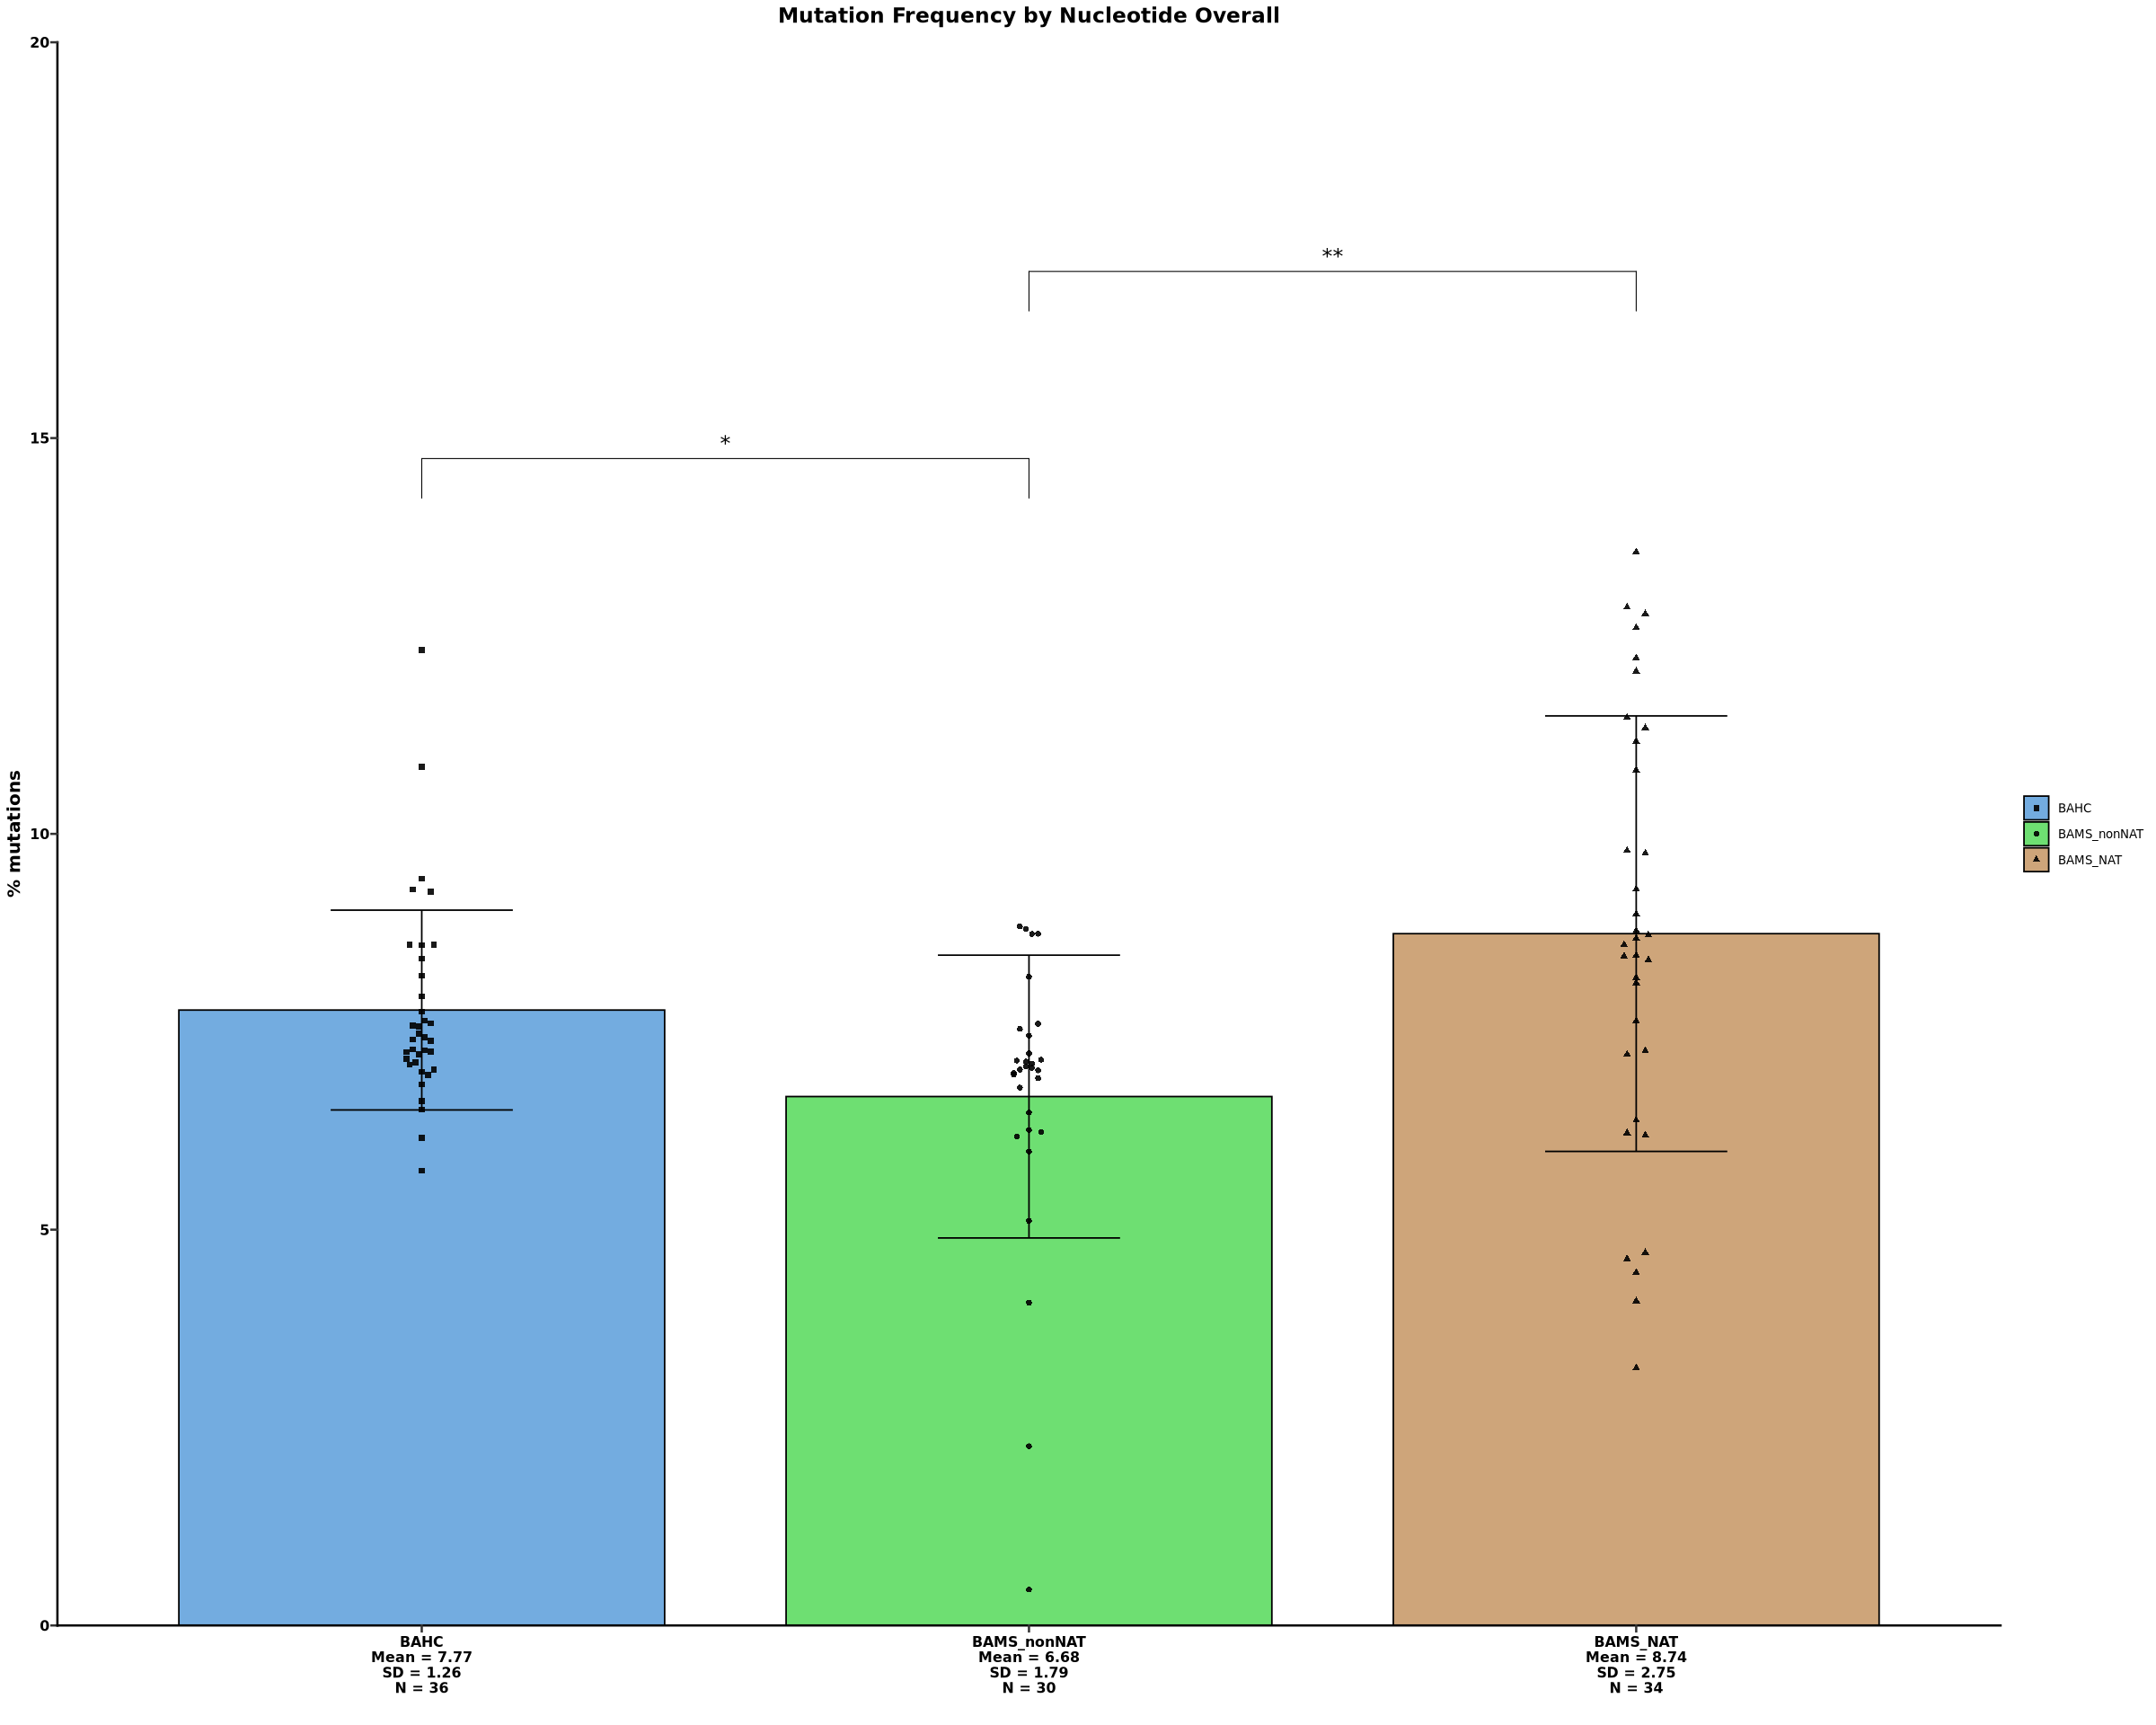

In [19]:
mut_freq_nt_plot_labels <- setNames(
  paste0(
    bar_mutations$group_ID,
    "\nMean = ", round(bar_mutations$mean_mut_freq_nt_all, 2),
    "\nSD = ", round(bar_mutations$sd_mut_freq_nt_all, 2),
    "\nN = ", bar_mutations$n_cohort
  ),
  bar_mutations$group_ID
)

mut_freq_nt_plot <- mut_analysis_summary %>%
  ggplot() +
  geom_col(
    data = bar_mutations,
    mapping = aes(x = group_ID, y = mean_mut_freq_nt_all, fill = group_ID), 
    width = 0.8,
    colour = "black", linewidth = 0.5) +
  geom_beeswarm(
    data = point_mutations,
    mapping = aes(x = group_ID, y = mut_freq_nt_all, shape = group_ID, group = group_ID), 
                  dodge.width = 0.05, 
                  method = "center",  
                  preserve.data.axis = TRUE,
                  priority = "density", 
                  corral = "wrap", 
                  corral.width = 0.05, 
                  alpha = 0.9
                  #size = 1.3, position = position_jitterdodge(jitter.width = 0.2)
                  ) +
  geom_errorbar(
   data = bar_mutations,
   mapping = aes(x = group_ID, y= mean_mut_freq_nt_all, 
                ymin = pmax(0, mean_mut_freq_nt_all - sd_mut_freq_nt_all), 
                ymax = mean_mut_freq_nt_all + sd_mut_freq_nt_all,
                group = group_ID),,
                width = 0.3,
              ) +
  stat_pvalue_manual(
    mut_freq_nt_all_ttest,
    size = 5, 
    p.format.style = "graphpad",
    hide.ns = TRUE) +
  theme_prism(
    palette = "black_and_white",
    base_size = 10,
    base_family = "sans") +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    axis.title.y = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    ) +
  scale_fill_manual(values = group_colors) +
  scale_shape_manual(values = group_shapes) +
  scale_y_continuous(expand = c(0, 0),
                      limits = c(0, 20)
                      ) +
  scale_x_discrete(labels = mut_freq_nt_plot_labels) +
  labs(title = "Mutation Frequency by Nucleotide Overall",
      x = " ", y = "% mutations")
    ggsave(filename = file.path(plots_output_dir, paste0("mut_freq_nt_all_", exp_group_A, "_vs_", exp_group_B, "_vs_", ctrl_group, ".png")),
       plot = mut_freq_nt_plot, width = 7, height = 6)
plot(mut_freq_nt_plot)

##### 2 replacement mutation frequency by nucleotide 

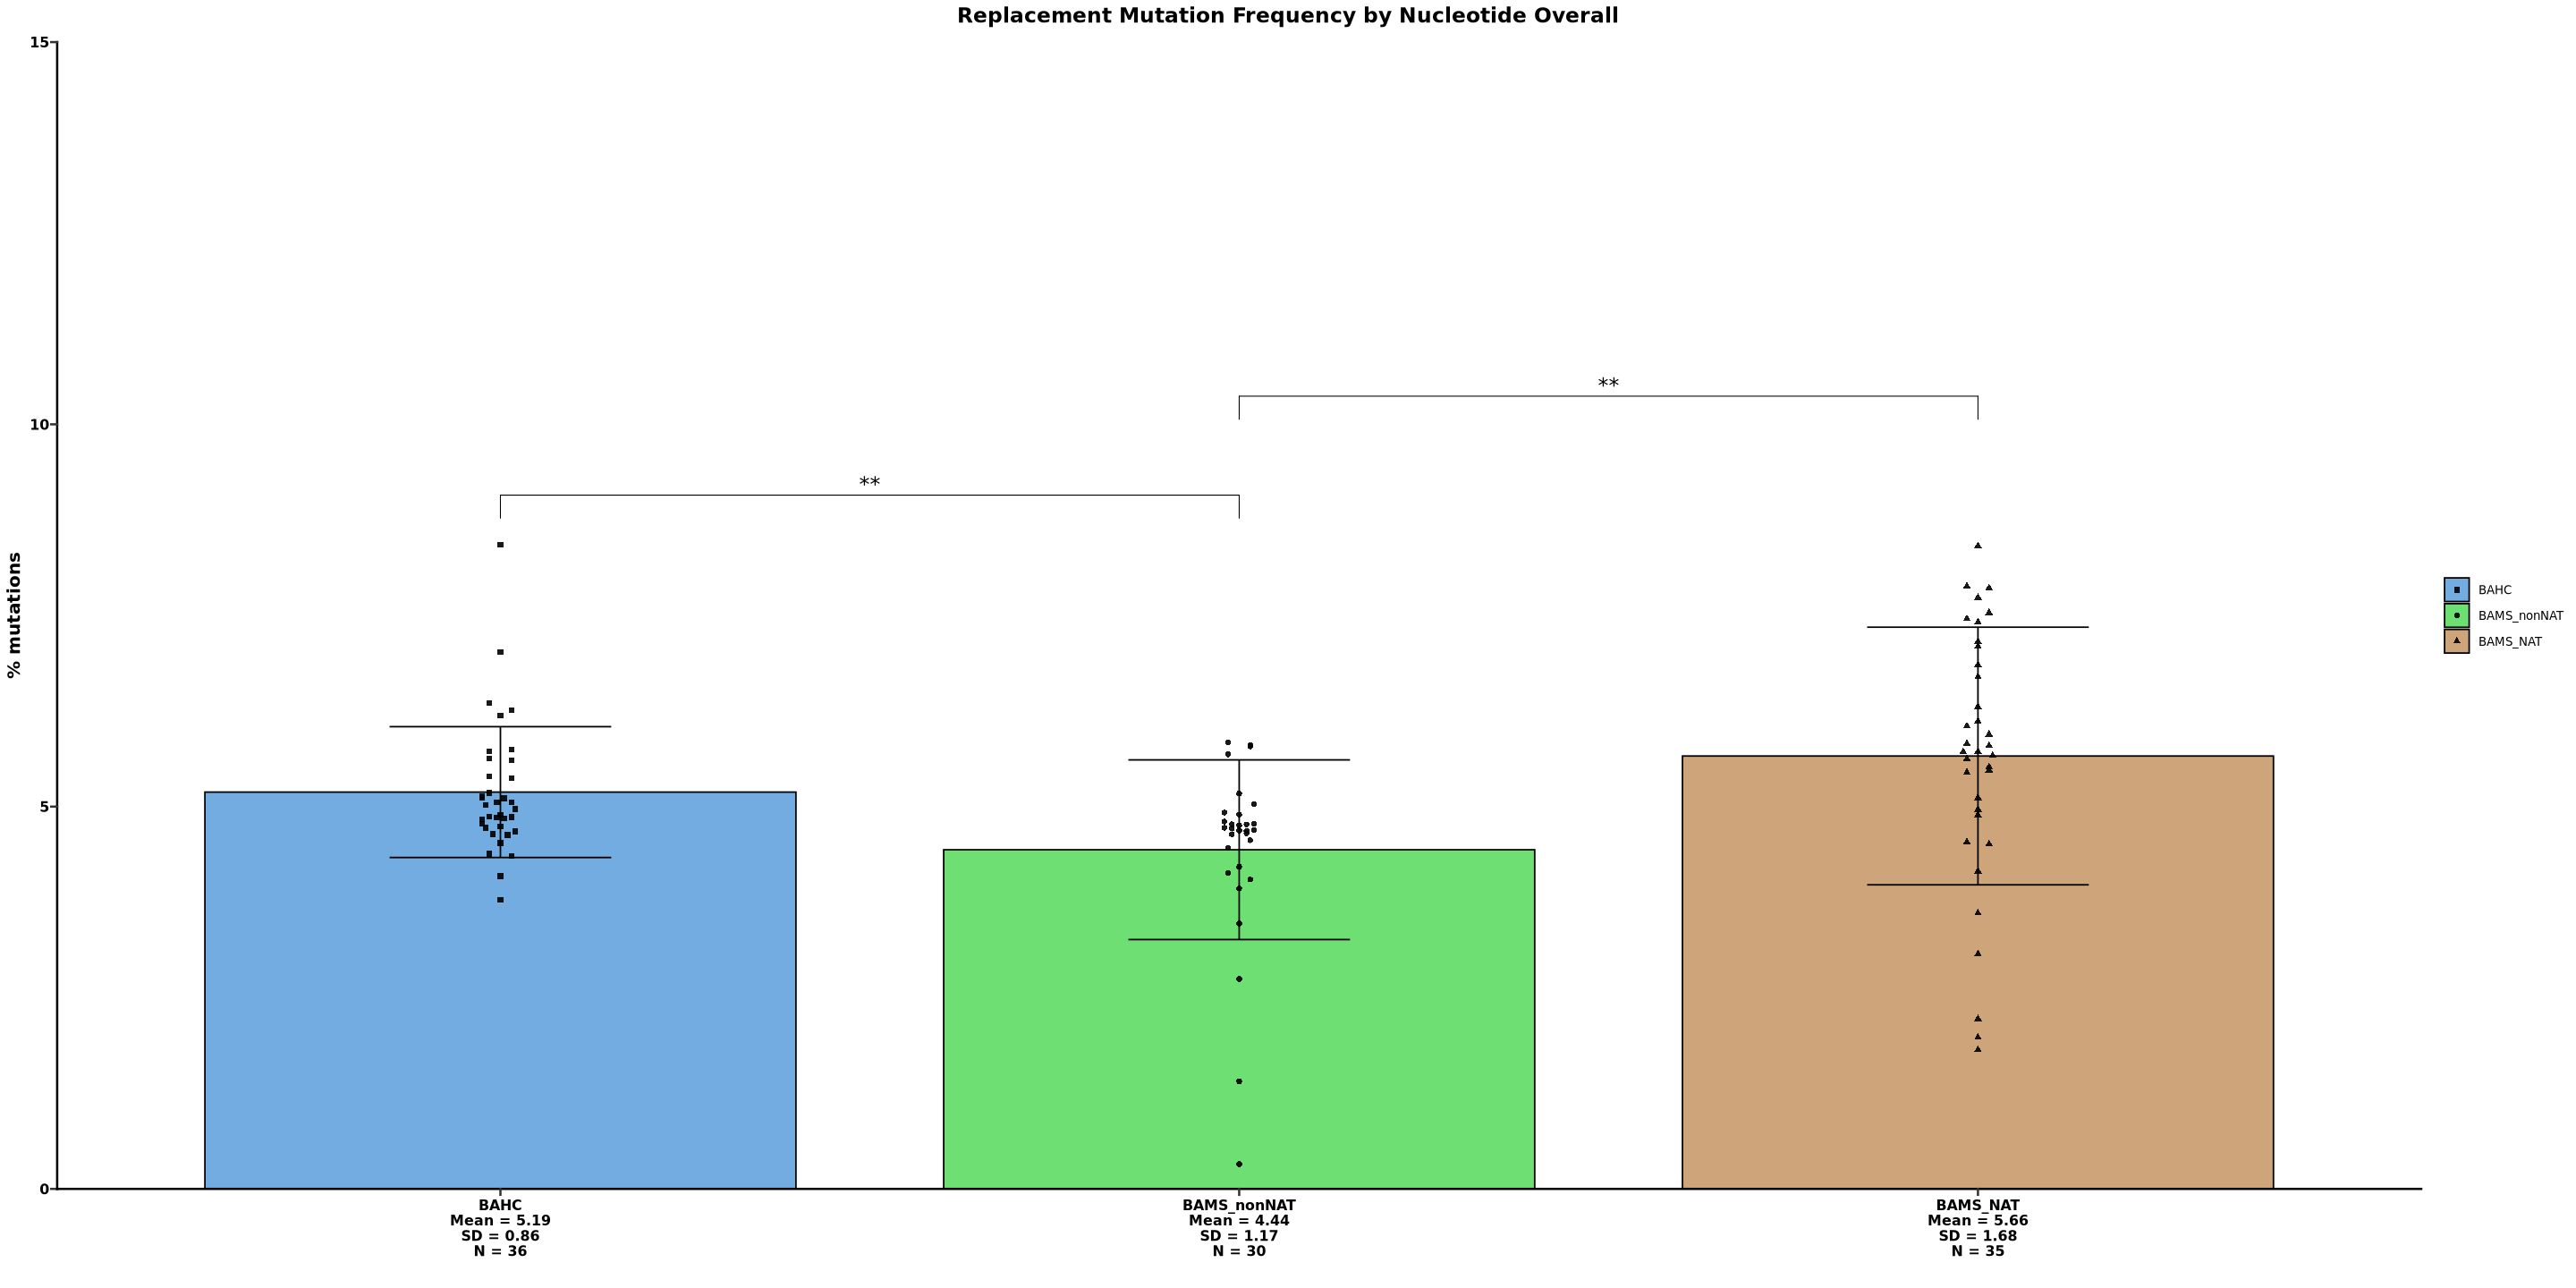

In [52]:
r_mut_freq_nt_all_plot_labels <- setNames(
  paste0(
    bar_mutations$group_ID,
    "\nMean = ", round(bar_mutations$mean_r_mut_freq_nt_all, 2),
    "\nSD = ", round(bar_mutations$sd_r_mut_freq_nt_all, 2),
    "\nN = ", bar_mutations$n_cohort
  ),
  bar_mutations$group_ID
)

r_mut_freq_nt_all_plot <- mut_analysis_summary %>%
  ggplot() +
  geom_col(
    data = bar_mutations,
    mapping = aes(x = group_ID, y = mean_r_mut_freq_nt_all, fill = group_ID), 
    width = 0.8,
    colour = "black", linewidth = 0.5) +
  geom_beeswarm(
    data = point_mutations,
    mapping = aes(x = group_ID, y = r_mut_freq_nt_all, shape = group_ID, group = group_ID), 
                  dodge.width = 0.05, 
                  method = "center",  
                  preserve.data.axis = TRUE,
                  priority = "density", 
                  corral = "wrap", 
                  corral.width = 0.05, 
                  alpha = 0.9
                  #size = 1.3, position = position_jitterdodge(jitter.width = 0.2)
                  ) +
  geom_errorbar(
   data = bar_mutations,
   mapping = aes(x = group_ID, y= mean_r_mut_freq_nt_all, 
                ymin = pmax(0, mean_r_mut_freq_nt_all - sd_r_mut_freq_nt_all), 
                ymax = mean_r_mut_freq_nt_all + sd_r_mut_freq_nt_all,
                group = group_ID),,
                width = 0.3,
              ) +
  stat_pvalue_manual(
    r_mut_freq_nt_all_ttest,
    size = 5, 
    p.format.style = "graphpad",
    hide.ns = TRUE) +
  theme_prism(
    palette = "black_and_white",
    base_size = 10,
    base_family = "sans") +
  theme(
    plot.title.position = "plot",
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
    axis.title.y = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    ) +
  scale_fill_manual(values = group_colors) +
  scale_shape_manual(values = group_shapes) +
  scale_y_continuous(expand = c(0, 0),
                      limits = c(0, 15)
                      ) +
  scale_x_discrete(labels = r_mut_freq_nt_all_plot_labels) +
  labs(title = "Replacement Mutation Frequency by Nucleotide Overall",
      x = " ", y = "% mutations")
    ggsave(filename = file.path(plots_output_dir, paste0("r_mut_freq_nt_all_", exp_group_A, "_vs_", exp_group_B, "_vs_", ctrl_group, ".png")),
       plot = r_mut_freq_nt_all_plot, width = 7, height = 6)
plot(r_mut_freq_nt_all_plot)

##### 3 mutation frequency by aa overall 

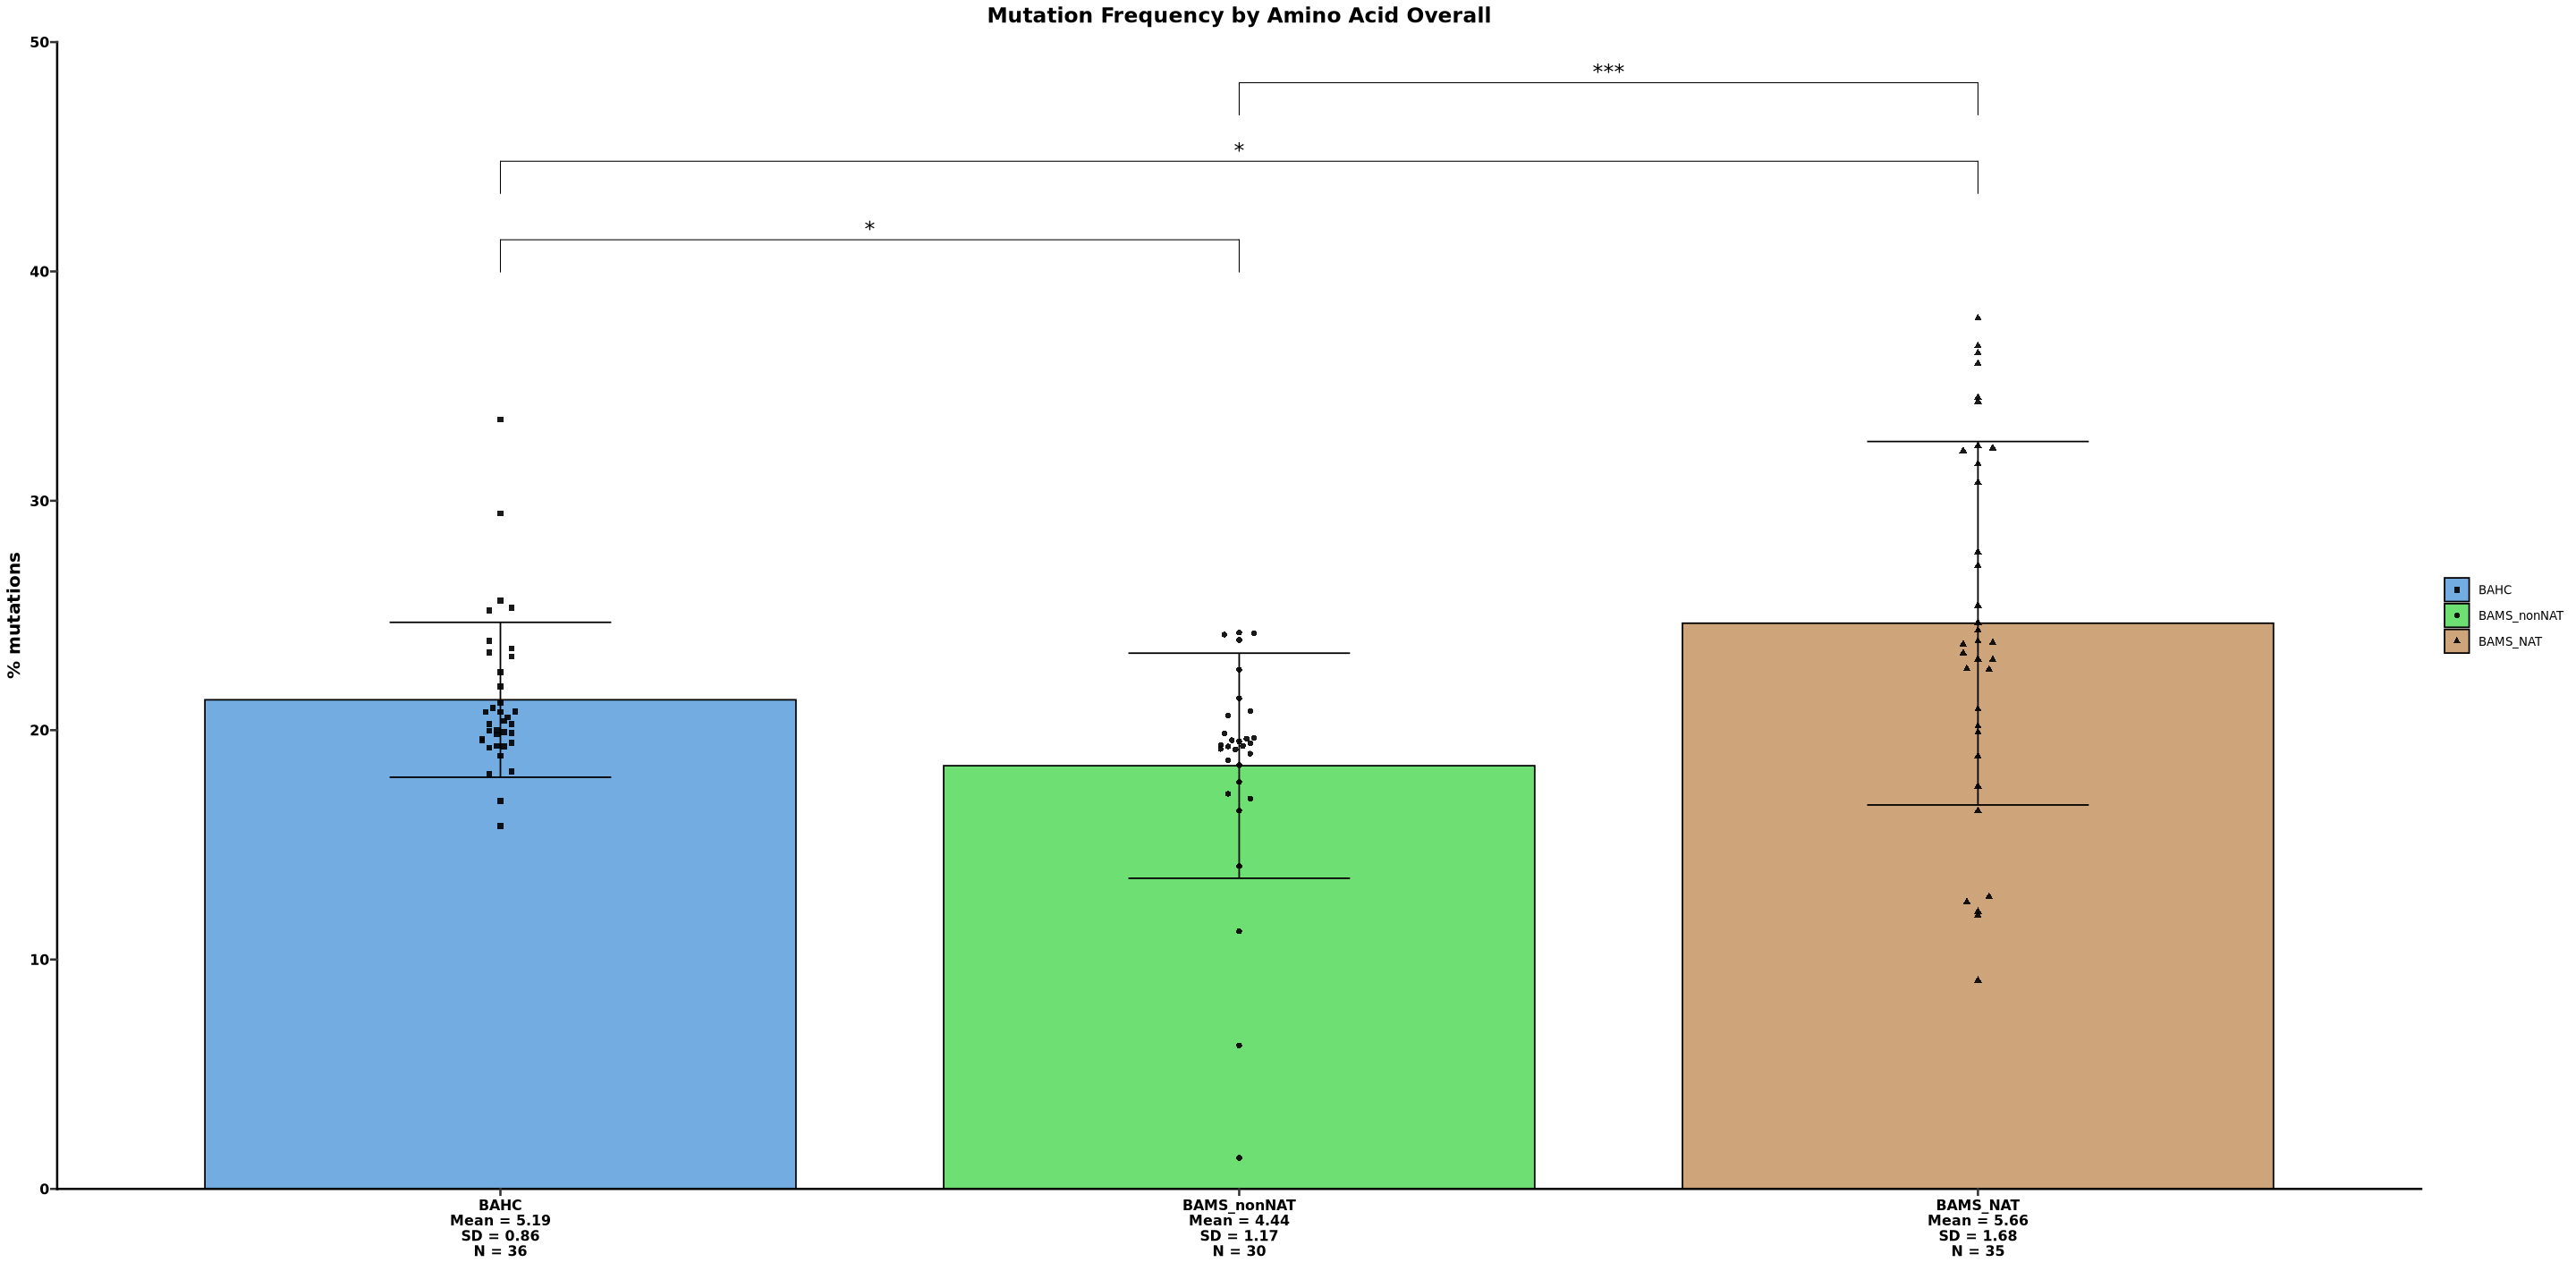

In [53]:
mut_freq_aa_all_plot_labels <- setNames(
  paste0(
    bar_mutations$group_ID,
    "\nMean = ", round(bar_mutations$mean_mut_freq_aa_all, 2),
    "\nSD = ", round(bar_mutations$sd_mut_freq_aa_all, 2),
    "\nN = ", bar_mutations$n_cohort
  ),
  bar_mutations$group_ID
)

mut_freq_aa_all_plot <- mut_analysis_summary %>%
  ggplot() +
  geom_col(
    data = bar_mutations,
    mapping = aes(x = group_ID, y = mean_mut_freq_aa_all, fill = group_ID), 
    width = 0.8,
    colour = "black", linewidth = 0.5) +
  geom_beeswarm(
    data = point_mutations,
    mapping = aes(x = group_ID, y = mut_freq_aa_all, shape = group_ID, group = group_ID), 
                  dodge.width = 0.05, 
                  method = "center",  
                  preserve.data.axis = TRUE,
                  priority = "density", 
                  corral = "wrap", 
                  corral.width = 0.05, 
                  alpha = 0.9
                  #size = 1.3, position = position_jitterdodge(jitter.width = 0.2)
                  ) +
  geom_errorbar(
   data = bar_mutations,
   mapping = aes(x = group_ID, y= mean_mut_freq_aa_all, 
                ymin = pmax(0, mean_mut_freq_aa_all - sd_mut_freq_aa_all), 
                ymax = mean_mut_freq_aa_all + sd_mut_freq_aa_all,
                group = group_ID),,
                width = 0.3,
              ) +
  stat_pvalue_manual(
    mut_freq_aa_all_ttest,
    size = 5, 
    p.format.style = "graphpad",
    hide.ns = TRUE) +
  theme_prism(
    palette = "black_and_white",
    base_size = 10,
    base_family = "sans") +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    axis.title.y = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    ) +
  scale_fill_manual(values = group_colors) +
  scale_shape_manual(values = group_shapes) +
  scale_y_continuous(expand = c(0, 0),
                      limits = c(0, 50)
                      ) +
  scale_x_discrete(labels = r_mut_freq_nt_all_plot_labels) +
  labs(title = "Mutation Frequency by Amino Acid Overall",
      x = " ", y = "% mutations")
    ggsave(filename = file.path(plots_output_dir, paste0("mut_freq_aa_all_", exp_group_A, "_vs_", exp_group_B, "_vs_", ctrl_group, ".png")),
       plot = mut_freq_aa_all_plot, width = 7, height = 6)
plot(mut_freq_aa_all_plot)

##### 4 mutation frequency in CDR by nucleotide 

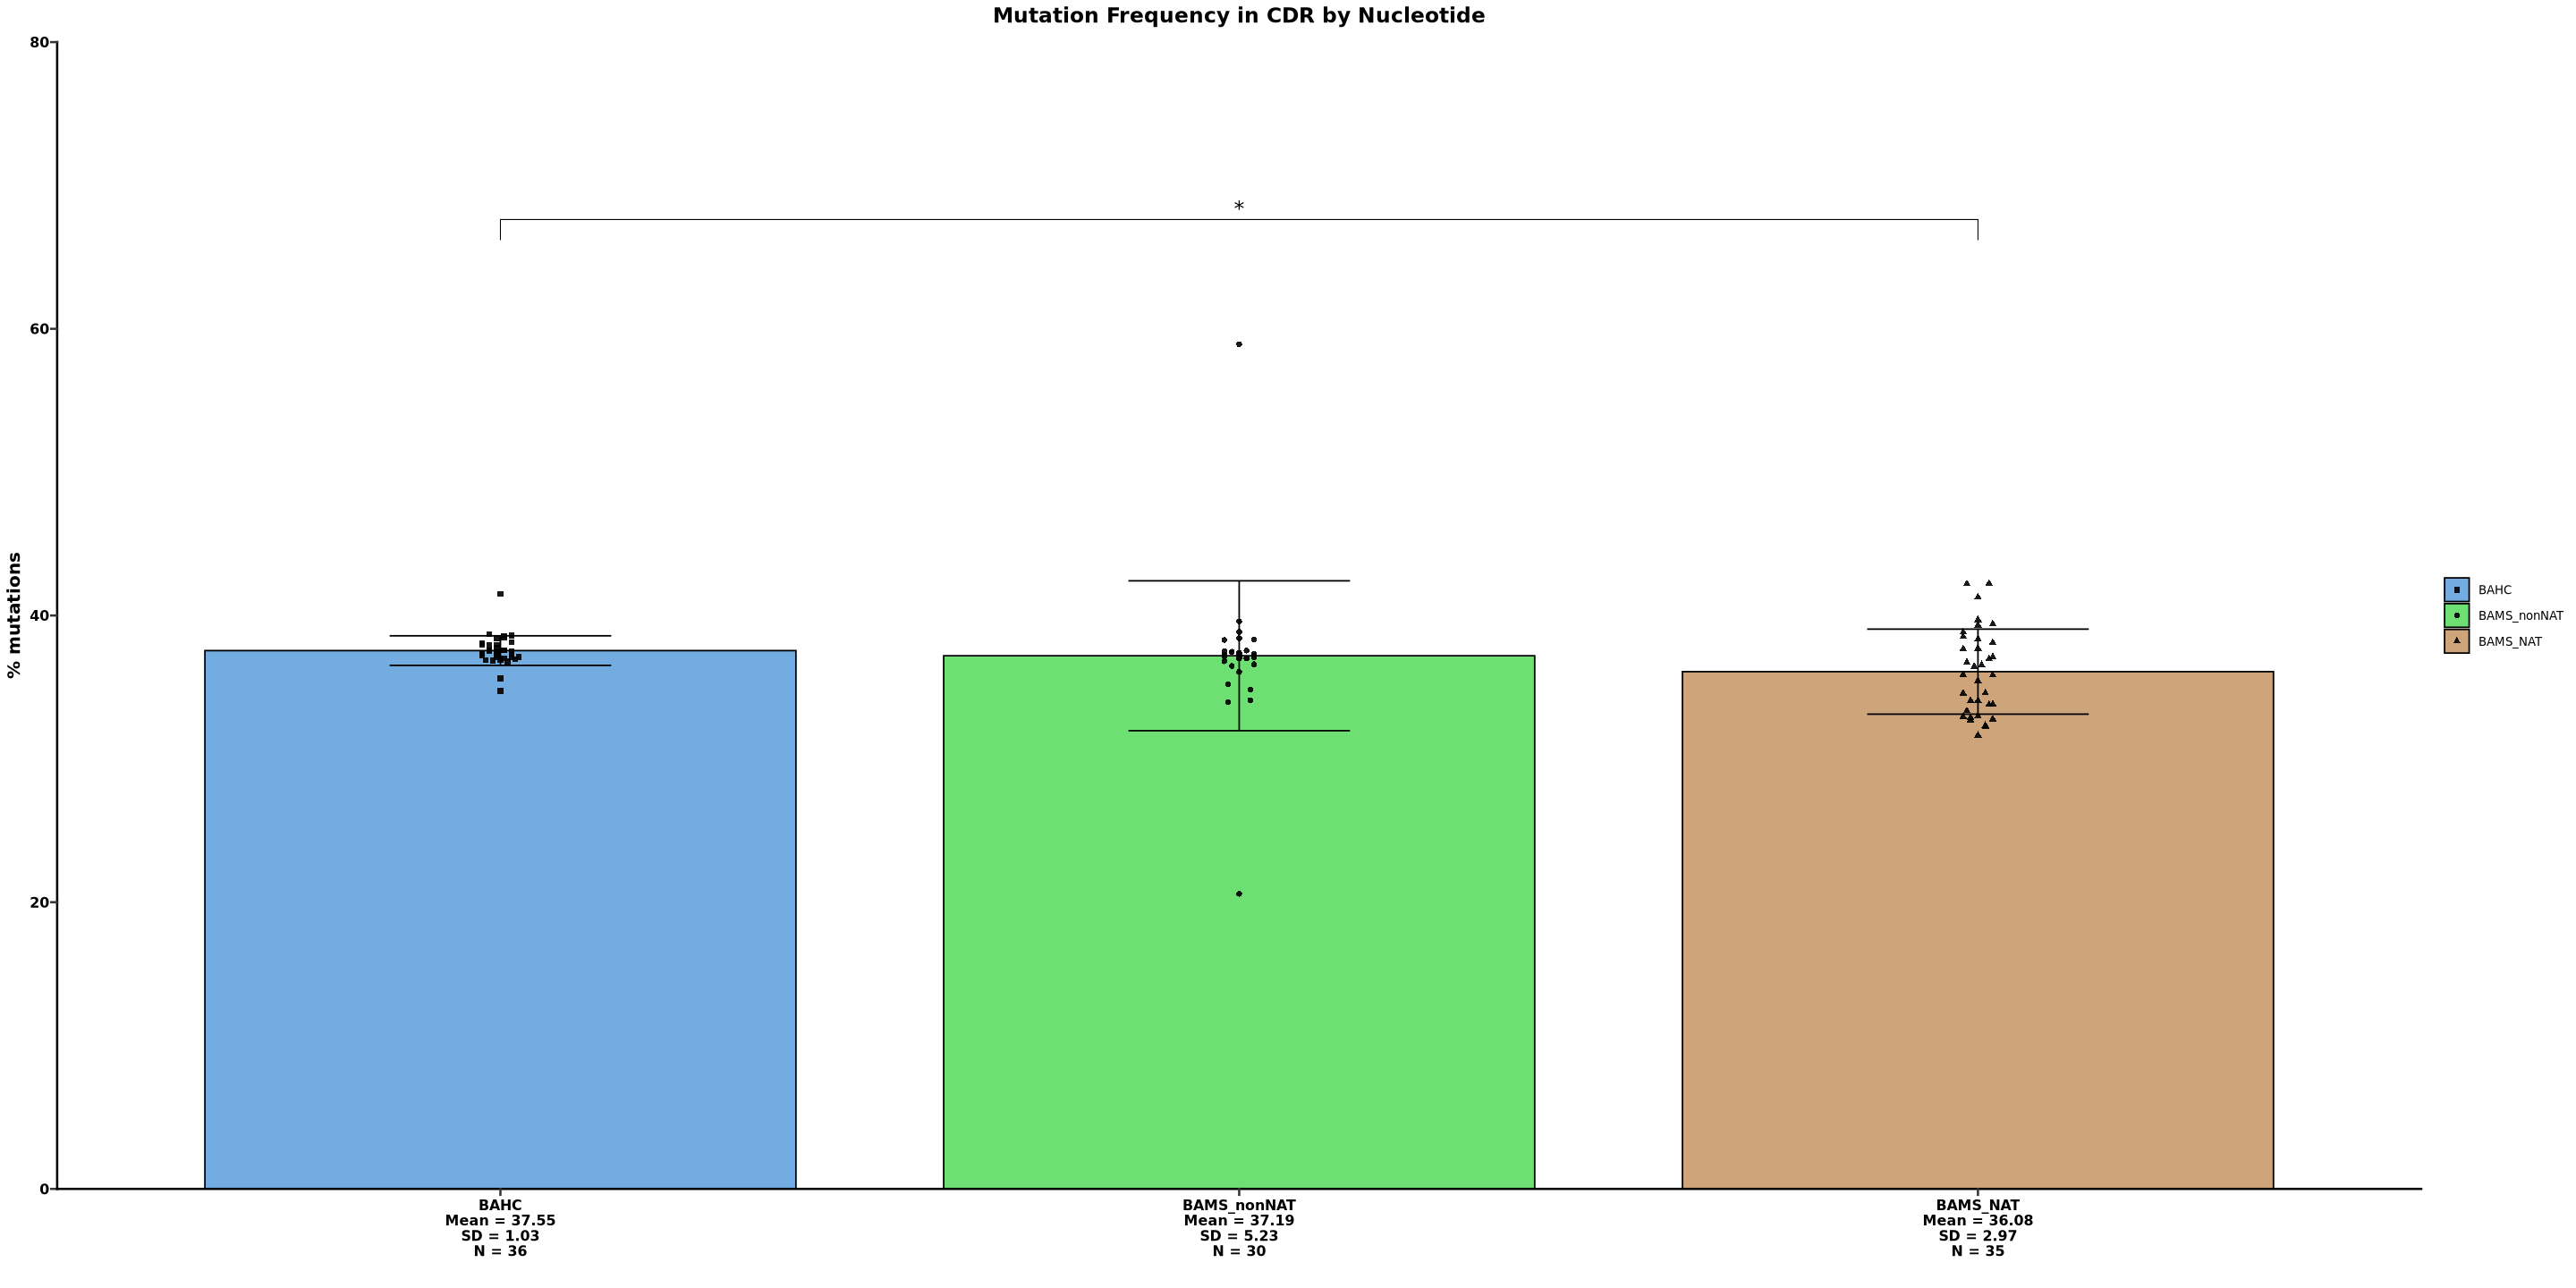

In [54]:
mut_freq_cdr_nt_plot_labels <- setNames(
  paste0(
    bar_mutations$group_ID,
    "\nMean = ", round(bar_mutations$mean_mut_freq_cdr_nt, 2),
    "\nSD = ", round(bar_mutations$sd_mut_freq_cdr_nt, 2),
    "\nN = ", bar_mutations$n_cohort
  ),
  bar_mutations$group_ID
)

mut_freq_cdr_nt_plot <- mut_analysis_summary %>%
  ggplot() +
  geom_col(
    data = bar_mutations,
    mapping = aes(x = group_ID, y = mean_mut_freq_cdr_nt, fill = group_ID), 
    width = 0.8,
    colour = "black", linewidth = 0.5) +
  geom_beeswarm(
    data = point_mutations,
    mapping = aes(x = group_ID, y = mut_freq_cdr_nt, shape = group_ID, group = group_ID), 
                  dodge.width = 0.05, 
                  method = "center",  
                  preserve.data.axis = TRUE,
                  priority = "density", 
                  corral = "wrap", 
                  corral.width = 0.05, 
                  alpha = 0.9
                  #size = 1.3, position = position_jitterdodge(jitter.width = 0.2)
                  ) +
  geom_errorbar(
   data = bar_mutations,
   mapping = aes(x = group_ID, y= mean_mut_freq_cdr_nt, 
                ymin = pmax(0, mean_mut_freq_cdr_nt - sd_mut_freq_cdr_nt), 
                ymax = mean_mut_freq_cdr_nt + sd_mut_freq_cdr_nt,
                group = group_ID),,
                width = 0.3,
              ) +
  stat_pvalue_manual(
    mut_freq_cdr_nt_ttest,
    size = 5, 
    p.format.style = "graphpad",
    hide.ns = TRUE) +
  theme_prism(
    palette = "black_and_white",
    base_size = 10,
    base_family = "sans") +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    axis.title.y = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    ) +
  scale_fill_manual(values = group_colors) +
  scale_shape_manual(values = group_shapes) +
  scale_y_continuous(expand = c(0, 0),
                      limits = c(0, 80)
                      ) +
  scale_x_discrete(labels = mut_freq_cdr_nt_plot_labels) +
  labs(title = "Mutation Frequency in CDR by Nucleotide",
      x = " ", y = "% mutations")
    ggsave(filename = file.path(plots_output_dir, paste0("mut_freq_cdr_nt_", exp_group_A, "_vs_", exp_group_B, "_vs_", ctrl_group, ".png")),
       plot = mut_freq_cdr_nt_plot, width = 7, height = 6)
plot(mut_freq_cdr_nt_plot)

##### 4.2 mutation frequency in FWR by nucleotide 

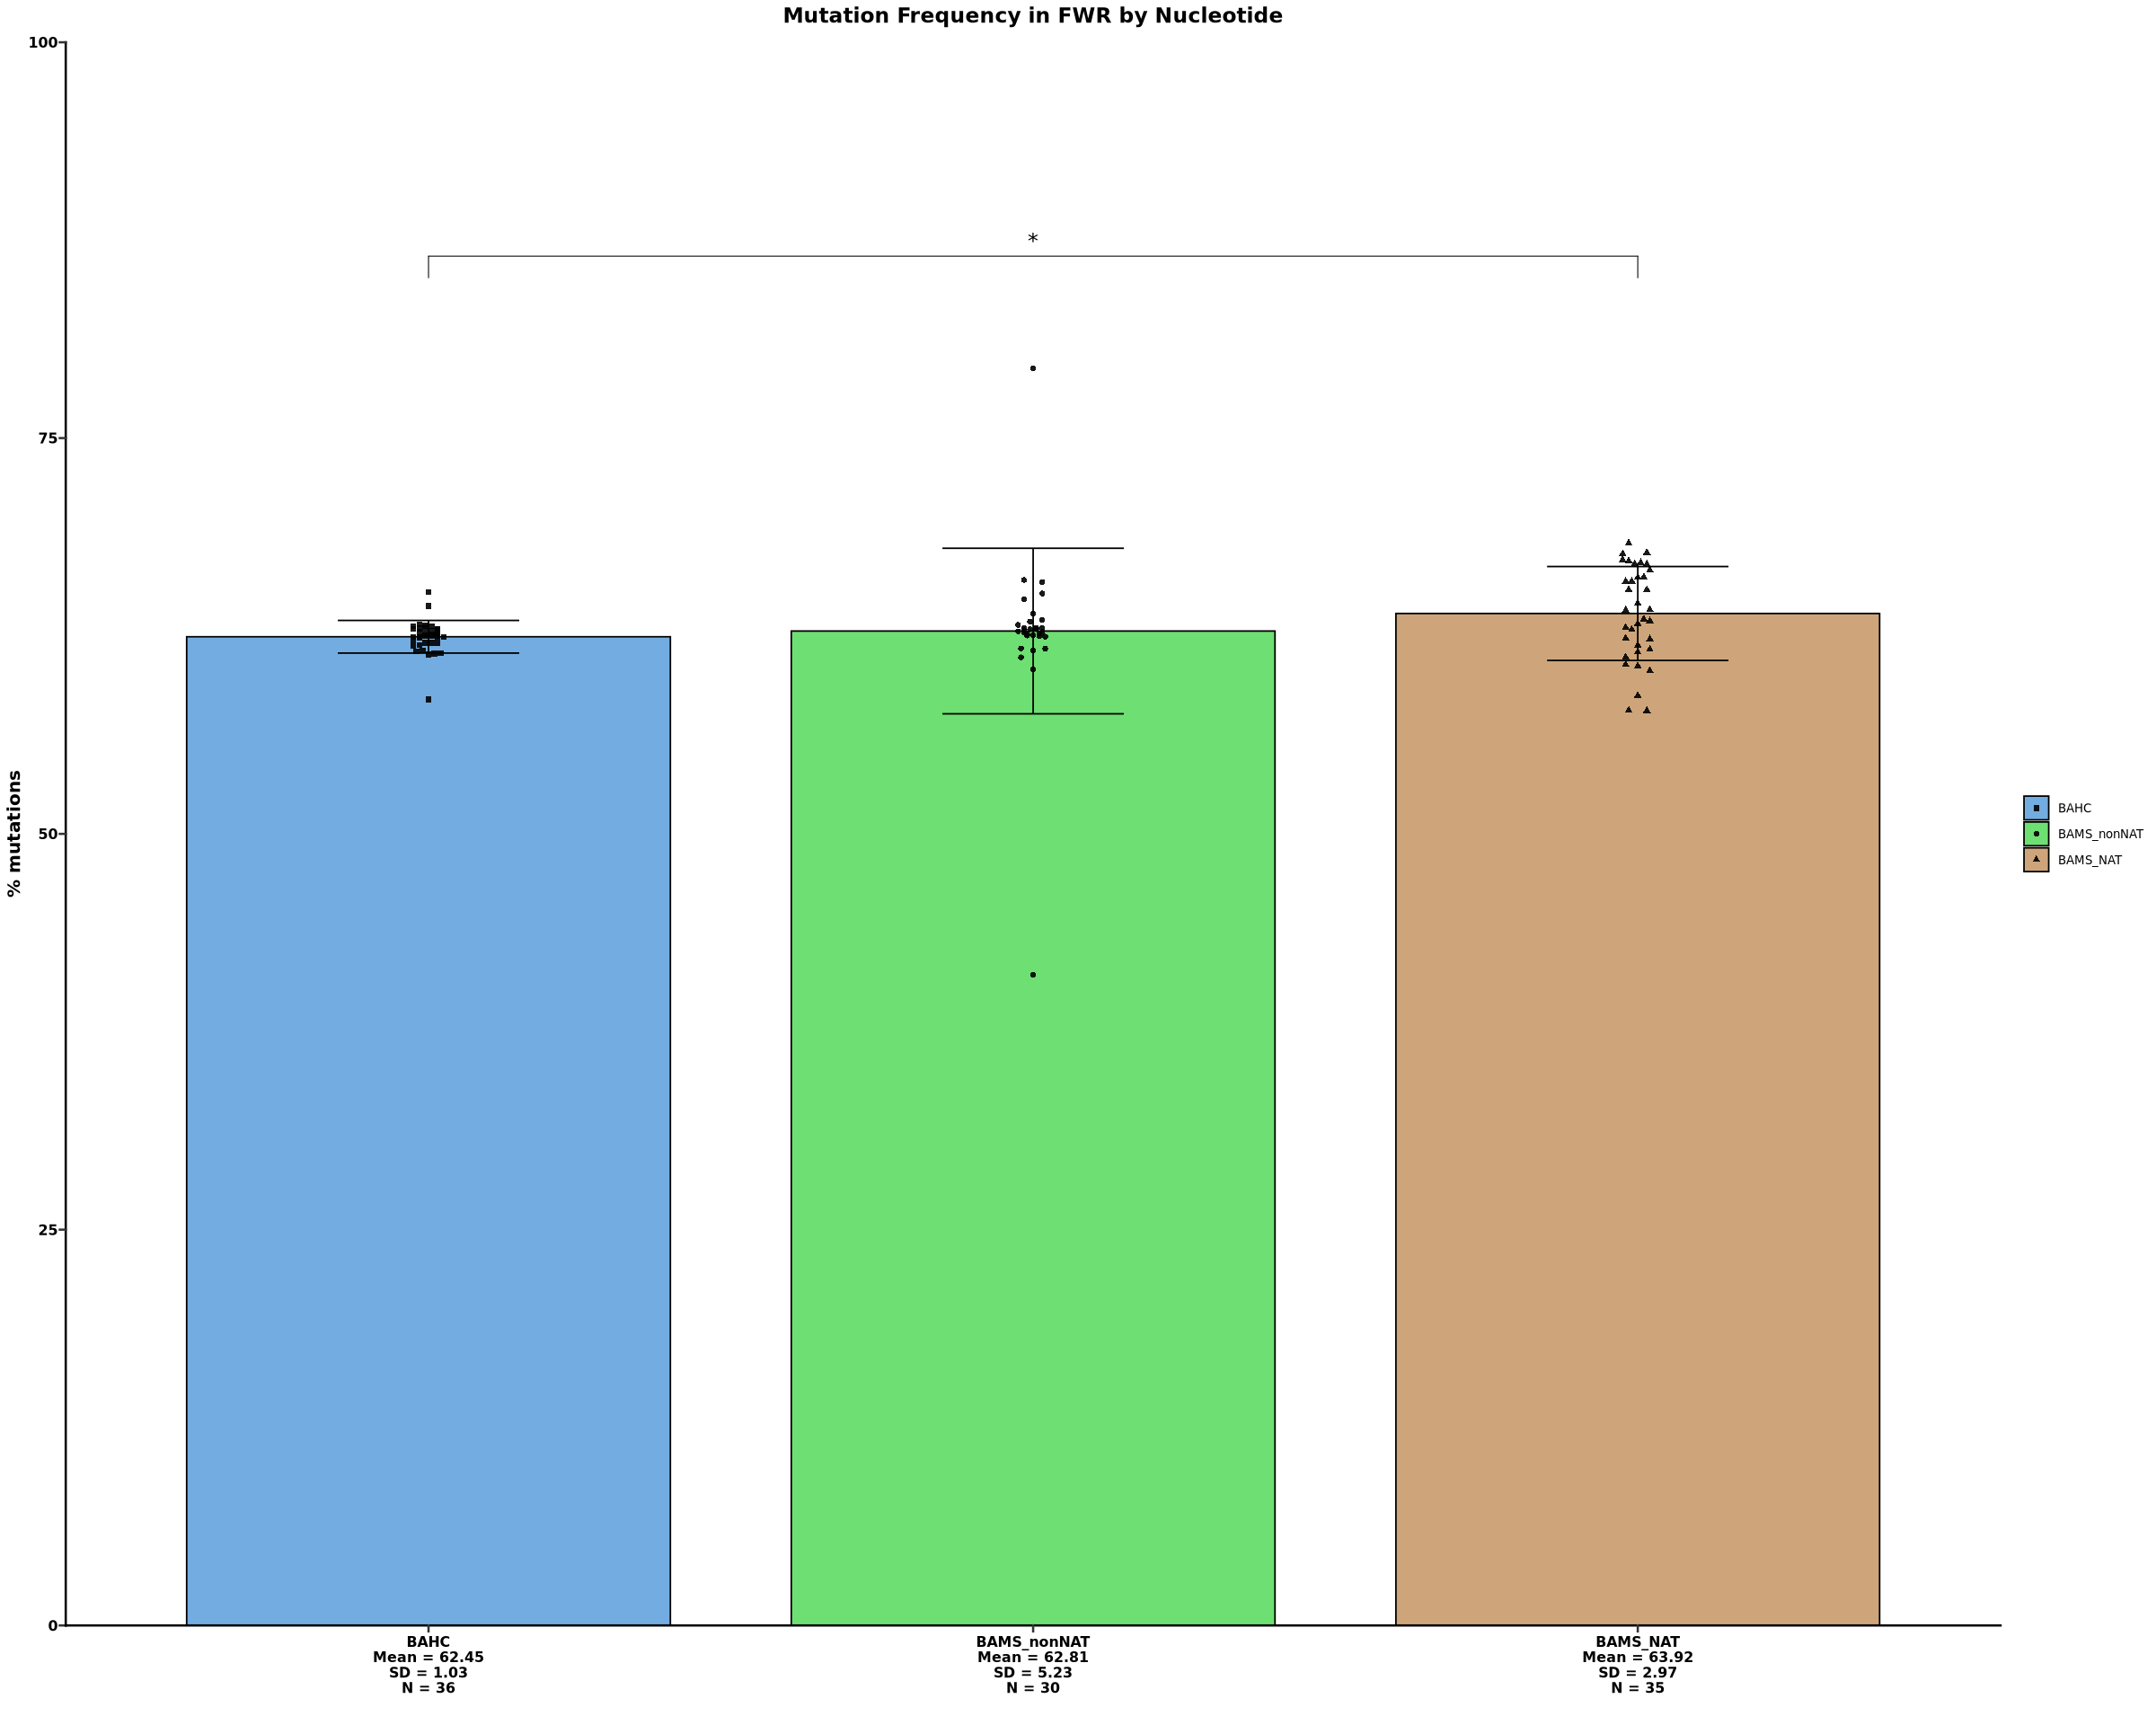

In [79]:
mut_freq_fwr_nt_plot_labels <- setNames(
  paste0(
    bar_mutations$group_ID,
    "\nMean = ", round(bar_mutations$mean_mut_freq_fwr_nt, 2),
    "\nSD = ", round(bar_mutations$sd_mut_freq_fwr_nt, 2),
    "\nN = ", bar_mutations$n_cohort
  ),
  bar_mutations$group_ID
)

mut_freq_fwr_nt_plot <- mut_analysis_summary %>%
  ggplot() +
  geom_col(
    data = bar_mutations,
    mapping = aes(x = group_ID, y = mean_mut_freq_fwr_nt, fill = group_ID), 
    width = 0.8,
    colour = "black", linewidth = 0.5) +
  geom_beeswarm(
    data = point_mutations,
    mapping = aes(x = group_ID, y = mut_freq_fwr_nt, shape = group_ID, group = group_ID), 
                  dodge.width = 0.05, 
                  method = "center",  
                  preserve.data.axis = TRUE,
                  priority = "density", 
                  corral = "wrap", 
                  corral.width = 0.05, 
                  alpha = 0.9
                  #size = 1.3, position = position_jitterdodge(jitter.width = 0.2)
                  ) +
  geom_errorbar(
   data = bar_mutations,
   mapping = aes(x = group_ID, y= mean_mut_freq_fwr_nt, 
                ymin = pmax(0, mean_mut_freq_fwr_nt - sd_mut_freq_fwr_nt), 
                ymax = mean_mut_freq_fwr_nt + sd_mut_freq_fwr_nt,
                group = group_ID),,
                width = 0.3,
              ) +
  stat_pvalue_manual(
    mut_freq_fwr_nt_ttest,
    size = 5, 
    p.format.style = "graphpad",
    hide.ns = TRUE) +
  theme_prism(
    palette = "black_and_white",
    base_size = 10,
    base_family = "sans") +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    axis.title.y = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    ) +
  scale_fill_manual(values = group_colors) +
  scale_shape_manual(values = group_shapes) +
  scale_y_continuous(expand = c(0, 0),
                      limits = c(0, 100)
                      ) +
  scale_x_discrete(labels = mut_freq_fwr_nt_plot_labels) +
  labs(title = "Mutation Frequency in FWR by Nucleotide",
      x = " ", y = "% mutations")
    ggsave(filename = file.path(plots_output_dir, paste0("mut_freq_fwr_nt_", exp_group_A, "_vs_", exp_group_B, "_vs_", ctrl_group, ".png")),
       plot = mut_freq_fwr_nt_plot, width = 7, height = 6)
plot(mut_freq_fwr_nt_plot)

##### 5 replacement frequency in CDR 

In [ ]:
r_mut_freq_cdr_plot_overall_labels <- setNames(
  paste0(
    bar_mutations_overall$group_ID,
    "\nMean = ", round(bar_mutations_overall$mean_r_mut_freq_cdr, 2),
    "\nSD = ", round(bar_mutations_overall$sd_r_mut_freq_cdr, 2),
    "\nN = ", bar_mutations_overall$n_cohort
  ),
  bar_mutations_overall$group_ID
)

r_mut_freq_cdr_plot <- mut_analysis_summary %>%
  ggplot() +
  geom_col(
    data = bar_mutations_overall,
    mapping = aes(x = group_ID, y = mean_r_mut_freq_cdr, fill = group_ID), 
    width = 0.8,
    colour = "black", linewidth = 0.5) +
  geom_beeswarm(
    data = point_mutations_overall,
    mapping = aes(x = group_ID, y = r_mut_freq_cdr, shape = group_ID, group = group_ID), 
                  dodge.width = 0.05, 
                  method = "center",  
                  preserve.data.axis = TRUE,
                  priority = "density", 
                  corral = "wrap", 
                  corral.width = 0.05, 
                  alpha = 0.9
                  #size = 1.3, position = position_jitterdodge(jitter.width = 0.2)
                  ) +
  geom_errorbar(
   data = bar_mutations_overall,
   mapping = aes(x = group_ID, y= mean_r_mut_freq_cdr, 
                ymin = pmax(0, mean_r_mut_freq_cdr - sd_r_mut_freq_cdr), 
                ymax = mean_r_mut_freq_cdr + sd_r_mut_freq_cdr,
                group = group_ID),,
                width = 0.3,
              ) +
  stat_pvalue_manual(
    r_mut_freq_cdr_ttest,
    size = 5, 
    p.format.style = "graphpad",
    hide.ns = TRUE) +
  theme_prism(
    palette = "black_and_white",
    base_size = 10,
    base_family = "sans") +
  theme(
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
    axis.title.y = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    ) +
  scale_fill_manual(values = group_colors) +
  scale_shape_manual(values = group_shapes) +
  scale_y_continuous(expand = c(0, 0),
                      limits = c(0, 80)
                      ) +
  scale_x_discrete(labels = r_mut_freq_cdr_plot_overall_labels) +
  labs(title = "Replacement Mutation Frequency in CDR by Nucleotide",
      x = " ", y = "% mutations")
    ggsave(filename = file.path(plots_output_dir, paste0("r_mut_freq_cdr_", exp_group_A, "_vs_", exp_group_B, "_vs_", ctrl_group, ".png")),
       plot = r_mut_freq_cdr_plot, width = 7, height = 6)
plot(r_mut_freq_cdr_plot)

###### VH4

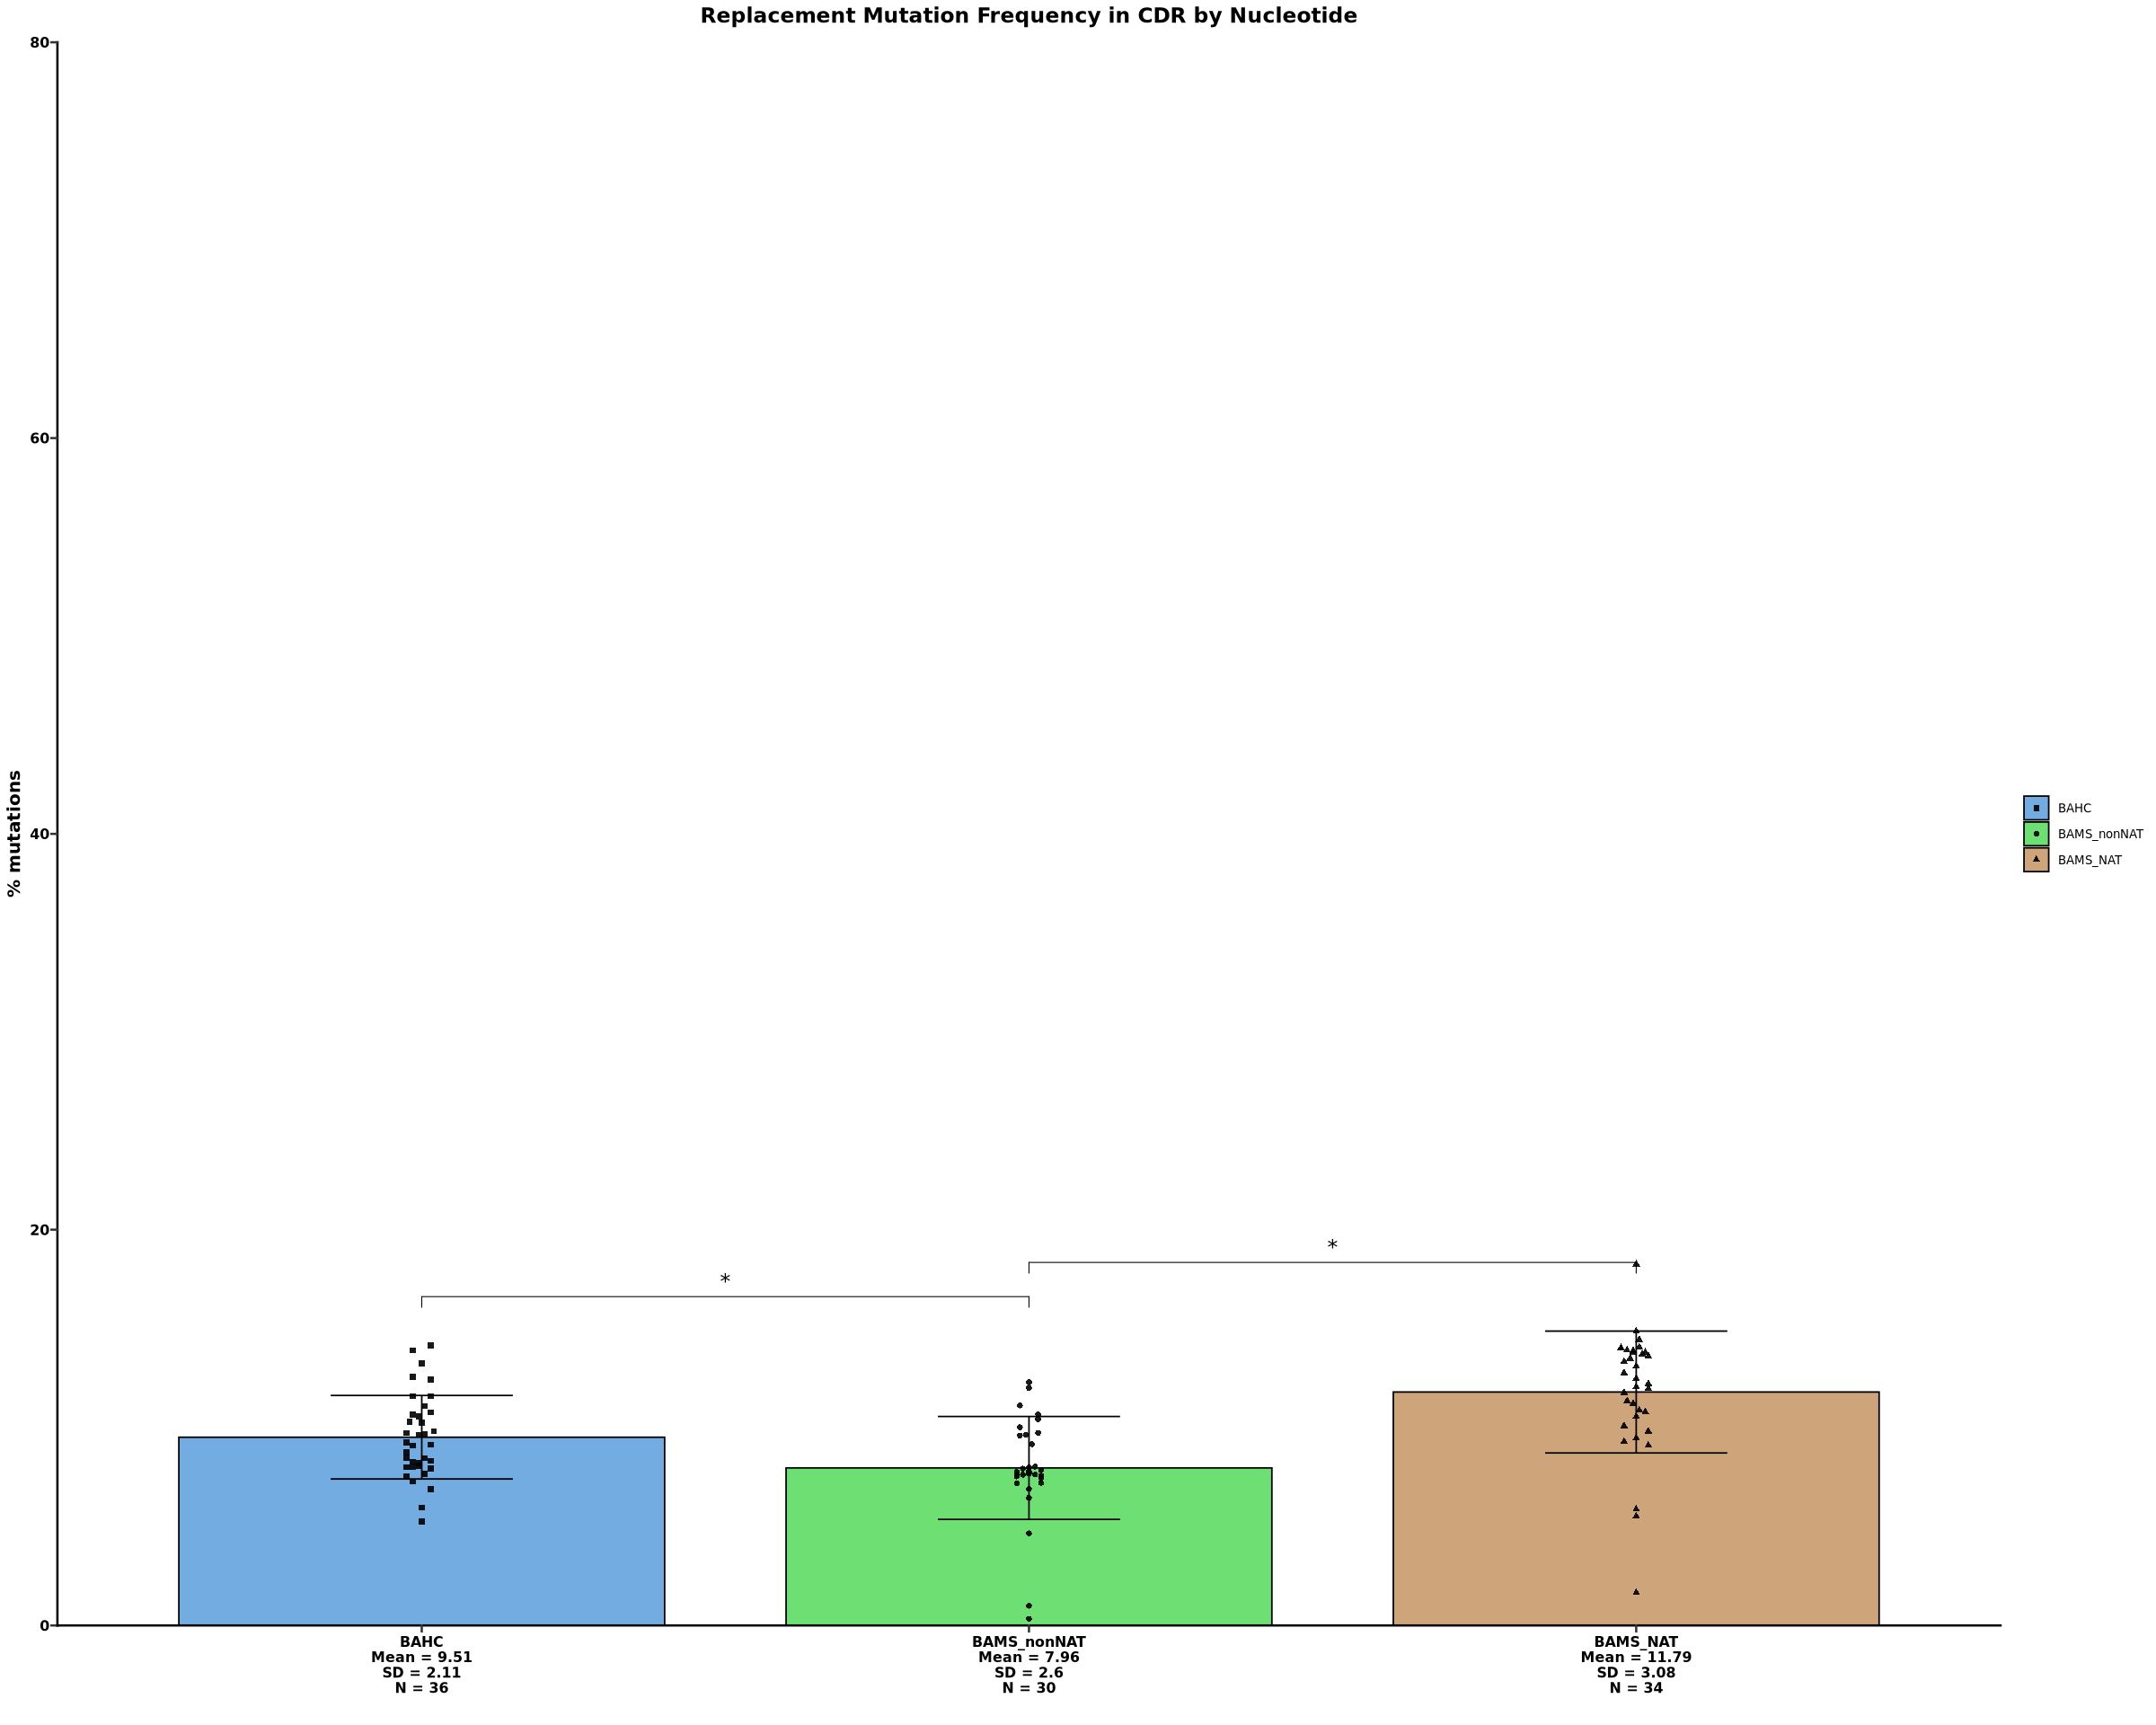

In [ ]:
r_mut_freq_cdr_plot_VH4_labels <- setNames(
  paste0(
    bar_mutations_VH4_fam$group_ID,
    "\nMean = ", round(bar_mutations_VH4_fam$mean_r_mut_freq_cdr, 2),
    "\nSD = ", round(bar_mutations_VH4_fam$sd_r_mut_freq_cdr, 2),
    "\nN = ", bar_mutations_VH4_fam$n_cohort
  ),
  bar_mutations_VH4_fam$group_ID
)

r_mut_freq_cdr_plot <- mut_analysis_summary %>%
  ggplot() +
  geom_col(
    data = bar_mutations_VH4_fam,
    mapping = aes(x = group_ID, y = mean_r_mut_freq_cdr, fill = group_ID), 
    width = 0.8,
    colour = "black", linewidth = 0.5) +
  geom_beeswarm(
    data = point_mutations_VH4_fam,
    mapping = aes(x = group_ID, y = r_mut_freq_cdr, shape = group_ID, group = group_ID), 
                  dodge.width = 0.05, 
                  method = "center",  
                  preserve.data.axis = TRUE,
                  priority = "density", 
                  corral = "wrap", 
                  corral.width = 0.05, 
                  alpha = 0.9
                  #size = 1.3, position = position_jitterdodge(jitter.width = 0.2)
                  ) +
  geom_errorbar(
   data = bar_mutations_VH4_fam,
   mapping = aes(x = group_ID, y= mean_r_mut_freq_cdr, 
                ymin = pmax(0, mean_r_mut_freq_cdr - sd_r_mut_freq_cdr), 
                ymax = mean_r_mut_freq_cdr + sd_r_mut_freq_cdr,
                group = group_ID),,
                width = 0.3,
              ) +
  stat_pvalue_manual(
    r_mut_freq_cdr_ttest,
    size = 5, 
    p.format.style = "graphpad",
    hide.ns = TRUE) +
  theme_prism(
    palette = "black_and_white",
    base_size = 10,
    base_family = "sans") +
  theme(
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
    axis.title.y = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    ) +
  scale_fill_manual(values = group_colors) +
  scale_shape_manual(values = group_shapes) +
  scale_y_continuous(expand = c(0, 0),
                      limits = c(0, 80)
                      ) +
  scale_x_discrete(labels = r_mut_freq_cdr_plot_labels) +
  labs(title = "Replacement Frequency in CDR",
      x = " ", y = "replacement frequency")
    ggsave(filename = file.path(plots_output_dir, paste0("r_mut_freq_cdr_", exp_group_A, "_vs_", exp_group_B, "_vs_", ctrl_group, ".png")),
       plot = r_mut_freq_cdr_plot_VH4_labels, width = 7, height = 6)
plot(r_mut_freq_cdr_plot_VH4_labels)

###### VH4+JH6+

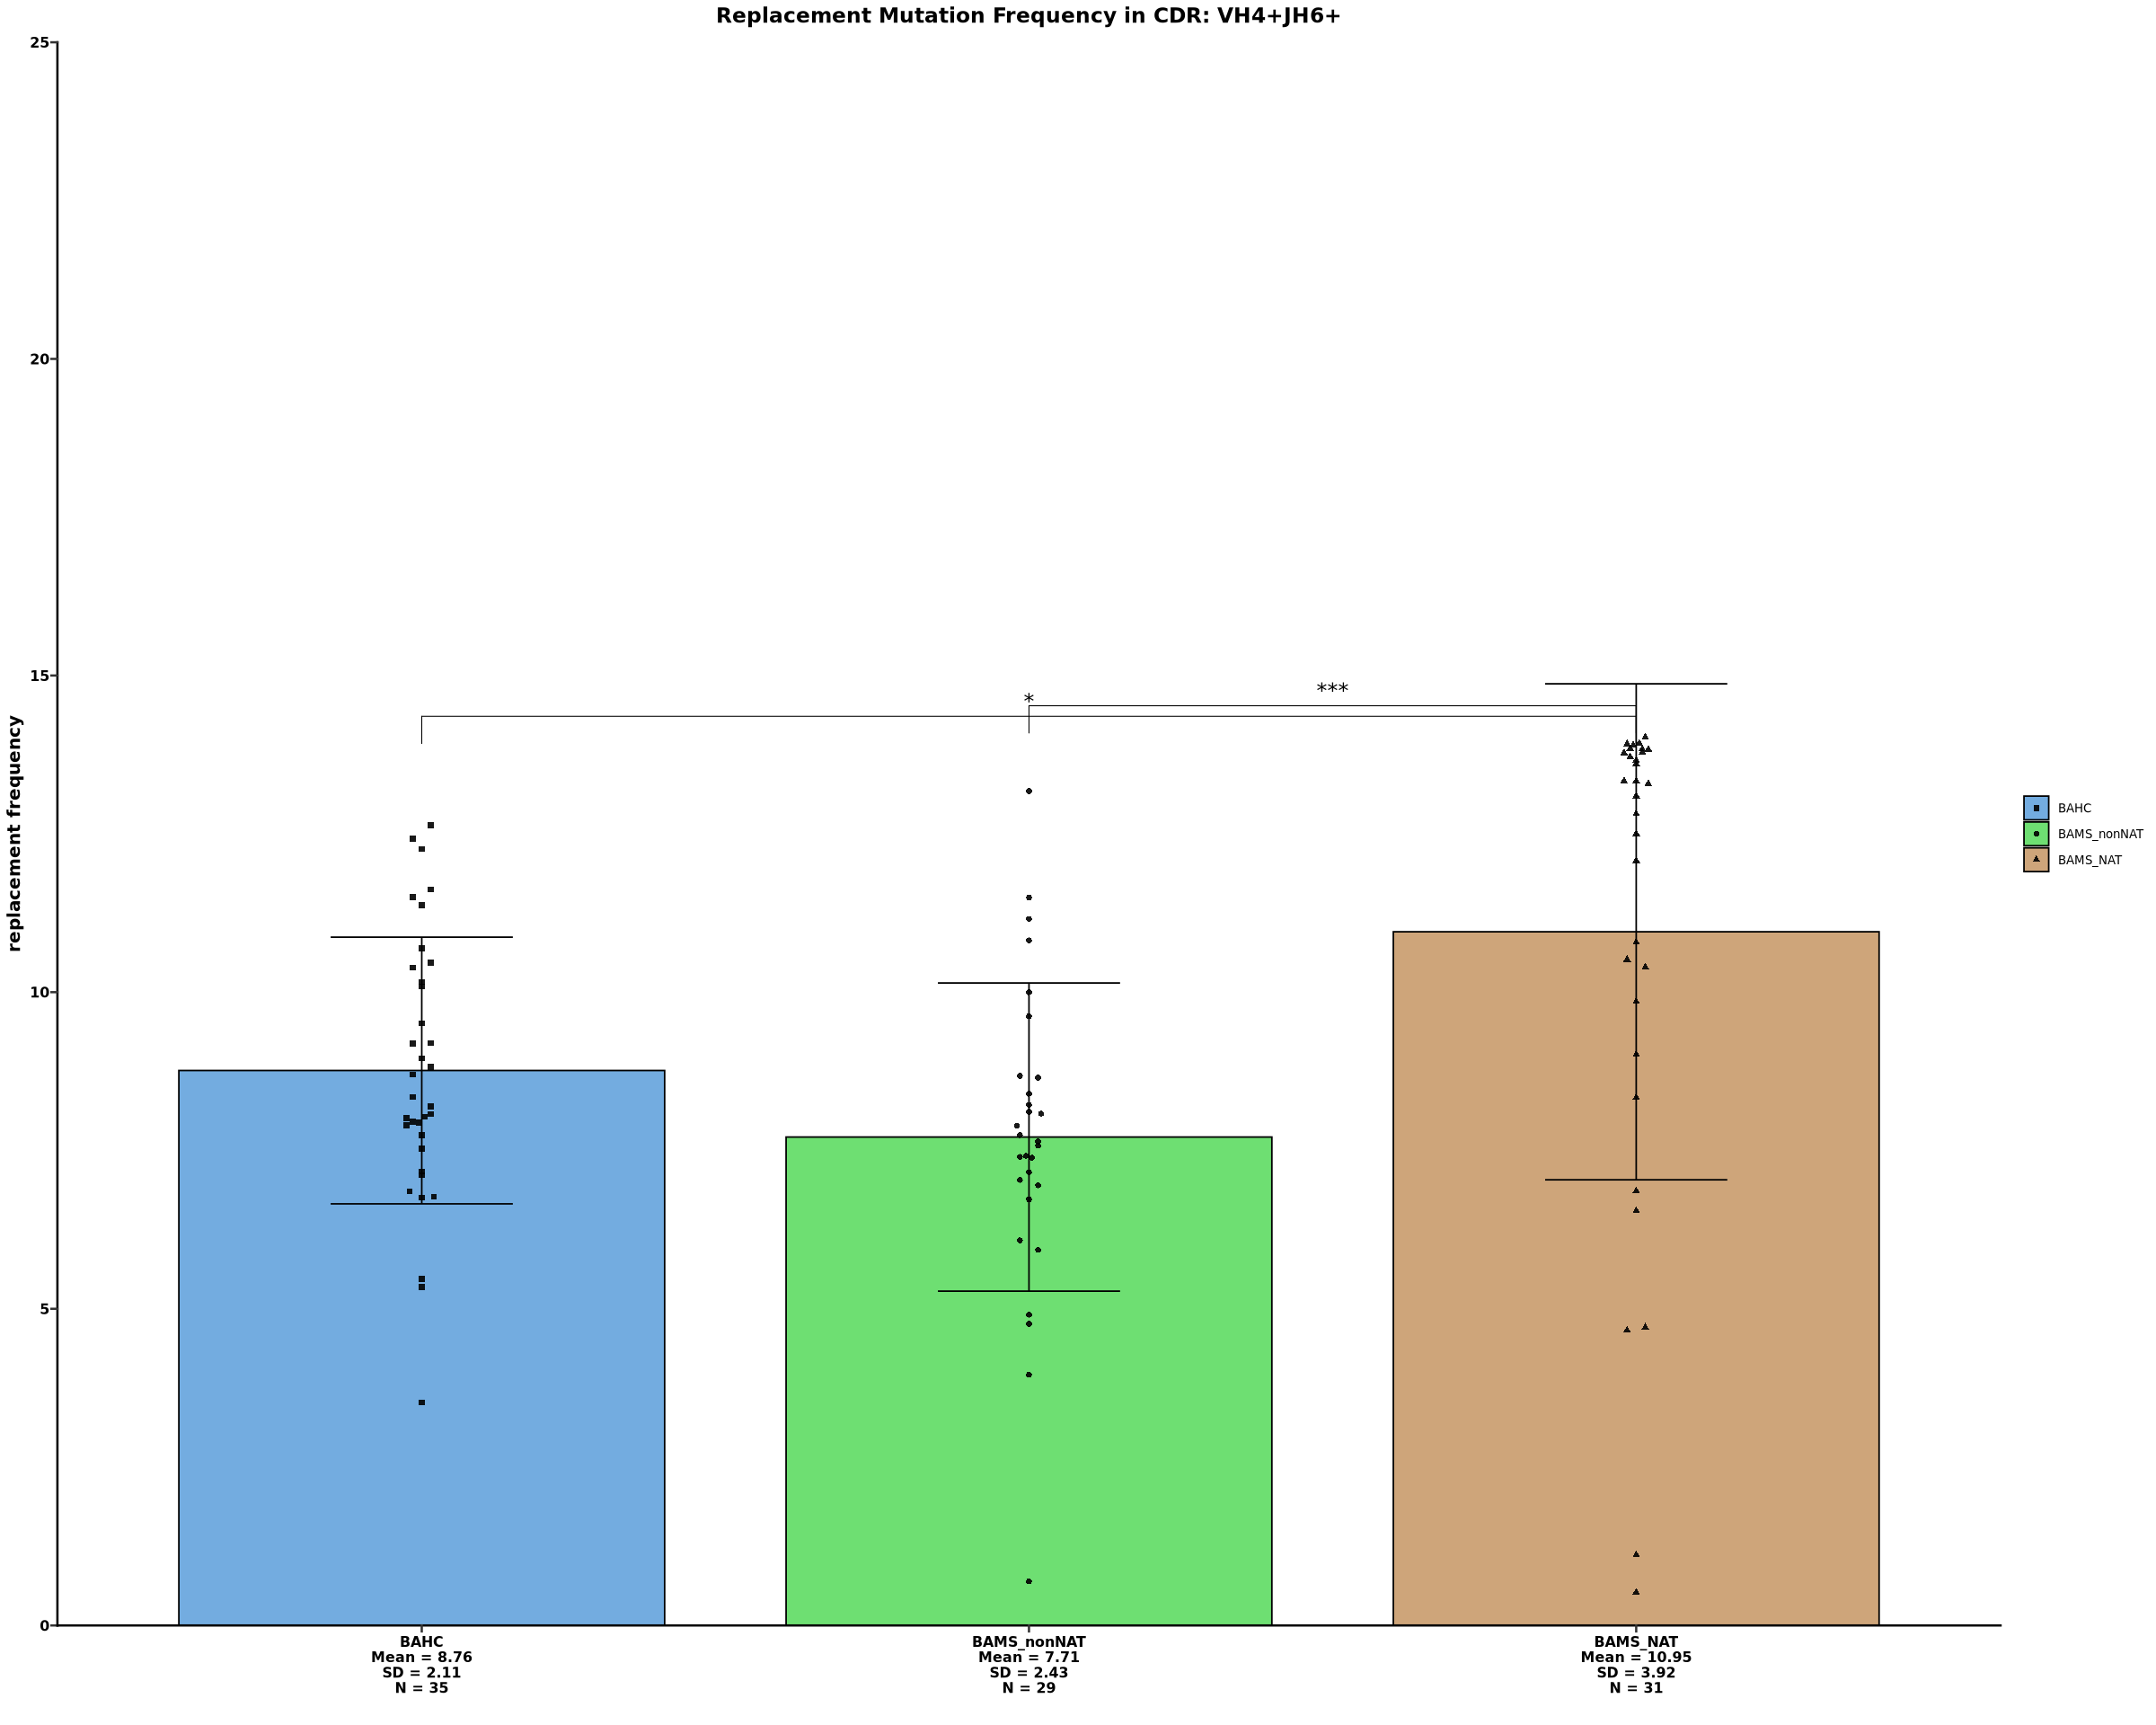

In [ ]:
r_mut_freq_cdr_VH4_fam_JH6_plot_labels <- setNames(
  paste0(
    bar_mutations_VH4_fam$group_ID,
    "\nMean = ", round(bar_mutations_VH4_fam_JH6$mean_r_mut_freq_cdr, 2),
    "\nSD = ", round(bar_mutations_VH4_fam_JH6$sd_r_mut_freq_cdr, 2),
    "\nN = ", bar_mutations_VH4_fam_JH6$n_cohort
  ),
  bar_mutations_VH4_fam_JH6$group_ID
)

r_mut_freq_cdr_VH4_fam_JH6_plot <- ggplot() +
  geom_col(
    data = bar_mutations_VH4_fam_JH6,
    mapping = aes(x = group_ID, y = mean_r_mut_freq_cdr, fill = group_ID), 
    width = 0.8,
    colour = "black", linewidth = 0.5) +
  geom_beeswarm(
    data = point_mutations_VH4_fam_JH6,
    mapping = aes(x = group_ID, y = r_mut_freq_cdr, shape = group_ID, group = group_ID), 
                  dodge.width = 0.05, 
                  method = "center",  
                  preserve.data.axis = TRUE,
                  priority = "density", 
                  corral = "wrap", 
                  corral.width = 0.05, 
                  alpha = 0.9
                  #size = 1.3, position = position_jitterdodge(jitter.width = 0.2)
                  ) +
  geom_errorbar(
   data = bar_mutations_VH4_fam_JH6,
   mapping = aes(x = group_ID, y= mean_r_mut_freq_cdr, 
                ymin = pmax(0, mean_r_mut_freq_cdr - sd_r_mut_freq_cdr), 
                ymax = mean_r_mut_freq_cdr + sd_r_mut_freq_cdr,
                group = group_ID),
                width = 0.3,
              ) +
  stat_pvalue_manual(
    r_mut_freq_cdr_VH4_fam_JH6_ttest,
    size = 5, 
    p.format.style = "graphpad",
    hide.ns = TRUE) +
  theme_prism(
    palette = "black_and_white",
    base_size = 10,
    base_family = "sans") +
  theme(
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
    axis.title.y = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    ) +
  scale_fill_manual(values = group_colors) +
  scale_shape_manual(values = group_shapes) +
  scale_y_continuous(expand = c(0, 0),
                      limits = c(0, 20)
                      ) +
  scale_x_discrete(labels = r_mut_freq_cdr_VH4_fam_JH6_plot_labels) +
  labs(title = "Replacement Mutation Frequency in CDR: VH4+JH6+",
      x = " ", y = "replacement frequency")
    ggsave(filename = file.path(plots_output_dir, paste0("r_mut_freq_cdr_VH4_fam_JH6_", exp_group_A, "_vs_", exp_group_B, "_vs_", ctrl_group, ".png")),
       plot = r_mut_freq_cdr_VH4_fam_JH6_plot, width = 7, height = 6)
plot(r_mut_freq_cdr_VH4_fam_JH6_plot)

##### 5.2 replacement frequency in FWR

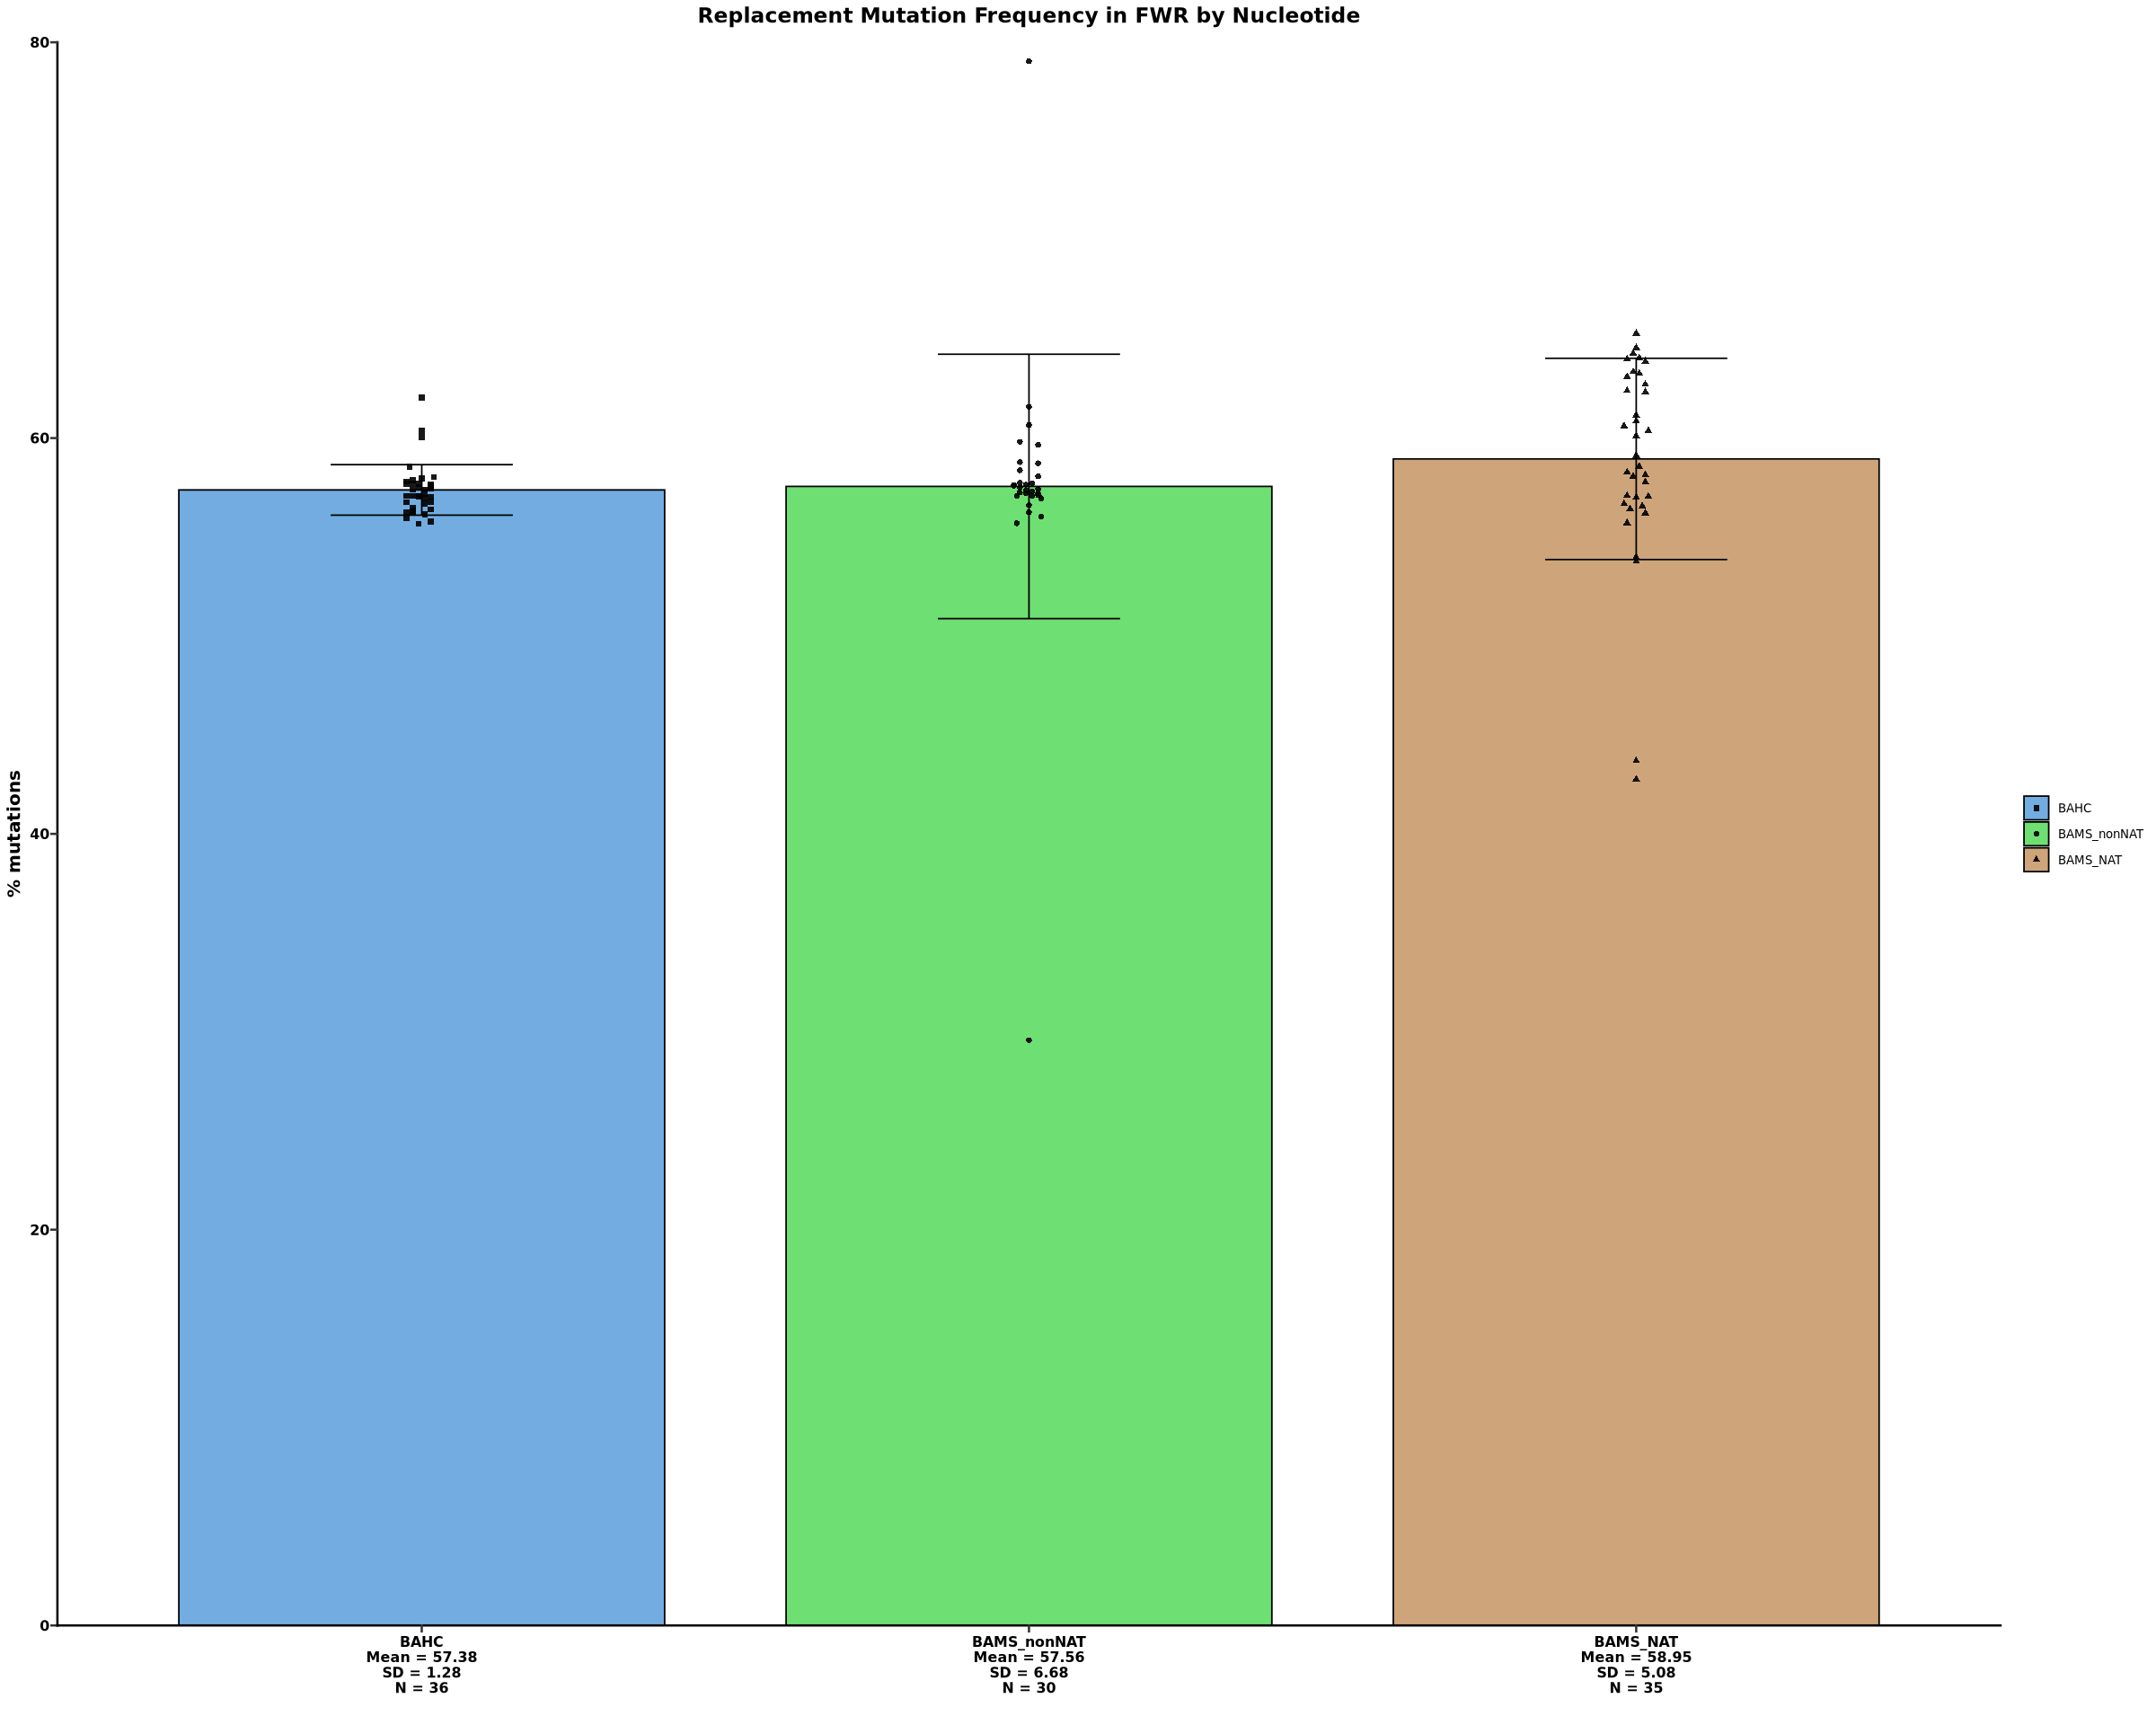

In [80]:
r_mut_freq_fwr_plot_labels <- setNames(
  paste0(
    bar_mutations$group_ID,
    "\nMean = ", round(bar_mutations$mean_r_mut_freq_fwr, 2),
    "\nSD = ", round(bar_mutations$sd_r_mut_freq_fwr, 2),
    "\nN = ", bar_mutations$n_cohort
  ),
  bar_mutations$group_ID
)

r_mut_freq_fwr_plot <- mut_analysis_summary %>%
  ggplot() +
  geom_col(
    data = bar_mutations,
    mapping = aes(x = group_ID, y = mean_r_mut_freq_fwr, fill = group_ID), 
    width = 0.8,
    colour = "black", linewidth = 0.5) +
  geom_beeswarm(
    data = point_mutations,
    mapping = aes(x = group_ID, y = r_mut_freq_fwr, shape = group_ID, group = group_ID), 
                  dodge.width = 0.05, 
                  method = "center",  
                  preserve.data.axis = TRUE,
                  priority = "density", 
                  corral = "wrap", 
                  corral.width = 0.05, 
                  alpha = 0.9
                  #size = 1.3, position = position_jitterdodge(jitter.width = 0.2)
                  ) +
  geom_errorbar(
   data = bar_mutations,
   mapping = aes(x = group_ID, y= mean_r_mut_freq_fwr, 
                ymin = pmax(0, mean_r_mut_freq_fwr - sd_r_mut_freq_fwr), 
                ymax = mean_r_mut_freq_fwr + sd_r_mut_freq_fwr,
                group = group_ID),,
                width = 0.3,
              ) +
  stat_pvalue_manual(
    r_mut_freq_fwr_ttest,
    size = 5, 
    p.format.style = "graphpad",
    hide.ns = TRUE) +
  theme_prism(
    palette = "black_and_white",
    base_size = 10,
    base_family = "sans") +
  theme(
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
    axis.title.y = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    ) +
  scale_fill_manual(values = group_colors) +
  scale_shape_manual(values = group_shapes) +
  scale_y_continuous(expand = c(0, 0),
                      limits = c(0, 80)
                      ) +
  scale_x_discrete(labels = r_mut_freq_fwr_plot_labels) +
  labs(title = "Replacement Mutation Frequency in FWR by Nucleotide",
      x = " ", y = "% mutations")
    ggsave(filename = file.path(plots_output_dir, paste0("r_mut_freq_fwr_", exp_group_A, "_vs_", exp_group_B, "_vs_", ctrl_group, ".png")),
       plot = r_mut_freq_fwr_plot, width = 7, height = 6)
plot(r_mut_freq_fwr_plot)

##### 6 replacement to silent ratio in CDR 

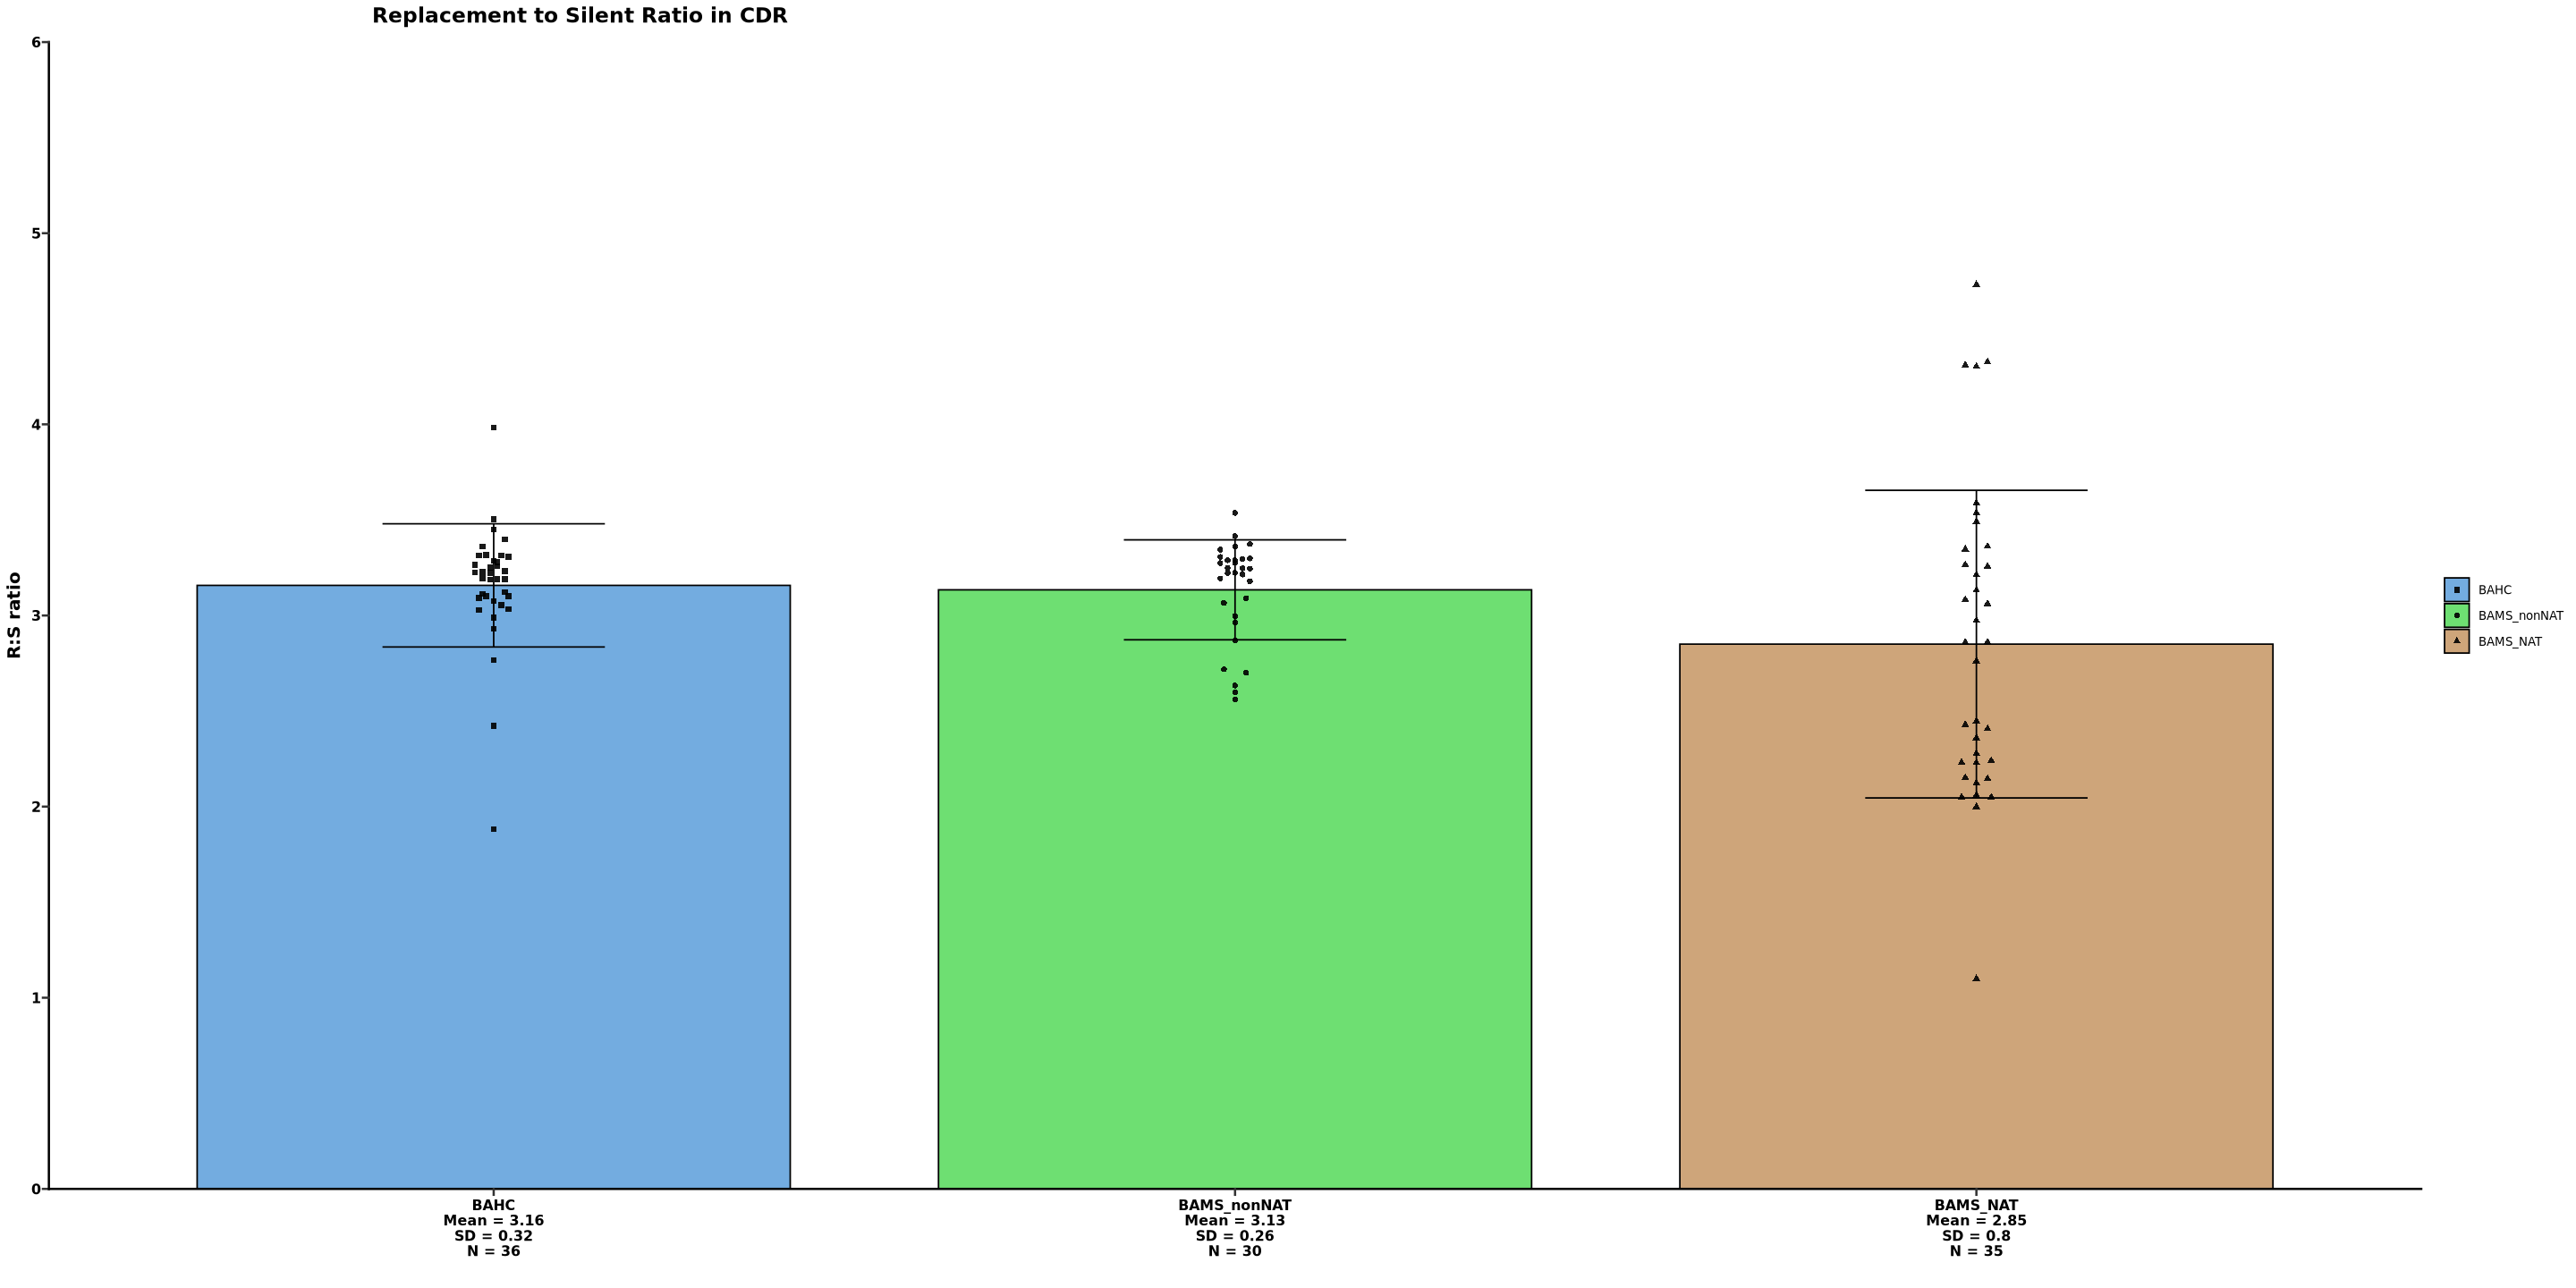

In [56]:
r_s_ratio_cdr_plot_labels <- setNames(
  paste0(
    bar_mutations$group_ID,
    "\nMean = ", round(bar_mutations$mean_r_s_ratio_cdr, 2),
    "\nSD = ", round(bar_mutations$sd_r_s_ratio_cdr, 2),
    "\nN = ", bar_mutations$n_cohort
  ),
  bar_mutations$group_ID
)

r_s_ratio_cdr_plot <- mut_analysis_summary %>%
  ggplot() +
  geom_col(
    data = bar_mutations,
    mapping = aes(x = group_ID, y = mean_r_s_ratio_cdr, fill = group_ID), 
    width = 0.8,
    colour = "black", linewidth = 0.5) +
  geom_beeswarm(
    data = point_mutations,
    mapping = aes(x = group_ID, y = r_s_ratio_cdr, shape = group_ID, group = group_ID), 
                  dodge.width = 0.05, 
                  method = "center",  
                  preserve.data.axis = TRUE,
                  priority = "density", 
                  corral = "wrap", 
                  corral.width = 0.05, 
                  alpha = 0.9
                  #size = 1.3, position = position_jitterdodge(jitter.width = 0.2)
                  ) +
  geom_errorbar(
   data = bar_mutations,
   mapping = aes(x = group_ID, y= mean_r_s_ratio_cdr, 
                ymin = pmax(0, mean_r_s_ratio_cdr - sd_r_s_ratio_cdr), 
                ymax = mean_r_s_ratio_cdr + sd_r_s_ratio_cdr,
                group = group_ID),,
                width = 0.3,
              ) +
  stat_pvalue_manual(
    r_s_ratio_cdr_ttest,
    size = 5, 
    p.format.style = "graphpad",
    hide.ns = TRUE) +
  theme_prism(
    palette = "black_and_white",
    base_size = 10,
    base_family = "sans") +
  theme(
    plot.title.position = "plot",
    plot.title = element_text(size = 14, face = "bold", hjust = 0.17),
    axis.title.y = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    ) +
  scale_fill_manual(values = group_colors) +
  scale_shape_manual(values = group_shapes) +
  scale_y_continuous(expand = c(0, 0),
                      limits = c(0, 6)
                      ) +
  scale_x_discrete(labels = r_s_ratio_cdr_plot_labels) +
  labs(title = "Replacement to Silent Ratio in CDR",
      x = " ", y = "R:S ratio")
    ggsave(filename = file.path(plots_output_dir, paste0("r_s_ratio_cdr_", exp_group_A, "_vs_", exp_group_B, "_vs_", ctrl_group, ".png")),
       plot = r_s_ratio_cdr_plot, width = 7, height = 6)
plot(r_s_ratio_cdr_plot)

##### 7 replacement to silent ratio in FWR

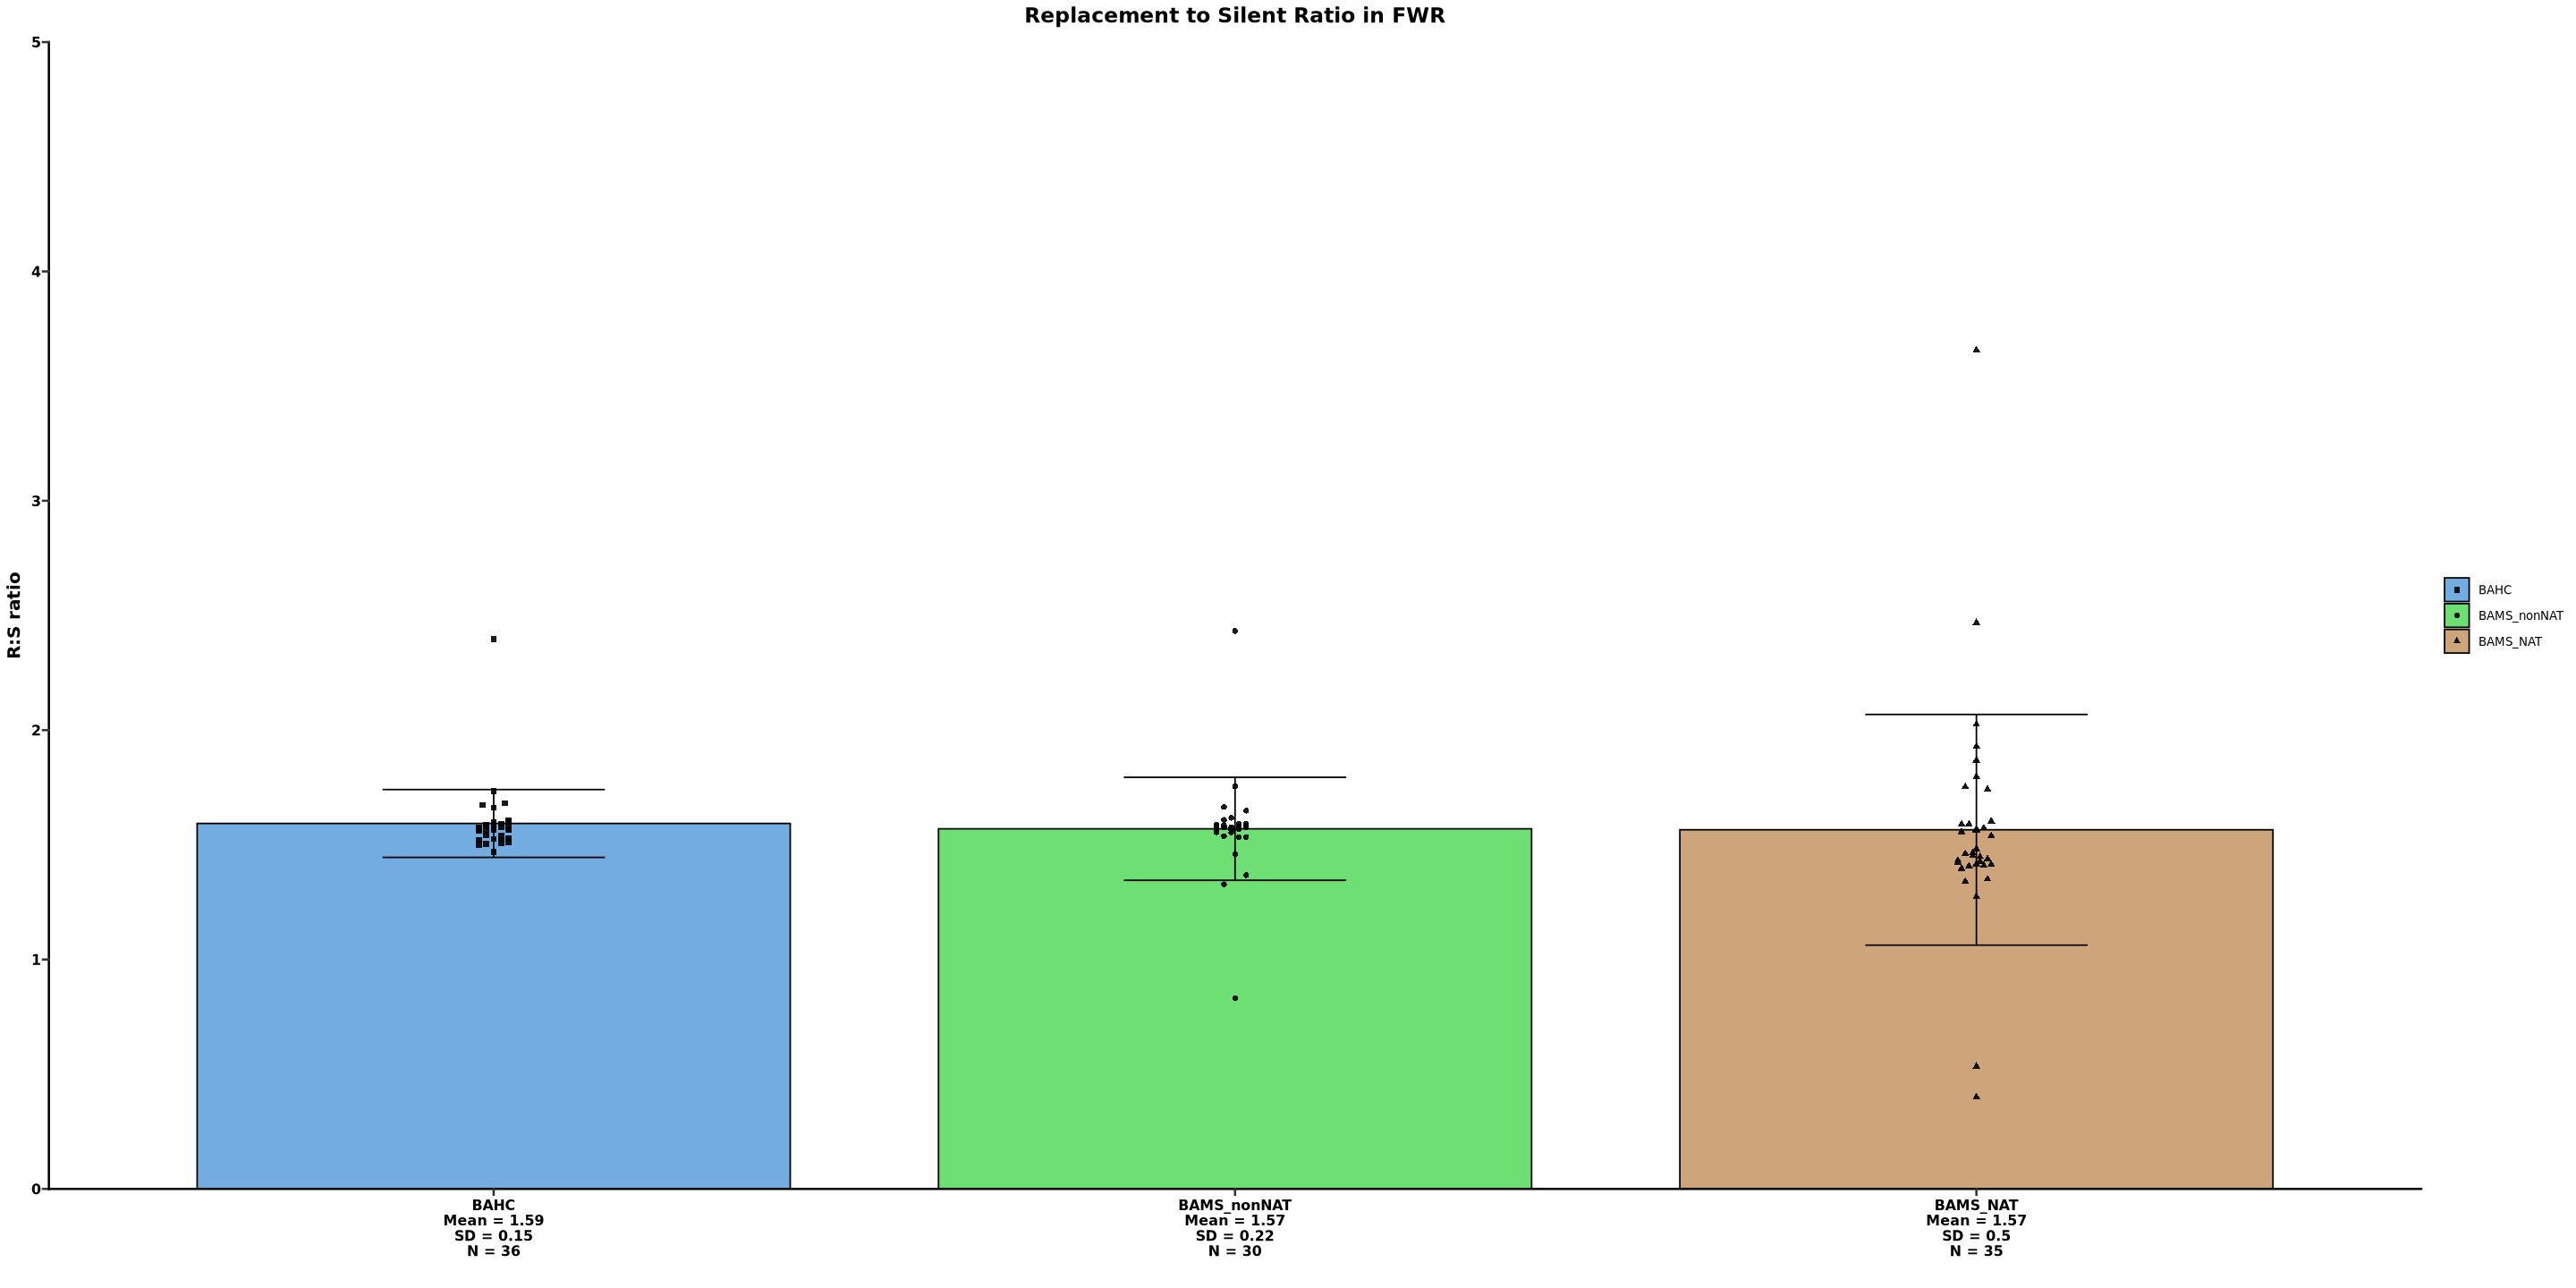

In [57]:
r_s_ratio_fwr_plot_labels <- setNames(
  paste0(
    bar_mutations$group_ID,
    "\nMean = ", round(bar_mutations$mean_r_s_ratio_fwr, 2),
    "\nSD = ", round(bar_mutations$sd_r_s_ratio_fwr, 2),
    "\nN = ", bar_mutations$n_cohort
  ),
  bar_mutations$group_ID
)

r_s_ratio_fwr_plot <- mut_analysis_summary %>%
  ggplot() +
  geom_col(
    data = bar_mutations,
    mapping = aes(x = group_ID, y = mean_r_s_ratio_fwr, fill = group_ID), 
    width = 0.8,
    colour = "black", linewidth = 0.5) +
  geom_beeswarm(
    data = point_mutations,
    mapping = aes(x = group_ID, y = r_s_ratio_fwr, shape = group_ID, group = group_ID), 
                  dodge.width = 0.05, 
                  method = "center",  
                  preserve.data.axis = TRUE,
                  priority = "density", 
                  corral = "wrap", 
                  corral.width = 0.05, 
                  alpha = 0.9
                  #size = 1.3, position = position_jitterdodge(jitter.width = 0.2)
                  ) +
  geom_errorbar(
   data = bar_mutations,
   mapping = aes(x = group_ID, y= mean_r_s_ratio_fwr, 
                ymin = pmax(0, mean_r_s_ratio_fwr - sd_r_s_ratio_fwr), 
                ymax = mean_r_s_ratio_fwr + sd_r_s_ratio_fwr,
                group = group_ID),,
                width = 0.3,
              ) +
  stat_pvalue_manual(
    r_s_ratio_fwr_ttest,
    size = 5, 
    p.format.style = "graphpad",
    hide.ns = TRUE) +
  theme_prism(
    palette = "black_and_white",
    base_size = 10,
    base_family = "sans") +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    axis.title.y = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    ) +
  scale_fill_manual(values = group_colors) +
  scale_shape_manual(values = group_shapes) +
  scale_y_continuous(expand = c(0, 0),
                      limits = c(0, 5)
                      ) +
  scale_x_discrete(labels = r_s_ratio_fwr_plot_labels) +
  labs(title = "Replacement to Silent Ratio in FWR",
      x = " ", y = "R:S ratio")
    ggsave(filename = file.path(plots_output_dir, paste0("r_s_ratio_fwr_", exp_group_A, "_vs_", exp_group_B, "_vs_", ctrl_group, ".png")),
       plot = r_s_ratio_fwr_plot, width = 7, height = 6)
plot(r_s_ratio_fwr_plot)